# Algorithmic VWAP Sigma Engine

Clean research notebook for the VWAP sigma-band strategy.

This notebook is used to:
- calculate VWAP and sigma probability bands
- detect continuation and mean-reversion setups
- route/filter raw signals
- simulate trades
- compare strategy results
- audit skipped opportunities
- prepare the final logic for a future live MT5 runner

This is not the live runner yet.

## Table of Contents

1. Imports and paths
2. Strategy control panel
3. Dataset configuration
4. VWAP and sigma band engine
5. Continuation signal engine
6. Mean-reversion signal engine
7. Router and strategy filter
8. Trade simulation and risk engine
9. Experiment runner
10. Quick results
11. Core charts
12. Risk diagnostics
13. Audits and detailed diagnostics
14. Experiment logging
15. Future live runner notes

## Imports and paths

This section contains the notebook imports, project-root detection, and output paths.

In [1]:
from pathlib import Path
from pprint import pprint
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Find the project root by walking upward until the expected repository
    structure is found.

    This works whether the project was cloned with Git or downloaded as a ZIP,
    and whether the notebook is run from the project root or from notebooks/.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        has_project_structure = (
            (path / "src").is_dir()
            and (path / "data").is_dir()
            and (path / "notebooks").is_dir()
        )

        has_repo_marker = (
            (path / ".git").exists()
            or (path / "README.md").exists()
            or (path / "requirements.txt").exists()
        )

        if has_project_structure and has_repo_marker:
            return path

    raise FileNotFoundError(
        "Could not find the project root. Make sure this notebook is being run "
        "from inside the VWAP-probability-band-engine project folder."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
HISTORICAL_DATA_DIR = DATA_DIR / "historical"
SRC_DIR = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "algorithmic_vwap_sigma_engine"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Historical data folder:", HISTORICAL_DATA_DIR)
print("Source folder:", SRC_DIR)
print("Output folder:", OUTPUT_DIR)

Current working directory: c:\GitHub Projects\VWAP-probability-band-engine\notebooks
Detected project root: C:\GitHub Projects\VWAP-probability-band-engine
Historical data folder: C:\GitHub Projects\VWAP-probability-band-engine\data\historical
Source folder: C:\GitHub Projects\VWAP-probability-band-engine\src
Output folder: C:\GitHub Projects\VWAP-probability-band-engine\artifacts\algorithmic_vwap_sigma_engine


## Strategy control panel

This section controls the strategy behaviour from one place.

The control panel is separated by role:
- strategy family switches
- continuation entry-type switches
- router and strategy-filter controls
- setup-specific quality filters
- future router-blocked override controls
- execution and risk controls
- reporting and audit controls

The goal is to make it clear which stage each setting affects.

In [44]:
# ============================================================
# 1. MAIN STRATEGY SWITCHES
# ============================================================
# Purpose:
#   Turn major strategy families on or off.
#
# Scope:
#   These are top-level switches. If a family is disabled here,
#   that family should not create trades.
#
# Default:
#   Continuation is enabled. Mean reversion and add-ons are disabled
#   until proven stable.
#
# Risk:
#   Enabling extra strategy families can change trade frequency,
#   drawdown, and attribution.

ENABLE_CONTINUATION = True
ENABLE_MEAN_REVERSION = False
ENABLE_PROTECTED_ADDONS = False


# ============================================================
# 2. CONTINUATION ENTRY TYPES
# ============================================================
# Purpose:
#   Control which continuation setup families can create raw signals.
#
# Scope:
#   These switches affect raw continuation setup creation only.
#
# Default:
#   The current primary continuation profile keeps the main continuation
#   families available.
#
# Risk:
#   Disabling a setup family can hide valid opportunity types.
#   Enabling too many weak setup families without filtering can increase noise.

ENABLE_S_TIER = True
ENABLE_DYNAMIC_S_TIER = True
ENABLE_A_TIER = True
ENABLE_DELAYED_PULLBACK = True


# ============================================================
# 3. ROUTER / STRATEGY FILTER
# ============================================================
# Purpose:
#   Decide whether raw setups fit the current market regime.
#
# Scope:
#   This is a permission layer after raw signal creation.
#   It should not be confused with raw setup detection.
#
# Default:
#   Enabled because it blocks many weak-regime signals.
#
# Risk:
#   Turning this off can allow many low-quality trades.
#   Leaving it too strict may block valid A-tier continuation opportunities.

USE_STRATEGY_FILTER = True
STRATEGY_FILTER_MODE = "v4_dynamic_regime_selector"


# ============================================================
# 4. STRATEGY FILTER OVERRIDES
# ============================================================
# Purpose:
#   Future research controls for router-blocked setups.
#
# Scope:
#   These should only apply after the router blocks a raw setup.
#   They should not affect router-approved trades.
#
# Default:
#   OFF. They should not change current results.
#
# Risk:
#   If implemented carelessly, these can become the same as removing
#   the strategy filter. They must require extra quality confirmation.

ALLOW_BLOCKED_S_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_DYNAMIC_S_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_A_TIER_WITH_EXTRA_QUALITY = False
ALLOW_BLOCKED_DELAYED_PULLBACK_WITH_EXTRA_QUALITY = False


# ============================================================
# 5. SETUP-SPECIFIC QUALITY FILTERS
# ============================================================
# Purpose:
#   Extra quality checks after a raw setup exists.
#
# Scope:
#   These should clearly state whether they apply globally,
#   only to S-tier, only to A-tier, only to delayed pullbacks,
#   only to mean reversion, or only to future router-blocked overrides.
#
# Default:
#   Preserve the current primary continuation profile.
#
# Risk:
#   Turning on too many filters at once may double-filter trades
#   that the strategy router already approved.

USE_S_TIER_CLEAN_STATE_FILTER = True

USE_RED_SHIFT_FLOOR = False
USE_TREND_HEALTH_FILTER = True
USE_CANDLE_QUALITY_FILTER = True
USE_GREEN_EXTENSION_FILTER = True

# Tester-only red-shift calculation experiment.
# "one_candle"   = original automated strategy calculation.
# "three_candle" = overlay-style/source calculation.
#
# Default stays "one_candle" so the tester returns to the original
# automated trading behaviour unless explicitly changed.
RED_SHIFT_CALCULATION_MODE = "one_candle"

# Tester-only experiment toggle.
# True = current behaviour: raw continuation still requires directional red-shift pass.
# False = raw continuation can exist without the raw directional red-shift pass.
# Red-shift is still calculated and remains available for diagnostics,
# setup-specific floors, S-tier volatile floors, and bypass floors.
RAW_CONTINUATION_REQUIRES_RED_SHIFT = True

# Tester-only chop experiment.
# "baseline" = original rolling VWAP cross-count chop logic.
# "distributed_rotation" = clustered VWAP retests are not automatic chop;
#                          VWAP rotation must be spread across a wider span.
VWAP_CHOP_LOGIC_MODE = "baseline"


# ============================================================
# 6. RISK AND RUNNER MANAGEMENT
# ============================================================
# Purpose:
#   Define continuation trade risk, target, breakeven, and runner behaviour.
#
# Scope:
#   Applies to continuation trades unless a setup-specific exit model overrides it.
#
# Default:
#   Uses the current primary continuation runner profile.
#
# Risk:
#   Changing stop size, target, breakeven, or runner locks can materially
#   change all headline results.

SL_POINTS = 36.0
ORIGINAL_TP_POINTS = 72.0
BE_TRIGGER_POINTS = 36.0

RUNNER_MODE = "always"
RUNNER_TARGET_R = 7.0

# Optional future runner tests:
# RUNNER_TARGET_R = 8.0
# RUNNER_TARGET_R = 9.0
# RUNNER_TARGET_R = 10.0

USE_LEGACY_EARLY_RUNNER_LOCK = False

RUNNER_TRAIL_RULES_R = [
    {"trigger_r": 1.0, "lock_r": 0.0, "label": "BE"},
    {"trigger_r": 2.7, "lock_r": 2.0, "label": "TRAIL_LOCK_2R"},
    {"trigger_r": 3.7, "lock_r": 3.0, "label": "TRAIL_LOCK_3R"},
    {"trigger_r": 4.7, "lock_r": 4.0, "label": "TRAIL_LOCK_4R"},
    {"trigger_r": 5.7, "lock_r": 5.0, "label": "TRAIL_LOCK_5R"},
    {"trigger_r": 6.7, "lock_r": 6.0, "label": "TRAIL_LOCK_6R"},
    {"trigger_r": 7.7, "lock_r": 7.0, "label": "TRAIL_LOCK_7R"},
    {"trigger_r": 8.7, "lock_r": 8.0, "label": "TRAIL_LOCK_8R"},
    {"trigger_r": 9.7, "lock_r": 9.0, "label": "TRAIL_LOCK_9R"},
]

# ============================================================
# GREEN-BAND EXTENSION LIMITS
# ============================================================
# Purpose:
#   Prevent continuation entries from chasing too far beyond the green band.
#
# Scope:
#   Applies to continuation entry quality checks.
#   Can be overridden by setup family.
#
# Default:
#   Uses one simple maximum extension-from-green value.
#
# Risk:
#   Too tight a cap may block strong momentum entries.
#   Too loose a cap may allow stretched entries with poor stop placement.

DEFAULT_MAX_GREEN_EXTENSION_POINTS = 30.0

# ============================================================
# 7. PROTECTED CONTINUATION ADD-ONS
# ============================================================
# Purpose:
#   Allow another continuation trade only when an existing continuation
#   trade is already protected.
#
# Scope:
#   Applies to continuation stacking logic, not mean reversion.
#
# Default:
#   OFF until proven stable.
#
# Risk:
#   If configured badly, this can create multiple full-risk trades.
#   The intended rule is no second fresh full-risk trade.

ENABLE_PROTECTED_ADDONS = False
ADDON_REQUIRES_EXISTING_TRADE_PROTECTED = True
ADDON_REQUIRES_SAME_DIRECTION = True
MAX_OPEN_CONTINUATION_TRADES = 2


# ============================================================
# 8. MEAN-REVERSION SETTINGS
# ============================================================
# Purpose:
#   Configure the optional mean-reversion module.
#
# Scope:
#   Mean reversion is separate from continuation.
#   It targets VWAP and should not use the continuation runner.
#
# Default:
#   Disabled because early tests over-traded.
#
# Risk:
#   Mean reversion can add many trades and increase drawdown if not filtered.

ENABLE_MEAN_REVERSION = False

MR_TARGET_MODE = "vwap"
MR_STOP_MODE = "structure"
MR_MAX_SL_POINTS = 14.0
MR_MIN_TARGET_RR = 2.0


# ============================================================
# MEAN-REVERSION BREAKEVEN PROTECTION
# ============================================================
# Purpose:
#   Protect MR trades once price has mean-reverted from orange back to green.
#
# Scope:
#   Applies only to mean-reversion trades.
#   Does not affect continuation entries or continuation runners.
#
# Default:
#   Enabled for MR logic, but MR itself remains disabled by default.
#
# Risk:
#   If triggered too early, MR may exit at breakeven before reaching VWAP.
#   If triggered too late, it may not protect enough partial reversions.

ENABLE_MR_GREEN_BE = True
MR_BE_TRIGGER_MODE = "inner_green"
MR_BE_REQUIRES_CLOSE_BEYOND_GREEN = True
MR_BE_LOCK_R = 0.0


# ============================================================
# 9. DAILY RISK / SESSION CONTROLS
# ============================================================
# Purpose:
#   Control account/risk/session-level trade permissions.
#
# Scope:
#   These controls operate after signal selection.
#
# Default:
#   Preserve current research profile.
#
# Risk:
#   Tight risk/session settings can reduce trade count.
#   Loose settings can increase drawdown exposure.

MAX_DAILY_LOSS_R = -2
DAILY_PROFIT_CAP_PCT = 999.0
MAX_CONSECUTIVE_SL = 2
NO_NEW_TRADES_AFTER = "19:00"
SESSION_FILTER_ENABLED = False

# ============================================================
# MARKET OPEN BLACKOUT CONFIG
# ============================================================
# Purpose:
#   Optional research toggle to block new entries during the first minutes
#   after the configured market open.
#
# Scope:
#   Blocks new trade entries only.
#   Does not affect open-trade management, BE movement, trailing, or exits.
#
# Default:
#   OFF, so validated baseline behaviour is unchanged.

BLOCK_MARKET_OPEN_WINDOW = False
MARKET_OPEN_TIME = "14:30"
MARKET_OPEN_TIMEZONE = "Europe/London"
MARKET_OPEN_BLOCK_MINUTES = 15


# ============================================================
# 10. AUDITS / REPORTS / LOGGING
# ============================================================
# Purpose:
#   Explain what the model saw, selected, executed, or skipped.
#
# Scope:
#   These should not change trading logic.
#
# Default:
#   Enabled because this notebook is a research/control notebook.
#
# Risk:
#   These should not affect results. If toggling a report changes trades,
#   something is wired incorrectly.

ENABLE_RAW_SIGNAL_AUDIT = True
ENABLE_STRATEGY_FILTER_BLOCK_AUDIT = True
ENABLE_TRADE_ATTRIBUTION_REPORT = True
ENABLE_RISK_DIAGNOSTICS = True
ENABLE_ACCOUNT_SURVIVAL_REPORT = True
ENABLE_EXPERIMENT_LOGGING = True

### Setup-specific filter and runner profiles

This section defines the future setup-specific configuration architecture.

**Purpose:** provide a clean modular layer for entry-specific filters, runner targets, trail profiles, and router-blocked research rules.

**Scope:** architecture only. Existing validated trading behaviour continues to use the compatibility `CONFIG` fields until setup profiles are explicitly wired into the signal, router, execution, and runner layers.

**Default:** setup profiles are disabled for trading through `USE_SETUP_PROFILES_FOR_TRADING = False`. Router-blocked bypass rules remain disabled.

**Risk:** this section must not affect current signals, routing, execution, filters, runner targets, trail locks, or headline results while inactive.

In [3]:
# ============================================================
# 11. SETUP-SPECIFIC FILTER AND RUNNER PROFILES
# ============================================================
# Purpose:
#   Define the future modular configuration layer for entry-specific
#   filters, runner targets, trail profiles, and router-blocked research.
#
# Scope:
#   Architecture only. Existing validated dense-source-compatible trading
#   logic still uses the compatibility CONFIG fields below.
#   Later changes can wire setup-specific filters, runner targets,
#   trail profiles, and router-blocked bypass rules into the strategy
#   layers one at a time.
#
# Default:
#   Disabled for trading. The current primary continuation profile remains
#   controlled by the compatibility CONFIG mapping.
#
# Risk:
#   This layer must not affect signals, routing, execution, filters,
#   runner targets, trail locks, or headline results until it is wired
#   explicitly.

USE_SETUP_PROFILES_FOR_TRADING = False
STRICT_BASELINE_PROFILE_VALIDATION = False

# Named compatibility defaults.
# SETUP_PROFILES remains the main editable source of truth for setup-specific
# red-shift floors. These constants are only fallback values for compatibility
# paths and defensive lookups.
DEFAULT_S_TIER_RED_SHIFT_POINTS = 2.0
DEFAULT_DYNAMIC_S_TIER_RED_SHIFT_POINTS = 2.0
DEFAULT_A_TIER_RED_SHIFT_POINTS = 3.0
DEFAULT_DELAYED_PULLBACK_RED_SHIFT_POINTS = 3.0
DEFAULT_MEAN_REVERSION_RED_SHIFT_POINTS = 0.0
DEFAULT_DISABLED_BYPASS_RED_SHIFT_POINTS = 0.0


# Global defaults are broad controls.
# Setup profiles are entry-specific controls.
# Later changes can decide how setup profiles inherit or override
# these global defaults.
GLOBAL_FILTER_DEFAULTS = {
    "use_trend_health": USE_TREND_HEALTH_FILTER,
    "use_red_shift_floor": USE_RED_SHIFT_FLOOR,
    "use_candle_quality_filter": USE_CANDLE_QUALITY_FILTER,
    "use_extension_filter": USE_GREEN_EXTENSION_FILTER,

    # Optional global force rule.
    # Example: require trend-health checks after a certain clock time.
    "force_trend_health_after_time_enabled": False,
    "force_trend_health_after_time": "17:00",
    "force_trend_health_timezone": "Europe/London",
}

SETUP_PROFILES = {
    "S_TIER": {
        "enabled": True,
        "use_trend_health": False,
        "use_red_shift_floor": False,
        "min_directional_red_shift_points": DEFAULT_S_TIER_RED_SHIFT_POINTS,
        # Optional intelligent-mode cross-regime exception.
        # Default False preserves the validated regime route.
        "allow_in_volatile_trend": True,
        "volatile_require_red_shift_floor": True,
        "volatile_min_directional_red_shift_points": 13.50,
        "use_candle_quality_filter": True,
        "use_extension_filter": True,
        "max_entry_extension_from_green_points": 8.0,
        "use_clean_state_filter": True,
        "runner_target_r": 10.0,
        "trail_profile": "standard_27",
    },

    "DYNAMIC_S_TIER": {
        "enabled": True,
        "use_trend_health": False,
        "use_red_shift_floor": False,
        "min_directional_red_shift_points": DEFAULT_DYNAMIC_S_TIER_RED_SHIFT_POINTS,
        "use_candle_quality_filter": True,
        "use_extension_filter": True,
        "max_entry_extension_from_green_points": 8.0,
        "use_clean_state_filter": True,
        "runner_target_r": 10.0,
        "trail_profile": "standard_27",
    },

    "A_TIER": {
        "enabled": True,
        "use_trend_health": True,
        "use_red_shift_floor": False,
        "min_directional_red_shift_points": DEFAULT_A_TIER_RED_SHIFT_POINTS,
        # Optional intelligent-mode cross-regime exception.
        # Default False preserves the validated regime route.
        "allow_in_calm_trend": False,
        "calm_require_red_shift_floor": True,
        "calm_min_directional_red_shift_points": 4.00,
        "use_candle_quality_filter": True,
        "use_extension_filter": True,
        "max_entry_extension_from_green_points": DEFAULT_MAX_GREEN_EXTENSION_POINTS,
        #"max_entry_extension_from_green_points": 30.0,
        "use_clean_state_filter": False,
        "runner_target_r": 10.0,
        "trail_profile": "standard_27",
    },

    "DELAYED_PULLBACK": {
        "enabled": True,
        "use_trend_health": True,
        "use_red_shift_floor": False,
        "min_directional_red_shift_points": DEFAULT_DELAYED_PULLBACK_RED_SHIFT_POINTS,
        "use_candle_quality_filter": True,
        "use_extension_filter": True,
        "max_entry_extension_from_green_points": DEFAULT_MAX_GREEN_EXTENSION_POINTS,
        #"max_entry_extension_from_green_points": 30.0,
        "use_clean_state_filter": False,
        "runner_target_r": 10.0,
        "trail_profile": "standard_27",
    },

    "MEAN_REVERSION": {
        "enabled": False,
        "use_trend_health": False,
        "use_red_shift_floor": False,
        "min_directional_red_shift_points": DEFAULT_MEAN_REVERSION_RED_SHIFT_POINTS,
        "use_candle_quality_filter": True,
        "use_extension_filter": True,
        "max_entry_extension_from_green_points": None,
        "use_clean_state_filter": False,
        "runner_target_r": None,
        "trail_profile": None,
    },
}


TRAIL_PROFILES = {
    "standard_27": [
        {"trigger_r": 1.0, "lock_r": 0.0, "label": "BE"},
        {"trigger_r": 2.7, "lock_r": 2.0, "label": "TRAIL_LOCK_2R"},
        {"trigger_r": 3.7, "lock_r": 3.0, "label": "TRAIL_LOCK_3R"},
        {"trigger_r": 4.7, "lock_r": 4.0, "label": "TRAIL_LOCK_4R"},
        {"trigger_r": 5.7, "lock_r": 5.0, "label": "TRAIL_LOCK_5R"},
        {"trigger_r": 6.7, "lock_r": 6.0, "label": "TRAIL_LOCK_6R"},
        {"trigger_r": 7.7, "lock_r": 7.0, "label": "TRAIL_LOCK_7R"},
        {"trigger_r": 8.7, "lock_r": 8.0, "label": "TRAIL_LOCK_8R"},
        {"trigger_r": 9.7, "lock_r": 9.0, "label": "TRAIL_LOCK_9R"},
    ],

    "faster_25": [
        {"trigger_r": 1.0, "lock_r": 0.0, "label": "BE"},
        {"trigger_r": 2.5, "lock_r": 2.0, "label": "TRAIL_LOCK_2R"},
        {"trigger_r": 3.5, "lock_r": 3.0, "label": "TRAIL_LOCK_3R"},
        {"trigger_r": 4.5, "lock_r": 4.0, "label": "TRAIL_LOCK_4R"},
        {"trigger_r": 5.5, "lock_r": 5.0, "label": "TRAIL_LOCK_5R"},
        {"trigger_r": 6.5, "lock_r": 6.0, "label": "TRAIL_LOCK_6R"},
        {"trigger_r": 7.5, "lock_r": 7.0, "label": "TRAIL_LOCK_7R"},
        {"trigger_r": 8.5, "lock_r": 8.0, "label": "TRAIL_LOCK_8R"},
        {"trigger_r": 9.5, "lock_r": 9.0, "label": "TRAIL_LOCK_9R"},
    ],
}


# These are disabled placeholders.
# They are for future controlled router-blocked setup research.
# They must not affect current results while USE_SETUP_PROFILES_FOR_TRADING
# remains False and the bypass rules remain disabled.
ROUTER_BYPASS_RULES = {
    "S_TIER": {
        "enabled": False,
        "requires_trend_health": False,
        "requires_red_shift_floor": False,
        "min_directional_red_shift_points": DEFAULT_MEAN_REVERSION_RED_SHIFT_POINTS,
        "max_extension_from_green": None,
    },

    "DYNAMIC_S_TIER": {
        "enabled": False,
        "requires_trend_health": False,
        "requires_red_shift_floor": False,
        "min_directional_red_shift_points": 0.0,
        "max_extension_from_green": None,
    },

    "A_TIER": {
        "enabled": True,
        "trend_health_mode": "after_time",  # options: "off", "always", "after_time", "follow_v2_activation"
        "trend_health_after_time": "17:00",  # used only when trend_health_mode = "after_time"
        "trend_health_after_timezone": "Europe/London",  # used only when trend_health_mode = "after_time"
        "requires_red_shift_floor": True,
        "min_directional_red_shift_points": 2.30,
        #"max_extension_from_green": SETUP_PROFILES["A_TIER"]["max_entry_extension_from_green_points"],
        "max_extension_from_green": 20,
    },

    "DELAYED_PULLBACK": {
        "enabled": False,
        "requires_trend_health": True,
        "requires_red_shift_floor": True,
        "min_directional_red_shift_points": DEFAULT_DELAYED_PULLBACK_RED_SHIFT_POINTS,
        "max_extension_from_green": None,
    },
}

def setup_profile_router_bypass_rule(setup_family: str) -> dict:
    """
    Resolve a router-bypass rule for a setup family.

    ROUTER_BYPASS_RULES is the editable source of truth for controlled
    router-blocked setup research. Rules remain inactive by default because
    every setup rule is disabled unless explicitly toggled.
    """
    return dict(ROUTER_BYPASS_RULES.get(setup_family, {}))

def setup_profile_trail_profile_name(
    setup_family: str,
    fallback_profile: str | None = None,
) -> str | None:
    """
    Resolve the setup-specific runner trail profile name.

    SETUP_PROFILES is the main editable source of truth for setup-specific
    trail profiles. While USE_SETUP_PROFILES_FOR_TRADING is False, this returns
    the existing compatibility fallback so current validated behaviour is unchanged.
    """
    if not USE_SETUP_PROFILES_FOR_TRADING:
        return fallback_profile

    profile = SETUP_PROFILES.get(setup_family, {})
    return profile.get("trail_profile", fallback_profile)

def setup_profile_runner_target_r(
    setup_family: str,
    fallback_target_r: float | None,
) -> float | None:
    """
    Resolve the active setup-specific runner target in R.

    This is intentionally active even while USE_SETUP_PROFILES_FOR_TRADING is False.
    Only runner_target_r is wired through here. Other setup-profile trading controls
    such as filters and trail profiles remain gated separately.
    """
    profile = SETUP_PROFILES.get(setup_family, {})
    profile_target_r = profile.get("runner_target_r", None)

    target_r = fallback_target_r if profile_target_r is None else profile_target_r

    if target_r is None:
        return None

    if isinstance(target_r, (bool, np.bool_)):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}]['runner_target_r'] must be numeric or None, "
            f"got {target_r!r}."
        )

    try:
        target_r = float(target_r)
    except (TypeError, ValueError):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}]['runner_target_r'] must be numeric or None, "
            f"got {target_r!r}."
        ) from None

    if pd.isna(target_r) or target_r <= 0.0:
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}]['runner_target_r'] must be > 0 or None, "
            f"got {target_r!r}."
        )

    return target_r

def setup_profile_extension_filter_enabled(
    setup_family: str,
) -> bool:
    """
    Resolve whether green-extension filtering is enabled for a setup family.

    The global USE_GREEN_EXTENSION_FILTER toggle controls whether the filter
    is active at all. Setup profiles then control whether each setup family
    participates in the filter.
    """
    if not USE_GREEN_EXTENSION_FILTER:
        return False

    profile = SETUP_PROFILES.get(setup_family, {})
    return bool(profile.get("use_extension_filter", True))


def setup_profile_max_green_extension_points(
    setup_family: str,
) -> float | None:
    """
    Resolve the setup-specific maximum extension from the green band.

    SETUP_PROFILES is the user-facing source of truth. If a setup has None,
    no green-extension cap is applied to that setup.
    """
    profile = SETUP_PROFILES.get(setup_family, {})
    max_points = profile.get("max_entry_extension_from_green_points", None)

    if max_points is None or pd.isna(max_points):
        return None

    return float(max_points)

def setup_profile_trend_health_enabled(
    setup_family: str,
    fallback_enabled: bool,
) -> bool:
    """
    Resolve whether setup-specific trend-health protection is enabled.

    While USE_SETUP_PROFILES_FOR_TRADING is False, this returns the existing
    compatibility value so current validated behaviour is unchanged.
    """
    if not USE_SETUP_PROFILES_FOR_TRADING:
        return bool(fallback_enabled)

    profile = SETUP_PROFILES.get(setup_family, {})
    return bool(profile.get("use_trend_health", fallback_enabled))

def setup_profile_red_shift_floor_enabled(
    setup_family: str,
    fallback_enabled: bool,
) -> bool:
    """
    Resolve whether the setup-specific red-shift floor is enabled.

    While USE_SETUP_PROFILES_FOR_TRADING is False, this returns the existing
    compatibility value so current validated behaviour is unchanged.
    """
    if not USE_SETUP_PROFILES_FOR_TRADING:
        return bool(fallback_enabled)

    profile = SETUP_PROFILES.get(setup_family, {})
    return bool(profile.get("use_red_shift_floor", fallback_enabled))


def setup_profile_red_shift_min_points(
    setup_family: str,
    fallback_min_points: float | None = None,
) -> float:
    """
    Resolve the setup-specific minimum directional red-shift floor.

    SETUP_PROFILES is the main editable source of truth for setup-specific
    red-shift floors. fallback_min_points exists only for compatibility and
    defensive lookups.
    """
    fallback_by_setup = {
        "S_TIER": DEFAULT_S_TIER_RED_SHIFT_POINTS,
        "DYNAMIC_S_TIER": DEFAULT_DYNAMIC_S_TIER_RED_SHIFT_POINTS,
        "A_TIER": DEFAULT_A_TIER_RED_SHIFT_POINTS,
        "DELAYED_PULLBACK": DEFAULT_DELAYED_PULLBACK_RED_SHIFT_POINTS,
        "MEAN_REVERSION": DEFAULT_MEAN_REVERSION_RED_SHIFT_POINTS,
    }

    setup_key = str(setup_family).upper()

    if fallback_min_points is None:
        fallback_min_points = fallback_by_setup.get(setup_key, 0.0)

    profile = SETUP_PROFILES.get(setup_key, {})

    return float(
        profile.get(
            "min_directional_red_shift_points",
            fallback_min_points,
        )
    )

def setup_profile_bool_setting(
    setup_family: str,
    setting_key: str,
    default_value: bool = False,
) -> bool:
    """
    Resolve a boolean setup-profile setting with clear validation.

    This is used for optional cross-regime intelligent-router exceptions.
    Invalid values fail loudly instead of silently changing routing behaviour.
    """
    profile = SETUP_PROFILES.get(str(setup_family).upper(), {})
    value = profile.get(setting_key, default_value)

    if not isinstance(value, (bool, np.bool_)):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}][{setting_key!r}] must be True or False, "
            f"got {value!r}."
        )

    return bool(value)


def setup_profile_float_setting(
    setup_family: str,
    setting_key: str,
    default_value: float = 0.0,
    *,
    min_value: float | None = 0.0,
) -> float:
    """
    Resolve a numeric setup-profile setting with clear validation.
    """
    profile = SETUP_PROFILES.get(str(setup_family).upper(), {})
    value = profile.get(setting_key, default_value)

    if isinstance(value, (bool, np.bool_)):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}][{setting_key!r}] must be numeric, "
            f"got boolean {value!r}."
        )

    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}][{setting_key!r}] must be numeric, "
            f"got {value!r}."
        ) from None

    if pd.isna(numeric_value):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}][{setting_key!r}] cannot be NaN."
        )

    if min_value is not None and numeric_value < float(min_value):
        raise ValueError(
            f"SETUP_PROFILES[{setup_family!r}][{setting_key!r}] must be >= {min_value}, "
            f"got {numeric_value}."
        )

    return numeric_value

def build_setup_profile_summary(setup_profiles: dict) -> pd.DataFrame:
    """
    Return a compact summary table of setup-specific filter and runner settings.
    """
    display_columns = [
        "setup_family",
        "enabled",
        "use_trend_health",
        "use_red_shift_floor",
        "min_directional_red_shift_points",

        # Optional cross-regime intelligent-router settings.
        "allow_in_volatile_trend",
        "volatile_require_red_shift_floor",
        "volatile_min_directional_red_shift_points",
        "allow_in_calm_trend",
        "calm_require_red_shift_floor",
        "calm_min_directional_red_shift_points",

        # Existing setup-profile filter controls.
        "use_candle_quality_filter",
        "use_extension_filter",
        "max_entry_extension_from_green_points",
        "use_clean_state_filter",

        # Existing runner/trailing controls.
        "runner_target_r",
        "trail_profile",
    ]

    rows = []
    for setup_family, profile in setup_profiles.items():
        row = {"setup_family": setup_family}
        row.update(profile)
        rows.append(row)

    return pd.DataFrame(rows)[display_columns]


def validate_setup_profile_architecture(
    setup_profiles: dict,
    trail_profiles: dict,
    router_bypass_rules: dict,
    use_setup_profiles_for_trading: bool,
) -> dict:
    """
    Validate that the setup-profile architecture is present but inactive.
    """
    invalid_trail_profiles = {
        setup_family: profile.get("trail_profile")
        for setup_family, profile in setup_profiles.items()
        if profile.get("trail_profile") is not None
        and profile.get("trail_profile") not in trail_profiles
    }

    invalid_runner_targets = {}

    for setup_family, profile in setup_profiles.items():
        target_r = profile.get("runner_target_r")

        if target_r is None:
            continue

        if isinstance(target_r, (bool, np.bool_)):
            invalid_runner_targets[setup_family] = target_r
            continue

        try:
            numeric_target_r = float(target_r)
        except (TypeError, ValueError):
            invalid_runner_targets[setup_family] = target_r
            continue

        if pd.isna(numeric_target_r) or numeric_target_r <= 0.0:
            invalid_runner_targets[setup_family] = target_r

    enabled_bypass_rules = [
        setup_family
        for setup_family, rule in router_bypass_rules.items()
        if bool(rule.get("enabled", False))
    ]

    cross_regime_required_keys = {
        "S_TIER": [
            "allow_in_volatile_trend",
            "volatile_require_red_shift_floor",
            "volatile_min_directional_red_shift_points",
        ],
        "A_TIER": [
            "allow_in_calm_trend",
            "calm_require_red_shift_floor",
            "calm_min_directional_red_shift_points",
        ],
    }

    cross_regime_bool_keys = {
        "S_TIER": ["allow_in_volatile_trend", "volatile_require_red_shift_floor"],
        "A_TIER": ["allow_in_calm_trend", "calm_require_red_shift_floor"],
    }

    cross_regime_numeric_keys = {
        "S_TIER": ["volatile_min_directional_red_shift_points"],
        "A_TIER": ["calm_min_directional_red_shift_points"],
    }

    missing_cross_regime_keys = {
        setup_family: [
            key for key in required_keys
            if key not in setup_profiles.get(setup_family, {})
        ]
        for setup_family, required_keys in cross_regime_required_keys.items()
    }
    missing_cross_regime_keys = {
        setup_family: keys
        for setup_family, keys in missing_cross_regime_keys.items()
        if keys
    }

    invalid_cross_regime_bool_values = {}
    for setup_family, keys in cross_regime_bool_keys.items():
        profile = setup_profiles.get(setup_family, {})
        for key in keys:
            if key in profile and not isinstance(profile.get(key), (bool, np.bool_)):
                invalid_cross_regime_bool_values[f"{setup_family}.{key}"] = profile.get(key)

    invalid_cross_regime_numeric_values = {}
    for setup_family, keys in cross_regime_numeric_keys.items():
        profile = setup_profiles.get(setup_family, {})
        for key in keys:
            if key not in profile:
                continue

            value = profile.get(key)

            if isinstance(value, (bool, np.bool_)):
                invalid_cross_regime_numeric_values[f"{setup_family}.{key}"] = value
                continue

            try:
                numeric_value = float(value)
            except (TypeError, ValueError):
                invalid_cross_regime_numeric_values[f"{setup_family}.{key}"] = value
                continue

            if pd.isna(numeric_value) or numeric_value < 0.0:
                invalid_cross_regime_numeric_values[f"{setup_family}.{key}"] = value

    validation = {
        "all_profile_trail_profiles_exist": len(invalid_trail_profiles) == 0,
        "invalid_trail_profiles": invalid_trail_profiles,
        "runner_targets_are_numeric_or_none": len(invalid_runner_targets) == 0,
        "invalid_runner_targets": invalid_runner_targets,
        "all_router_bypass_rules_disabled": len(enabled_bypass_rules) == 0,
        "enabled_router_bypass_rules": enabled_bypass_rules,
        "use_setup_profiles_for_trading_is_false": use_setup_profiles_for_trading is False,
        "cross_regime_exception_profile_keys_present": len(missing_cross_regime_keys) == 0,
        "missing_cross_regime_exception_keys": missing_cross_regime_keys,
        "cross_regime_exception_bool_toggles_valid": len(invalid_cross_regime_bool_values) == 0,
        "invalid_cross_regime_bool_values": invalid_cross_regime_bool_values,
        "cross_regime_exception_min_points_valid": len(invalid_cross_regime_numeric_values) == 0,
        "invalid_cross_regime_numeric_values": invalid_cross_regime_numeric_values,
    }

    assert validation["all_profile_trail_profiles_exist"], invalid_trail_profiles
    assert validation["runner_targets_are_numeric_or_none"], invalid_runner_targets
    assert validation["cross_regime_exception_profile_keys_present"], missing_cross_regime_keys
    assert validation["cross_regime_exception_bool_toggles_valid"], invalid_cross_regime_bool_values
    assert validation["cross_regime_exception_min_points_valid"], invalid_cross_regime_numeric_values
    if (
        STRICT_BASELINE_PROFILE_VALIDATION
        and not validation["all_router_bypass_rules_disabled"]
    ):
        raise AssertionError(enabled_bypass_rules)
    assert validation["use_setup_profiles_for_trading_is_false"]

    return validation

In [4]:
setup_profile_summary_df = build_setup_profile_summary(SETUP_PROFILES)

setup_profile_validation = validate_setup_profile_architecture(
    setup_profiles=SETUP_PROFILES,
    trail_profiles=TRAIL_PROFILES,
    router_bypass_rules=ROUTER_BYPASS_RULES,
    use_setup_profiles_for_trading=USE_SETUP_PROFILES_FOR_TRADING,
)

if setup_profile_validation["enabled_router_bypass_rules"]:
    print(
        "Router bypass rules enabled for this research run:",
        setup_profile_validation["enabled_router_bypass_rules"],
    )
    print(
        "Results are experimental and should not be compared to the validated "
        "baseline unless the bypass is disabled again."
    )

print("Setup-specific profile architecture validation:")
pprint(setup_profile_validation)

display(setup_profile_summary_df)

green_extension_config_summary_df = pd.DataFrame(
    [
        {
            "Metric": "Green-extension filter enabled",
            "Value": bool(USE_GREEN_EXTENSION_FILTER),
        },
        {
            "Metric": "Default max green extension points",
            "Value": float(DEFAULT_MAX_GREEN_EXTENSION_POINTS),
        },
    ]
)

green_extension_profile_summary_df = (
    setup_profile_summary_df[
        [
            "setup_family",
            "use_extension_filter",
            "max_entry_extension_from_green_points",
        ]
    ]
    .copy()
)

print("Green-band extension cap configuration")
display(green_extension_config_summary_df)
display(green_extension_profile_summary_df)

Router bypass rules enabled for this research run: ['A_TIER']
Results are experimental and should not be compared to the validated baseline unless the bypass is disabled again.
Setup-specific profile architecture validation:
{'all_profile_trail_profiles_exist': True,
 'all_router_bypass_rules_disabled': False,
 'cross_regime_exception_bool_toggles_valid': True,
 'cross_regime_exception_min_points_valid': True,
 'cross_regime_exception_profile_keys_present': True,
 'enabled_router_bypass_rules': ['A_TIER'],
 'invalid_cross_regime_bool_values': {},
 'invalid_cross_regime_numeric_values': {},
 'invalid_runner_targets': {},
 'invalid_trail_profiles': {},
 'missing_cross_regime_exception_keys': {},
 'runner_targets_are_numeric_or_none': True,
 'use_setup_profiles_for_trading_is_false': True}


,setup_family,enabled,use_trend_health,use_red_shift_floor,min_directional_red_shift_points,allow_in_volatile_trend,volatile_require_red_shift_floor,volatile_min_directional_red_shift_points,allow_in_calm_trend,calm_require_red_shift_floor,calm_min_directional_red_shift_points,use_candle_quality_filter,use_extension_filter,max_entry_extension_from_green_points,use_clean_state_filter,runner_target_r,trail_profile
0,S_TIER,True,False,False,2.0,True,True,13.5,NaN,NaN,NaN,True,True,8.0,True,10.0,standard_27
1,DYNAMIC_S_TIER,True,False,False,2.0,NaN,NaN,NaN,NaN,NaN,NaN,True,True,8.0,True,10.0,standard_27
2,A_TIER,True,True,False,3.0,NaN,NaN,NaN,False,True,4.0,True,True,30.0,False,10.0,standard_27
3,DELAYED_PULLBACK,True,True,False,3.0,NaN,NaN,NaN,NaN,NaN,NaN,True,True,30.0,False,10.0,standard_27
4,MEAN_REVERSION,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,False,NaN,NaN


Green-band extension cap configuration


,Metric,Value
0,Green-extension filter enabled,True
1,Default max green extension points,30.0


,setup_family,use_extension_filter,max_entry_extension_from_green_points
0,S_TIER,True,8.0
1,DYNAMIC_S_TIER,True,8.0
2,A_TIER,True,30.0
3,DELAYED_PULLBACK,True,30.0
4,MEAN_REVERSION,True,NaN


In [5]:
# ============================================================
# INTERNAL CONFIG MAPPING
# ============================================================
# Purpose:
#   Map the readable control-panel settings above into the internal keys
#   expected by the migrated engine code.
#
# Scope:
#   This cell is compatibility glue. Future edits should normally happen
#   in the readable control panel above, not by scattering overrides later.
#
# Default:
#   Keeps the current primary continuation profile active.
#
# Risk:
#   Changing internal keys here can alter strategy behaviour globally.

CONFIG = {
    # ------------------------------------------------------------------
    # Dataset
    # ------------------------------------------------------------------
    "csv_file": "US100_cash_M1_NY_session_1y.csv",
    "dataset_name": "US100_cash_M1_NY_session_1y",

    # ------------------------------------------------------------------
    # Strategy identity
    # ------------------------------------------------------------------
    "strategy_version": "algorithmic_vwap_sigma_engine",
    "strategy_description": "Clean modular VWAP sigma-band research engine",

    # ------------------------------------------------------------------
    # Session handling
    # ------------------------------------------------------------------
    "session_timezone": "Europe/London",
    "no_new_trades_after": NO_NEW_TRADES_AFTER,

    # Optional market-open entry blackout.
    # Default OFF, so baseline behaviour is unchanged.
    "block_market_open_window": BLOCK_MARKET_OPEN_WINDOW,
    "market_open_time": MARKET_OPEN_TIME,
    "market_open_timezone": MARKET_OPEN_TIMEZONE,
    "market_open_block_minutes": MARKET_OPEN_BLOCK_MINUTES,

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    "allow_longs": True,
    "allow_shorts": True,

    # ------------------------------------------------------------------
    # Strategy family switches
    # ------------------------------------------------------------------
    "enable_continuation": ENABLE_CONTINUATION,
    "enable_v5_mr_orange_failure_entry": ENABLE_MEAN_REVERSION,
    "enable_protected_continuation_addons": ENABLE_PROTECTED_ADDONS,

    # ------------------------------------------------------------------
    # Continuation entry-type switches
    # ------------------------------------------------------------------
    "enable_v1_s_tier": ENABLE_S_TIER,
    "enable_dynamic_s_tier_touch_diagnostics": ENABLE_DYNAMIC_S_TIER,
    "enable_v3_a_tier_second_close": ENABLE_A_TIER,
    "enable_a_tier_delayed_pullback_entry": ENABLE_DELAYED_PULLBACK,

    # ------------------------------------------------------------------
    # Router / strategy-filter controls
    # ------------------------------------------------------------------
    "strategy_family": "continuation_only",
    "strategy_filter": STRATEGY_FILTER_MODE if USE_STRATEGY_FILTER else "off",
    "engine_mode": "intelligent" if USE_STRATEGY_FILTER else "manual",
    "enable_regime_router": USE_STRATEGY_FILTER,
    "regime_lookback_minutes": 20,

    # Optional cross-regime intelligent-router exceptions.
    # These do not create a new engine mode. They are default-off setup-profile
    # exceptions inside engine_mode="intelligent" only.
    "s_tier_allow_in_volatile_trend": setup_profile_bool_setting(
        "S_TIER",
        "allow_in_volatile_trend",
        SETUP_PROFILES["S_TIER"]["allow_in_volatile_trend"],
    ),
    "s_tier_volatile_require_red_shift_floor": setup_profile_bool_setting(
        "S_TIER",
        "volatile_require_red_shift_floor",
        SETUP_PROFILES["S_TIER"]["volatile_require_red_shift_floor"],
    ),
    "s_tier_volatile_min_directional_red_shift_points": setup_profile_float_setting(
        "S_TIER",
        "volatile_min_directional_red_shift_points",
        SETUP_PROFILES["S_TIER"]["volatile_min_directional_red_shift_points"],
    ),
    "a_tier_allow_in_calm_trend": setup_profile_bool_setting(
        "A_TIER",
        "allow_in_calm_trend",
        SETUP_PROFILES["A_TIER"]["allow_in_calm_trend"],
    ),
    "a_tier_calm_require_red_shift_floor": setup_profile_bool_setting(
        "A_TIER",
        "calm_require_red_shift_floor",
        SETUP_PROFILES["A_TIER"]["calm_require_red_shift_floor"],
    ),
    "a_tier_calm_min_directional_red_shift_points": setup_profile_float_setting(
        "A_TIER",
        "calm_min_directional_red_shift_points",
        SETUP_PROFILES["A_TIER"]["calm_min_directional_red_shift_points"],
    ),

    # ------------------------------------------------------------------
    # Future router-blocked override controls
    # These are intentionally inactive placeholders for future research.
    # They should not affect current results until wired explicitly.
    # ------------------------------------------------------------------
    "allow_blocked_s_tier_with_extra_quality": ALLOW_BLOCKED_S_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_dynamic_s_tier_with_extra_quality": ALLOW_BLOCKED_DYNAMIC_S_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_a_tier_with_extra_quality": ALLOW_BLOCKED_A_TIER_WITH_EXTRA_QUALITY,
    "allow_blocked_delayed_pullback_with_extra_quality": ALLOW_BLOCKED_DELAYED_PULLBACK_WITH_EXTRA_QUALITY,

    # Setup-specific quality filters
    # ------------------------------------------------------------------
    "enable_s_tier_clean_state_filter": USE_S_TIER_CLEAN_STATE_FILTER,

    # Tester-only raw continuation experiment.
    # True preserves current behaviour. False removes only the mandatory
    # raw-candidate red-shift requirement while keeping red-shift diagnostics
    # and setup-specific red-shift floors available.
    "raw_continuation_requires_red_shift": RAW_CONTINUATION_REQUIRES_RED_SHIFT,

    # Setup-profile wiring state.
    # When False, the existing compatibility fields remain the source of truth.
    # When True, only the red-shift floor fields below resolve from SETUP_PROFILES.
    "setup_profiles_for_trading_enabled": USE_SETUP_PROFILES_FOR_TRADING,

    # Router-blocked bypass controls.
    # These are wired for future controlled research but remain inactive
    # while USE_SETUP_PROFILES_FOR_TRADING is False and each rule is disabled.
    "router_bypass_rules": {
        setup_family: setup_profile_router_bypass_rule(setup_family)
        for setup_family in ROUTER_BYPASS_RULES
    },

    # Compatibility fallback shared by older helper code.
    # Setup-specific values below are resolved from SETUP_PROFILES.
    "entry_min_directional_red_shift_points": 2.0,

    # Red-shift floor controls.
    # SETUP_PROFILES is the main editable source of truth for setup-specific
    # red-shift floor values. These CONFIG keys expose the resolved values to
    # existing compatibility logic.
    # Current behaviour remains unchanged while all red-shift floors are inactive.
    "s_tier_use_entry_red_shift_floor": setup_profile_red_shift_floor_enabled(
        "S_TIER",
        USE_RED_SHIFT_FLOOR,
    ),
    "s_tier_min_directional_red_shift_points": setup_profile_red_shift_min_points(
        "S_TIER",
    ),

    "a_tier_use_entry_red_shift_floor": setup_profile_red_shift_floor_enabled(
        "A_TIER",
        USE_RED_SHIFT_FLOOR,
    ),
    "a_tier_min_directional_red_shift_points": setup_profile_red_shift_min_points(
        "A_TIER",
    ),

    "delayed_pullback_use_entry_red_shift_floor": setup_profile_red_shift_floor_enabled(
        "DELAYED_PULLBACK",
        USE_RED_SHIFT_FLOOR,
    ),
    "delayed_pullback_min_directional_red_shift_points": setup_profile_red_shift_min_points(
        "DELAYED_PULLBACK",
    ),

    # Setup-specific trend-health controls.
    # Current behaviour remains unchanged while USE_SETUP_PROFILES_FOR_TRADING is False.
    "s_tier_use_trend_health": setup_profile_trend_health_enabled(
        "S_TIER",
        USE_TREND_HEALTH_FILTER,
    ),
    "dynamic_s_tier_use_trend_health": setup_profile_trend_health_enabled(
        "DYNAMIC_S_TIER",
        USE_TREND_HEALTH_FILTER,
    ),
    "a_tier_use_trend_health": setup_profile_trend_health_enabled(
        "A_TIER",
        USE_TREND_HEALTH_FILTER,
    ),
    "delayed_pullback_use_trend_health": setup_profile_trend_health_enabled(
        "DELAYED_PULLBACK",
        USE_TREND_HEALTH_FILTER,
    ),
    "mean_reversion_use_trend_health": setup_profile_trend_health_enabled(
        "MEAN_REVERSION",
        False,
    ),

    # Compatibility keys used by the existing V2 health layer.
    # These remain global fallbacks while the setup-profile system is inactive.
    "enable_v2_trend_health_filter": USE_TREND_HEALTH_FILTER,
    "enable_v2_continuation_health": (
        setup_profile_trend_health_enabled("S_TIER", USE_TREND_HEALTH_FILTER)
        or setup_profile_trend_health_enabled("DYNAMIC_S_TIER", USE_TREND_HEALTH_FILTER)
    ),
    "enable_v2_reclaim_recovery_health": (
        setup_profile_trend_health_enabled("A_TIER", USE_TREND_HEALTH_FILTER)
        or setup_profile_trend_health_enabled("DELAYED_PULLBACK", USE_TREND_HEALTH_FILTER)
    ),

    "use_candle_quality_filter": USE_CANDLE_QUALITY_FILTER,

    # Green-extension entry cap.
    # One global toggle controls whether the filter is active at all.
    "use_extension_filter": USE_GREEN_EXTENSION_FILTER,
    "use_green_extension_filter": USE_GREEN_EXTENSION_FILTER,

    # Setup-specific green-extension controls.
    # SETUP_PROFILES is the source of truth for setup-specific caps.
    "s_tier_use_extension_filter": setup_profile_extension_filter_enabled("S_TIER"),
    "dynamic_s_tier_use_extension_filter": setup_profile_extension_filter_enabled("DYNAMIC_S_TIER"),
    "a_tier_use_extension_filter": setup_profile_extension_filter_enabled("A_TIER"),
    "delayed_pullback_use_extension_filter": setup_profile_extension_filter_enabled("DELAYED_PULLBACK"),
    "mean_reversion_use_extension_filter": setup_profile_extension_filter_enabled("MEAN_REVERSION"),

    "s_tier_max_entry_extension_from_green_points": setup_profile_max_green_extension_points("S_TIER"),
    "dynamic_s_tier_max_entry_extension_from_green_points": setup_profile_max_green_extension_points("DYNAMIC_S_TIER"),
    "a_tier_max_entry_extension_from_green_points": setup_profile_max_green_extension_points("A_TIER"),
    "delayed_pullback_max_entry_extension_from_green_points": setup_profile_max_green_extension_points("DELAYED_PULLBACK"),
    "mean_reversion_max_entry_extension_from_green_points": setup_profile_max_green_extension_points("MEAN_REVERSION"),

    # ------------------------------------------------------------------
    # Entry logic
    # ------------------------------------------------------------------
    "entry_timing": "next_bar_open",

    # ------------------------------------------------------------------
    # Fixed Nasdaq point trade levels
    # ------------------------------------------------------------------
    "sl_points": SL_POINTS,
    "tp_points": ORIGINAL_TP_POINTS,
    "be_trigger_points": BE_TRIGGER_POINTS,

    "normal_sl_points": SL_POINTS,
    "normal_tp_points": ORIGINAL_TP_POINTS,
    "normal_be_trigger_points": BE_TRIGGER_POINTS,

    # ------------------------------------------------------------------
    # Runner / exit manager controls
    # ------------------------------------------------------------------
    "enable_v5_exit_manager": True,
    "enable_runner_trailing": RUNNER_MODE != "off",
    "runner_mode": RUNNER_MODE,

    # Compatibility global runner target.
    # This remains the default/fallback when a setup profile has runner_target_r = None.
    "runner_target_r": RUNNER_TARGET_R,

    # Setup-specific runner target controls.
    # SETUP_PROFILES is the main editable source of truth for these values.
    # Runner targets are intentionally wired into the current engine path even while
    # USE_SETUP_PROFILES_FOR_TRADING is False.
    "s_tier_runner_target_r": setup_profile_runner_target_r(
        "S_TIER",
        RUNNER_TARGET_R,
    ),
    "dynamic_s_tier_runner_target_r": setup_profile_runner_target_r(
        "DYNAMIC_S_TIER",
        RUNNER_TARGET_R,
    ),
    "a_tier_runner_target_r": setup_profile_runner_target_r(
        "A_TIER",
        RUNNER_TARGET_R,
    ),
    "delayed_pullback_runner_target_r": setup_profile_runner_target_r(
        "DELAYED_PULLBACK",
        RUNNER_TARGET_R,
    ),
    "mean_reversion_runner_target_r": setup_profile_runner_target_r(
        "MEAN_REVERSION",
        None,
    ),

    # Compatibility global trail rules.
    # Existing dense-source-compatible runner behaviour still uses these while
    # setup-specific profiles are inactive.
    "runner_trail_rules_r": RUNNER_TRAIL_RULES_R,

    # Setup-specific trail profile controls.
    # SETUP_PROFILES is the main editable source of truth for these names.
    # Current behaviour remains unchanged while USE_SETUP_PROFILES_FOR_TRADING is False.
    "s_tier_trail_profile": setup_profile_trail_profile_name(
        "S_TIER",
        None,
    ),
    "dynamic_s_tier_trail_profile": setup_profile_trail_profile_name(
        "DYNAMIC_S_TIER",
        None,
    ),
    "a_tier_trail_profile": setup_profile_trail_profile_name(
        "A_TIER",
        None,
    ),
    "delayed_pullback_trail_profile": setup_profile_trail_profile_name(
        "DELAYED_PULLBACK",
        None,
    ),
    "mean_reversion_trail_profile": setup_profile_trail_profile_name(
        "MEAN_REVERSION",
        None,
    ),

    "enable_be_plus_buffer": True,
    "be_plus_buffer_points": 3.0,

    "enable_legacy_early_runner_lock": USE_LEGACY_EARLY_RUNNER_LOCK,
    "legacy_early_runner_lock_only_when_tp_points_above": 60.0,
    "legacy_runner_reference_sl_points": 29.0,
    "legacy_runner_lock_trigger_r": 2.7,
    "legacy_runner_lock_r": 2.0,

    "runner_tp_points": SL_POINTS * RUNNER_TARGET_R,
    "trail_be_trigger_points": SL_POINTS * 1.0,
    "trail_lock_2r_trigger_points": SL_POINTS * 2.7,
    "trail_lock_3r_trigger_points": SL_POINTS * 3.7,
    "trail_lock_4r_trigger_points": SL_POINTS * 4.7,
    # Compatibility alias used by dense-source runner code.
    # Refreshed below from RUNNER_TARGET_R.
    "trail_5r_tp_points": SL_POINTS * RUNNER_TARGET_R,

    "trail_lock_2r_points": SL_POINTS * 2.0,
    "trail_lock_3r_points": SL_POINTS * 3.0,
    "trail_lock_4r_points": SL_POINTS * 4.0,

    # ------------------------------------------------------------------
    # Protected continuation add-ons
    # ------------------------------------------------------------------
    "addon_requires_existing_trade_protected": ADDON_REQUIRES_EXISTING_TRADE_PROTECTED,
    "addon_requires_same_direction": ADDON_REQUIRES_SAME_DIRECTION,
    "max_open_continuation_trades": MAX_OPEN_CONTINUATION_TRADES,
    "allow_mr_addon_entries": False,
    "mr_one_trade_at_a_time": True,
    "addon_allowed_entry_families": [
        "S_TIER",
        "A_TIER",
        "DELAYED_PULLBACK",
    ],

    # ------------------------------------------------------------------
    # Mean-reversion module
    # ------------------------------------------------------------------
    "mr_target_mode": MR_TARGET_MODE,
    "mr_sl_mode": MR_STOP_MODE,
    "mr_max_sl_points": MR_MAX_SL_POINTS,
    "mr_min_target_rr": MR_MIN_TARGET_RR,

    "enable_mr_green_be": ENABLE_MR_GREEN_BE,
    "mr_be_trigger_mode": MR_BE_TRIGGER_MODE,
    "mr_be_requires_close_beyond_green": MR_BE_REQUIRES_CLOSE_BEYOND_GREEN,
    "mr_be_lock_r": MR_BE_LOCK_R,

    "mr_orange_confirm_closes": 2,
    "mr_orange_touch_lookback_bars": 3,
    "mr_use_locked_orange_touch": True,
    "mr_block_if_strong_continuation": True,
    "mr_require_weak_or_compressing_trend": True,
    "mr_max_entry_extension_from_orange_points": 10.0,
    "mr_first_trigger_only": True,
    "mr_cooldown_bars": 10,
    "mr_sl_cooldown_bars": 20,
    "mr_min_orange_to_vwap_distance_points": 12.0,
    "mr_require_stable_or_contracting_bands": True,
    "mr_block_if_orange_band_expanding_fast": True,
    "mr_expansion_lookback_bars": 3,
    "mr_max_orange_width_expansion_points": 8.0,
    "mr_stable_band_tolerance_points": 2.0,
    "mr_entry_priority": "after_continuation",

    # ------------------------------------------------------------------
    # Risk controls
    # ------------------------------------------------------------------
    "risk_per_trade_pct": 1.0,
    "max_daily_loss_r": MAX_DAILY_LOSS_R,
    "daily_max_consecutive_losses": MAX_CONSECUTIVE_SL,
    "daily_profit_cap_pct": DAILY_PROFIT_CAP_PCT,
    "max_consecutive_sl": MAX_CONSECUTIVE_SL,
    "max_no_tp_run_r": -6,

    # ------------------------------------------------------------------
    # Session controls
    # ------------------------------------------------------------------
    "enable_session_filter": SESSION_FILTER_ENABLED,
    "enabled_sessions": ["asia", "london", "new_york"],
    "session_windows": {
        "asia": ("00:00", "07:00"),
        "london": ("07:00", "13:30"),
        "new_york": ("13:30", "21:00"),
    },
    "allow_out_of_session_trades": False,

    # ------------------------------------------------------------------
    # Candle quality filters
    # ------------------------------------------------------------------
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    #"max_extension_from_green": 8.0,
    # Existing engine key used by S-tier continuation logic.
    "max_extension_from_green": setup_profile_max_green_extension_points("S_TIER"),

    # ------------------------------------------------------------------
    # Feature lookbacks
    # ------------------------------------------------------------------
    "shift_lookback": 3,

    # Tester-only trading red-shift calculation mode.
    # "one_candle" preserves the original automated strategy calculation.
    # "three_candle" tests the overlay-style/source calculation as trading input.
    "red_shift_calculation_mode": RED_SHIFT_CALCULATION_MODE,

    "acceptance_lookback": 3,
    "trend_lane_lookback": 5,
    "trend_damage_lookback": 5,
    "compression_lookback": 5,
    "flat_vwap_lookback": 5,
    "vwap_cross_lookback": 8,

    # Tester-only VWAP chop experiment.
    # "baseline" keeps the original rolling VWAP cross-count logic.
    # "distributed_rotation" only treats VWAP interaction as rotation chop
    # when the interactions are spread across a wider lookback span.
    "vwap_chop_logic_mode": VWAP_CHOP_LOGIC_MODE,

    # ------------------------------------------------------------------
    # Reporting / audits / exports
    # ------------------------------------------------------------------
    "enable_v5_raw_signal_audit": ENABLE_RAW_SIGNAL_AUDIT,
    "enable_strategy_filter_block_audit": ENABLE_STRATEGY_FILTER_BLOCK_AUDIT,
    "enable_trade_attribution_report": ENABLE_TRADE_ATTRIBUTION_REPORT,
    "enable_risk_diagnostics": ENABLE_RISK_DIAGNOSTICS,
    "enable_account_survival_report": ENABLE_ACCOUNT_SURVIVAL_REPORT,
    "enable_experiment_logging": ENABLE_EXPERIMENT_LOGGING,

    "save_trade_log": True,
    "save_daily_summary": True,
    "save_skipped_signals": True,
    "save_config_snapshot": True,
    "raw_signal_audit_max_rows": 300,
    "raw_signal_audit_save_csv": True,
    "strategy_filter_block_audit_save_csv": True,
    "strategy_filter_block_audit_max_rows": 300,
}

def refresh_runner_config_from_control_panel(config: dict) -> dict:
    """
    Derive dense-source runner and exit-manager compatibility fields from
    the readable control-panel values.

    The top-level control panel is the source of truth.

    Legacy/internal point fields are kept only because the dense-source
    simulator still expects them.
    """
    refreshed = config.copy()

    sl_points = float(refreshed["sl_points"])
    original_tp_points = float(refreshed["tp_points"])
    be_trigger_points = float(refreshed["be_trigger_points"])
    runner_target_r = float(refreshed["runner_target_r"])
    runner_mode = str(refreshed.get("runner_mode", "off")).lower()

    runner_target_points = sl_points * runner_target_r

    refreshed.update(
        {
            # Fixed original trade levels
            "normal_sl_points": sl_points,
            "normal_tp_points": original_tp_points,
            "normal_be_trigger_points": be_trigger_points,

            # Runner state
            "runner_mode": runner_mode,
            "enable_runner_trailing": runner_mode != "off",
            "runner_target_r": runner_target_r,
            "runner_target_points": runner_target_points,
            "runner_tp_points": runner_target_points,

            # Dense-source compatibility aliases.
            # The old key name is kept for compatibility, but its value is
            # now derived from RUNNER_TARGET_R rather than hardcoded to 5R.
            "trail_5r_tp_points": runner_target_points,

            # R-based trail triggers
            "trail_be_trigger_points": sl_points * 1.0,
            "trail_lock_2r_trigger_points": sl_points * 2.7,
            "trail_lock_3r_trigger_points": sl_points * 3.7,
            "trail_lock_4r_trigger_points": sl_points * 4.7,
            "trail_lock_5r_trigger_points": sl_points * 5.7,
            "trail_lock_6r_trigger_points": sl_points * 6.7,
            "trail_lock_7r_trigger_points": sl_points * 7.7,
            "trail_lock_8r_trigger_points": sl_points * 8.7,
            "trail_lock_9r_trigger_points": sl_points * 9.7,

            # R-based trail locks
            "trail_lock_2r_points": sl_points * 2.0,
            "trail_lock_3r_points": sl_points * 3.0,
            "trail_lock_4r_points": sl_points * 4.0,
            "trail_lock_5r_points": sl_points * 5.0,
            "trail_lock_6r_points": sl_points * 6.0,
            "trail_lock_7r_points": sl_points * 7.0,
            "trail_lock_8r_points": sl_points * 8.0,
            "trail_lock_9r_points": sl_points * 9.0,

            # Legacy lock compatibility
            "enable_legacy_early_runner_lock": bool(
                refreshed.get("enable_legacy_early_runner_lock", False)
            ),
            "legacy_runner_lock_trigger_points": sl_points
            * float(refreshed.get("legacy_runner_lock_trigger_r", 2.7)),
            "legacy_runner_lock_points": sl_points
            * float(refreshed.get("legacy_runner_lock_r", 2.0)),
        }
    )

    return refreshed


CONFIG = refresh_runner_config_from_control_panel(CONFIG)

print("Strategy control panel mapped into internal CONFIG:")
pprint(CONFIG)

Strategy control panel mapped into internal CONFIG:
{'a_tier_allow_in_calm_trend': False,
 'a_tier_calm_min_directional_red_shift_points': 4.0,
 'a_tier_calm_require_red_shift_floor': True,
 'a_tier_max_entry_extension_from_green_points': 30.0,
 'a_tier_min_directional_red_shift_points': 3.0,
 'a_tier_runner_target_r': 10.0,
 'a_tier_trail_profile': None,
 'a_tier_use_entry_red_shift_floor': False,
 'a_tier_use_extension_filter': True,
 'a_tier_use_trend_health': True,
 'acceptance_lookback': 3,
 'addon_allowed_entry_families': ['S_TIER', 'A_TIER', 'DELAYED_PULLBACK'],
 'addon_requires_existing_trade_protected': True,
 'addon_requires_same_direction': True,
 'allow_blocked_a_tier_with_extra_quality': False,
 'allow_blocked_delayed_pullback_with_extra_quality': False,
 'allow_blocked_dynamic_s_tier_with_extra_quality': False,
 'allow_blocked_s_tier_with_extra_quality': False,
 'allow_longs': True,
 'allow_mr_addon_entries': False,
 'allow_out_of_session_trades': False,
 'allow_shorts': 

## Dataset configuration

This section defines dataset paths and dataset metadata only.

No strategy logic belongs in this section.

In [6]:
DATASETS = [
    {
        "label": "30d",
        "csv_file": "US100_cash_M1_NY_session_30d.csv",
        "dataset_name": "US100_cash_M1_NY_session_30d",
    },
    {
        "label": "1Y",
        "csv_file": "US100_cash_M1_NY_session_1y.csv",
        "dataset_name": "US100_cash_M1_NY_session_1y",
    },
    {
        "label": "2021 partial",
        "csv_file": "US100_cash_M1_NY_session_calm_2021_partial.csv",
        "dataset_name": "US100_cash_M1_NY_session_calm_2021_partial",
    },
    {
        "label": "2022 volatile",
        "csv_file": "US100_cash_M1_NY_session_volatile_2022.csv",
        "dataset_name": "US100_cash_M1_NY_session_volatile_2022",
    },
    {
        "label": "War 22/23",
        "csv_file": "US100_cash_M1_NY_session_ukraine_war_2022_2023.csv",
        "dataset_name": "US100_cash_M1_NY_session_ukraine_war_2022_2023",
    },
    {
        "label": "Recent",
        "csv_file": "US100_cash_M1_NY_session_recent_2025_2026.csv",
        "dataset_name": "US100_cash_M1_NY_session_recent_2025_2026",
    },
    {
        "label": "2023 full",
        "csv_file": "us100_cash_M1_new_york_2023_01_01_to_2024_01_01.csv",
        "dataset_name": "US100_cash_M1_NY_session_2023_full",
    },
    {
        "label": "2024 full",
        "csv_file": "us100_cash_M1_new_york_2024_01_01_to_2025_01_01.csv",
        "dataset_name": "US100_cash_M1_NY_session_2024_full",
    },
]

CONFIG["comparison_datasets"] = [
    {
        "csv_file": dataset["csv_file"],
        "dataset_name": dataset["dataset_name"],
    }
    for dataset in DATASETS
]

dataset_table = pd.DataFrame(DATASETS)
dataset_table["path"] = dataset_table["csv_file"].apply(lambda name: HISTORICAL_DATA_DIR / name)

dataset_table

,label,csv_file,dataset_name,path
0,30d,US100_cash_M1_NY_session_30d.csv,US100_cash_M1_NY_session_30d,C:\GitHub Projects\VWAP-probability-band-engin...
1,1Y,US100_cash_M1_NY_session_1y.csv,US100_cash_M1_NY_session_1y,C:\GitHub Projects\VWAP-probability-band-engin...
2,2021 partial,US100_cash_M1_NY_session_calm_2021_partial.csv,US100_cash_M1_NY_session_calm_2021_partial,C:\GitHub Projects\VWAP-probability-band-engin...
3,2022 volatile,US100_cash_M1_NY_session_volatile_2022.csv,US100_cash_M1_NY_session_volatile_2022,C:\GitHub Projects\VWAP-probability-band-engin...
4,War 22/23,US100_cash_M1_NY_session_ukraine_war_2022_2023...,US100_cash_M1_NY_session_ukraine_war_2022_2023,C:\GitHub Projects\VWAP-probability-band-engin...
5,Recent,US100_cash_M1_NY_session_recent_2025_2026.csv,US100_cash_M1_NY_session_recent_2025_2026,C:\GitHub Projects\VWAP-probability-band-engin...
6,2023 full,us100_cash_M1_new_york_2023_01_01_to_2024_01_0...,US100_cash_M1_NY_session_2023_full,C:\GitHub Projects\VWAP-probability-band-engin...
7,2024 full,us100_cash_M1_new_york_2024_01_01_to_2025_01_0...,US100_cash_M1_NY_session_2024_full,C:\GitHub Projects\VWAP-probability-band-engin...


### Market data loading helpers

This cell loads and standardises raw OHLC data.

It only prepares market data for the VWAP/sigma engine.
It does not create signals, filter trades, or simulate results.

In [7]:
REQUIRED_RAW_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
]

COLUMN_ALIASES = {
    "datetime": [
        "datetime",
        "time",
        "timestamp",
        "date",
        "Date",
        "Time",
        "Datetime",
        "Local time",
        "Gmt time",
        "GMT time",
    ],
    "open": ["open", "Open", "OPEN"],
    "high": ["high", "High", "HIGH"],
    "low": ["low", "Low", "LOW"],
    "close": ["close", "Close", "CLOSE"],
    "tick_volume": [
        "tick_volume",
        "volume",
        "Volume",
        "tickvol",
        "Tick Volume",
        "Tick volume",
    ],
    "spread": ["spread", "Spread"],
    "real_volume": ["real_volume", "Real Volume", "real volume"],
}


def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Return the first matching column from a list of possible column names.
    """
    existing = set(df.columns)

    for col in candidates:
        if col in existing:
            return col

    lower_map = {str(col).lower(): col for col in df.columns}

    for col in candidates:
        if str(col).lower() in lower_map:
            return lower_map[str(col).lower()]

    return None


def standardise_raw_ohlc_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename common OHLC column names into the standard names used by this notebook.
    """
    out = df.copy()
    rename_map = {}

    for standard_name, aliases in COLUMN_ALIASES.items():
        matched_col = find_column(out, aliases)

        if matched_col is not None and matched_col != standard_name:
            rename_map[matched_col] = standard_name

    out = out.rename(columns=rename_map)

    return out


def validate_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    """
    Validate that the dataframe contains the required columns.
    """
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )


def prepare_raw_ohlc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw OHLC data for the automated strategy research layer.

    This function only cleans and validates raw market data.

    It does not calculate VWAP.
    It does not calculate probability bands.
    It does not change the existing VWAP engine logic.
    """
    out = standardise_raw_ohlc_columns(df)

    validate_required_columns(out, REQUIRED_RAW_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).copy()

    numeric_cols = ["open", "high", "low", "close"]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for optional_col in ["tick_volume", "spread", "real_volume"]:
        if optional_col in out.columns:
            out[optional_col] = pd.to_numeric(out[optional_col], errors="coerce")

    out = out.sort_values("datetime").reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out


def list_candidate_data_files() -> list[Path]:
    """
    Find likely CSV or Parquet files inside the project.
    """
    patterns = ["*.csv", "*.parquet"]
    ignored_parts = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        ".ipynb_checkpoints",
    }

    files = []

    for pattern in patterns:
        files.extend(PROJECT_ROOT.rglob(pattern))

    clean_files = [
        file for file in files
        if not any(part in ignored_parts for part in file.parts)
    ]

    return sorted(set(clean_files))


def resolve_data_file(config: dict) -> Path:
    """
    Resolve the configured data file.

    The config can use:
    - a file name, e.g. US100_cash_M1_NY_session_30d.csv
    - a relative path, e.g. data/historical/file.csv
    - an absolute path
    """
    configured_file = Path(config["csv_file"])

    if configured_file.is_absolute() and configured_file.exists():
        return configured_file

    direct_project_path = PROJECT_ROOT / configured_file

    if direct_project_path.exists():
        return direct_project_path

    candidate_files = list_candidate_data_files()

    matching_files = [
        file for file in candidate_files
        if file.name == configured_file.name
    ]

    if len(matching_files) == 1:
        return matching_files[0]

    if len(matching_files) > 1:
        print("Multiple matching files found:")

        for file in matching_files:
            print("-", file.relative_to(PROJECT_ROOT))

        raise ValueError(
            f"Multiple files named {configured_file.name} were found. "
            "Use a more specific relative path in CONFIG['csv_file']."
        )

    print(f"Could not find configured file: {config['csv_file']}")
    print("\nAvailable candidate files:")

    for file in candidate_files[:100]:
        print("-", file.relative_to(PROJECT_ROOT))

    raise FileNotFoundError(
        f"Could not find configured data file: {config['csv_file']}"
    )


def load_market_data(config: dict) -> tuple[pd.DataFrame, Path]:
    """
    Load the configured CSV or Parquet file and return a cleaned OHLC dataframe.
    """
    data_file = resolve_data_file(config)

    if data_file.suffix.lower() == ".csv":
        raw_df = pd.read_csv(data_file)
    elif data_file.suffix.lower() == ".parquet":
        raw_df = pd.read_parquet(data_file)
    else:
        raise ValueError(f"Unsupported file type: {data_file.suffix}")

    prepared_df = prepare_raw_ohlc_dataframe(raw_df)

    return prepared_df, data_file

## VWAP and sigma band engine

This section calculates:
- VWAP
- EWMA sigma
- green/orange/red bands
- z-score
- zone classification

In [8]:
import importlib


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import src.config as engine_config_module
importlib.reload(engine_config_module)

from src.config import CONFIG as ENGINE_CONFIG
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import compute_zscore, classify_zones_series


print("Loaded existing VWAP engine modules.")
print("Engine config snapshot:")
print(f"- reference_type: {ENGINE_CONFIG.get('reference_type')}")
print(f"- vol_method: {ENGINE_CONFIG.get('vol_method')}")
print(f"- zone_thresholds: {ENGINE_CONFIG.get('zone_thresholds')}")

Loaded existing VWAP engine modules.
Engine config snapshot:
- reference_type: VWAP
- vol_method: ewma
- zone_thresholds: [0.5, 1.0, 2.0]


In [9]:
REQUIRED_ENGINE_OUTPUT_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
]


ENGINE_COLUMN_ALIASES = {
    "vwap": ["vwap", "VWAP", "reference", "ref", "reference_line"],
    "upper_green": ["upper_green", "upper_1", "upper_band_1", "band_1p", "band_1_plus", "band_1+", "z1_upper", "upper_sigma_1"],
    "upper_orange": ["upper_orange", "upper_2", "upper_band_2", "band_2p", "band_2_plus", "band_2+", "z2_upper", "upper_sigma_2"],
    "upper_red": ["upper_red", "upper_3", "upper_band_3", "band_3p", "band_3_plus", "band_3+", "z3_upper", "upper_sigma_3"],
    "lower_green": ["lower_green", "lower_1", "lower_band_1", "band_1n", "band_1m", "band_1_minus", "band_1-", "z1_lower", "lower_sigma_1"],
    "lower_orange": ["lower_orange", "lower_2", "lower_band_2", "band_2n", "band_2m", "band_2_minus", "band_2-", "z2_lower", "lower_sigma_2"],
    "lower_red": ["lower_red", "lower_3", "lower_band_3", "band_3n", "band_3m", "band_3_minus", "band_3-", "z3_lower", "lower_sigma_3"],
}


def add_engine_band_aliases(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add automation-friendly VWAP/band aliases to the existing engine output.

    This does not change model values.
    It only creates easier column names for the automated strategy layer.
    """
    out = df.copy()

    for standard_name, aliases in ENGINE_COLUMN_ALIASES.items():
        if standard_name in out.columns:
            continue

        matched_col = find_column(out, aliases)

        if matched_col is not None:
            out[standard_name] = out[matched_col]

    return out


def validate_engine_output_columns(df: pd.DataFrame) -> None:
    """
    Confirm that the engine output contains the columns needed by the automated strategy layer.
    """
    missing = [col for col in REQUIRED_ENGINE_OUTPUT_COLUMNS if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required engine output columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )

    print("All required engine output columns are available.")


def build_existing_engine_output(raw_ohlc_df: pd.DataFrame, engine_config: dict) -> pd.DataFrame:
    """
    Build VWAP probability-band output from raw OHLC data using the existing project logic.

    This function does not modify the existing model.

    It calls the existing source functions and then adds automation-friendly aliases.
    """
    df = raw_ohlc_df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    if "tick_volume" not in df.columns:
        df["tick_volume"] = 1.0

    df["tick_volume"] = (
        pd.to_numeric(df["tick_volume"], errors="coerce")
        .fillna(1.0)
        .clip(lower=1.0)
    )

    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3.0
    df["session_date"] = df["datetime"].dt.date

    df["reference"] = compute_reference(df, engine_config)
    df["price_deviation"] = df["close"] - df["reference"]

    df["sigma"] = compute_sigma(df, engine_config)

    bands = compute_bands(df, df["sigma"])
    df = pd.concat([df, bands], axis=1)

    df["z_score"] = compute_zscore(df)
    df["zone"] = classify_zones_series(df["z_score"], engine_config["zone_thresholds"])

    df = add_engine_band_aliases(df)

    df["candle_range"] = df["high"] - df["low"]
    df["candle_body"] = (df["close"] - df["open"]).abs()
    df["body_ratio"] = np.where(
        df["candle_range"] > 0,
        df["candle_body"] / df["candle_range"],
        0.0,
    )

    validate_engine_output_columns(df)

    return df

In [10]:
def prepare_automation_dataframe(engine_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare VWAP engine output for the automated strategy layer.

    This function validates and cleans the columns required for later
    signal generation.
    """
    out = engine_df.copy()

    out = add_engine_band_aliases(out)
    validate_engine_output_columns(out)

    out["datetime"] = pd.to_datetime(out["datetime"], utc=True, errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    optional_numeric_cols = [
        "sigma",
        "z_score",
        "tick_volume",
        "spread",
        "real_volume",
    ]

    for col in numeric_cols + optional_numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    out["bar_index"] = np.arange(len(out))

    return out

In [11]:
def summarise_engine_output(df: pd.DataFrame, config: dict, engine_config: dict) -> dict:
    """
    Create a compact summary of the VWAP/sigma engine output.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "reference_type": engine_config.get("reference_type"),
        "vol_method": engine_config.get("vol_method"),
        "zone_thresholds": engine_config.get("zone_thresholds"),
        "mean_sigma": df["sigma"].mean() if "sigma" in df.columns else None,
        "median_sigma": df["sigma"].median() if "sigma" in df.columns else None,
        "mean_green_band_width": (df["upper_green"] - df["lower_green"]).mean(),
        "median_green_band_width": (df["upper_green"] - df["lower_green"]).median(),
        "mean_red_band_width": (df["upper_red"] - df["lower_red"]).mean(),
        "median_red_band_width": (df["upper_red"] - df["lower_red"]).median(),
        "zone_counts": df["zone"].value_counts(dropna=False).to_dict() if "zone" in df.columns else None,
        "missing_vwap_values": int(df["vwap"].isna().sum()),
        "missing_upper_green_values": int(df["upper_green"].isna().sum()),
        "missing_lower_green_values": int(df["lower_green"].isna().sum()),
    }

    return summary

In [12]:
raw_ohlc_df, DATA_FILE = load_market_data(CONFIG)

print(f"Loaded market data from: {DATA_FILE}")
print(f"Rows loaded: {len(raw_ohlc_df):,}")

raw_ohlc_df.tail()

Loaded market data from: C:\GitHub Projects\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_1y.csv
Rows loaded: 51,666


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio
51661,2026-05-15 16:25:00,29113.95,29142.55,29113.95,29137.95,492,190,0,28.6,24.0,0.839161
51662,2026-05-15 16:26:00,29138.25,29143.05,29130.75,29138.25,417,190,0,12.3,0.0,0.000000
51663,2026-05-15 16:27:00,29138.05,29141.25,29121.05,29123.05,461,190,0,20.2,15.0,0.742574
51664,2026-05-15 16:28:00,29123.25,29163.45,29123.25,29163.05,506,190,0,40.2,39.8,0.990050
51665,2026-05-15 16:29:00,29163.45,29185.35,29162.35,29179.55,515,190,0,23.0,16.1,0.700000


In [13]:
engine_df = build_existing_engine_output(raw_ohlc_df, ENGINE_CONFIG)

print(f"Engine output rows: {len(engine_df):,}")
print(f"Engine output columns: {len(engine_df.columns):,}")

engine_preview_cols = [
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

engine_df[engine_preview_cols].tail(10)

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
Engine output rows: 51,666
Engine output columns: 31


,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,z_score,zone
51656,2026-05-15 16:20:00+00:00,29110.25,29147.849531,29170.459877,29193.070224,29215.680570,29125.239184,29102.628838,29080.018491,-1.662935,Z2-
51657,2026-05-15 16:21:00+00:00,29104.75,29147.626312,29170.757618,29193.888924,29217.020230,29124.495006,29101.363700,29078.232394,-1.853605,Z2-
51658,2026-05-15 16:22:00+00:00,29100.75,29147.382730,29170.705873,29194.029016,29217.352160,29124.059587,29100.736443,29077.413300,-1.999419,Z2-
51659,2026-05-15 16:23:00+00:00,29103.45,29147.157512,29170.751702,29194.345892,29217.940082,29123.563323,29099.969133,29076.374943,-1.852469,Z2-
51660,2026-05-15 16:24:00+00:00,29108.45,29146.937074,29171.010477,29195.083881,29219.157284,29122.863670,29098.790266,29074.716863,-1.598738,Z2-
51661,2026-05-15 16:25:00+00:00,29137.95,29146.822099,29173.619868,29200.417636,29227.215404,29120.024331,29093.226563,29066.428795,-0.331076,Z0
51662,2026-05-15 16:26:00+00:00,29138.25,29146.762745,29175.706915,29204.651085,29233.595255,29117.818575,29088.874405,29059.930235,-0.294109,Z0
51663,2026-05-15 16:27:00+00:00,29123.05,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,-0.797820,Z1-
51664,2026-05-15 16:28:00+00:00,29163.05,29146.661339,29179.988687,29213.316034,29246.643381,29113.333992,29080.006645,29046.679298,0.491748,Z0
51665,2026-05-15 16:29:00+00:00,29179.55,29146.881549,29184.730812,29222.580074,29260.429336,29109.032287,29071.183025,29033.333763,0.863120,Z1+


In [14]:
automation_ready_df = prepare_automation_dataframe(engine_df)

print(f"Automation-ready dataframe rows: {len(automation_ready_df):,}")
print(f"Automation-ready dataframe columns: {len(automation_ready_df.columns):,}")

automation_preview_cols = [
    "bar_index",
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",
]

automation_ready_df[automation_preview_cols].tail(10)

All required engine output columns are available.
Automation-ready dataframe rows: 51,666
Automation-ready dataframe columns: 32


,bar_index,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,body_ratio
51656,51656,2026-05-15 16:20:00+00:00,29110.25,29147.849531,29170.459877,29193.070224,29215.680570,29125.239184,29102.628838,29080.018491,0.869919
51657,51657,2026-05-15 16:21:00+00:00,29104.75,29147.626312,29170.757618,29193.888924,29217.020230,29124.495006,29101.363700,29078.232394,0.491228
51658,51658,2026-05-15 16:22:00+00:00,29100.75,29147.382730,29170.705873,29194.029016,29217.352160,29124.059587,29100.736443,29077.413300,0.225000
51659,51659,2026-05-15 16:23:00+00:00,29103.45,29147.157512,29170.751702,29194.345892,29217.940082,29123.563323,29099.969133,29076.374943,0.258929
51660,51660,2026-05-15 16:24:00+00:00,29108.45,29146.937074,29171.010477,29195.083881,29219.157284,29122.863670,29098.790266,29074.716863,0.456140
51661,51661,2026-05-15 16:25:00+00:00,29137.95,29146.822099,29173.619868,29200.417636,29227.215404,29120.024331,29093.226563,29066.428795,0.839161
51662,51662,2026-05-15 16:26:00+00:00,29138.25,29146.762745,29175.706915,29204.651085,29233.595255,29117.818575,29088.874405,29059.930235,0.000000
51663,51663,2026-05-15 16:27:00+00:00,29123.05,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,0.742574
51664,51664,2026-05-15 16:28:00+00:00,29163.05,29146.661339,29179.988687,29213.316034,29246.643381,29113.333992,29080.006645,29046.679298,0.990050
51665,51665,2026-05-15 16:29:00+00:00,29179.55,29146.881549,29184.730812,29222.580074,29260.429336,29109.032287,29071.183025,29033.333763,0.700000


In [15]:
engine_summary = summarise_engine_output(automation_ready_df, CONFIG, ENGINE_CONFIG)

pprint(engine_summary)

{'dataset_name': 'US100_cash_M1_NY_session_1y',
 'end_datetime': Timestamp('2026-05-15 16:29:00+0000', tz='UTC'),
 'mean_green_band_width': np.float64(41.74569497080791),
 'mean_red_band_width': np.float64(125.23708491242446),
 'mean_sigma': np.float64(20.872847485404108),
 'median_green_band_width': np.float64(29.330398258938658),
 'median_red_band_width': np.float64(87.99119477681234),
 'median_sigma': np.float64(14.665199129468522),
 'missing_lower_green_values': 0,
 'missing_upper_green_values': 0,
 'missing_vwap_values': 0,
 'reference_type': 'VWAP',
 'rows': 51666,
 'start_datetime': Timestamp('2025-05-16 13:10:00+0000', tz='UTC'),
 'strategy_version': 'algorithmic_vwap_sigma_engine',
 'vol_method': 'ewma',
 'zone_counts': {'Z0': 15725,
                 'Z1+': 4819,
                 'Z1-': 4641,
                 'Z2+': 7488,
                 'Z2-': 6442,
                 'Z3+': 7273,
                 'Z3-': 5278},
 'zone_thresholds': [0.5, 1.0, 2.0]}


## Automation feature engineering

This section builds the feature dataframe used by the signal engine.

It adds the derived trend, band, candle, session, and regime fields required before raw setup detection.

No raw trading signals are created in this section.

In [16]:
# ============================================================
# AUTOMATION FEATURE-ENGINEERING DEFAULTS
# ============================================================
# Purpose:
#   Add the feature-engineering defaults required by the copied source
#   feature builder.
#
# Scope:
#   These settings only support derived market-state columns.
#   They do not create raw trading signals, route trades, simulate trades,
#   or calculate PnL.
#
# Default:
#   Values are copied from the dense source notebook so the compact notebook
#   uses the same feature calculations.
#
# Risk:
#   These values affect derived context columns used later by the signal engine.
#   They should not be scattered elsewhere in the notebook.

CONFIG.update(
    {
        # Feature lookbacks
        "shift_lookback": 3,

        # Tester-only trading red-shift calculation mode.
        # "one_candle" preserves the original automated strategy calculation.
        # "three_candle" tests the overlay-style/source calculation as trading input.
        "red_shift_calculation_mode": RED_SHIFT_CALCULATION_MODE,

        "acceptance_lookback": 3,
        "trend_lane_lookback": 5,
        "trend_damage_lookback": 5,
        "compression_lookback": 5,
        "flat_vwap_lookback": 5,
        "vwap_cross_lookback": 8,

        # Tester-only VWAP chop experiment.
        # "baseline" keeps the original rolling VWAP cross-count logic.
        # "distributed_rotation" only treats VWAP interaction as rotation chop
        # when the interactions are spread across a wider lookback span.
        "vwap_chop_logic_mode": VWAP_CHOP_LOGIC_MODE,

        # Chop / compression settings
        "flat_vwap_threshold_points": 3.0,
        "min_band_expansion_points": 0.0,
        "max_vwap_crosses_before_chop": 2,

        # Red-band shift strength buckets
        "red_shift_minimum_points": 2.5,
        "red_shift_good_points": 5.0,
        "red_shift_strong_points": 7.0,
        "red_shift_very_strong_points": 10.0,
        "red_shift_extreme_points": 15.0,
        "red_shift_very_extreme_points": 25.0,
        "red_shift_abnormal_points": 30.0,

        # Preliminary regime classification settings
        "v4_realised_range_lookback": 20,
        "v4_min_realised_range_periods": 10,
        "v4_high_realised_range_ratio": 1.25,
        "v4_extreme_realised_range_ratio": 2.00,
        "v4_vwap_slope_lookback": 10,
        "v4_flat_vwap_threshold_points": 3.0,
        "v4_band_width_lookback": 20,
        "v4_min_band_width_periods": 10,
        "v4_wide_band_width_ratio": 1.20,
        "v4_band_expansion_lookback": 5,
        "v4_min_band_expansion_points": 0.0,
        "v4_vwap_cross_lookback": 12,
        "v4_max_vwap_crosses_for_trend": 2,
        "v4_recent_extreme_lookback": 5,

        # Dynamic route labels prepared for the later router stage
        "v4_route_calm_trend_to": "v1_green_reclaim_rejection",
        "v4_route_volatile_trend_to": "v3_second_close_green_reclaim_rejection",
        "v4_route_chop_to": "no_trade",
        "v4_route_extreme_news_to": "no_trade",

        # Conditional trend-health context prepared for the later router stage
        "v4_use_conditional_v2_trend_health_layer": True,
        "v4_conditional_v2_min_recent_vwap_crosses": 2,
        "v4_conditional_v2_extreme_range_ratio": 1.60,
        "v4_conditional_v2_min_directional_red_shift_points": 5.0,

        # Adaptive trend-health helper settings
        "v2_trend_health_lookback": 5,
        "v2_min_trend_health_periods": 3,
        "v2_min_red_shift_relative_to_average": 0.70,
        "v2_min_band_spread_change_points": 0.0,
        "v2_min_opposite_band_expansion_points": 0.0,
        "v2_trend_dead_bad_candles": 5,

        # Reclaim / recovery state settings
        "v2_reclaim_recovery_lookback": 20,
        "v2_reclaim_acceptance_lookback": 6,
        "v2_min_reclaim_above_green_ratio": 0.65,
        "v2_min_reclaim_consecutive_green_closes": 2,
        "v2_min_pullback_green_damage_count": 3,
        "v2_vwap_slope_lookback": 5,
        "v2_flat_vwap_slope_points": 1.5,

        # Red-shift relative context
        "v5_red_shift_relative_lookback_bars": 20,
        "v5_red_shift_upgrade_ratio": 1.50,
        "v5_red_shift_downgrade_ratio": 0.75,

        # Second-close helper settings
        "v3_green_reentry_lookback": 4,
        "v3_trend_dead_bad_candles": 5,
        "v3_min_directional_red_shift_points": 5.0,
        "v3_band_spread_lookback": 1,
        "v3_a_tier_max_extension_from_green": setup_profile_max_green_extension_points("A_TIER"),

        # Modular helper-layer settings used only for derived feature columns here
        "v3_use_vwap_acceptance_layer": True,
        "v3_use_v1_execution_quality_layer": True,
        "v3_use_v2_adaptive_trend_health_layer": False,
        "v3_use_directional_red_shift_layer": False,
        "v3_use_trend_not_dead_layer": True,
        "v3_require_red_bands_spreading": False,
    }
)

print("Automation feature-engineering defaults loaded.")

Automation feature-engineering defaults loaded.


In [17]:
def consecutive_true_count(condition: pd.Series) -> pd.Series:
    """
    Count consecutive True values.

    Example:
    False, True, True, False, True -> 0, 1, 2, 0, 1
    """
    condition = condition.fillna(False).astype(bool)

    counts = []
    current_count = 0

    for value in condition:
        if value:
            current_count += 1
        else:
            current_count = 0

        counts.append(current_count)

    return pd.Series(counts, index=condition.index)

def rolling_true_span_bars(condition: pd.Series, window: int) -> pd.Series:
    """
    Return the span, in bars, between the first and last True value inside
    each rolling window.

    Example:
    - clustered interactions close together produce a small span.
    - distributed VWAP rotation produces a larger span.
    """
    condition = condition.fillna(False).astype(bool)
    values = condition.to_numpy()

    spans = []

    for current_index in range(len(values)):
        start_index = max(0, current_index - window + 1)
        window_values = values[start_index : current_index + 1]

        true_positions = np.where(window_values)[0]

        if len(true_positions) == 0:
            spans.append(0)
        else:
            spans.append(int(true_positions[-1] - true_positions[0] + 1))

    return pd.Series(spans, index=condition.index)


def classify_red_shift_strength(value: float, config: dict) -> str:
    """
    Classify directional red-band shift strength in Nasdaq points.

    The input should already be converted into positive trend-direction strength.
    """
    if pd.isna(value):
        return "unknown"

    if value < config["red_shift_minimum_points"]:
        return "weak"

    if value < config["red_shift_good_points"]:
        return "minimum"

    if value < config["red_shift_strong_points"]:
        return "good"

    if value < config["red_shift_very_strong_points"]:
        return "strong"

    if value < config["red_shift_extreme_points"]:
        return "very_strong"

    if value < config["red_shift_very_extreme_points"]:
        return "extreme"

    if value < config["red_shift_abnormal_points"]:
        return "very_extreme"

    return "abnormal_news"


RED_SHIFT_BUCKET_ORDER = [
    "weak",
    "minimum",
    "good",
    "strong",
    "very_strong",
    "extreme",
    "very_extreme",
    "abnormal_news",
]


def adjust_red_shift_bucket_by_relative_strength(
    bucket: str,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Adjust an absolute red-shift bucket using recent relative strength.
    """
    if bucket not in RED_SHIFT_BUCKET_ORDER:
        return bucket

    if pd.isna(shift_ratio):
        return bucket

    bucket_index = RED_SHIFT_BUCKET_ORDER.index(bucket)

    if shift_ratio >= config.get("v5_red_shift_upgrade_ratio", 1.50):
        bucket_index = min(bucket_index + 1, len(RED_SHIFT_BUCKET_ORDER) - 1)

    elif shift_ratio <= config.get("v5_red_shift_downgrade_ratio", 0.75):
        bucket_index = max(bucket_index - 1, 0)

    return RED_SHIFT_BUCKET_ORDER[bucket_index]


def classify_red_shift_strength_with_relative_context(
    value: float,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Classify red-band shift using the absolute NQ bucket and a recent relative baseline.
    """
    absolute_bucket = classify_red_shift_strength(value, config)

    return adjust_red_shift_bucket_by_relative_strength(
        bucket=absolute_bucket,
        shift_ratio=shift_ratio,
        config=config,
    )


def normalise_timestamp_to_session_time(timestamp, config: dict) -> pd.Timestamp:
    """
    Convert timestamp into the configured session timezone.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(config["session_timezone"])


def is_before_no_new_trades_cutoff(timestamp, config: dict) -> bool:
    """
    Check whether a new signal is before the configured no-new-trades cutoff.
    """
    if "no_new_trades_after" not in config or config["no_new_trades_after"] is None:
        return True

    session_ts = normalise_timestamp_to_session_time(timestamp, config)
    cutoff_time = pd.to_datetime(config["no_new_trades_after"]).time()

    return session_ts.time() < cutoff_time

def parse_hhmm_time(value: str) -> tuple[int, int]:
    """
    Parse an HH:MM time string into hour and minute integers.
    """
    if value is None:
        raise ValueError("Expected HH:MM time string, got None.")

    parts = str(value).strip().split(":")

    if len(parts) != 2:
        raise ValueError(f"Expected HH:MM time string, got {value!r}")

    try:
        hour = int(parts[0])
        minute = int(parts[1])
    except ValueError:
        raise ValueError(f"Expected numeric HH:MM time string, got {value!r}") from None

    if not (0 <= hour <= 23 and 0 <= minute <= 59):
        raise ValueError(f"Invalid HH:MM time string: {value!r}")

    return hour, minute


def normalise_timestamp_to_timezone(timestamp, timezone_name: str) -> pd.Timestamp:
    """
    Convert timestamp into the requested timezone.

    This follows the notebook's existing timestamp convention:
    naive timestamps are treated as UTC before conversion.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(timezone_name)


def is_in_market_open_blackout(timestamp, config: dict) -> bool:
    """
    Return True when a candidate entry timestamp is inside the optional
    market-open entry blackout window.
    """
    if not bool(config.get("block_market_open_window", False)):
        return False

    if timestamp is None:
        return False

    try:
        if pd.isna(timestamp):
            return False
    except (TypeError, ValueError):
        pass

    block_minutes_value = config.get("market_open_block_minutes", 15)

    if isinstance(block_minutes_value, (bool, np.bool_)):
        raise ValueError(
            "market_open_block_minutes must be a positive integer, "
            f"got {block_minutes_value!r}."
        )

    try:
        block_minutes = int(block_minutes_value)
    except (TypeError, ValueError):
        raise ValueError(
            "market_open_block_minutes must be a positive integer, "
            f"got {block_minutes_value!r}."
        ) from None

    if block_minutes <= 0:
        raise ValueError(
            "market_open_block_minutes must be a positive integer, "
            f"got {block_minutes!r}."
        )

    market_open_timezone = config.get(
        "market_open_timezone",
        config.get("session_timezone", "Europe/London"),
    )

    ts_local = normalise_timestamp_to_timezone(timestamp, market_open_timezone)

    hour, minute = parse_hhmm_time(config.get("market_open_time", "14:30"))

    open_dt = ts_local.replace(
        hour=hour,
        minute=minute,
        second=0,
        microsecond=0,
    )

    close_dt = open_dt + pd.Timedelta(minutes=block_minutes)

    return open_dt <= ts_local < close_dt

def add_automation_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automation-only derived features to an existing VWAP engine dataframe.

    This function uses the existing VWAP/band output and creates execution features
    for the automated V1 strategy layer.
    """
    out = df.copy()
    out = out.sort_values("datetime").reset_index(drop=True)

    shift_lookback = config["shift_lookback"]
    acceptance_lookback = config["acceptance_lookback"]
    trend_lane_lookback = config["trend_lane_lookback"]
    trend_damage_lookback = config["trend_damage_lookback"]
    compression_lookback = config["compression_lookback"]
    flat_vwap_lookback = config["flat_vwap_lookback"]
    vwap_cross_lookback = config["vwap_cross_lookback"]

    # ------------------------------------------------------------------
    # Band shifts
    # ------------------------------------------------------------------
    shift_columns = [
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in shift_columns:
        out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)

    # Directional red-band strength.
    # Long continuation strength = upper red shifting upward.
    # Short continuation strength = lower red shifting downward.
    out["bullish_red_shift_strength"] = out["upper_red_shift"]
    out["bearish_red_shift_strength"] = -out["lower_red_shift"]

    out["bullish_red_shift_label"] = out["bullish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["bearish_red_shift_label"] = out["bearish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    # ------------------------------------------------------------------
    # Band width / compression context
    # ------------------------------------------------------------------
    out["green_band_width"] = out["upper_green"] - out["lower_green"]
    out["orange_band_width"] = out["upper_orange"] - out["lower_orange"]
    out["red_band_width"] = out["upper_red"] - out["lower_red"]

    out["green_band_width_change"] = (
        out["green_band_width"] - out["green_band_width"].shift(compression_lookback)
    )

    out["orange_band_width_change"] = (
        out["orange_band_width"] - out["orange_band_width"].shift(compression_lookback)
    )

    out["red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(compression_lookback)
    )

    out["bands_expanding"] = out["red_band_width_change"] > config["min_band_expansion_points"]
    out["bands_compressing"] = out["red_band_width_change"] < 0

    out["bullish_opposite_band_expansion"] = -out["lower_red_shift"]
    out["bearish_opposite_band_expansion"] = out["upper_red_shift"]

    # ------------------------------------------------------------------
    # V2 adaptive trend-health helper features
    # ------------------------------------------------------------------
    v2_trend_health_lookback = config["v2_trend_health_lookback"]
    v2_min_trend_health_periods = config["v2_min_trend_health_periods"]

    # Last completed candle red-band shift.
    # Each row represents a completed candle; entries are simulated at the next bar open.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v2_last_upper_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v2_last_lower_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v2_long_directional_red_shift"] = out["v2_last_upper_red_shift"]
    out["v2_short_directional_red_shift"] = out["v2_last_lower_red_shift"]

    # Recent average directional red shift.
    # Use only positive directional shifts, then shift the average by one row so
    # the current candle is compared against the previous trend-health window.
    out["v2_long_recent_avg_red_shift"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_short_recent_avg_red_shift"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_long_red_shift_relative_to_avg"] = np.where(
        out["v2_long_recent_avg_red_shift"] > 0,
        out["v2_long_directional_red_shift"] / out["v2_long_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_short_red_shift_relative_to_avg"] = np.where(
        out["v2_short_recent_avg_red_shift"] > 0,
        out["v2_short_directional_red_shift"] / out["v2_short_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_long_red_shift_adaptive_pass"] = (
        (out["v2_long_directional_red_shift"] > 0)
        & (
            out["v2_long_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    out["v2_short_red_shift_adaptive_pass"] = (
        (out["v2_short_directional_red_shift"] > 0)
        & (
            out["v2_short_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    # Band-spread helper.
    # Positive red-band width change means the red bands are spreading apart.
    out["v2_red_band_width_change_1"] = out["red_band_width"] - out["red_band_width"].shift(1)

    out["v2_red_band_width_change_window"] = (
        out["red_band_width"] - out["red_band_width"].shift(v2_trend_health_lookback)
    )

    out["v2_bands_not_compressing"] = (
        out["v2_red_band_width_change_window"] >= config["v2_min_band_spread_change_points"]
    )

    # Opposite-side expansion.
    # Long opposite expansion = lower red moving down / away.
    # Short opposite expansion = upper red moving up / away.
    out["v2_long_opposite_band_expansion"] = out["lower_red"].shift(1) - out["lower_red"]
    out["v2_short_opposite_band_expansion"] = out["upper_red"] - out["upper_red"].shift(1)

    out["v2_long_opposite_band_expansion_pass"] = (
        out["v2_long_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    out["v2_short_opposite_band_expansion_pass"] = (
        out["v2_short_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    # Trend-dead helper.
    # Long trend is damaged when price keeps closing below upper green.
    # Short trend is damaged when price keeps closing above lower green.
    out["v2_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v2_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v2_long_bad_green_close_count"] = consecutive_true_count(
        out["v2_long_bad_green_close"]
    )

    out["v2_short_bad_green_close_count"] = consecutive_true_count(
        out["v2_short_bad_green_close"]
    )

    out["v2_long_trend_dead"] = (
        out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    out["v2_short_trend_dead"] = (
        out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    # ------------------------------------------------------------------
    # VWAP acceptance
    # ------------------------------------------------------------------
    out["close_above_vwap"] = out["close"] > out["vwap"]
    out["close_below_vwap"] = out["close"] < out["vwap"]

    out["closes_above_vwap_count"] = (
        out["close_above_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["closes_below_vwap_count"] = (
        out["close_below_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["accepted_above_vwap"] = out["closes_above_vwap_count"] >= 2
    out["accepted_below_vwap"] = out["closes_below_vwap_count"] >= 2

    # V2 VWAP acceptance helper aliases for later V2 entry filtering.
    out["v2_long_vwap_acceptance_pass"] = out["accepted_above_vwap"] & (out["close"] > out["vwap"])
    out["v2_short_vwap_acceptance_pass"] = out["accepted_below_vwap"] & (out["close"] < out["vwap"])

    # Combined V2 helper flags used by the modular trend-health layer.
    # These provide the initial continuation-health baseline before V5 state labels are calculated.
    out["v2_long_trend_health_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
    )

    out["v2_short_trend_health_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # V3 second-close helper features
    # ------------------------------------------------------------------
    v3_green_reentry_lookback = config["v3_green_reentry_lookback"]
    v3_trend_dead_bad_candles = config["v3_trend_dead_bad_candles"]
    v3_band_spread_lookback = config["v3_band_spread_lookback"]

    # Directional red shift on the second-close candle.
    #
    # Tester-only calculation mode:
    #   "one_candle"   = original automated strategy calculation.
    #   "three_candle" = overlay-style/source calculation.
    #
    # This only changes the active v3 directional red-shift value.
    # Thresholds, raw gates, setup-specific floors, router logic, runner logic,
    # extension logic, orange-chase logic, and chop logic are unchanged.
    red_shift_calculation_mode = config.get(
        "red_shift_calculation_mode",
        "one_candle",
    )

    valid_red_shift_calculation_modes = {"one_candle", "three_candle"}

    if red_shift_calculation_mode not in valid_red_shift_calculation_modes:
        raise ValueError(
            "Invalid red_shift_calculation_mode: "
            f"{red_shift_calculation_mode}. "
            "Use 'one_candle' or 'three_candle'."
        )

    out["one_candle_long_red_shift"] = (
        out["upper_red"] - out["upper_red"].shift(1)
    )
    out["one_candle_short_red_shift"] = (
        out["lower_red"].shift(1) - out["lower_red"]
    )

    out["three_candle_long_red_shift"] = (
        out["upper_red"] - out["upper_red"].shift(3)
    )
    out["three_candle_short_red_shift"] = (
        out["lower_red"].shift(3) - out["lower_red"]
    )

    if red_shift_calculation_mode == "one_candle":
        out["v3_long_directional_red_shift"] = out["one_candle_long_red_shift"]
        out["v3_short_directional_red_shift"] = out["one_candle_short_red_shift"]
    else:
        out["v3_long_directional_red_shift"] = out["three_candle_long_red_shift"]
        out["v3_short_directional_red_shift"] = out["three_candle_short_red_shift"]

    out["active_red_shift_calculation_mode"] = red_shift_calculation_mode

    out["v3_long_red_shift_bucket"] = out["v3_long_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_short_red_shift_bucket"] = out["v3_short_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_long_directional_red_shift_pass"] = (
        out["v3_long_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_short_directional_red_shift_pass"] = (
        out["v3_short_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news_or_crash_regime"
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v3_short_abnormal_red_shift_context"] = (
        out["v3_short_red_shift_bucket"] == "abnormal_news"
    )
    # Green-zone loss tracking.
    # Long trend damage = closes below upper green.
    # Short trend damage = closes above lower green.
    out["v3_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v3_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v3_long_bad_green_close_count"] = consecutive_true_count(
        out["v3_long_bad_green_close"]
    )

    out["v3_short_bad_green_close_count"] = consecutive_true_count(
        out["v3_short_bad_green_close"]
    )

    out["v3_long_recent_bad_green_close_max_count"] = (
        out["v3_long_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_short_recent_bad_green_close_max_count"] = (
        out["v3_short_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_long_trend_dead"] = (
        out["v3_long_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    out["v3_short_trend_dead"] = (
        out["v3_short_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    # Recent temporary green-zone loss before the second-close candle.
    out["v3_long_recently_below_upper_green"] = (
        out["v3_long_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    out["v3_short_recently_above_lower_green"] = (
        out["v3_short_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    # First reclaim / rejection close.
    out["v3_long_first_reclaim_close"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_first_rejection_close"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    # Second completed close confirmation.
    out["v3_long_second_close_confirmation"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_first_reclaim_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_second_close_confirmation"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_first_rejection_close"].shift(1).fillna(False).astype(bool)
    )

    # Red-band spreading quality flag.
    out["v3_red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(v3_band_spread_lookback)
    )

    out["v3_red_bands_spreading"] = out["v3_red_band_width_change"] > 0

    # Combined V3 setup helper flags.
    # Timing pass is intentionally broad so raw candidates can be inspected
    # before optional quality layers are applied.
    out["v3_long_vwap_acceptance_pass"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
    )

    out["v3_short_vwap_acceptance_pass"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
    )

    out["v3_long_second_close_timing_pass"] = (
        out["v3_long_recently_below_upper_green"]
        & out["v3_long_second_close_confirmation"]
    )

    out["v3_short_second_close_timing_pass"] = (
        out["v3_short_recently_above_lower_green"]
        & out["v3_short_second_close_confirmation"]
    )

    raw_continuation_requires_red_shift = bool(
        config.get("raw_continuation_requires_red_shift", True)
    )

    v3_long_raw_red_shift_requirement_pass = (
        out["v3_long_directional_red_shift_pass"]
        if raw_continuation_requires_red_shift
        else pd.Series(True, index=out.index)
    )

    v3_short_raw_red_shift_requirement_pass = (
        out["v3_short_directional_red_shift_pass"]
        if raw_continuation_requires_red_shift
        else pd.Series(True, index=out.index)
    )

    out["v3_long_second_close_helper_pass"] = (
        out["v3_long_second_close_timing_pass"]
        & out["v3_long_vwap_acceptance_pass"]
        & v3_long_raw_red_shift_requirement_pass
        & ~out["v3_long_trend_dead"]
    )

    out["v3_short_second_close_helper_pass"] = (
        out["v3_short_second_close_timing_pass"]
        & out["v3_short_vwap_acceptance_pass"]
        & v3_short_raw_red_shift_requirement_pass
        & ~out["v3_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # Trend-lane context
    # ------------------------------------------------------------------
    out["close_in_bullish_green_lane"] = (
        (out["close"] >= out["upper_green"])
        & (out["close"] <= out["upper_orange"])
    )

    out["close_in_bearish_green_lane"] = (
        (out["close"] <= out["lower_green"])
        & (out["close"] >= out["lower_orange"])
    )

    out["bullish_lane_close_count"] = (
        out["close_in_bullish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    out["bearish_lane_close_count"] = (
        out["close_in_bearish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    # ------------------------------------------------------------------
    # Trend damage context
    # ------------------------------------------------------------------
    out["close_below_upper_green"] = out["close"] < out["upper_green"]
    out["close_above_lower_green"] = out["close"] > out["lower_green"]

    out["consecutive_closes_below_upper_green"] = consecutive_true_count(
        out["close_below_upper_green"]
    )

    out["consecutive_closes_above_lower_green"] = consecutive_true_count(
        out["close_above_lower_green"]
    )

    out["bullish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_below_upper_green"] >= trend_damage_lookback
    )

    out["bearish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_above_lower_green"] >= trend_damage_lookback
    )

    out["bullish_second_close_back_above_green"] = (
        (out["close"] > out["upper_green"])
        & (out["close"].shift(1) > out["upper_green"].shift(1))
        & (out["close"].shift(2) <= out["upper_green"].shift(2))
    )

    out["bearish_second_close_back_below_green"] = (
        (out["close"] < out["lower_green"])
        & (out["close"].shift(1) < out["lower_green"].shift(1))
        & (out["close"].shift(2) >= out["lower_green"].shift(2))
    )

    # ------------------------------------------------------------------
    # VWAP crossing / chop markers
    # ------------------------------------------------------------------
    out["vwap_side"] = np.where(
        out["close"] > out["vwap"],
        1,
        np.where(out["close"] < out["vwap"], -1, 0),
    )

    out["vwap_cross"] = (
        (out["vwap_side"] != out["vwap_side"].shift(1))
        & (out["vwap_side"] != 0)
        & (out["vwap_side"].shift(1) != 0)
    )

    out["vwap_touched"] = (
        (out["low"] <= out["vwap"])
        & (out["high"] >= out["vwap"])
    )

    out["vwap_interaction"] = (
        out["vwap_cross"]
        | out["vwap_touched"]
    )

    out["vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_interaction_count"] = (
        out["vwap_interaction"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_interaction_span_bars"] = rolling_true_span_bars(
        out["vwap_interaction"],
        vwap_cross_lookback,
    )

    out["vwap_shift_flat_check"] = out["vwap"] - out["vwap"].shift(flat_vwap_lookback)
    out["vwap_is_flat"] = out["vwap_shift_flat_check"].abs() <= config["flat_vwap_threshold_points"]

    vwap_chop_logic_mode = config.get(
        "vwap_chop_logic_mode",
        "baseline",
    )

    valid_vwap_chop_logic_modes = {
        "baseline",
        "distributed_rotation",
    }

    if vwap_chop_logic_mode not in valid_vwap_chop_logic_modes:
        raise ValueError(
            "Invalid vwap_chop_logic_mode: "
            f"{vwap_chop_logic_mode}. "
            "Use 'baseline' or 'distributed_rotation'."
        )

    # These are deliberately simple tester constants, not a large tuning matrix.
    vwap_clustered_retest_max_span_bars = 5
    vwap_distributed_rotation_min_span_bars = min(8, vwap_cross_lookback)

    out["vwap_rotation_chop_baseline"] = (
        (out["vwap_cross_count"] >= config["max_vwap_crosses_before_chop"])
        & out["vwap_is_flat"]
    )

    out["clustered_vwap_retest"] = (
        (out["vwap_interaction_count"] >= config["max_vwap_crosses_before_chop"])
        & (out["vwap_interaction_span_bars"] > 0)
        & (out["vwap_interaction_span_bars"] < vwap_clustered_retest_max_span_bars)
    )

    out["distributed_vwap_rotation"] = (
        (out["vwap_interaction_count"] >= config["max_vwap_crosses_before_chop"])
        & (out["vwap_interaction_span_bars"] >= vwap_distributed_rotation_min_span_bars)
    )

    out["vwap_rotation_chop_distributed"] = (
        out["distributed_vwap_rotation"]
        & out["vwap_is_flat"]
    )

    out["active_vwap_rotation_chop"] = np.where(
        vwap_chop_logic_mode == "distributed_rotation",
        out["vwap_rotation_chop_distributed"],
        out["vwap_rotation_chop_baseline"],
    )

    out["active_vwap_rotation_chop"] = (
        pd.Series(out["active_vwap_rotation_chop"], index=out.index)
        .fillna(False)
        .astype(bool)
    )

    out["vwap_chop_logic_mode"] = vwap_chop_logic_mode
    out["possible_chop_without_vwap_rotation"] = (
        out["bands_compressing"]
        & out["vwap_is_flat"]
    )

    # Defragment after creating many feature columns.
    out = out.copy()
    out["possible_chop"] = (
        out["active_vwap_rotation_chop"]
        | out["possible_chop_without_vwap_rotation"]
    )

    # ------------------------------------------------------------------
    # V5 V2 state/score trend-health layer
    # ------------------------------------------------------------------
    v2_reclaim_recovery_lookback = config["v2_reclaim_recovery_lookback"]
    v2_reclaim_acceptance_lookback = config["v2_reclaim_acceptance_lookback"]
    v2_vwap_slope_lookback = config["v2_vwap_slope_lookback"]
    v5_red_shift_relative_lookback_bars = config["v5_red_shift_relative_lookback_bars"]

    out["v5_long_avg_red_shift_20m"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_short_avg_red_shift_20m"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_long_red_shift_ratio_20m"] = np.where(
        out["v5_long_avg_red_shift_20m"] > 0,
        out["v2_long_directional_red_shift"] / out["v5_long_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_short_red_shift_ratio_20m"] = np.where(
        out["v5_short_avg_red_shift_20m"] > 0,
        out["v2_short_directional_red_shift"] / out["v5_short_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_long_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_long_directional_red_shift"],
            out["v5_long_red_shift_ratio_20m"],
        )
    ]

    out["v5_short_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_short_directional_red_shift"],
            out["v5_short_red_shift_ratio_20m"],
        )
    ]

    out["v2_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v2_vwap_slope_lookback)
    )

    out["v2_vwap_flat_to_rising"] = (
        out["v2_vwap_slope_points"] >= -config["v2_flat_vwap_slope_points"]
    )

    out["v2_vwap_flat_to_falling"] = (
        out["v2_vwap_slope_points"] <= config["v2_flat_vwap_slope_points"]
    )

    out["v2_long_consecutive_above_green_count"] = consecutive_true_count(
        out["close"] > out["upper_green"]
    )

    out["v2_short_consecutive_below_green_count"] = consecutive_true_count(
        out["close"] < out["lower_green"]
    )

    out["v2_long_above_green_ratio_6"] = (
        (out["close"] > out["upper_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_short_below_green_ratio_6"] = (
        (out["close"] < out["lower_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_long_below_green_count_before_reclaim"] = (
        out["v2_long_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_short_above_green_count_before_reclaim"] = (
        out["v2_short_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_long_prior_bullish_acceptance"] = (
        (
            out["accepted_above_vwap"]
            & (out["close"] > out["upper_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_short_prior_bearish_acceptance"] = (
        (
            out["accepted_below_vwap"]
            & (out["close"] < out["lower_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_long_dead_trend_state"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["v2_vwap_slope_points"] < -config["v2_flat_vwap_slope_points"])
    )

    out["v2_short_dead_trend_state"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["v2_vwap_slope_points"] > config["v2_flat_vwap_slope_points"])
    )

    out["v2_long_chop_compression_state"] = (
        out["possible_chop"]
        | (
            out["bands_compressing"]
            & out["vwap_is_flat"]
        )
    )

    out["v2_short_chop_compression_state"] = out["v2_long_chop_compression_state"]

    out["v2_long_reclaim_recovery_health_pass"] = (
        out["v2_long_prior_bullish_acceptance"]
        & (
            out["v2_long_below_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_long_above_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_long_consecutive_above_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_below_vwap"]
        & out["v2_vwap_flat_to_rising"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_reclaim_recovery_health_pass"] = (
        out["v2_short_prior_bearish_acceptance"]
        & (
            out["v2_short_above_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_short_below_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_short_consecutive_below_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_above_vwap"]
        & out["v2_vwap_flat_to_falling"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_healthy_continuation_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_healthy_continuation_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_continuation_health_state"] = np.select(
        [
            out["v2_long_chop_compression_state"],
            out["v2_long_dead_trend_state"],
            out["v2_long_healthy_continuation_pass"],
            out["v2_long_reclaim_recovery_health_pass"],
            out["v2_long_bad_green_close_count"].between(1, 4),
            out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_short_continuation_health_state"] = np.select(
        [
            out["v2_short_chop_compression_state"],
            out["v2_short_dead_trend_state"],
            out["v2_short_healthy_continuation_pass"],
            out["v2_short_reclaim_recovery_health_pass"],
            out["v2_short_bad_green_close_count"].between(1, 4),
            out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_long_reclaim_recovery_state"] = np.where(
        out["v2_long_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_long_continuation_health_state"],
    )

    out["v2_short_reclaim_recovery_state"] = np.where(
        out["v2_short_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_short_continuation_health_state"],
    )

    out["v2_long_continuation_health_pass"] = (
        out["v2_long_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    out["v2_short_continuation_health_pass"] = (
        out["v2_short_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    # Compatibility aliases used by existing V2/V4.5 filter paths.
    # V1-style continuation uses the stricter continuation-health pass.
    out["v2_long_trend_health_pass"] = out["v2_long_continuation_health_pass"]
    out["v2_short_trend_health_pass"] = out["v2_short_continuation_health_pass"]

    # ------------------------------------------------------------------
    # V4 preliminary regime classification features
    # ------------------------------------------------------------------
    v4_realised_range_lookback = config["v4_realised_range_lookback"]
    v4_min_realised_range_periods = config["v4_min_realised_range_periods"]
    v4_vwap_slope_lookback = config["v4_vwap_slope_lookback"]
    v4_band_width_lookback = config["v4_band_width_lookback"]
    v4_min_band_width_periods = config["v4_min_band_width_periods"]
    v4_band_expansion_lookback = config["v4_band_expansion_lookback"]
    v4_vwap_cross_lookback = config["v4_vwap_cross_lookback"]
    v4_recent_extreme_lookback = config["v4_recent_extreme_lookback"]

    out["v4_realised_range_points"] = out["high"] - out["low"]

    out["v4_realised_range_average"] = (
        out["v4_realised_range_points"]
        .rolling(v4_realised_range_lookback, min_periods=v4_min_realised_range_periods)
        .mean()
        .shift(1)
    )

    out["v4_realised_range_relative_to_average"] = np.where(
        out["v4_realised_range_average"] > 0,
        out["v4_realised_range_points"] / out["v4_realised_range_average"],
        np.nan,
    )

    out["v4_high_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_high_realised_range_ratio"]
    )

    out["v4_extreme_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_extreme_realised_range_ratio"]
    )

    out["v4_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v4_vwap_slope_lookback)
    )

    out["v4_vwap_slope_abs_points"] = out["v4_vwap_slope_points"].abs()

    out["v4_vwap_is_flat"] = (
        out["v4_vwap_slope_abs_points"]
        <= config["v4_flat_vwap_threshold_points"]
    )

    out["v4_red_band_width"] = out["red_band_width"]

    out["v4_red_band_width_average"] = (
        out["v4_red_band_width"]
        .rolling(v4_band_width_lookback, min_periods=v4_min_band_width_periods)
        .mean()
        .shift(1)
    )

    out["v4_red_band_width_relative_to_average"] = np.where(
        out["v4_red_band_width_average"] > 0,
        out["v4_red_band_width"] / out["v4_red_band_width_average"],
        np.nan,
    )

    out["v4_red_band_width_change"] = (
        out["v4_red_band_width"]
        - out["v4_red_band_width"].shift(v4_band_expansion_lookback)
    )

    out["v4_red_bands_expanding"] = (
        out["v4_red_band_width_change"] > config["v4_min_band_expansion_points"]
    )

    out["v4_red_bands_compressing"] = out["v4_red_band_width_change"] < 0

    out["v4_wide_bands"] = (
        out["v4_red_band_width_relative_to_average"]
        >= config["v4_wide_band_width_ratio"]
    )

    out["v4_distance_from_vwap_points"] = (out["close"] - out["vwap"]).abs()

    out["v4_distance_from_vwap_relative_to_green_width"] = np.where(
        out["green_band_width"] > 0,
        out["v4_distance_from_vwap_points"] / out["green_band_width"],
        np.nan,
    )

    out["v4_recent_vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(v4_vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["v4_vwap_interaction_count"] = (
        out["vwap_interaction"]
        .astype(int)
        .rolling(v4_vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["v4_vwap_interaction_span_bars"] = rolling_true_span_bars(
        out["vwap_interaction"],
        v4_vwap_cross_lookback,
    )

    v4_clustered_retest_max_span_bars = 5
    v4_distributed_rotation_min_span_bars = min(8, v4_vwap_cross_lookback)

    out["v4_chop_from_vwap_crosses_baseline"] = (
        out["v4_recent_vwap_cross_count"] > config["v4_max_vwap_crosses_for_trend"]
    )

    out["v4_clustered_vwap_retest"] = (
        (out["v4_vwap_interaction_count"] > config["v4_max_vwap_crosses_for_trend"])
        & (out["v4_vwap_interaction_span_bars"] > 0)
        & (out["v4_vwap_interaction_span_bars"] < v4_clustered_retest_max_span_bars)
    )

    out["v4_distributed_vwap_rotation"] = (
        (out["v4_vwap_interaction_count"] > config["v4_max_vwap_crosses_for_trend"])
        & (out["v4_vwap_interaction_span_bars"] >= v4_distributed_rotation_min_span_bars)
    )

    out["v4_chop_from_vwap_crosses_distributed"] = out["v4_distributed_vwap_rotation"]

    out["v4_chop_from_vwap_crosses"] = np.where(
        vwap_chop_logic_mode == "distributed_rotation",
        out["v4_chop_from_vwap_crosses_distributed"],
        out["v4_chop_from_vwap_crosses_baseline"],
    )

    out["v4_chop_from_vwap_crosses"] = (
        pd.Series(out["v4_chop_from_vwap_crosses"], index=out.index)
        .fillna(False)
        .astype(bool)
    )

    out["v4_chop_from_flat_vwap_and_compression"] = (
        out["v4_vwap_is_flat"] & out["v4_red_bands_compressing"]
    )

    out["v4_chop_or_unclear_value"] = (
        out["possible_chop"]
        | out["v4_chop_from_vwap_crosses"]
        | out["v4_chop_from_flat_vwap_and_compression"]
    )

    out["v4_bullish_directional_context"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["close"] > out["upper_green"])
    )

    out["v4_bearish_directional_context"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["close"] < out["lower_green"])
    )

    out["v4_directional_trend_context"] = (
        out["v4_bullish_directional_context"] | out["v4_bearish_directional_context"]
    )

    out["v4_directional_red_shift_strength"] = np.select(
        [
            out["v4_bullish_directional_context"],
            out["v4_bearish_directional_context"],
        ],
        [
            out["bullish_red_shift_strength"],
            out["bearish_red_shift_strength"],
        ],
        default=np.nan,
    )

    out["v4_directional_red_shift_bucket"] = out[
        "v4_directional_red_shift_strength"
    ].apply(lambda value: classify_red_shift_strength(value, config))

    out["v4_abnormal_red_shift_context"] = (
        out["v4_directional_red_shift_strength"]
        >= config["red_shift_abnormal_points"]
    )

    out["v4_recent_abnormal_red_shift_context"] = (
        out["v4_abnormal_red_shift_context"]
        .astype(int)
        .rolling(v4_recent_extreme_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v4_extreme_news_context"] = (
        out["v4_recent_abnormal_red_shift_context"]
        | out["v4_extreme_realised_volatility"]
    )

    out["v4_volatile_directional_context"] = (
        out["v4_directional_trend_context"]
        & (
            out["v4_high_realised_volatility"]
            | out["v4_wide_bands"]
            | out["v4_red_bands_expanding"]
        )
    )

    out["v4_calm_directional_context"] = (
        out["v4_directional_trend_context"]
        & ~out["v4_high_realised_volatility"]
        & ~out["v4_wide_bands"]
        & ~out["v4_chop_or_unclear_value"]
    )

    out["v4_preliminary_regime_label"] = np.select(
        [
            out["v4_extreme_news_context"],
            out["v4_chop_or_unclear_value"] | ~out["v4_directional_trend_context"],
            out["v4_volatile_directional_context"],
            out["v4_calm_directional_context"],
        ],
        [
            "extreme_news",
            "chop",
            "volatile_trend",
            "calm_trend",
        ],
        default="chop",
    )

    # ------------------------------------------------------------------
    # V4 conditional V2 trend-health context
    # ------------------------------------------------------------------
    out["v4_conditional_v2_wide_flat_context"] = (
        out["v4_wide_bands"] & out["v4_vwap_is_flat"]
    )

    out["v4_conditional_v2_borderline_chop_context"] = (
        out["v4_recent_vwap_cross_count"]
        >= config["v4_conditional_v2_min_recent_vwap_crosses"]
    )

    out["v4_conditional_v2_range_without_expansion_context"] = (
        (
            out["v4_realised_range_relative_to_average"]
            >= config["v4_conditional_v2_extreme_range_ratio"]
        )
        & ~out["v4_red_bands_expanding"]
    )

    out["v4_conditional_v2_weak_red_shift_context"] = (
        out["v4_high_realised_volatility"]
        & (
            out["v4_directional_red_shift_strength"]
            < config["v4_conditional_v2_min_directional_red_shift_points"]
        )
    )

    out["v4_v2_trend_health_required"] = (
        config.get("v4_use_conditional_v2_trend_health_layer", True)
        & (out["v4_preliminary_regime_label"] == "volatile_trend")
        & (
            out["v4_conditional_v2_wide_flat_context"]
            | out["v4_conditional_v2_borderline_chop_context"]
            | out["v4_conditional_v2_range_without_expansion_context"]
            | out["v4_conditional_v2_weak_red_shift_context"]
        )
    )

    out["v4_conditional_v2_reason"] = np.select(
        [
            out["v4_conditional_v2_wide_flat_context"],
            out["v4_conditional_v2_borderline_chop_context"],
            out["v4_conditional_v2_range_without_expansion_context"],
            out["v4_conditional_v2_weak_red_shift_context"],
        ],
        [
            "wide_flat",
            "borderline_chop",
            "range_without_expansion",
            "weak_red_shift",
        ],
        default="not_required",
    )

    out.loc[
        ~out["v4_v2_trend_health_required"],
        "v4_conditional_v2_reason",
    ] = "not_required"

    # ------------------------------------------------------------------
    # V5 extreme expansion / abnormal-news context
    # ------------------------------------------------------------------
    out["v5_long_extreme_expansion_context"] = (
        out["v4_bullish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_long_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_rising"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_short_extreme_expansion_context"] = (
        out["v4_bearish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_short_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_falling"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_long_abnormal_news_context"] = (
        out["v5_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_short_abnormal_news_context"] = (
        out["v5_short_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_abnormal_news_context"] = (
        out["v5_long_abnormal_news_context"]
        | out["v5_short_abnormal_news_context"]
        | out["v4_abnormal_red_shift_context"].fillna(False).astype(bool)
    )

    out["v5_extreme_expansion_context"] = (
        out["v5_long_extreme_expansion_context"]
        | out["v5_short_extreme_expansion_context"]
    )

    out["v5_very_extreme_expansion_context"] = (
        out["v5_long_red_shift_bucket"].eq("very_extreme")
        | out["v5_short_red_shift_bucket"].eq("very_extreme")
    ) & out["v5_extreme_expansion_context"]

    out["v5_regime_20m"] = np.select(
        [
            out["v5_abnormal_news_context"],
            out["v5_very_extreme_expansion_context"],
            out["v5_extreme_expansion_context"],
        ],
        [
            "abnormal_news",
            "very_extreme_expansion",
            "extreme_expansion",
        ],
        default=out["v4_preliminary_regime_label"],
    )
    
    # ------------------------------------------------------------------
    # Session time context
    # ------------------------------------------------------------------
    out["session_time"] = out["datetime"].apply(
        lambda ts: normalise_timestamp_to_session_time(ts, config)
    )

    out["session_date"] = out["session_time"].dt.date
    out["session_hour"] = out["session_time"].dt.hour
    out["session_minute"] = out["session_time"].dt.minute

    out["before_no_new_trades_cutoff"] = out["datetime"].apply(
        lambda ts: is_before_no_new_trades_cutoff(ts, config)
    )

    return out

In [18]:
features_df = add_automation_features(automation_ready_df, CONFIG)

print("features_df created")
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))
print("Date range:", features_df.index.min(), "->", features_df.index.max())

REQUIRED_FEATURE_COLUMNS = [
    # Market structure columns carried forward from the VWAP/sigma engine.
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",

    # Session and execution-context features.
    "session_time",
    "before_no_new_trades_cutoff",

    # VWAP acceptance and chop context.
    "accepted_above_vwap",
    "accepted_below_vwap",
    "vwap_cross_count",
    "possible_chop",

    # Directional red-band strength features.
    "bullish_red_shift_strength",
    "bearish_red_shift_strength",
    "bullish_red_shift_label",
    "bearish_red_shift_label",

    # Continuation-health context prepared before raw setup detection.
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
    "v3_long_second_close_helper_pass",
    "v3_short_second_close_helper_pass",

    # Regime/context features prepared for the later router stage.
    "v4_preliminary_regime_label",
    "v4_directional_trend_context",
    "v4_directional_red_shift_bucket",
    "v4_v2_trend_health_required",
]

missing_feature_columns = [
    col for col in REQUIRED_FEATURE_COLUMNS
    if col not in features_df.columns
]

if missing_feature_columns:
    raise ValueError(f"Missing feature columns: {missing_feature_columns}")

print("Feature validation passed")

features_df.tail(3)

C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:782: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_cross"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:788: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_touched"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:793: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

features_df created
Rows: 51666
Columns: 237
Date range: 0 -> 51665
Feature validation passed


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio,typical_price,session_date,reference,price_deviation,sigma,band_1p,band_1n,band_2p,band_2n,band_3p,band_3n,z_score,zone,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,bar_index,vwap_shift,upper_green_shift,upper_orange_shift,upper_red_shift,lower_green_shift,lower_orange_shift,lower_red_shift,bullish_red_shift_strength,bearish_red_shift_strength,bullish_red_shift_label,bearish_red_shift_label,green_band_width,orange_band_width,red_band_width,green_band_width_change,orange_band_width_change,red_band_width_change,bands_expanding,bands_compressing,bullish_opposite_band_expansion,bearish_opposite_band_expansion,v2_last_upper_red_shift,v2_last_lower_red_shift,v2_long_directional_red_shift,v2_short_directional_red_shift,v2_long_recent_avg_red_shift,v2_short_recent_avg_red_shift,v2_long_red_shift_relative_to_avg,...,v2_long_reclaim_recovery_state,v2_short_reclaim_recovery_state,v2_long_continuation_health_pass,v2_short_continuation_health_pass,v4_realised_range_points,v4_realised_range_average,v4_realised_range_relative_to_average,v4_high_realised_volatility,v4_extreme_realised_volatility,v4_vwap_slope_points,v4_vwap_slope_abs_points,v4_vwap_is_flat,v4_red_band_width,v4_red_band_width_average,v4_red_band_width_relative_to_average,v4_red_band_width_change,v4_red_bands_expanding,v4_red_bands_compressing,v4_wide_bands,v4_distance_from_vwap_points,v4_distance_from_vwap_relative_to_green_width,v4_recent_vwap_cross_count,v4_vwap_interaction_count,v4_vwap_interaction_span_bars,v4_chop_from_vwap_crosses_baseline,v4_clustered_vwap_retest,v4_distributed_vwap_rotation,v4_chop_from_vwap_crosses_distributed,v4_chop_from_vwap_crosses,v4_chop_from_flat_vwap_and_compression,v4_chop_or_unclear_value,v4_bullish_directional_context,v4_bearish_directional_context,v4_directional_trend_context,v4_directional_red_shift_strength,v4_directional_red_shift_bucket,v4_abnormal_red_shift_context,v4_recent_abnormal_red_shift_context,v4_extreme_news_context,v4_volatile_directional_context,v4_calm_directional_context,v4_preliminary_regime_label,v4_conditional_v2_wide_flat_context,v4_conditional_v2_borderline_chop_context,v4_conditional_v2_range_without_expansion_context,v4_conditional_v2_weak_red_shift_context,v4_v2_trend_health_required,v4_conditional_v2_reason,v5_long_extreme_expansion_context,v5_short_extreme_expansion_context,v5_long_abnormal_news_context,v5_short_abnormal_news_context,v5_abnormal_news_context,v5_extreme_expansion_context,v5_very_extreme_expansion_context,v5_regime_20m,session_time,session_hour,session_minute,before_no_new_trades_cutoff
51663,2026-05-15 16:27:00+00:00,29138.05,29141.25,29121.05,29123.05,461,190,0,20.2,15.0,0.742574,29128.450000,2026-05-15,29146.636757,-23.586757,29.564007,29176.200764,29117.072750,29205.764772,29087.508743,29235.328779,29057.944736,-0.797820,Z1-,29146.636757,29176.200764,29205.764772,29235.328779,29117.072750,29087.508743,29057.944736,51663,-0.300316,5.190287,10.680891,16.171495,-5.790920,-11.281523,-16.772127,16.171495,16.772127,extreme,extreme,59.128014,118.256029,177.384043,12.481728,24.963455,37.445183,True,False,16.772127,16.171495,1.733524,1.985499,1.733524,1.985499,3.315005,3.660432,0.522933,...,DAMAGED_PULLBACK,DAMAGED_PULLBACK,False,False,20.2,13.900,1.453237,True,False,-1.970693,1.970693,True,177.384043,133.428449,1.329432,37.445183,True,False,True,23.586757,0.398910,0.0,0.0,0,False,False,False,False,False,False,False,False,False,False,NaN,unknown,False,False,False,False,False,chop,True,False,False,False,False,not_required,False,False,False,False,False,False,False,chop,2026-05-15 17:27:00+01:00,17,27,True
51664,2026-05-15 16:28:00+00:00,29123.25,29163.45,29123.25,29163.05,506,190,0,40.2,39.8,0.990050,29149.916667,2026-05-15,29146.661339,16.388661,33.327347,29179.988687,29113.333992,29213.316034,29080.006645,29246.643381,29046.679298,0.491748,Z0,29146.661339,29179.988687,29213.316

## Continuation signal engine

This section creates raw continuation setup signals:
- S-tier
- dynamic S-tier
- A-tier
- delayed pullback

### Raw signal definition parity

This section uses the dense source signal-generation logic to create raw continuation signal candidates from `features_df`.

It is used only to validate raw signal definition parity.

No trade execution, open-trade blocking, runner logic, PnL calculation, export logging, or audit reporting is added here.

In [19]:
# ============================================================
# RAW SIGNAL PARITY HELPERS
# ============================================================
# Purpose:
#   Load the dense-source helper functions required to create raw continuation
#   candidates from features_df.
#
# Scope:
#   This cell supports raw signal definition parity only.
#   It does not simulate trades, execute risk logic, calculate PnL, or add reports.
#
# Default:
#   Mean reversion remains disabled.
#   Protected add-ons follow the top-level experiment toggle.
#   Strategy filter remains enabled for compatibility, but this parity check
#   only validates raw continuation counts.

RAW_SIGNAL_PARITY_DEFAULTS = {
    # Main strategy modules required by dense-source signal builder
    "enable_v1_s_tier": True,

    # Trend-health compatibility defaults.
    # Setup-specific keys are added so diagnostics can read the same shape
    # as the main CONFIG mapping.
    "enable_v2_trend_health_filter": True,
    "enable_v2_continuation_health": True,
    "enable_v2_reclaim_recovery_health": True,
    "s_tier_use_trend_health": True,
    "dynamic_s_tier_use_trend_health": True,
    "a_tier_use_trend_health": True,
    "delayed_pullback_use_trend_health": True,
    "mean_reversion_use_trend_health": False,

    "enable_v3_a_tier_second_close": True,
    "enable_v5_mr_orange_failure_entry": False,
    "enable_protected_continuation_addons": ENABLE_PROTECTED_ADDONS,

    # Router compatibility keys used inside the dense-source signal builder.
    # Final router/filter parity is validated later.
    "engine_mode": "intelligent", # "intelligent" or "smart"
    "enable_regime_router": True,
    "strategy_filter": "v4_dynamic_regime_selector",

    # Optional cross-regime intelligent-router exceptions.
    # Default-off so raw-signal parity remains unchanged.
    "s_tier_allow_in_volatile_trend": setup_profile_bool_setting(
        "S_TIER",
        "allow_in_volatile_trend",
        SETUP_PROFILES["S_TIER"]["allow_in_volatile_trend"],
    ),
    "s_tier_volatile_require_red_shift_floor": setup_profile_bool_setting(
        "S_TIER",
        "volatile_require_red_shift_floor",
        SETUP_PROFILES["S_TIER"]["volatile_require_red_shift_floor"],
    ),
    "s_tier_volatile_min_directional_red_shift_points": setup_profile_float_setting(
        "S_TIER",
        "volatile_min_directional_red_shift_points",
        SETUP_PROFILES["S_TIER"]["volatile_min_directional_red_shift_points"],
    ),
    "a_tier_allow_in_calm_trend": setup_profile_bool_setting(
        "A_TIER",
        "allow_in_calm_trend",
        SETUP_PROFILES["A_TIER"]["allow_in_calm_trend"],
    ),
    "a_tier_calm_require_red_shift_floor": setup_profile_bool_setting(
        "A_TIER",
        "calm_require_red_shift_floor",
        SETUP_PROFILES["A_TIER"]["calm_require_red_shift_floor"],
    ),
    "a_tier_calm_min_directional_red_shift_points": setup_profile_float_setting(
        "A_TIER",
        "calm_min_directional_red_shift_points",
        SETUP_PROFILES["A_TIER"]["calm_min_directional_red_shift_points"],
    ),

    # Router-bypass compatibility defaults.
    # These mirror CONFIG for diagnostics and future controlled research.
    # They are not the main user-facing controls.
    "router_bypass_rules": {
        setup_family: setup_profile_router_bypass_rule(setup_family)
        for setup_family in ROUTER_BYPASS_RULES
    },

    # Direction and session compatibility
    "allow_longs": True,
    "allow_shorts": True,
    "enable_session_filter": False,
    "enabled_sessions": ["asia", "london", "new_york"],
    "session_windows": {
        "asia": ("00:00", "07:00"),
        "london": ("07:00", "13:30"),
        "new_york": ("13:30", "21:00"),
    },
    "allow_out_of_session_trades": False,

    # S-tier diagnostics and clean-state fields
    "enable_dynamic_s_tier_touch_diagnostics": True,
    "dynamic_s_tier_touch_mode": "tag_only",
    "enable_s_tier_clean_state_filter": True,
    "s_tier_green_failure_lookback_bars": 8,
    "s_tier_required_clean_closes_after_failure": 3,

    # Red-shift compatibility defaults.
    # These keys mirror CONFIG for raw-signal diagnostics and are not the
    # main user-facing controls. Edit SETUP_PROFILES for setup-specific
    # red-shift floor settings.
    "entry_min_directional_red_shift_points": DEFAULT_S_TIER_RED_SHIFT_POINTS,

    "s_tier_use_entry_red_shift_floor": False,
    "s_tier_min_directional_red_shift_points": DEFAULT_S_TIER_RED_SHIFT_POINTS,

    "a_tier_use_entry_red_shift_floor": False,
    "a_tier_min_directional_red_shift_points": DEFAULT_A_TIER_RED_SHIFT_POINTS,

    "delayed_pullback_use_entry_red_shift_floor": False,
    "delayed_pullback_min_directional_red_shift_points": DEFAULT_DELAYED_PULLBACK_RED_SHIFT_POINTS,

    # A-tier / delayed-pullback compatibility.
    # These mirror CONFIG for raw-signal diagnostics.
    "a_tier_max_direct_extension_from_green": setup_profile_max_green_extension_points("A_TIER"),
    "v3_a_tier_max_extension_from_green": setup_profile_max_green_extension_points("A_TIER"),

    "enable_a_tier_fast_reclaim_entry": False,
    "a_tier_fast_reclaim_max_away_bars": 2,
    "a_tier_fast_reclaim_max_depth_points": 20.0,
    "a_tier_fast_reclaim_min_body_points": 10.0,
    "a_tier_fast_reclaim_min_body_ratio": 0.60,
    "a_tier_fast_reclaim_min_close_position": 0.70,
    "a_tier_fast_reclaim_require_trend_health": True,

    "enable_a_tier_retrace_entry": False,
    "a_tier_retrace_entry_mode": "extended_only",
    "a_tier_retrace_wait_bars": 1,
    "a_tier_retrace_min_points": 5.0,
    "a_tier_retrace_max_points": 25.0,
    "a_tier_retrace_max_extension_after_retrace": 25.0,
    "a_tier_retrace_must_hold_green": True,
    "a_tier_retrace_allow_intrabar_green_pierce_points": 0.0,

    "enable_a_tier_delayed_pullback_entry": True,
    "a_tier_delayed_pullback_entry_bar": 4,
    "a_tier_delayed_pullback_min_hold_bars": 3,
    "a_tier_delayed_pullback_min_points": 5.0,
    "a_tier_delayed_pullback_max_points": 15.0,
    "a_tier_delayed_pullback_must_hold_green": True,
    "a_tier_delayed_pullback_allow_intrabar_green_pierce_points": 0.0,
    "a_tier_delayed_pullback_require_trend_health": True,
    "enable_a_tier_delayed_pullback_strength_filter": False,
    "a_tier_delayed_pullback_allowed_red_shift_buckets": [
        "strong",
        "very_strong",
    ],
    "a_tier_delayed_pullback_block_track_only": False,
    "a_tier_delayed_pullback_require_v2_pass": False,

    # V2 activation compatibility
    "v2_trend_health_activation_mode": "router_gated",
    "v2_force_after_time_enabled": False,
    "v2_force_after_time": "16:30",
    "v2_force_after_timezone": "Europe/London",
    "v2_track_when_not_active": True,

    # Extreme/news entries remain disabled
    "enable_extreme_expansion_entries": False,
    "enable_abnormal_news_entries": False,
    "v5_route_extreme_expansion_to": "extreme_expansion",

    # MR remains disabled, but dense-source diagnostics expect these keys
    "mr_orange_confirm_closes": 2,
    "mr_orange_touch_lookback_bars": 3,
    "mr_use_locked_orange_touch": True,
    "mr_block_if_strong_continuation": True,
    "mr_require_weak_or_compressing_trend": True,
    "mr_target_mode": "vwap",
    "mr_sl_mode": "structure",
    "mr_max_sl_points": 18.0,
    "mr_min_target_rr": 1.5,
    "mr_max_entry_extension_from_orange_points": 10.0,
    "mr_first_trigger_only": True,
    "mr_cooldown_bars": 10,
    "mr_sl_cooldown_bars": 20,
    "mr_min_orange_to_vwap_distance_points": 12.0,
    "mr_require_stable_or_contracting_bands": True,
    "mr_block_if_orange_band_expanding_fast": True,
    "mr_expansion_lookback_bars": 3,
    "mr_max_orange_width_expansion_points": 8.0,
    "mr_stable_band_tolerance_points": 2.0,
    "mr_entry_priority": "after_continuation",
}

CONFIG.update(RAW_SIGNAL_PARITY_DEFAULTS)

print("Raw signal parity defaults loaded.")

# Dense-source modular helper constants required by the copied helper functions.
V5_MODULE_TOGGLE_KEYS = {
    "v1_s_tier": "enable_v1_s_tier",
    "v2_trend_health_filter": "enable_v2_trend_health_filter",
    "v2_continuation_health": "enable_v2_continuation_health",
    "v2_reclaim_recovery_health": "enable_v2_reclaim_recovery_health",
    "v3_a_tier_second_close": "enable_v3_a_tier_second_close",
    "extreme_expansion": "enable_extreme_expansion_entries",
}

V5_VALID_SESSIONS = {"asia", "london", "new_york"}

V5_ENGINE_MODES = {"manual", "intelligent"}

def v5_get_engine_mode(config: dict) -> str:
    """
    Return the active V5 engine mode.

    manual:
        Manual module toggles decide what can trade.

    intelligent:
        The regime router chooses between allowed modules.
    """
    engine_mode = str(config.get("engine_mode", "intelligent")).lower()

    if engine_mode not in V5_ENGINE_MODES:
        raise ValueError(
            f"Invalid engine_mode={engine_mode!r}. "
            f"Allowed values: {sorted(V5_ENGINE_MODES)}"
        )

    return engine_mode


def v5_use_intelligent_router(config: dict) -> bool:
    """
    Return whether V5 should use intelligent regime routing.
    """
    return (
        v5_get_engine_mode(config) == "intelligent"
        and bool(config.get("enable_regime_router", True))
    )


def v5_enabled_sessions(config: dict) -> list[str]:
    """
    Return valid enabled V5 trading sessions.

    Used by the V5 session filter and trade-tracking layer.
    """
    sessions = config.get("enabled_sessions", ["asia", "london", "new_york"])

    if isinstance(sessions, str):
        sessions = [sessions]

    return [session for session in sessions if session in V5_VALID_SESSIONS]


def v5_is_session_enabled(trade_session: str, config: dict) -> bool:
    """
    Session override helper.

    If session filtering is off, all sessions are allowed.
    If session filtering is on, disabled sessions should block future candidates.
    """
    if not config.get("enable_session_filter", False):
        return True

    if trade_session in {"unknown", "out_of_session"}:
        return bool(config.get("allow_out_of_session_trades", False))

    return trade_session in v5_enabled_sessions(config)


def v5_apply_manual_module_overrides(
    router_allowed_modules: dict[str, bool] | None,
    config: dict,
) -> dict[str, bool]:
    """
    Apply manual V5 toggles over any router decision.

    Manual False always blocks a module.
    If the regime router is disabled, manual toggles become the full source of truth.

    Used by the V5 module-gating layer.
    """
    if router_allowed_modules is None:
        router_allowed_modules = {
            module_name: True for module_name in V5_MODULE_TOGGLE_KEYS
        }

    effective_modules = dict(router_allowed_modules)

    for module_name, toggle_key in V5_MODULE_TOGGLE_KEYS.items():
        manual_enabled = bool(config.get(toggle_key, True))
        router_enabled = bool(effective_modules.get(module_name, True))
        effective_modules[module_name] = manual_enabled and router_enabled

    if not config.get("enable_regime_router", True):
        for module_name, toggle_key in V5_MODULE_TOGGLE_KEYS.items():
            effective_modules[module_name] = bool(config.get(toggle_key, True))

    return effective_modules


v5_config_summary = {
    "v1_enabled": CONFIG["enable_v1_s_tier"],
    "v2_enabled": CONFIG["enable_v2_trend_health_filter"],
    "v2_continuation_health": CONFIG["enable_v2_continuation_health"],
    "v2_reclaim_recovery_health": CONFIG["enable_v2_reclaim_recovery_health"],
    "v3_enabled": CONFIG["enable_v3_a_tier_second_close"],

    "mr_orange_failure_enabled": CONFIG["enable_v5_mr_orange_failure_entry"],
    "mr_orange_confirm_closes": CONFIG["mr_orange_confirm_closes"],
    "mr_orange_touch_lookback_bars": CONFIG["mr_orange_touch_lookback_bars"],
    "mr_use_locked_orange_touch": CONFIG["mr_use_locked_orange_touch"],
    "mr_block_if_strong_continuation": CONFIG["mr_block_if_strong_continuation"],
    "mr_require_weak_or_compressing_trend": CONFIG["mr_require_weak_or_compressing_trend"],
    "mr_target_mode": CONFIG["mr_target_mode"],
    "mr_sl_mode": CONFIG["mr_sl_mode"],
    "mr_max_sl_points": CONFIG["mr_max_sl_points"],
    "mr_min_target_rr": CONFIG["mr_min_target_rr"],
    "mr_entry_priority": CONFIG["mr_entry_priority"],
    "mr_max_entry_extension_from_orange_points": CONFIG["mr_max_entry_extension_from_orange_points"],
    "mr_first_trigger_only": CONFIG["mr_first_trigger_only"],
    "mr_cooldown_bars": CONFIG["mr_cooldown_bars"],
    "mr_sl_cooldown_bars": CONFIG["mr_sl_cooldown_bars"],
    "mr_min_orange_to_vwap_distance_points": CONFIG["mr_min_orange_to_vwap_distance_points"],
    "mr_require_stable_or_contracting_bands": CONFIG["mr_require_stable_or_contracting_bands"],
    "mr_block_if_orange_band_expanding_fast": CONFIG["mr_block_if_orange_band_expanding_fast"],
    "mr_expansion_lookback_bars": CONFIG["mr_expansion_lookback_bars"],
    "mr_max_orange_width_expansion_points": CONFIG["mr_max_orange_width_expansion_points"],
    "mr_stable_band_tolerance_points": CONFIG["mr_stable_band_tolerance_points"],

    "engine_mode": v5_get_engine_mode(CONFIG),
    "router_enabled": CONFIG["enable_regime_router"],
    "session_filter_enabled": CONFIG["enable_session_filter"],
    "enabled_sessions": v5_enabled_sessions(CONFIG),
    "exit_manager_enabled": CONFIG["enable_v5_exit_manager"],
    "runner_mode": CONFIG["runner_mode"],
    "runner_trailing_enabled": CONFIG["enable_runner_trailing"],
    "normal_sl_points": CONFIG["normal_sl_points"],
    "normal_tp_points": CONFIG["normal_tp_points"],
    "normal_be_trigger_points": CONFIG["normal_be_trigger_points"],
    "runner_tp_points": CONFIG["runner_tp_points"],
    "enable_be_plus_buffer": CONFIG["enable_be_plus_buffer"],
    "be_plus_buffer_points": CONFIG["be_plus_buffer_points"],
    "trail_be_trigger_points": CONFIG["trail_be_trigger_points"],
    "trail_lock_2r_trigger_points": CONFIG["trail_lock_2r_trigger_points"],
    "trail_lock_3r_trigger_points": CONFIG["trail_lock_3r_trigger_points"],
    "trail_lock_4r_trigger_points": CONFIG["trail_lock_4r_trigger_points"],
    "entry_min_directional_red_shift_points": CONFIG["entry_min_directional_red_shift_points"],

    "s_tier_use_entry_red_shift_floor": CONFIG["s_tier_use_entry_red_shift_floor"],
    "s_tier_min_directional_red_shift_points": CONFIG["s_tier_min_directional_red_shift_points"],

    "a_tier_use_entry_red_shift_floor": CONFIG["a_tier_use_entry_red_shift_floor"],
    "a_tier_min_directional_red_shift_points": CONFIG["a_tier_min_directional_red_shift_points"],

    "delayed_pullback_use_entry_red_shift_floor": CONFIG[
        "delayed_pullback_use_entry_red_shift_floor"
    ],
    "delayed_pullback_min_directional_red_shift_points": CONFIG[
        "delayed_pullback_min_directional_red_shift_points"
    ],

    "enable_a_tier_retrace_entry": CONFIG["enable_a_tier_retrace_entry"],
    "a_tier_retrace_entry_mode": CONFIG["a_tier_retrace_entry_mode"],
    "a_tier_max_direct_extension_from_green": CONFIG["a_tier_max_direct_extension_from_green"],
    "v3_a_tier_max_extension_from_green": CONFIG["v3_a_tier_max_extension_from_green"],
    "a_tier_retrace_wait_bars": CONFIG["a_tier_retrace_wait_bars"],
    "a_tier_retrace_min_points": CONFIG["a_tier_retrace_min_points"],
    "a_tier_retrace_max_points": CONFIG["a_tier_retrace_max_points"],
    "a_tier_retrace_max_extension_after_retrace": CONFIG["a_tier_retrace_max_extension_after_retrace"],
    "a_tier_retrace_must_hold_green": CONFIG["a_tier_retrace_must_hold_green"],
    "a_tier_retrace_allow_intrabar_green_pierce_points": CONFIG["a_tier_retrace_allow_intrabar_green_pierce_points"],

    "v2_trend_health_activation_mode": CONFIG["v2_trend_health_activation_mode"],
    "v2_track_when_not_active": CONFIG["v2_track_when_not_active"],
    "v2_force_after_time_enabled": CONFIG["v2_force_after_time_enabled"],
    "v2_force_after_time": CONFIG["v2_force_after_time"],
    "v2_force_after_timezone": CONFIG["v2_force_after_timezone"],
    
    "active_preset": CONFIG.get("active_preset", "custom"),
}

print("Added V5 modular engine controls:")
pprint(v5_config_summary)

Raw signal parity defaults loaded.
Added V5 modular engine controls:
{'a_tier_max_direct_extension_from_green': 30.0,
 'a_tier_min_directional_red_shift_points': 3.0,
 'a_tier_retrace_allow_intrabar_green_pierce_points': 0.0,
 'a_tier_retrace_entry_mode': 'extended_only',
 'a_tier_retrace_max_extension_after_retrace': 25.0,
 'a_tier_retrace_max_points': 25.0,
 'a_tier_retrace_min_points': 5.0,
 'a_tier_retrace_must_hold_green': True,
 'a_tier_retrace_wait_bars': 1,
 'a_tier_use_entry_red_shift_floor': False,
 'active_preset': 'custom',
 'be_plus_buffer_points': 3.0,
 'delayed_pullback_min_directional_red_shift_points': 3.0,
 'delayed_pullback_use_entry_red_shift_floor': False,
 'enable_a_tier_retrace_entry': False,
 'enable_be_plus_buffer': True,
 'enabled_sessions': ['asia', 'london', 'new_york'],
 'engine_mode': 'intelligent',
 'entry_min_directional_red_shift_points': 2.0,
 'exit_manager_enabled': True,
 'mr_block_if_orange_band_expanding_fast': True,
 'mr_block_if_strong_continuati

In [20]:
def trade_directional_red_shift_label(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift label in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_label"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_label"],
                "none",
            ),
        ),
        index=df.index,
    )


def trade_directional_red_shift_strength(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift strength in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_strength"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_strength"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def trade_directional_extension_from_green(df: pd.DataFrame) -> pd.Series:
    """
    Return extension from the relevant green band in the trade direction.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["long_extension_from_green_points"],
            np.where(
                df["raw_signal_side"] == "short",
                df["short_extension_from_green_points"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def build_v3_modular_filter_mask(
    df: pd.DataFrame,
    config: dict,
    has_candidate: pd.Series,
) -> pd.Series:
    """
    Build the modular V3 second-close continuation filter mask.
    """
    required_v3_columns = [
        "v3_long_second_close_timing_pass",
        "v3_short_second_close_timing_pass",
        "v3_long_vwap_acceptance_pass",
        "v3_short_vwap_acceptance_pass",
        "v3_long_directional_red_shift_pass",
        "v3_short_directional_red_shift_pass",
        "v3_long_trend_dead",
        "v3_short_trend_dead",
        "v3_long_v1_execution_quality_pass",
        "v3_short_v1_execution_quality_pass",
        "v2_long_trend_health_pass",
        "v2_short_trend_health_pass",
        "v3_red_bands_spreading",
    ]

    missing_v3_columns = [
        column for column in required_v3_columns if column not in df.columns
    ]

    if missing_v3_columns:
        raise KeyError(
            "Missing V3 modular filter columns: "
            + ", ".join(missing_v3_columns)
            + ". Run add_automation_features and signal feature preparation before filtering."
        )

    is_long = df["raw_signal_side"] == "long"
    is_short = df["raw_signal_side"] == "short"

    raw_signal_name_text = (
        df.get("raw_signal_name", pd.Series("NO_SIGNAL", index=df.index))
        .fillna("NO_SIGNAL")
        .astype(str)
        .str.upper()
    )

    entry_timing_type = (
        df.get("a_tier_entry_timing_type", pd.Series("UNKNOWN", index=df.index))
        .fillna("UNKNOWN")
        .astype(str)
        .str.upper()
    )

    delayed_pullback_enabled = bool(
        config.get("enable_a_tier_delayed_pullback_entry", False)
    )

    delayed_pullback_name_or_timing_pass = (
        entry_timing_type.eq("DELAYED_PULLBACK_4TH_CANDLE")
        | raw_signal_name_text.str.contains("DELAYED_PULLBACK", na=False)
    )

    long_delayed_pullback_strategy_pass = (
        delayed_pullback_enabled
        & is_long
        & df.get(
            "a_tier_delayed_pullback_long_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        & delayed_pullback_name_or_timing_pass
    )

    short_delayed_pullback_strategy_pass = (
        delayed_pullback_enabled
        & is_short
        & df.get(
            "a_tier_delayed_pullback_short_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        & delayed_pullback_name_or_timing_pass
    )

    delayed_pullback_strategy_pass = (
        has_candidate
        & (
            long_delayed_pullback_strategy_pass
            | short_delayed_pullback_strategy_pass
        )
    )

    long_timing_pass = (
        df["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        | df.get(
            "a_tier_fast_reclaim_long_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        | long_delayed_pullback_strategy_pass
    )

    short_timing_pass = (
        df["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        | df.get(
            "a_tier_fast_reclaim_short_passed",
            pd.Series(False, index=df.index),
        ).fillna(False).astype(bool)
        | short_delayed_pullback_strategy_pass
    )

    v3_filter_pass = has_candidate & (
        (is_long & long_timing_pass)
        | (is_short & short_timing_pass)
    )

    v2_hard_filter_active = (
        df.get(
            "v2_trend_health_active",
            pd.Series(False, index=df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    if config.get("v3_use_vwap_acceptance_layer", True):
        long_vwap_acceptance_pass = (
            df["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        )
        short_vwap_acceptance_pass = (
            df["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        )

        vwap_acceptance_pass = (
            (is_long & long_vwap_acceptance_pass)
            | (is_short & short_vwap_acceptance_pass)
        )

        v3_filter_pass = v3_filter_pass & vwap_acceptance_pass

    if config.get("v3_use_v1_execution_quality_layer", True):
        long_v1_quality_pass = (
            df["v3_long_v1_execution_quality_pass"].fillna(False).astype(bool)
        )
        short_v1_quality_pass = (
            df["v3_short_v1_execution_quality_pass"].fillna(False).astype(bool)
        )

        v1_quality_pass = (
            (is_long & long_v1_quality_pass)
            | (is_short & short_v1_quality_pass)
        )

        v3_filter_pass = v3_filter_pass & v1_quality_pass

    if (
        config.get("v3_use_v2_adaptive_trend_health_layer", False)
        and config.get("enable_v2_trend_health_filter", True)
        and config.get("enable_v2_reclaim_recovery_health", True)
    ):
        long_v2_health_pass = (
            df.get("v2_long_reclaim_recovery_health_pass", df["v2_long_trend_health_pass"])
            .fillna(False)
            .astype(bool)
        )

        short_v2_health_pass = (
            df.get("v2_short_reclaim_recovery_health_pass", df["v2_short_trend_health_pass"])
            .fillna(False)
            .astype(bool)
        )

        v2_health_pass = (
            (is_long & long_v2_health_pass)
            | (is_short & short_v2_health_pass)
        )

        v3_filter_pass = v3_filter_pass & (~v2_hard_filter_active | v2_health_pass)

    if config.get("v3_use_directional_red_shift_layer", True):
        long_red_shift_pass = (
            df["v3_long_directional_red_shift_pass"].fillna(False).astype(bool)
        )
        short_red_shift_pass = (
            df["v3_short_directional_red_shift_pass"].fillna(False).astype(bool)
        )

        directional_red_shift_pass = (
            (is_long & long_red_shift_pass)
            | (is_short & short_red_shift_pass)
        )

        v3_filter_pass = v3_filter_pass & directional_red_shift_pass

    if config.get("v3_use_trend_not_dead_layer", True):
        allow_reclaim_recovery_override = (
            config.get("enable_v2_trend_health_filter", True)
            and config.get("enable_v2_reclaim_recovery_health", True)
        )

        long_reclaim_recovery_pass = (
            df.get("v2_long_reclaim_recovery_health_pass", False)
            .fillna(False)
            .astype(bool)
            if allow_reclaim_recovery_override
            and "v2_long_reclaim_recovery_health_pass" in df.columns
            else pd.Series(False, index=df.index)
        )

        short_reclaim_recovery_pass = (
            df.get("v2_short_reclaim_recovery_health_pass", False)
            .fillna(False)
            .astype(bool)
            if allow_reclaim_recovery_override
            and "v2_short_reclaim_recovery_health_pass" in df.columns
            else pd.Series(False, index=df.index)
        )

        long_trend_not_dead = (
            ~df["v3_long_trend_dead"].fillna(False).astype(bool)
            | long_reclaim_recovery_pass
        )

        short_trend_not_dead = (
            ~df["v3_short_trend_dead"].fillna(False).astype(bool)
            | short_reclaim_recovery_pass
        )

        trend_not_dead_pass = (
            (is_long & long_trend_not_dead)
            | (is_short & short_trend_not_dead)
        )

        v3_filter_pass = v3_filter_pass & trend_not_dead_pass

    if config.get("v3_require_red_bands_spreading", False):
        red_bands_spreading_pass = (
            df["v3_red_bands_spreading"].fillna(False).astype(bool)
        )

        v3_filter_pass = v3_filter_pass & red_bands_spreading_pass

    return v3_filter_pass | delayed_pullback_strategy_pass


def v5_router_bypass_rule(config: dict, setup_family: str) -> dict:
    """
    Return the configured router-bypass rule for a setup family.
    """
    rules = config.get("router_bypass_rules", {})
    return dict(rules.get(setup_family, {}))


def v5_router_bypass_directional_reclaim_health_pass(df: pd.DataFrame) -> pd.Series:
    """
    Return directional reclaim/recovery trend-health pass for router-bypass checks.
    """
    long_health_pass = (
        df.get(
            "v2_long_reclaim_recovery_health_pass",
            df.get("v2_long_trend_health_pass", pd.Series(False, index=df.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_health_pass = (
        df.get(
            "v2_short_reclaim_recovery_health_pass",
            df.get("v2_short_trend_health_pass", pd.Series(False, index=df.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    return pd.Series(
        np.where(
            df["raw_signal_side"].eq("long"),
            long_health_pass,
            np.where(
                df["raw_signal_side"].eq("short"),
                short_health_pass,
                False,
            ),
        ),
        index=df.index,
    ).fillna(False).astype(bool)


def v5_router_bypass_directional_red_shift_points(df: pd.DataFrame) -> pd.Series:
    """
    Return directional red-shift points for router-bypass checks.
    """
    if "v5_entry_directional_red_shift_points" in df.columns:
        return (
            df["v5_entry_directional_red_shift_points"]
            .reindex(df.index)
            .astype(float)
        )

    if "a_tier_entry_directional_red_shift_points" in df.columns:
        return (
            df["a_tier_entry_directional_red_shift_points"]
            .reindex(df.index)
            .astype(float)
        )

    return trade_directional_red_shift_strength(df).astype(float)


def v5_router_bypass_directional_extension_from_green(df: pd.DataFrame) -> pd.Series:
    """
    Return extension from the relevant green band for router-bypass checks.

    Long A-tier:
        close - upper_green

    Short A-tier:
        lower_green - close

    Missing direction or band data fails closed through NaN.
    """
    required_columns = ["raw_signal_side", "close", "upper_green", "lower_green"]
    missing_columns = [column for column in required_columns if column not in df.columns]

    if missing_columns:
        return pd.Series(np.nan, index=df.index, dtype=float)

    side = df["raw_signal_side"].fillna("none").astype(str)

    close = pd.to_numeric(df["close"], errors="coerce")
    upper_green = pd.to_numeric(df["upper_green"], errors="coerce")
    lower_green = pd.to_numeric(df["lower_green"], errors="coerce")

    extension = pd.Series(np.nan, index=df.index, dtype=float)

    long_mask = side.eq("long")
    short_mask = side.eq("short")

    extension.loc[long_mask] = close.loc[long_mask] - upper_green.loc[long_mask]
    extension.loc[short_mask] = lower_green.loc[short_mask] - close.loc[short_mask]

    return extension

A_TIER_BYPASS_TREND_HEALTH_MODES = {
    "off",
    "always",
    "after_time",
    "follow_v2_activation",
}


def a_tier_bypass_trend_health_mode(rule: dict) -> str:
    """
    Resolve the A-tier bypass trend-health mode.

    trend_health_mode is the preferred control.
    requires_trend_health is kept only for backward compatibility.
    """
    if "trend_health_mode" in rule and rule.get("trend_health_mode") is not None:
        mode = str(rule.get("trend_health_mode")).lower()
    else:
        mode = "always" if bool(rule.get("requires_trend_health", False)) else "off"

    if mode not in A_TIER_BYPASS_TREND_HEALTH_MODES:
        raise ValueError(
            f"Invalid A-tier bypass trend_health_mode={mode!r}. "
            f"Allowed values: {sorted(A_TIER_BYPASS_TREND_HEALTH_MODES)}"
        )

    return mode


def a_tier_bypass_timestamp_series(df: pd.DataFrame) -> pd.Series:
    """
    Return the timestamp series used by A-tier bypass time-gated checks.
    """
    for column in ["datetime", "signal_time", "entry_time", "timestamp", "time"]:
        if column in df.columns:
            return df[column]

    return pd.Series(pd.NaT, index=df.index)


def build_a_tier_bypass_trend_health_state(
    df: pd.DataFrame,
    rule: dict,
    config: dict,
) -> pd.DataFrame:
    """
    Build row-level trend-health requirement/pass diagnostics for the
    controlled A-tier strategy-filter bypass.
    """
    mode = a_tier_bypass_trend_health_mode(rule)

    state = pd.DataFrame(index=df.index)
    state["bypass_trend_health_mode"] = mode
    state["bypass_trend_health_required"] = False
    state["bypass_trend_health_missing_data"] = False
    state["bypass_trend_health_passed"] = True
    state["bypass_after_time_row"] = False
    state["bypass_before_time_row"] = False
    state["bypass_follow_v2_active_row"] = False
    state["bypass_follow_v2_inactive_row"] = False

    side = (
        df.get("raw_signal_side", pd.Series("none", index=df.index))
        .fillna("none")
        .astype(str)
    )

    direction_valid = side.isin(["long", "short"])

    long_health_available = (
        "v2_long_reclaim_recovery_health_pass" in df.columns
        or "v2_long_trend_health_pass" in df.columns
    )

    short_health_available = (
        "v2_short_reclaim_recovery_health_pass" in df.columns
        or "v2_short_trend_health_pass" in df.columns
    )

    health_data_available = pd.Series(False, index=df.index)
    health_data_available.loc[side.eq("long")] = long_health_available
    health_data_available.loc[side.eq("short")] = short_health_available

    directional_health_pass = (
        v5_router_bypass_directional_reclaim_health_pass(df)
        .fillna(False)
        .astype(bool)
    )

    time_gate_invalid = pd.Series(False, index=df.index)
    follow_v2_invalid = pd.Series(False, index=df.index)

    if mode == "off":
        return state

    if mode == "always":
        trend_health_required = pd.Series(True, index=df.index)

    elif mode == "after_time":
        timestamp_series = a_tier_bypass_timestamp_series(df)

        after_time_values = []
        time_gate_valid_values = []

        for timestamp in timestamp_series:
            if timestamp is None or pd.isna(timestamp):
                after_time_values.append(False)
                time_gate_valid_values.append(False)
                continue

            try:
                after_time_values.append(
                    bool(
                        v5_is_after_configured_time(
                            timestamp=timestamp,
                            time_str=rule.get("trend_health_after_time", "17:00"),
                            timezone_str=rule.get(
                                "trend_health_after_timezone",
                                "Europe/London",
                            ),
                        )
                    )
                )
                time_gate_valid_values.append(True)
            except Exception:
                after_time_values.append(False)
                time_gate_valid_values.append(False)

        after_time_active = pd.Series(after_time_values, index=df.index).astype(bool)
        time_gate_valid = pd.Series(time_gate_valid_values, index=df.index).astype(bool)

        state["bypass_after_time_row"] = after_time_active & time_gate_valid
        state["bypass_before_time_row"] = ~after_time_active & time_gate_valid

        time_gate_invalid = ~time_gate_valid

        # Fail closed if the time gate cannot be trusted.
        trend_health_required = after_time_active | time_gate_invalid

    elif mode == "follow_v2_activation":
        if "v2_trend_health_active" in df.columns:
            follow_v2_active = (
                df["v2_trend_health_active"]
                .fillna(False)
                .astype(bool)
            )
            follow_v2_valid = pd.Series(True, index=df.index)

        else:
            follow_v2_active_values = []
            follow_v2_valid_values = []

            for _, row in df.iterrows():
                try:
                    activation_state = v5_v2_trend_health_activation_state(
                        row,
                        config,
                    )
                    follow_v2_active_values.append(
                        bool(activation_state["v2_trend_health_active"])
                    )
                    follow_v2_valid_values.append(True)
                except Exception:
                    follow_v2_active_values.append(False)
                    follow_v2_valid_values.append(False)

            follow_v2_active = pd.Series(
                follow_v2_active_values,
                index=df.index,
            ).astype(bool)

            follow_v2_valid = pd.Series(
                follow_v2_valid_values,
                index=df.index,
            ).astype(bool)

        state["bypass_follow_v2_active_row"] = follow_v2_active & follow_v2_valid
        state["bypass_follow_v2_inactive_row"] = ~follow_v2_active & follow_v2_valid

        follow_v2_invalid = ~follow_v2_valid

        # Fail closed if V2 activation cannot be determined.
        trend_health_required = follow_v2_active | follow_v2_invalid

    else:
        raise ValueError(
            f"Invalid A-tier bypass trend_health_mode={mode!r}. "
            f"Allowed values: {sorted(A_TIER_BYPASS_TREND_HEALTH_MODES)}"
        )

    trend_health_required = trend_health_required.fillna(True).astype(bool)

    missing_data = (
        trend_health_required
        & (
            ~direction_valid
            | ~health_data_available.fillna(False).astype(bool)
            | time_gate_invalid.fillna(False).astype(bool)
            | follow_v2_invalid.fillna(False).astype(bool)
        )
    )

    trend_health_passed = (
        ~trend_health_required
        | (
            directional_health_pass
            & ~missing_data
        )
    )

    state["bypass_trend_health_required"] = trend_health_required
    state["bypass_trend_health_missing_data"] = missing_data
    state["bypass_trend_health_passed"] = trend_health_passed.fillna(False).astype(bool)

    return state


def build_a_tier_strategy_filter_bypass_candidate_masks(
    df: pd.DataFrame,
    has_candidate: pd.Series,
    v3_strategy_pass: pd.Series,
    base_route_pass: pd.Series,
) -> dict:
    """
    Build masks for the controlled A-tier strategy-filter-blocked bypass.

    The bypass candidate population is raw A-tier continuation signals that
    were blocked by the strategy filter/router layer.

    It intentionally does not require v3_strategy_pass, because that was too
    narrow and excluded the blocked A-tier population we want to test.
    """
    raw_signal_name = (
        df.get("raw_signal_name", pd.Series("NO_SIGNAL", index=df.index))
        .fillna("NO_SIGNAL")
        .astype(str)
        .str.upper()
    )

    entry_timing_type = (
        df.get("a_tier_entry_timing_type", pd.Series("UNKNOWN", index=df.index))
        .fillna("UNKNOWN")
        .astype(str)
        .str.upper()
    )

    selected_module = (
        df.get("v4_selected_entry_module", pd.Series("none", index=df.index))
        .fillna("none")
        .astype(str)
    )

    side = (
        df.get("raw_signal_side", pd.Series("none", index=df.index))
        .fillna("none")
        .astype(str)
    )

    delayed_pullback_mask = (
        raw_signal_name.str.contains("DELAYED_PULLBACK", na=False)
        | entry_timing_type.eq("DELAYED_PULLBACK_4TH_CANDLE")
    )

    raw_a_tier_candidate = (
        has_candidate.fillna(False).astype(bool)
        & selected_module.eq("v3_second_close_green_reclaim_rejection")
        & side.isin(["long", "short"])
        & ~delayed_pullback_mask
    )

    if "v1_signal_block_reason" in df.columns:
        strategy_filter_blocked_a_tier_candidate = (
            raw_a_tier_candidate
            & df["v1_signal_block_reason"]
            .fillna("")
            .astype(str)
            .eq("STRATEGY_FILTER_BLOCKED")
        )
    else:
        strategy_filter_blocked_a_tier_candidate = (
            raw_a_tier_candidate
            & ~base_route_pass.fillna(False).astype(bool)
        )

    blocked_but_v3_strategy_pass = (
        strategy_filter_blocked_a_tier_candidate
        & v3_strategy_pass.fillna(False).astype(bool)
    )

    blocked_but_v3_strategy_fail = (
        strategy_filter_blocked_a_tier_candidate
        & ~v3_strategy_pass.fillna(False).astype(bool)
    )

    return {
        "raw_a_tier_candidate": raw_a_tier_candidate.fillna(False).astype(bool),
        "strategy_filter_blocked_a_tier_candidate": (
            strategy_filter_blocked_a_tier_candidate.fillna(False).astype(bool)
        ),
        "blocked_but_v3_strategy_pass": (
            blocked_but_v3_strategy_pass.fillna(False).astype(bool)
        ),
        "blocked_but_v3_strategy_fail": (
            blocked_but_v3_strategy_fail.fillna(False).astype(bool)
        ),
    }


def build_router_blocked_a_tier_bypass_diagnostics(
    df: pd.DataFrame,
    config: dict,
    has_candidate: pd.Series,
    v3_strategy_pass: pd.Series,
    base_route_pass: pd.Series,
) -> pd.DataFrame:
    """
    Build diagnostics and pass/fail flags for the optional A-tier
    strategy-filter-blocked bypass.
    """
    diagnostics = pd.DataFrame(index=df.index)

    diagnostics["strategy_filter_bypassed"] = False
    diagnostics["bypass_type"] = "NONE"
    diagnostics["bypass_reason"] = "NOT_BYPASSED"
    diagnostics["bypass_extension_from_green"] = np.nan
    diagnostics["bypass_min_red_shift_required"] = np.nan
    diagnostics["bypass_red_shift_passed"] = False
    diagnostics["bypass_trend_health_mode"] = "off"
    diagnostics["bypass_trend_health_required"] = False
    diagnostics["bypass_trend_health_missing_data"] = False
    diagnostics["bypass_trend_health_passed"] = True
    diagnostics["bypass_after_time_row"] = False
    diagnostics["bypass_before_time_row"] = False
    diagnostics["bypass_follow_v2_active_row"] = False
    diagnostics["bypass_follow_v2_inactive_row"] = False
    diagnostics["bypass_extension_passed"] = False
    diagnostics["a_tier_bypass_candidate"] = False
    diagnostics["a_tier_blocked_but_v3_strategy_pass"] = False
    diagnostics["a_tier_blocked_but_v3_strategy_fail"] = False

    rule = v5_router_bypass_rule(config, "A_TIER")
    rule_enabled = bool(rule.get("enabled", False))

    candidate_masks = build_a_tier_strategy_filter_bypass_candidate_masks(
        df=df,
        has_candidate=has_candidate,
        v3_strategy_pass=v3_strategy_pass,
        base_route_pass=base_route_pass,
    )

    bypass_candidate = candidate_masks["strategy_filter_blocked_a_tier_candidate"]

    diagnostics.loc[
        bypass_candidate,
        "a_tier_bypass_candidate",
    ] = True

    diagnostics.loc[
        candidate_masks["blocked_but_v3_strategy_pass"],
        "a_tier_blocked_but_v3_strategy_pass",
    ] = True

    diagnostics.loc[
        candidate_masks["blocked_but_v3_strategy_fail"],
        "a_tier_blocked_but_v3_strategy_fail",
    ] = True

    if not bypass_candidate.any():
        return diagnostics

    trend_health_state = build_a_tier_bypass_trend_health_state(
        df=df,
        rule=rule,
        config=config,
    )

    for column in trend_health_state.columns:
        diagnostics.loc[bypass_candidate, column] = trend_health_state.loc[
            bypass_candidate,
            column,
        ]

    trend_health_pass = (
        trend_health_state["bypass_trend_health_passed"]
        .fillna(False)
        .astype(bool)
    )

    trend_health_required = (
        trend_health_state["bypass_trend_health_required"]
        .fillna(False)
        .astype(bool)
    )

    trend_health_missing_data = (
        trend_health_state["bypass_trend_health_missing_data"]
        .fillna(False)
        .astype(bool)
    )

    red_shift_pass = pd.Series(True, index=df.index)
    min_shift = rule.get("min_directional_red_shift_points", np.nan)

    if bool(rule.get("requires_red_shift_floor", False)):
        min_shift = float(rule.get("min_directional_red_shift_points", 0.0))
        directional_shift = pd.to_numeric(
            v5_router_bypass_directional_red_shift_points(df),
            errors="coerce",
        )

        red_shift_pass = directional_shift.ge(min_shift).fillna(False).astype(bool)

    extension_pass = pd.Series(True, index=df.index)
    max_extension_from_green = rule.get("max_extension_from_green", None)
    directional_extension = v5_router_bypass_directional_extension_from_green(df)

    if max_extension_from_green is not None:
        directional_extension = pd.to_numeric(
            directional_extension,
            errors="coerce",
        )

        extension_pass = (
            directional_extension
            .le(float(max_extension_from_green))
            .fillna(False)
            .astype(bool)
        )

    quality_pass = (
        bypass_candidate
        & trend_health_pass.fillna(False).astype(bool)
        & red_shift_pass.fillna(False).astype(bool)
        & extension_pass.fillna(False).astype(bool)
    )

    bypass_allowed = quality_pass & rule_enabled

    diagnostics.loc[
        bypass_candidate,
        "bypass_extension_from_green",
    ] = directional_extension.loc[bypass_candidate]

    diagnostics.loc[
        bypass_candidate,
        "bypass_min_red_shift_required",
    ] = min_shift

    diagnostics.loc[
        bypass_candidate,
        "bypass_red_shift_passed",
    ] = red_shift_pass.loc[bypass_candidate].fillna(False).astype(bool)

    diagnostics.loc[
        bypass_candidate,
        "bypass_extension_passed",
    ] = extension_pass.loc[bypass_candidate].fillna(False).astype(bool)

    diagnostics.loc[
        bypass_candidate,
        "bypass_type",
    ] = "A_TIER_ROUTER_BYPASS"

    diagnostics.loc[
        bypass_candidate,
        "bypass_reason",
    ] = "A_TIER_BYPASS_DISABLED"

    diagnostics.loc[
        (
            bypass_candidate
            & trend_health_required
            & trend_health_missing_data
        ),
        "bypass_reason",
    ] = "REJECTED_TREND_HEALTH_MISSING_DATA"

    diagnostics.loc[
        (
            bypass_candidate
            & trend_health_required
            & ~trend_health_missing_data
            & ~trend_health_pass.fillna(False).astype(bool)
        ),
        "bypass_reason",
    ] = "REJECTED_TREND_HEALTH"

    diagnostics.loc[
        (
            bypass_candidate
            & trend_health_pass.fillna(False).astype(bool)
            & ~red_shift_pass.fillna(False).astype(bool)
        ),
        "bypass_reason",
    ] = "REJECTED_RED_SHIFT"

    diagnostics.loc[
        (
            bypass_candidate
            & trend_health_pass.fillna(False).astype(bool)
            & red_shift_pass.fillna(False).astype(bool)
            & ~extension_pass.fillna(False).astype(bool)
        ),
        "bypass_reason",
    ] = "REJECTED_EXTENSION"

    diagnostics.loc[
        (
            quality_pass
            & ~rule_enabled
        ),
        "bypass_reason",
    ] = "QUALIFIED_BUT_BYPASS_DISABLED"

    diagnostics.loc[
        bypass_allowed,
        "strategy_filter_bypassed",
    ] = True

    diagnostics.loc[
        bypass_allowed,
        "bypass_reason",
    ] = "A_TIER_ROUTER_BYPASS_ALLOWED"

    return diagnostics


def build_router_blocked_a_tier_bypass_mask(
    df: pd.DataFrame,
    config: dict,
    has_candidate: pd.Series,
    v3_strategy_pass: pd.Series,
    base_route_pass: pd.Series,
) -> pd.Series:
    """
    Backward-compatible mask helper for the A-tier strategy-filter-blocked
    bypass.

    Returns True only for candidates that pass the bypass-quality checks and
    only when the A-tier bypass rule is enabled.
    """
    diagnostics = build_router_blocked_a_tier_bypass_diagnostics(
        df=df,
        config=config,
        has_candidate=has_candidate,
        v3_strategy_pass=v3_strategy_pass,
        base_route_pass=base_route_pass,
    )

    return (
        diagnostics["strategy_filter_bypassed"]
        .fillna(False)
        .astype(bool)
    )


def build_v1_strategy_filter_mask(df: pd.DataFrame, config: dict) -> pd.Series:
    """
    Build the final strategy filter mask for the selected automated strategy version.
    """
    strategy_filter = config.get("strategy_filter", "baseline")

    has_candidate = df["raw_signal_name"] != "NO_SIGNAL"

    router_bypass_default_fields = {
        "strategy_filter_bypassed": False,
        "bypass_type": "NONE",
        "bypass_reason": "NOT_BYPASSED",
        "bypass_extension_from_green": np.nan,
        "bypass_min_red_shift_required": np.nan,
        "bypass_red_shift_passed": False,
        "bypass_trend_health_mode": "off",
        "bypass_trend_health_required": False,
        "bypass_trend_health_missing_data": False,
        "bypass_after_time_row": False,
        "bypass_before_time_row": False,
        "bypass_follow_v2_active_row": False,
        "bypass_follow_v2_inactive_row": False,
        "bypass_trend_health_passed": False,
        "bypass_extension_passed": False,
        "a_tier_bypass_candidate": False,
        "a_tier_blocked_but_v3_strategy_pass": False,
        "a_tier_blocked_but_v3_strategy_fail": False,
    }

    for column, default_value in router_bypass_default_fields.items():
        df[column] = default_value

    directional_red_shift_label = df["directional_red_shift_label"]
    directional_extension = df["directional_extension_from_green_points"]

    if strategy_filter in ["baseline", "no_red_shift_filter"]:
        return has_candidate

    if strategy_filter == "v2_adaptive_trend_health":
        required_v2_columns = [
            "v2_long_trend_health_pass",
            "v2_short_trend_health_pass",
        ]

        missing_v2_columns = [
            column for column in required_v2_columns if column not in df.columns
        ]

        if missing_v2_columns:
            raise KeyError(
                "Missing V2 trend-health columns: "
                + ", ".join(missing_v2_columns)
                + ". Run add_automation_features before signal generation."
            )

        long_v2_health_pass = df["v2_long_trend_health_pass"].fillna(False).astype(bool)
        short_v2_health_pass = df["v2_short_trend_health_pass"].fillna(False).astype(bool)

        v2_directional_trend_health_pass = (
            ((df["raw_signal_side"] == "long") & long_v2_health_pass)
            | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
        )

        return has_candidate & v2_directional_trend_health_pass

    if strategy_filter == "v3_second_close_green_reclaim_rejection":
        selected_module = df.get(
            "v4_selected_entry_module",
            pd.Series("none", index=df.index),
        ).astype(str)

        mr_orange_pass = (
            bool(config.get("enable_v5_mr_orange_failure_entry", False))
            & has_candidate
            & (selected_module == "v5_mr_orange_failure")
        )

        return build_v3_modular_filter_mask(df, config, has_candidate) | mr_orange_pass

    if strategy_filter == "v4_dynamic_regime_selector":
        required_v4_columns = [
            "v4_preliminary_regime_label",
            "v4_selected_entry_module",
        ]

        missing_v4_columns = [
            column for column in required_v4_columns if column not in df.columns
        ]

        if missing_v4_columns:
            raise KeyError(
                "Missing V4 routing columns: "
                + ", ".join(missing_v4_columns)
                + ". Run V4 signal routing before filtering."
            )

        regime = df.get(
            "v5_regime_20m",
            df["v4_preliminary_regime_label"],
        ).astype(str)

        selected_module = df["v4_selected_entry_module"].astype(str)

        v2_hard_filter_active = (
            df.get(
                "v2_trend_health_active",
                pd.Series(False, index=df.index),
            )
            .fillna(False)
            .astype(bool)
        )

        if not v5_use_intelligent_router(config):
            v1_manual_pass = (
                has_candidate
                & bool(config.get("enable_v1_s_tier", True))
                & (selected_module == "v1_green_reclaim_rejection")
            )

            v3_manual_pass = (
                bool(config.get("enable_v3_a_tier_second_close", True))
                & build_v3_modular_filter_mask(df, config, has_candidate)
                & (selected_module == "v3_second_close_green_reclaim_rejection")
            )

            v5_extreme_manual_pass = (
                bool(config.get("enable_extreme_expansion_entries", False))
                & build_v3_modular_filter_mask(df, config, has_candidate)
                & regime.isin(
                    [
                        "extreme_expansion",
                        "very_extreme_expansion",
                        "abnormal_news",
                    ]
                )
                & (selected_module == "extreme_expansion")
            )

            if not bool(config.get("enable_abnormal_news_entries", False)):
                v5_extreme_manual_pass = (
                    v5_extreme_manual_pass
                    & (regime != "abnormal_news")
                )

            mr_orange_manual_pass = (
                bool(config.get("enable_v5_mr_orange_failure_entry", False))
                & has_candidate
                & (selected_module == "v5_mr_orange_failure")
            )

            return (
                v1_manual_pass
                | v3_manual_pass
                | v5_extreme_manual_pass
                | mr_orange_manual_pass
            )

        v3_strategy_pass = build_v3_modular_filter_mask(
            df,
            config,
            has_candidate,
        )
        
        v1_calm_route_pass = (
            has_candidate
            & bool(config.get("enable_v1_s_tier", True))
            & (regime == "calm_trend")
            & (selected_module == "v1_green_reclaim_rejection")
        )

        v3_volatile_route_pass = (
            bool(config.get("enable_v3_a_tier_second_close", True))
            & v3_strategy_pass
            & (regime == "volatile_trend")
            & (selected_module == "v3_second_close_green_reclaim_rejection")
        )

        s_tier_volatile_exception_route_pass = (
            has_candidate
            & bool(config.get("enable_v1_s_tier", True))
            & bool(config.get("s_tier_allow_in_volatile_trend", False))
            & (regime == "volatile_trend")
            & (selected_module == "v1_green_reclaim_rejection")
            & df.get(
                "s_tier_volatile_exception_allowed",
                pd.Series(False, index=df.index),
            ).fillna(False).astype(bool)
        )

        a_tier_calm_exception_route_pass = (
            bool(config.get("enable_v3_a_tier_second_close", True))
            & bool(config.get("a_tier_allow_in_calm_trend", False))
            & v3_strategy_pass
            & (regime == "calm_trend")
            & (selected_module == "v3_second_close_green_reclaim_rejection")
            & df.get(
                "a_tier_calm_exception_allowed",
                pd.Series(False, index=df.index),
            ).fillna(False).astype(bool)
        )

        v5_extreme_route_pass = (
            bool(config.get("enable_extreme_expansion_entries", False))
            & v3_strategy_pass
            & regime.isin(["extreme_expansion", "very_extreme_expansion", "abnormal_news"])
            & (selected_module == "extreme_expansion")
        )

        if not bool(config.get("enable_abnormal_news_entries", False)):
            v5_extreme_route_pass = v5_extreme_route_pass & (regime != "abnormal_news")

        if (
            config.get("v4_use_conditional_v2_trend_health_layer", True)
            and config.get("enable_v2_trend_health_filter", True)
        ):
            required_conditional_v2_columns = [
                "v4_v2_trend_health_required",
                "v2_long_trend_health_pass",
                "v2_short_trend_health_pass",
            ]

            missing_conditional_v2_columns = [
                column
                for column in required_conditional_v2_columns
                if column not in df.columns
            ]

            if missing_conditional_v2_columns:
                raise KeyError(
                    "Missing V4 conditional V2 columns: "
                    + ", ".join(missing_conditional_v2_columns)
                )

            v2_health_required = (
                df["v4_v2_trend_health_required"].fillna(False).astype(bool)
            )

            long_v2_health_pass = (
                df.get(
                    "v2_long_reclaim_recovery_health_pass",
                    df["v2_long_trend_health_pass"],
                )
                .fillna(False)
                .astype(bool)
            )

            short_v2_health_pass = (
                df.get(
                    "v2_short_reclaim_recovery_health_pass",
                    df["v2_short_trend_health_pass"],
                )
                .fillna(False)
                .astype(bool)
            )

            directional_v2_health_pass = (
                ((df["raw_signal_side"] == "long") & long_v2_health_pass)
                | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
            )

            conditional_v2_pass = ~v2_health_required | directional_v2_health_pass

            if config.get("enable_v2_reclaim_recovery_health", True):
                v3_volatile_route_pass = (v3_volatile_route_pass & (~v2_hard_filter_active | conditional_v2_pass))

        mr_orange_route_pass = (
            bool(config.get("enable_v5_mr_orange_failure_entry", False))
            & has_candidate
            & (selected_module == "v5_mr_orange_failure")
        )

        base_route_pass = (
            v1_calm_route_pass
            | s_tier_volatile_exception_route_pass
            | v3_volatile_route_pass
            | a_tier_calm_exception_route_pass
            | v5_extreme_route_pass
            | mr_orange_route_pass
        )

        a_tier_router_bypass_diagnostics = build_router_blocked_a_tier_bypass_diagnostics(
            df=df,
            config=config,
            has_candidate=has_candidate,
            v3_strategy_pass=v3_strategy_pass,
            base_route_pass=base_route_pass,
        )

        for column in a_tier_router_bypass_diagnostics.columns:
            df[column] = a_tier_router_bypass_diagnostics[column]

        a_tier_router_bypass_pass = (
            df["strategy_filter_bypassed"]
            .fillna(False)
            .astype(bool)
        )

        return base_route_pass | a_tier_router_bypass_pass

    if strategy_filter == "weak_red_shift_only":
        return has_candidate & (directional_red_shift_label == "weak")

    if strategy_filter == "exclude_extreme_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["extreme", "very_extreme", "abnormal_news"]
        )

    if strategy_filter == "exclude_strong_plus_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["strong", "very_strong", "extreme", "very_extreme", "abnormal_news"]
        )
    
    if strategy_filter == "extension_le_6":
        return has_candidate & (directional_extension <= 6.0)

    if strategy_filter == "extension_le_4":
        return has_candidate & (directional_extension <= 4.0)

    if strategy_filter == "body_ratio_ge_0_50":
        return has_candidate & (df["body_ratio"] >= 0.50)

    raise ValueError(
        f"Unknown strategy_filter: {strategy_filter}. "
        "Use baseline, no_red_shift_filter, v2_adaptive_trend_health, "
        "v3_second_close_green_reclaim_rejection, v4_dynamic_regime_selector, "
        "weak_red_shift_only, exclude_extreme_red_shift, "
        "exclude_strong_plus_red_shift, extension_le_6, extension_le_4, "
        "or body_ratio_ge_0_50."
    )

# ---------------------------------------------------------------------
# V5 signal and trade tracking helpers
# ---------------------------------------------------------------------

def v5_safe_bool(value, default: bool = False) -> bool:
    """
    Convert nullable pandas / numpy values into a safe boolean.
    """
    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except (TypeError, ValueError):
        pass

    return bool(value)


def v5_trade_session_from_timestamp(timestamp, config: dict) -> str:
    """
    Label the trading session for a timestamp using CONFIG['session_windows'].

    Returns one of:
    asia, london, new_york, out_of_session, unknown
    """
    if timestamp is None:
        return "unknown"

    try:
        if pd.isna(timestamp):
            return "unknown"
    except (TypeError, ValueError):
        pass

    session_windows = config.get("session_windows", {})

    if not isinstance(session_windows, dict) or len(session_windows) == 0:
        return "unknown"

    try:
        session_ts = normalise_timestamp_to_session_time(timestamp, config)
        current_time = session_ts.time()
    except Exception:
        return "unknown"

    valid_sessions = globals().get(
        "V5_VALID_SESSIONS",
        {"asia", "london", "new_york"},
    )

    for session_name, window in session_windows.items():
        if session_name not in valid_sessions:
            continue

        try:
            start_raw, end_raw = window
            start_time = pd.to_datetime(start_raw).time()
            end_time = pd.to_datetime(end_raw).time()
        except Exception:
            continue

        if start_time <= end_time:
            in_window = start_time <= current_time < end_time
        else:
            in_window = current_time >= start_time or current_time < end_time

        if in_window:
            return session_name

    return "out_of_session"


def v5_session_enabled_for_trade(trade_session: str, config: dict) -> bool:
    """
    Return whether a session is enabled under the current V5 session settings.
    """
    if "v5_is_session_enabled" in globals():
        return bool(v5_is_session_enabled(trade_session, config))

    if not config.get("enable_session_filter", False):
        return True

    if trade_session in {"unknown", "out_of_session"}:
        return bool(config.get("allow_out_of_session_trades", False))

    enabled_sessions = config.get("enabled_sessions", ["asia", "london", "new_york"])

    return trade_session in enabled_sessions


def v5_entry_time_context_fields(entry_time, config: dict) -> dict:
    """
    Build entry-time and session tracking fields.
    """
    trade_session = v5_trade_session_from_timestamp(entry_time, config)
    session_enabled = v5_session_enabled_for_trade(trade_session, config)

    fields = {
        "entry_hour": np.nan,
        "entry_minute": np.nan,
        "entry_time_of_day": "unknown",
        "trade_session": trade_session,
        "session_enabled": session_enabled,
        "blocked_by_session": not session_enabled,
    }

    try:
        session_ts = normalise_timestamp_to_session_time(entry_time, config)
        fields["entry_hour"] = int(session_ts.hour)
        fields["entry_minute"] = int(session_ts.minute)
        fields["entry_time_of_day"] = session_ts.strftime("%H:%M")
    except Exception:
        pass

    return fields

def v5_selected_module_key(selected_module: str) -> str:
    """
    Map internal selected-module labels into compact V5 module keys.
    """
    selected_module = str(selected_module)

    if selected_module == "v1_green_reclaim_rejection":
        return "v1_s_tier"

    if selected_module == "v3_second_close_green_reclaim_rejection":
        return "v3_a_tier_second_close"

    if selected_module == "extreme_expansion":
        return "extreme_expansion"

    if selected_module == "v5_mr_orange_failure":
        return "v5_mr_orange_failure"

    return "none"


def v5_trend_health_setup_family(row: pd.Series) -> str:
    """
    Resolve the setup family used by the trend-health gate.
    """
    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    raw_signal_name = str(row.get("raw_signal_name", "NO_SIGNAL")).upper()
    entry_timing_type = str(row.get("a_tier_entry_timing_type", "UNKNOWN")).upper()

    if module_key == "v1_s_tier":
        if "DYNAMIC" in raw_signal_name:
            return "dynamic_s_tier"

        return "s_tier"

    if module_key == "v3_a_tier_second_close":
        if (
            "DELAYED_PULLBACK" in raw_signal_name
            or entry_timing_type == "DELAYED_PULLBACK_4TH_CANDLE"
        ):
            return "delayed_pullback"

        return "a_tier"

    if module_key == "v5_mr_orange_failure":
        return "mean_reversion"

    return "none"


def v5_setup_uses_trend_health(config: dict, setup_family: str) -> bool:
    """
    Return whether the resolved setup family uses trend-health protection.
    """
    setup_family = str(setup_family).lower()

    setup_family_key_map = {
        "s_tier": "s_tier_use_trend_health",
        "dynamic_s_tier": "dynamic_s_tier_use_trend_health",
        "a_tier": "a_tier_use_trend_health",
        "delayed_pullback": "delayed_pullback_use_trend_health",
        "mean_reversion": "mean_reversion_use_trend_health",
    }

    config_key = setup_family_key_map.get(setup_family)

    if config_key is None:
        return bool(config.get("enable_v2_trend_health_filter", True))

    return bool(
        config.get(
            config_key,
            config.get("enable_v2_trend_health_filter", True),
        )
    )

def v5_module_toggle_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return a manual module-toggle block reason, or None if the module is allowed.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)
    regime = str(row.get("v5_regime_20m", row.get("v4_preliminary_regime_label", "")))

    if module_key == "v1_s_tier" and not bool(config.get("enable_v1_s_tier", True)):
        return "BLOCKED_BY_V1_TOGGLE"

    if (
        module_key == "v3_a_tier_second_close"
        and not bool(config.get("enable_v3_a_tier_second_close", True))
    ):
        return "BLOCKED_BY_V3_TOGGLE"

    if module_key == "extreme_expansion":
        if regime == "abnormal_news" and not bool(config.get("enable_abnormal_news_entries", False)):
            return "BLOCKED_BY_ABNORMAL_NEWS"

        if not bool(config.get("enable_extreme_expansion_entries", False)):
            return "BLOCKED_BY_MANUAL_TOGGLE"

    if (
        module_key == "v5_mr_orange_failure"
        and not bool(config.get("enable_v5_mr_orange_failure_entry", False))
    ):
        return "BLOCKED_BY_MR_ORANGE_FAILURE_TOGGLE"

    if module_key == "none":
        return "BLOCKED_BY_ROUTER"

    return None


def v5_directional_continuation_health_pass(row: pd.Series) -> bool:
    """
    Directional continuation-health pass used for V1-style continuation checks.
    """
    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        return v5_safe_bool(row.get("v2_long_trend_health_pass", False))

    if side == "short":
        return v5_safe_bool(row.get("v2_short_trend_health_pass", False))

    return False


def v5_directional_reclaim_recovery_health_pass(row: pd.Series) -> bool:
    """
    Directional reclaim/recovery-health pass used for V3-style recovery checks.
    """
    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        return v5_safe_bool(
            row.get(
                "v2_long_reclaim_recovery_health_pass",
                row.get("v2_long_trend_health_pass", False),
            )
        )

    if side == "short":
        return v5_safe_bool(
            row.get(
                "v2_short_reclaim_recovery_health_pass",
                row.get("v2_short_trend_health_pass", False),
            )
        )

    return False


V5_V2_TREND_HEALTH_ACTIVATION_MODES = {
    "off",
    "always",
    "router_gated",
    "time_gated",
    "hybrid",
}


def v5_get_v2_trend_health_activation_mode(config: dict) -> str:
    """
    Return the active V2 trend-health activation mode.
    """
    mode = str(
        config.get("v2_trend_health_activation_mode", "router_gated")
    ).lower()

    if mode not in V5_V2_TREND_HEALTH_ACTIVATION_MODES:
        raise ValueError(
            f"Invalid v2_trend_health_activation_mode={mode!r}. "
            f"Allowed values: {sorted(V5_V2_TREND_HEALTH_ACTIVATION_MODES)}"
        )

    return mode


def v5_is_after_configured_time(
    timestamp,
    time_str: str,
    timezone_str: str,
) -> bool:
    """
    Return whether a timestamp is at or after the configured local time.

    Naive timestamps are treated as already being in the notebook/session timezone.
    Timezone-aware timestamps are converted to the requested timezone.
    """
    if timestamp is None or pd.isna(timestamp):
        return False

    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is not None:
        ts = ts.tz_convert(timezone_str)

    hour_text, minute_text = str(time_str).split(":")
    force_minutes = int(hour_text) * 60 + int(minute_text)
    timestamp_minutes = int(ts.hour) * 60 + int(ts.minute)

    return timestamp_minutes >= force_minutes


def v5_router_requires_v2_trend_health(row: pd.Series, config: dict) -> bool:
    """
    Return whether the router/regime context wants V2 trend-health protection.

    V2 is meant to be a safety layer. Clean trend regimes do not need to
    hard-block by default, but questionable/choppy/damaged regimes can.
    """
    regime = str(
        row.get(
            "v5_regime_20m",
            row.get("v4_preliminary_regime_label", "unknown"),
        )
    ).lower()

    model_route = str(row.get("v4_model_route", "unknown")).lower()

    router_required_regimes = {
        "questionable_trend",
        "damaged_pullback",
        "chop_compression",
        "chop",
        "unclear",
        "abnormal_news",
        "late_session_risk",
    }

    router_safe_regimes = {
        "calm_trend",
        "strong_clean_trend",
        "volatile_trend",
        "extreme_expansion",
        "very_extreme_expansion",
    }

    if regime in router_required_regimes:
        return True

    if regime in router_safe_regimes:
        return False

    if "chop" in model_route or "no_trade" in model_route:
        return True

    if "questionable" in regime or "damaged" in regime or "unclear" in regime:
        return True

    return False


def v5_v2_trend_health_activation_state(row: pd.Series, config: dict) -> dict:
    """
    Return whether V2 should be active as a hard filter for this row,
    and why.

    Setup-specific trend-health controls are now resolved here, but current
    behaviour is unchanged while USE_SETUP_PROFILES_FOR_TRADING is False.
    """
    mode = v5_get_v2_trend_health_activation_mode(config)

    setup_family = v5_trend_health_setup_family(row)
    setup_uses_trend_health = v5_setup_uses_trend_health(config, setup_family)

    router_required = v5_router_requires_v2_trend_health(row, config)

    timestamp = row.get(
        "datetime",
        row.get("signal_time", row.get("entry_time", None)),
    )

    force_after_time_active = (
        bool(config.get("v2_force_after_time_enabled", False))
        and v5_is_after_configured_time(
            timestamp=timestamp,
            time_str=config.get("v2_force_after_time", "16:30"),
            timezone_str=config.get("v2_force_after_timezone", "Europe/London"),
        )
    )

    if not bool(config.get("enable_v2_trend_health_filter", True)):
        active = False
        reason = "OFF"

    elif not setup_uses_trend_health:
        active = False
        reason = "SETUP_PROFILE_OFF"

    elif mode == "off":
        active = False
        reason = "OFF"

    elif mode == "always":
        active = True
        reason = "ALWAYS"

    elif mode == "router_gated":
        active = router_required
        reason = "ROUTER_REQUIRED" if active else "TRACK_ONLY"

    elif mode == "time_gated":
        active = force_after_time_active
        reason = "TIME_OVERRIDE" if active else "TRACK_ONLY"

    elif mode == "hybrid":
        active = router_required or force_after_time_active

        if router_required and force_after_time_active:
            reason = "ROUTER_OR_TIME"
        elif router_required:
            reason = "ROUTER_REQUIRED"
        elif force_after_time_active:
            reason = "TIME_OVERRIDE"
        else:
            reason = "TRACK_ONLY"

    else:
        active = False
        reason = "OFF"

    if not active and not bool(config.get("v2_track_when_not_active", True)):
        reason = "OFF"

    return {
        "v2_trend_health_active": bool(active),
        "v2_activation_reason": reason,
        "v2_router_required": bool(router_required),
        "v2_force_after_time_active": bool(force_after_time_active),
        "v2_setup_family": setup_family,
        "v2_setup_uses_trend_health": bool(setup_uses_trend_health),
    }

def add_v5_v2_activation_fields(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add V2 activation-state fields to the signal dataframe.

    V2 can be tracked all day, but only becomes a hard blocker when
    v2_trend_health_active is True.
    """
    out = out.copy()

    activation_df = out.apply(
        lambda row: v5_v2_trend_health_activation_state(row, config),
        axis=1,
        result_type="expand",
    )

    for column in activation_df.columns:
        out[column] = activation_df[column]

    return out

def v5_v2_health_failure_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return the underlying V2 health failure reason, ignoring activation mode.

    This tells us whether V2 would fail if it were active as a hard filter.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    if not bool(config.get("enable_v2_trend_health_filter", True)):
        return None

    v2_required = v5_safe_bool(row.get("v4_v2_trend_health_required", False))

    if not v2_required:
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v1_s_tier":
        if not bool(config.get("enable_v2_continuation_health", True)):
            return None

        if not v5_directional_continuation_health_pass(row):
            return "BLOCKED_BY_V2_CONTINUATION_HEALTH"

    if module_key == "v3_a_tier_second_close":
        if not bool(config.get("enable_v2_reclaim_recovery_health", True)):
            return None

        if not v5_directional_reclaim_recovery_health_pass(row):
            return "BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH"

    return None


def v5_v2_toggle_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return a V2 hard-block reason, or None.

    V2 only blocks when the activation state says it is active.
    If V2 fails while inactive, it is tracked-only and does not block.
    """
    health_failure_reason = v5_v2_health_failure_reason(row, config)

    if health_failure_reason is None:
        return None

    v2_active = v5_safe_bool(
        row.get(
            "v2_trend_health_active",
            v5_v2_trend_health_activation_state(row, config)["v2_trend_health_active"],
        )
    )

    if not v2_active:
        return None

    return health_failure_reason

def v5_entry_red_shift_min_points(config: dict, setup_family: str) -> float:
    """
    Return the active minimum directional red-shift floor for a setup family.
    """
    base_min_shift = float(config.get("entry_min_directional_red_shift_points", 0.0))

    setup_family = str(setup_family).lower()

    if setup_family == "s_tier":
        override = config.get("s_tier_min_directional_red_shift_points", None)

    elif setup_family == "a_tier":
        override = config.get("a_tier_min_directional_red_shift_points", None)

    elif setup_family == "delayed_pullback":
        override = config.get(
            "delayed_pullback_min_directional_red_shift_points",
            None,
        )

    else:
        override = None

    if override is None or pd.isna(override):
        return base_min_shift

    return float(override)

def v5_entry_red_shift_setup_family(row: pd.Series) -> str:
    """
    Resolve the setup family used by the red-shift floor gate.
    """
    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    raw_signal_name = str(row.get("raw_signal_name", "NO_SIGNAL")).upper()
    entry_timing_type = str(row.get("a_tier_entry_timing_type", "UNKNOWN")).upper()

    if module_key == "v1_s_tier":
        return "s_tier"

    if module_key == "v3_a_tier_second_close":
        if (
            "DELAYED_PULLBACK" in raw_signal_name
            or entry_timing_type == "DELAYED_PULLBACK_4TH_CANDLE"
        ):
            return "delayed_pullback"

        return "a_tier"

    return "none"


def v5_entry_directional_red_shift_points(row: pd.Series) -> float:
    """
    Return directional red-shift points for the candidate side.

    Longs use upper red shifting upward.
    Shorts use lower red shifting downward.
    """
    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v3_a_tier_second_close":
        value = row.get("v3_directional_red_shift", np.nan)

        if not pd.isna(value):
            return float(value)

    value = row.get("directional_red_shift_strength", np.nan)

    if not pd.isna(value):
        return float(value)

    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        value = row.get("bullish_red_shift_strength", row.get("upper_red_shift", np.nan))

        if not pd.isna(value):
            return float(value)

    if side == "short":
        value = row.get("bearish_red_shift_strength", np.nan)

        if not pd.isna(value):
            return float(value)

        lower_red_shift = row.get("lower_red_shift", np.nan)

        if not pd.isna(lower_red_shift):
            return float(-lower_red_shift)

    return np.nan


def v5_entry_red_shift_floor_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return an optional entry red-shift-floor block reason.

    This is an optional quality gate only. It does not change the underlying
    entry definitions.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    setup_family = v5_entry_red_shift_setup_family(row)

    floor_enabled_by_family = {
        "s_tier": bool(config.get("s_tier_use_entry_red_shift_floor", False)),
        "a_tier": bool(config.get("a_tier_use_entry_red_shift_floor", False)),
        "delayed_pullback": bool(
            config.get("delayed_pullback_use_entry_red_shift_floor", False)
        ),
    }

    block_reason_by_family = {
        "s_tier": "BLOCKED_BY_S_TIER_REDSHIFT_FLOOR",
        "a_tier": "BLOCKED_BY_A_TIER_REDSHIFT_FLOOR",
        "delayed_pullback": "BLOCKED_BY_DELAYED_PULLBACK_REDSHIFT_FLOOR",
    }

    if setup_family not in floor_enabled_by_family:
        return None

    if not floor_enabled_by_family[setup_family]:
        return None

    min_shift = v5_entry_red_shift_min_points(config, setup_family)
    directional_shift = v5_entry_directional_red_shift_points(row)

    if pd.isna(directional_shift) or directional_shift < min_shift:
        return block_reason_by_family[setup_family]

    return None

V5_A_TIER_RETRACE_ENTRY_MODES = {
    "off",
    "extended_only",
    "always_wait_for_retrace",
}


def v5_get_a_tier_retrace_entry_mode(config: dict) -> str:
    """
    Return the active A-tier retrace-entry mode.
    """
    mode = str(config.get("a_tier_retrace_entry_mode", "extended_only")).lower()

    if mode not in V5_A_TIER_RETRACE_ENTRY_MODES:
        raise ValueError(
            f"Invalid a_tier_retrace_entry_mode={mode!r}. "
            f"Allowed values: {sorted(V5_A_TIER_RETRACE_ENTRY_MODES)}"
        )

    if not bool(config.get("enable_a_tier_retrace_entry", False)):
        return "off"

    return mode


def add_v5_a_tier_fast_reclaim_fields(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add optional A-tier fast-reclaim diagnostics and candidate flags.

    Toggle-off behaviour:
    - all fast-reclaim pass flags stay False
    - existing second-close entries remain unchanged
    """
    epsilon = 1e-9

    enabled = bool(config.get("enable_a_tier_fast_reclaim_entry", False))
    max_away_bars = max(1, int(config.get("a_tier_fast_reclaim_max_away_bars", 2)))
    max_depth_points = float(config.get("a_tier_fast_reclaim_max_depth_points", 20.0))

    min_body_points = float(config.get("a_tier_fast_reclaim_min_body_points", 10.0))
    min_body_ratio = float(config.get("a_tier_fast_reclaim_min_body_ratio", 0.60))
    min_close_position = float(config.get("a_tier_fast_reclaim_min_close_position", 0.70))

    require_trend_health = bool(
        config.get("a_tier_fast_reclaim_require_trend_health", True)
    )

    long_away_from_green = (out["close"] < out["upper_green"]).fillna(False)
    short_away_from_green = (out["close"] > out["lower_green"]).fillna(False)

    long_away_bars = (
        consecutive_true_count(long_away_from_green)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    short_away_bars = (
        consecutive_true_count(short_away_from_green)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    long_depth = (out["upper_green"] - out["low"]).clip(lower=0.0)
    short_depth = (out["high"] - out["lower_green"]).clip(lower=0.0)

    long_depth_away_only = long_depth.where(long_away_from_green, 0.0)
    short_depth_away_only = short_depth.where(short_away_from_green, 0.0)

    long_depth_candidates = [
        long_depth_away_only.shift(i)
        for i in range(1, max_away_bars + 1)
    ]

    short_depth_candidates = [
        short_depth_away_only.shift(i)
        for i in range(1, max_away_bars + 1)
    ]

    long_max_depth = (
        pd.concat(long_depth_candidates, axis=1)
        .max(axis=1)
        .fillna(0.0)
    )

    short_max_depth = (
        pd.concat(short_depth_candidates, axis=1)
        .max(axis=1)
        .fillna(0.0)
    )

    body_points = (out["close"] - out["open"]).abs()
    range_points = (out["high"] - out["low"]).abs()
    body_ratio = body_points / range_points.clip(lower=epsilon)

    long_close_position = (
        (out["close"] - out["low"])
        / range_points.clip(lower=epsilon)
    )

    short_close_position = (
        (out["high"] - out["close"])
        / range_points.clip(lower=epsilon)
    )

    long_trend_health_pass = (
        out.get(
            "v2_long_reclaim_recovery_health_pass",
            out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_trend_health_pass = (
        out.get(
            "v2_short_reclaim_recovery_health_pass",
            out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    if not require_trend_health:
        long_trend_health_pass = pd.Series(True, index=out.index)
        short_trend_health_pass = pd.Series(True, index=out.index)

    raw_continuation_requires_red_shift = bool(
        config.get("raw_continuation_requires_red_shift", True)
    )

    fast_reclaim_long_raw_red_shift_requirement_pass = (
        out.get("v3_long_directional_red_shift_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        if raw_continuation_requires_red_shift
        else pd.Series(True, index=out.index)
    )

    fast_reclaim_short_raw_red_shift_requirement_pass = (
        out.get("v3_short_directional_red_shift_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        if raw_continuation_requires_red_shift
        else pd.Series(True, index=out.index)
    )

    long_pass = (
        enabled
        & long_away_bars.between(1, max_away_bars)
        & (long_max_depth <= max_depth_points)
        & (out["close"] > out["upper_green"])
        & (out["close"] > out["open"])
        & (body_points >= min_body_points)
        & (body_ratio >= min_body_ratio)
        & (long_close_position >= min_close_position)
        & out.get("v3_long_vwap_acceptance_pass", pd.Series(True, index=out.index)).fillna(False).astype(bool)
        & fast_reclaim_long_raw_red_shift_requirement_pass
        & ~out.get("v3_long_trend_dead", pd.Series(False, index=out.index)).fillna(False).astype(bool)
        & long_trend_health_pass
    )

    short_pass = (
        enabled
        & short_away_bars.between(1, max_away_bars)
        & (short_max_depth <= max_depth_points)
        & (out["close"] < out["lower_green"])
        & (out["close"] < out["open"])
        & (body_points >= min_body_points)
        & (body_ratio >= min_body_ratio)
        & (short_close_position >= min_close_position)
        & out.get("v3_short_vwap_acceptance_pass", pd.Series(True, index=out.index)).fillna(False).astype(bool)
        & fast_reclaim_short_raw_red_shift_requirement_pass
        & ~out.get("v3_short_trend_dead", pd.Series(False, index=out.index)).fillna(False).astype(bool)
        & short_trend_health_pass
    )

    out["a_tier_fast_reclaim_long_passed"] = long_pass
    out["a_tier_fast_reclaim_short_passed"] = short_pass
    out["a_tier_fast_reclaim_passed"] = long_pass | short_pass

    out["a_tier_fast_reclaim_away_bars"] = np.where(
        long_pass,
        long_away_bars,
        np.where(short_pass, short_away_bars, np.nan),
    )

    out["a_tier_fast_reclaim_max_depth_points"] = np.where(
        long_pass,
        long_max_depth,
        np.where(short_pass, short_max_depth, np.nan),
    )

    out["a_tier_fast_reclaim_body_points"] = np.where(
        long_pass | short_pass,
        body_points,
        np.nan,
    )

    out["a_tier_fast_reclaim_body_ratio"] = np.where(
        long_pass | short_pass,
        body_ratio,
        np.nan,
    )

    out["a_tier_fast_reclaim_close_position"] = np.where(
        long_pass,
        long_close_position,
        np.where(short_pass, short_close_position, np.nan),
    )

    return out

def add_v5_a_tier_delayed_pullback_fields(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add optional A-tier delayed-pullback diagnostics and candidate flags.

    This is separate from:
    - V3_A_TIER_SECOND_CLOSE
    - V5_A_TIER_FAST_RECLAIM
    - existing A-tier retrace-entry execution logic

    Toggle-off behaviour:
    - structural candidates can still be diagnosed
    - passed flags stay False
    - baseline entries remain unchanged
    """
    enabled = bool(config.get("enable_a_tier_delayed_pullback_entry", False))

    entry_bar = max(2, int(config.get("a_tier_delayed_pullback_entry_bar", 4)))
    min_hold_bars = max(1, int(config.get("a_tier_delayed_pullback_min_hold_bars", 3)))
    hold_lookback = min(min_hold_bars, entry_bar - 1)

    min_pullback_points = float(config.get("a_tier_delayed_pullback_min_points", 5.0))
    max_pullback_points = float(config.get("a_tier_delayed_pullback_max_points", 15.0))

    must_hold_green = bool(config.get("a_tier_delayed_pullback_must_hold_green", True))
    pierce_points = float(
        config.get("a_tier_delayed_pullback_allow_intrabar_green_pierce_points", 0.0)
    )

    require_trend_health = bool(
        config.get("a_tier_delayed_pullback_require_trend_health", True)
    )

    long_in_green = (out["close"] > out["upper_green"]).fillna(False)
    short_in_green = (out["close"] < out["lower_green"]).fillna(False)

    long_dipped_below_green = (out["close"] < out["upper_green"]).fillna(False)
    short_pushed_above_green = (out["close"] > out["lower_green"]).fillna(False)

    long_green_hold_bars = consecutive_true_count(long_in_green).fillna(0).astype(int)
    short_green_hold_bars = consecutive_true_count(short_in_green).fillna(0).astype(int)

    long_had_required_hold = (
        long_green_hold_bars.shift(1).fillna(0).astype(int) >= min_hold_bars
    )

    short_had_required_hold = (
        short_green_hold_bars.shift(1).fillna(0).astype(int) >= min_hold_bars
    )

    long_previous_dip_before_sequence = (
        long_dipped_below_green.shift(entry_bar).fillna(False).astype(bool)
    )

    short_previous_push_before_sequence = (
        short_pushed_above_green.shift(entry_bar).fillna(False).astype(bool)
    )

    long_candidate = (
        (long_green_hold_bars == entry_bar)
        & long_had_required_hold
        & long_previous_dip_before_sequence
    )

    short_candidate = (
        (short_green_hold_bars == entry_bar)
        & short_had_required_hold
        & short_previous_push_before_sequence
    )

    recent_long_high_after_reclaim = (
        out["high"]
        .shift(1)
        .rolling(hold_lookback, min_periods=1)
        .max()
    )

    recent_short_low_after_reclaim = (
        out["low"]
        .shift(1)
        .rolling(hold_lookback, min_periods=1)
        .min()
    )

    long_pullback_points = recent_long_high_after_reclaim - out["low"]
    short_pullback_points = out["high"] - recent_short_low_after_reclaim

    long_pullback_size_pass = (
        long_pullback_points.between(min_pullback_points, max_pullback_points)
    )

    short_pullback_size_pass = (
        short_pullback_points.between(min_pullback_points, max_pullback_points)
    )

    long_held_green = (
        out["low"] >= (out["upper_green"] - pierce_points)
    ).fillna(False)

    short_held_green = (
        out["high"] <= (out["lower_green"] + pierce_points)
    ).fillna(False)

    if not must_hold_green:
        long_held_green = pd.Series(True, index=out.index)
        short_held_green = pd.Series(True, index=out.index)

    long_trend_health_pass = (
        out.get(
            "v2_long_reclaim_recovery_health_pass",
            out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_trend_health_pass = (
        out.get(
            "v2_short_reclaim_recovery_health_pass",
            out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    if not require_trend_health:
        long_trend_health_pass = pd.Series(True, index=out.index)
        short_trend_health_pass = pd.Series(True, index=out.index)

    raw_continuation_requires_red_shift = bool(
        config.get("raw_continuation_requires_red_shift", True)
    )

    delayed_pullback_long_raw_red_shift_requirement_pass = (
        out.get("v3_long_directional_red_shift_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        if raw_continuation_requires_red_shift
        else pd.Series(True, index=out.index)
    )

    delayed_pullback_short_raw_red_shift_requirement_pass = (
        out.get("v3_short_directional_red_shift_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        if raw_continuation_requires_red_shift
        else pd.Series(True, index=out.index)
    )

    long_a_tier_filter_pass = (
        out.get("v3_long_vwap_acceptance_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        & delayed_pullback_long_raw_red_shift_requirement_pass
        & ~out.get("v3_long_trend_dead", pd.Series(False, index=out.index))
        .fillna(False)
        .astype(bool)
    )

    short_a_tier_filter_pass = (
        out.get("v3_short_vwap_acceptance_pass", pd.Series(True, index=out.index))
        .fillna(False)
        .astype(bool)
        & delayed_pullback_short_raw_red_shift_requirement_pass
        & ~out.get("v3_short_trend_dead", pd.Series(False, index=out.index))
        .fillna(False)
        .astype(bool)
    )

    # ------------------------------------------------------------------
    # Optional delayed-pullback strength/trend filter
    # ------------------------------------------------------------------
    strength_filter_enabled = bool(
        config.get("enable_a_tier_delayed_pullback_strength_filter", False)
    )

    allowed_red_shift_buckets = {
        str(bucket).lower()
        for bucket in config.get(
            "a_tier_delayed_pullback_allowed_red_shift_buckets",
            ["strong", "very_strong"],
        )
    }

    block_track_only = bool(
        config.get("a_tier_delayed_pullback_block_track_only", True)
    )

    require_v2_pass = bool(
        config.get("a_tier_delayed_pullback_require_v2_pass", True)
    )

    long_red_shift_bucket = (
        out.get(
            "v3_long_red_shift_bucket",
            out.get("bullish_red_shift_label", pd.Series("unknown", index=out.index)),
        )
        .fillna("unknown")
        .astype(str)
        .str.lower()
    )

    short_red_shift_bucket = (
        out.get(
            "v3_short_red_shift_bucket",
            out.get("bearish_red_shift_label", pd.Series("unknown", index=out.index)),
        )
        .fillna("unknown")
        .astype(str)
        .str.lower()
    )

    v2_activation_reason = (
        out.get(
            "v2_activation_reason",
            pd.Series("TRACK_ONLY", index=out.index),
        )
        .fillna("TRACK_ONLY")
        .astype(str)
        .str.upper()
    )

    long_v2_pass_used = (
        out.get(
            "v2_long_reclaim_recovery_health_pass",
            out.get("v2_long_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    short_v2_pass_used = (
        out.get(
            "v2_short_reclaim_recovery_health_pass",
            out.get("v2_short_trend_health_pass", pd.Series(False, index=out.index)),
        )
        .fillna(False)
        .astype(bool)
    )

    long_strength_bucket_pass = long_red_shift_bucket.isin(allowed_red_shift_buckets)
    short_strength_bucket_pass = short_red_shift_bucket.isin(allowed_red_shift_buckets)

    track_only_pass = (
        ~v2_activation_reason.eq("TRACK_ONLY")
        if block_track_only
        else pd.Series(True, index=out.index)
    )

    long_strength_v2_pass = (
        long_v2_pass_used
        if require_v2_pass
        else pd.Series(True, index=out.index)
    )

    short_strength_v2_pass = (
        short_v2_pass_used
        if require_v2_pass
        else pd.Series(True, index=out.index)
    )

    if strength_filter_enabled:
        long_strength_filter_pass = (
            long_strength_bucket_pass
            & track_only_pass
            & long_strength_v2_pass
        )

        short_strength_filter_pass = (
            short_strength_bucket_pass
            & track_only_pass
            & short_strength_v2_pass
        )
    else:
        long_strength_filter_pass = pd.Series(True, index=out.index)
        short_strength_filter_pass = pd.Series(True, index=out.index)

    delayed_strength_filter_pass = pd.Series(
        np.where(
            long_candidate,
            long_strength_filter_pass,
            np.where(short_candidate, short_strength_filter_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_strength_red_shift_bucket = pd.Series(
        np.where(
            long_candidate,
            long_red_shift_bucket,
            np.where(short_candidate, short_red_shift_bucket, "unknown"),
        ),
        index=out.index,
    )

    delayed_strength_v2_pass_used = pd.Series(
        np.where(
            long_candidate,
            long_v2_pass_used,
            np.where(short_candidate, short_v2_pass_used, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_strength_block_reason = pd.Series(
        "NOT_CANDIDATE",
        index=out.index,
        dtype="object",
    )

    delayed_candidate_for_strength = long_candidate | short_candidate

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength & ~strength_filter_enabled
    ] = "STRENGTH_FILTER_DISABLED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & delayed_strength_filter_pass
    ] = "PASSED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & ~pd.Series(
            np.where(
                long_candidate,
                long_strength_bucket_pass,
                np.where(short_candidate, short_strength_bucket_pass, False),
            ),
            index=out.index,
        ).astype(bool)
    ] = "DELAYED_PULLBACK_BUCKET_BLOCKED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & block_track_only
        & v2_activation_reason.eq("TRACK_ONLY")
    ] = "DELAYED_PULLBACK_TRACK_ONLY_BLOCKED"

    delayed_strength_block_reason.loc[
        delayed_candidate_for_strength
        & strength_filter_enabled
        & require_v2_pass
        & ~delayed_strength_v2_pass_used
    ] = "DELAYED_PULLBACK_V2_PASS_BLOCKED"

    long_pass = (
        enabled
        & long_candidate
        & long_pullback_size_pass
        & long_held_green
        & long_trend_health_pass
        & long_a_tier_filter_pass
        & long_strength_filter_pass
    )

    short_pass = (
        enabled
        & short_candidate
        & short_pullback_size_pass
        & short_held_green
        & short_trend_health_pass
        & short_a_tier_filter_pass
        & short_strength_filter_pass
    )

    delayed_candidate = long_candidate | short_candidate
    delayed_passed = long_pass | short_pass

    delayed_points = np.where(
        long_candidate,
        long_pullback_points,
        np.where(short_candidate, short_pullback_points, np.nan),
    )

    delayed_hold_bars = np.where(
        long_candidate,
        long_green_hold_bars,
        np.where(short_candidate, short_green_hold_bars, np.nan),
    )

    delayed_held_green = np.where(
        long_candidate,
        long_held_green,
        np.where(short_candidate, short_held_green, False),
    )

    delayed_pullback_size_pass = pd.Series(
        np.where(
            long_candidate,
            long_pullback_size_pass,
            np.where(short_candidate, short_pullback_size_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_held_green_pass = pd.Series(
        delayed_held_green,
        index=out.index,
    ).astype(bool)

    delayed_trend_health_pass = pd.Series(
        np.where(
            long_candidate,
            long_trend_health_pass,
            np.where(short_candidate, short_trend_health_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    delayed_a_tier_filter_pass = pd.Series(
        np.where(
            long_candidate,
            long_a_tier_filter_pass,
            np.where(short_candidate, short_a_tier_filter_pass, False),
        ),
        index=out.index,
    ).astype(bool)

    block_reason = pd.Series("not_candidate", index=out.index, dtype="object")

    block_reason.loc[delayed_candidate & ~enabled] = "disabled"

    block_reason.loc[
        delayed_candidate
        & enabled
        & ~delayed_pullback_size_pass
    ] = "failed_pullback_size"

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & ~delayed_held_green_pass
    ] = "failed_hold_green"

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & delayed_held_green_pass
        & ~delayed_trend_health_pass
    ] = "failed_trend_health"

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & delayed_held_green_pass
        & delayed_trend_health_pass
        & ~delayed_strength_filter_pass
    ] = delayed_strength_block_reason

    block_reason.loc[
        delayed_candidate
        & enabled
        & delayed_pullback_size_pass
        & delayed_held_green_pass
        & delayed_trend_health_pass
        & delayed_strength_filter_pass
        & ~delayed_a_tier_filter_pass
    ] = "failed_a_tier_filters"

    block_reason.loc[delayed_passed] = "passed"

    out["a_tier_delayed_pullback_long_passed"] = long_pass
    out["a_tier_delayed_pullback_short_passed"] = short_pass
    out["a_tier_delayed_pullback_candidate"] = delayed_candidate
    out["a_tier_delayed_pullback_passed"] = delayed_passed

    out["a_tier_delayed_pullback_entry_bar"] = np.where(
        delayed_candidate,
        entry_bar,
        np.nan,
    )

    out["a_tier_delayed_pullback_hold_bars"] = delayed_hold_bars
    out["a_tier_delayed_pullback_points"] = delayed_points
    out["a_tier_delayed_pullback_held_green"] = delayed_held_green_pass
    out["a_tier_delayed_pullback_block_reason"] = block_reason

    out["a_tier_delayed_pullback_strength_filter_pass"] = np.where(
        delayed_candidate,
        delayed_strength_filter_pass,
        False,
    )

    out["a_tier_delayed_pullback_strength_filter_block_reason"] = (
        delayed_strength_block_reason
    )

    out["a_tier_delayed_pullback_red_shift_bucket"] = (
        delayed_strength_red_shift_bucket
    )

    out["a_tier_delayed_pullback_v2_activation_reason"] = np.where(
        delayed_candidate,
        v2_activation_reason,
        "UNKNOWN",
    )

    out["a_tier_delayed_pullback_v2_pass_used"] = np.where(
        delayed_candidate,
        delayed_strength_v2_pass_used,
        False,
    )

    return out

def add_v5_a_tier_diagnostic_columns(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add diagnostic-only A-tier candle-quality columns.

    These columns do not affect signal validity or trade generation.
    They only describe the current V3/A-tier second-close setup quality.
    """
    out = out.copy()
    epsilon = 1e-9

    lookback = int(
        config.get(
            "v3_green_reentry_lookback",
            config.get("v2_reclaim_recovery_lookback", 20),
        )
    )

    selected_module = out.get(
        "v4_selected_entry_module",
        pd.Series("none", index=out.index),
    ).astype(str)

    raw_side = out.get(
        "raw_signal_side",
        pd.Series("none", index=out.index),
    ).astype(str)

    raw_signal_name = out.get(
        "raw_signal_name",
        pd.Series("NO_SIGNAL", index=out.index),
    ).astype(str)

    a_tier_candidate = (
        (selected_module == "v3_second_close_green_reclaim_rejection")
        & raw_side.isin(["long", "short"])
        & (raw_signal_name != "NO_SIGNAL")
    )

    long_candidate = a_tier_candidate & (raw_side == "long")
    short_candidate = a_tier_candidate & (raw_side == "short")

    # ------------------------------------------------------------------
    # Temporary green-loss diagnostics before the second-close candle
    # ------------------------------------------------------------------
    long_below_green = out.get(
        "v3_long_bad_green_close",
        out["close"] < out["upper_green"],
    ).fillna(False).astype(bool)

    short_above_green = out.get(
        "v3_short_bad_green_close",
        out["close"] > out["lower_green"],
    ).fillna(False).astype(bool)

    long_depth_below_green = (out["upper_green"] - out["low"]).clip(lower=0.0)
    short_depth_above_green = (out["high"] - out["lower_green"]).clip(lower=0.0)

    long_loss_count = (
        long_below_green.shift(1)
        .fillna(False)
        .astype(int)
        .rolling(lookback, min_periods=1)
        .sum()
    )

    short_loss_count = (
        short_above_green.shift(1)
        .fillna(False)
        .astype(int)
        .rolling(lookback, min_periods=1)
        .sum()
    )

    long_max_depth = (
        long_depth_below_green.shift(1)
        .rolling(lookback, min_periods=1)
        .max()
    )

    short_max_depth = (
        short_depth_above_green.shift(1)
        .rolling(lookback, min_periods=1)
        .max()
    )

    # ------------------------------------------------------------------
    # First reclaim/rejection candle diagnostics
    # Current V3 second-close entry uses the previous candle as reclaim.
    # ------------------------------------------------------------------
    reclaim_open = out["open"].shift(1)
    reclaim_high = out["high"].shift(1)
    reclaim_low = out["low"].shift(1)
    reclaim_close = out["close"].shift(1)

    reclaim_body_points = (reclaim_close - reclaim_open).abs()
    reclaim_range_points = (reclaim_high - reclaim_low).abs()
    reclaim_body_ratio = reclaim_body_points / reclaim_range_points.clip(lower=epsilon)

    reclaim_long_close_position = (
        (reclaim_close - reclaim_low)
        / reclaim_range_points.clip(lower=epsilon)
    )

    reclaim_short_close_position = (
        (reclaim_high - reclaim_close)
        / reclaim_range_points.clip(lower=epsilon)
    )

    # ------------------------------------------------------------------
    # Second-close candle diagnostics
    # ------------------------------------------------------------------
    second_close_body_points = (out["close"] - out["open"]).abs()
    second_close_range_points = (out["high"] - out["low"]).abs()
    second_close_body_ratio = (
        second_close_body_points
        / second_close_range_points.clip(lower=epsilon)
    )

    second_close_long_position = (
        (out["close"] - out["low"])
        / second_close_range_points.clip(lower=epsilon)
    )

    second_close_short_position = (
        (out["high"] - out["close"])
        / second_close_range_points.clip(lower=epsilon)
    )

    long_extension_from_green = out["close"] - out["upper_green"]
    short_extension_from_green = out["lower_green"] - out["close"]

    directional_red_shift_points = out.get(
        "v3_directional_red_shift",
        out.get(
            "v5_entry_directional_red_shift_points",
            pd.Series(np.nan, index=out.index),
        ),
    )

    directional_red_shift_bucket = out.get(
        "v3_directional_red_shift_bucket",
        out.get(
            "red_shift_bucket",
            pd.Series("UNKNOWN", index=out.index),
        ),
    )

    # ------------------------------------------------------------------
    # Safe defaults for all rows
    # ------------------------------------------------------------------
    out["a_tier_is_candidate"] = a_tier_candidate
    out["a_tier_side"] = np.where(a_tier_candidate, raw_side, "UNKNOWN")
    fast_reclaim_candidate = (
        out.get(
            "a_tier_fast_reclaim_passed",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool)
    )

    delayed_pullback_candidate = (
        out.get(
            "a_tier_delayed_pullback_passed",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool)
    )

    out["a_tier_entry_timing_type"] = np.select(
        [
            a_tier_candidate & fast_reclaim_candidate,
            a_tier_candidate & delayed_pullback_candidate,
            a_tier_candidate,
        ],
        [
            "FIRST_CLOSE_FAST_RECLAIM",
            "DELAYED_PULLBACK_4TH_CANDLE",
            "SECOND_CLOSE",
        ],
        default="UNKNOWN",
    )

    out["a_tier_candles_below_green_count"] = np.where(
        long_candidate,
        long_loss_count,
        np.where(short_candidate, short_loss_count, np.nan),
    )

    out["a_tier_max_depth_below_green_points"] = np.where(
        long_candidate,
        long_max_depth,
        np.where(short_candidate, short_max_depth, np.nan),
    )

    out["a_tier_reclaim_body_points"] = np.where(
        a_tier_candidate,
        reclaim_body_points,
        np.nan,
    )

    out["a_tier_reclaim_range_points"] = np.where(
        a_tier_candidate,
        reclaim_range_points,
        np.nan,
    )

    out["a_tier_reclaim_body_ratio"] = np.where(
        a_tier_candidate,
        reclaim_body_ratio,
        np.nan,
    )

    out["a_tier_reclaim_close_position"] = np.where(
        long_candidate,
        reclaim_long_close_position,
        np.where(short_candidate, reclaim_short_close_position, np.nan),
    )

    out["a_tier_second_close_body_points"] = np.where(
        a_tier_candidate,
        second_close_body_points,
        np.nan,
    )

    out["a_tier_second_close_range_points"] = np.where(
        a_tier_candidate,
        second_close_range_points,
        np.nan,
    )

    out["a_tier_second_close_body_ratio"] = np.where(
        a_tier_candidate,
        second_close_body_ratio,
        np.nan,
    )

    out["a_tier_second_close_position"] = np.where(
        long_candidate,
        second_close_long_position,
        np.where(short_candidate, second_close_short_position, np.nan),
    )

    out["a_tier_second_close_extension_from_green"] = np.where(
        long_candidate,
        long_extension_from_green,
        np.where(short_candidate, short_extension_from_green, np.nan),
    )

    out["a_tier_entry_directional_red_shift_points"] = np.where(
        a_tier_candidate,
        directional_red_shift_points,
        np.nan,
    )

    out["a_tier_entry_red_shift_bucket"] = np.where(
        a_tier_candidate,
        directional_red_shift_bucket.astype(str),
        "UNKNOWN",
    )

    # ------------------------------------------------------------------
    # A-tier retrace-entry diagnostics
    # ------------------------------------------------------------------
    out["a_tier_retrace_required"] = False
    out["a_tier_retrace_pass"] = False
    out["a_tier_retrace_points"] = np.nan
    out["a_tier_retrace_close_extension_from_green"] = np.nan
    out["a_tier_retrace_hold_green"] = False
    out["a_tier_retrace_fail_reason"] = "NOT_RETRACE_ENTRY"

    return out

def add_v5_a_tier_diagnostic_buckets(out: pd.DataFrame) -> pd.DataFrame:
    """
    Add readable diagnostic buckets for A-tier candle-quality analysis.

    These buckets are diagnostic only and do not affect entries or exits.
    """
    out = out.copy()

    a_tier_candidate = (
        out.get("a_tier_is_candidate", pd.Series(False, index=out.index))
        .fillna(False)
        .astype(bool)
    )

    depth = pd.to_numeric(
        out.get("a_tier_max_depth_below_green_points", np.nan),
        errors="coerce",
    )

    extension = pd.to_numeric(
        out.get("a_tier_second_close_extension_from_green", np.nan),
        errors="coerce",
    )

    reclaim_body = pd.to_numeric(
        out.get("a_tier_reclaim_body_points", np.nan),
        errors="coerce",
    )

    second_close_body = pd.to_numeric(
        out.get("a_tier_second_close_body_points", np.nan),
        errors="coerce",
    )

    reclaim_body_ratio = pd.to_numeric(
        out.get("a_tier_reclaim_body_ratio", np.nan),
        errors="coerce",
    )

    reclaim_close_position = pd.to_numeric(
        out.get("a_tier_reclaim_close_position", np.nan),
        errors="coerce",
    )

    out["a_tier_depth_bucket"] = np.select(
        [
            a_tier_candidate & depth.notna() & (depth < 5),
            a_tier_candidate & depth.notna() & (depth >= 5) & (depth < 15),
            a_tier_candidate & depth.notna() & (depth >= 15) & (depth < 30),
            a_tier_candidate & depth.notna() & (depth >= 30),
        ],
        [
            "shallow",
            "normal",
            "deep",
            "very_deep",
        ],
        default="unknown",
    )

    out["a_tier_extension_bucket"] = np.select(
        [
            a_tier_candidate & extension.notna() & (extension < 0),
            a_tier_candidate & extension.notna() & (extension >= 0) & (extension < 5),
            a_tier_candidate & extension.notna() & (extension >= 5) & (extension < 15),
            a_tier_candidate & extension.notna() & (extension >= 15) & (extension < 30),
            a_tier_candidate & extension.notna() & (extension >= 30),
        ],
        [
            "below_green",
            "barely_reclaimed",
            "clean",
            "extended",
            "chase_risk",
        ],
        default="unknown",
    )

    out["a_tier_reclaim_body_bucket"] = np.select(
        [
            a_tier_candidate & reclaim_body.notna() & (reclaim_body < 5),
            a_tier_candidate & reclaim_body.notna() & (reclaim_body >= 5) & (reclaim_body < 15),
            a_tier_candidate & reclaim_body.notna() & (reclaim_body >= 15) & (reclaim_body < 30),
            a_tier_candidate & reclaim_body.notna() & (reclaim_body >= 30),
        ],
        [
            "small",
            "normal",
            "strong",
            "huge",
        ],
        default="unknown",
    )

    out["a_tier_second_close_body_bucket"] = np.select(
        [
            a_tier_candidate & second_close_body.notna() & (second_close_body < 5),
            a_tier_candidate & second_close_body.notna() & (second_close_body >= 5) & (second_close_body < 15),
            a_tier_candidate & second_close_body.notna() & (second_close_body >= 15) & (second_close_body < 30),
            a_tier_candidate & second_close_body.notna() & (second_close_body >= 30),
        ],
        [
            "small",
            "normal",
            "strong",
            "huge",
        ],
        default="unknown",
    )

    out["a_tier_reclaim_quality_bucket"] = np.select(
        [
            a_tier_candidate
            & reclaim_body_ratio.notna()
            & reclaim_close_position.notna()
            & (reclaim_body_ratio >= 0.55)
            & (reclaim_close_position >= 0.70),

            a_tier_candidate
            & reclaim_body_ratio.notna()
            & reclaim_close_position.notna()
            & (reclaim_body_ratio >= 0.35)
            & (reclaim_close_position >= 0.55),

            a_tier_candidate
            & reclaim_body_ratio.notna()
            & reclaim_close_position.notna()
            & (
                (reclaim_body_ratio < 0.35)
                | (reclaim_close_position < 0.55)
            ),
        ],
        [
            "strong_reclaim",
            "clean_reclaim",
            "weak_reclaim",
        ],
        default="unknown",
    )

    return out

def v5_a_tier_second_close_extension_from_green(row: pd.Series, side: str) -> float:
    """
    Return second-close extension from green for an A-tier candidate.

    Long:
        close - upper_green

    Short:
        lower_green - close
    """
    existing_value = row.get("a_tier_second_close_extension_from_green", np.nan)

    if not pd.isna(existing_value):
        return float(existing_value)

    close = row.get("close", np.nan)

    if side == "long":
        upper_green = row.get("upper_green", np.nan)

        if pd.isna(close) or pd.isna(upper_green):
            return np.nan

        return float(close - upper_green)

    if side == "short":
        lower_green = row.get("lower_green", np.nan)

        if pd.isna(close) or pd.isna(lower_green):
            return np.nan

        return float(lower_green - close)

    return np.nan


def v5_a_tier_direct_entry_allowed(row: pd.Series, config: dict) -> bool:
    """
    Return whether an A-tier candidate can use normal second-close entry.

    This is scaffolding for Commit 8.2 and is not wired into signal validity yet.
    """
    mode = v5_get_a_tier_retrace_entry_mode(config)

    if mode == "off":
        return True

    if mode == "always_wait_for_retrace":
        return False

    side = str(row.get("raw_signal_side", row.get("a_tier_side", "none")))
    extension = v5_a_tier_second_close_extension_from_green(row, side)

    if pd.isna(extension):
        return True

    max_direct_extension = float(
        config.get(
            "a_tier_max_direct_extension_from_green",
            setup_profile_max_green_extension_points("A_TIER"),
        )
    )

    return float(extension) <= max_direct_extension


def v5_a_tier_retrace_entry_required(row: pd.Series, config: dict) -> bool:
    """
    Return whether an A-tier candidate should wait for retrace confirmation.

    This is scaffolding for Commit 8.2 and is not wired into signal validity yet.
    """
    mode = v5_get_a_tier_retrace_entry_mode(config)

    if mode == "off":
        return False

    if mode == "always_wait_for_retrace":
        return True

    side = str(row.get("raw_signal_side", row.get("a_tier_side", "none")))
    extension = v5_a_tier_second_close_extension_from_green(row, side)

    if pd.isna(extension):
        return False

    max_direct_extension = float(
        config.get(
            "a_tier_max_direct_extension_from_green",
            setup_profile_max_green_extension_points("A_TIER"),
        )
    )

    return float(extension) > max_direct_extension


def v5_a_tier_retrace_entry_passes(
    second_close_row: pd.Series,
    retrace_row: pd.Series,
    side: str,
    config: dict,
) -> dict:
    """
    Evaluate whether a third-close/retrace candle passes A-tier retrace rules.

    This helper is scaffolded in Commit 8.1 and will be wired into signal
    generation in Commit 8.2.
    """
    side = str(side)

    second_close = float(second_close_row.get("close", np.nan))
    retrace_close = float(retrace_row.get("close", np.nan))
    retrace_low = float(retrace_row.get("low", np.nan))
    retrace_high = float(retrace_row.get("high", np.nan))

    min_retrace_points = float(config.get("a_tier_retrace_min_points", 5.0))
    max_retrace_points = float(config.get("a_tier_retrace_max_points", 25.0))
    max_extension_after_retrace = float(
        config.get("a_tier_retrace_max_extension_after_retrace", 25.0)
    )
    must_hold_green = bool(config.get("a_tier_retrace_must_hold_green", True))
    allowed_pierce_points = float(
        config.get("a_tier_retrace_allow_intrabar_green_pierce_points", 0.0)
    )

    if side == "long":
        retrace_green = float(retrace_row.get("upper_green", np.nan))

        retrace_points = second_close - retrace_low
        close_extension_from_green = retrace_close - retrace_green
        hold_green = retrace_close >= retrace_green
        intrabar_hold_green = retrace_low >= retrace_green - allowed_pierce_points

    elif side == "short":
        retrace_green = float(retrace_row.get("lower_green", np.nan))

        retrace_points = retrace_high - second_close
        close_extension_from_green = retrace_green - retrace_close
        hold_green = retrace_close <= retrace_green
        intrabar_hold_green = retrace_high <= retrace_green + allowed_pierce_points

    else:
        return {
            "a_tier_retrace_pass": False,
            "a_tier_retrace_points": np.nan,
            "a_tier_retrace_close_extension_from_green": np.nan,
            "a_tier_retrace_hold_green": False,
            "a_tier_retrace_fail_reason": "INVALID_SIDE",
        }

    if (
        pd.isna(retrace_points)
        or pd.isna(close_extension_from_green)
        or pd.isna(retrace_green)
    ):
        return {
            "a_tier_retrace_pass": False,
            "a_tier_retrace_points": np.nan,
            "a_tier_retrace_close_extension_from_green": np.nan,
            "a_tier_retrace_hold_green": False,
            "a_tier_retrace_fail_reason": "MISSING_RETRACE_DATA",
        }

    if must_hold_green and not hold_green:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_LOST_GREEN"

    elif not intrabar_hold_green:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_LOST_GREEN"

    elif retrace_points < min_retrace_points:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_NO_PULLBACK"

    elif retrace_points > max_retrace_points:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_TOO_DEEP"

    elif close_extension_from_green > max_extension_after_retrace:
        fail_reason = "BLOCKED_BY_A_TIER_RETRACE_TOO_EXTENDED"

    else:
        fail_reason = "VALID_RETRACE"

    retrace_pass = fail_reason == "VALID_RETRACE"

    return {
        "a_tier_retrace_pass": retrace_pass,
        "a_tier_retrace_points": float(retrace_points),
        "a_tier_retrace_close_extension_from_green": float(close_extension_from_green),
        "a_tier_retrace_hold_green": bool(hold_green and intrabar_hold_green),
        "a_tier_retrace_fail_reason": fail_reason,
    }

def v5_apply_a_tier_retrace_execution(
    df: pd.DataFrame,
    signal_index: int,
    entry_index: int,
    config: dict,
) -> dict:
    """
    Apply optional A-tier retrace-entry execution logic.

    Default behaviour is unchanged when enable_a_tier_retrace_entry=False.

    If retrace is required, the current second-close signal does not enter
    immediately. The next candle must produce a controlled retrace/hold, and
    the trade then enters on the following candle open.
    """
    signal_row = df.loc[signal_index]
    side = str(signal_row.get("raw_signal_side", "none"))
    selected_module = str(signal_row.get("v4_selected_entry_module", "none"))

    default_result = {
        "use_trade": True,
        "entry_index": entry_index,
        "a_tier_entry_timing_type": signal_row.get(
            "a_tier_entry_timing_type",
            "SECOND_CLOSE",
        ),
        "a_tier_retrace_required": False,
        "a_tier_retrace_pass": False,
        "a_tier_retrace_points": np.nan,
        "a_tier_retrace_close_extension_from_green": np.nan,
        "a_tier_retrace_hold_green": False,
        "a_tier_retrace_fail_reason": "NOT_RETRACE_ENTRY",
        "skip_reason": None,
    }

    if selected_module != "v3_second_close_green_reclaim_rejection":
        return default_result

    if side not in {"long", "short"}:
        return default_result

    mode = v5_get_a_tier_retrace_entry_mode(config)

    if mode == "off":
        return default_result

    retrace_required = v5_a_tier_retrace_entry_required(signal_row, config)
    direct_allowed = v5_a_tier_direct_entry_allowed(signal_row, config)

    if direct_allowed and not retrace_required:
        return default_result

    wait_bars = int(config.get("a_tier_retrace_wait_bars", 1))

    if wait_bars != 1:
        raise ValueError(
            "Only a_tier_retrace_wait_bars=1 is currently supported."
        )

    retrace_index = signal_index + wait_bars

    if retrace_index not in df.index:
        return {
            **default_result,
            "use_trade": False,
            "a_tier_retrace_required": True,
            "a_tier_retrace_fail_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_NEXT_BAR",
            "skip_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_NEXT_BAR",
        }

    new_entry_index = retrace_index + 1

    if new_entry_index not in df.index:
        return {
            **default_result,
            "use_trade": False,
            "a_tier_retrace_required": True,
            "a_tier_retrace_fail_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_ENTRY_BAR",
            "skip_reason": "BLOCKED_BY_A_TIER_RETRACE_NO_ENTRY_BAR",
        }

    retrace_row = df.loc[retrace_index]

    retrace_result = v5_a_tier_retrace_entry_passes(
        second_close_row=signal_row,
        retrace_row=retrace_row,
        side=side,
        config=config,
    )

    if not retrace_result["a_tier_retrace_pass"]:
        return {
            **default_result,
            "use_trade": False,
            "a_tier_entry_timing_type": "RETRACE_ENTRY",
            "a_tier_retrace_required": True,
            "a_tier_retrace_pass": False,
            "a_tier_retrace_points": retrace_result["a_tier_retrace_points"],
            "a_tier_retrace_close_extension_from_green": retrace_result[
                "a_tier_retrace_close_extension_from_green"
            ],
            "a_tier_retrace_hold_green": retrace_result["a_tier_retrace_hold_green"],
            "a_tier_retrace_fail_reason": retrace_result["a_tier_retrace_fail_reason"],
            "skip_reason": retrace_result["a_tier_retrace_fail_reason"],
        }

    return {
        **default_result,
        "use_trade": True,
        "entry_index": new_entry_index,
        "a_tier_entry_timing_type": "RETRACE_ENTRY",
        "a_tier_retrace_required": True,
        "a_tier_retrace_pass": True,
        "a_tier_retrace_points": retrace_result["a_tier_retrace_points"],
        "a_tier_retrace_close_extension_from_green": retrace_result[
            "a_tier_retrace_close_extension_from_green"
        ],
        "a_tier_retrace_hold_green": retrace_result["a_tier_retrace_hold_green"],
        "a_tier_retrace_fail_reason": "VALID_RETRACE",
        "skip_reason": None,
    }

def v5_signal_gate_fields(row: pd.Series, config: dict) -> dict:
    """
    Build V5 module/V2 gate fields for one signal row.
    """
    module_block_reason = v5_module_toggle_block_reason(row, config)
    v2_health_failure_reason = v5_v2_health_failure_reason(row, config)
    v2_block_reason = v5_v2_toggle_block_reason(row, config)
    v2_activation_state = v5_v2_trend_health_activation_state(row, config)
    red_shift_floor_block_reason = v5_entry_red_shift_floor_block_reason(row, config)

    module_pass = module_block_reason is None
    v2_pass = v2_block_reason is None
    v2_required = v5_safe_bool(row.get("v4_v2_trend_health_required", False))
    v2_active = bool(v2_activation_state["v2_trend_health_active"])
    v2_setup_uses_trend_health = bool(
        v2_activation_state.get("v2_setup_uses_trend_health", True)
    )

    if (
        not bool(config.get("enable_v2_trend_health_filter", True))
        or not v2_setup_uses_trend_health
        or not v2_required
    ):
        v2_filter_result = "NOT_APPLIED"
        v2_filter_tracked_only = False

    elif v2_active:
        v2_filter_result = "FAIL" if v2_health_failure_reason is not None else "PASS"
        v2_filter_tracked_only = False

    else:
        v2_filter_result = "TRACK_ONLY"
        v2_filter_tracked_only = bool(config.get("v2_track_when_not_active", True))

    red_shift_floor_pass = red_shift_floor_block_reason is None

    setup_family = v5_entry_red_shift_setup_family(row)

    if setup_family == "s_tier":
        entry_red_shift_min_points = v5_entry_red_shift_min_points(config, "s_tier")
        entry_red_shift_floor_applied = bool(
            config.get("s_tier_use_entry_red_shift_floor", False)
        )

    elif setup_family == "a_tier":
        entry_red_shift_min_points = v5_entry_red_shift_min_points(config, "a_tier")
        entry_red_shift_floor_applied = bool(
            config.get("a_tier_use_entry_red_shift_floor", False)
        )

    elif setup_family == "delayed_pullback":
        entry_red_shift_min_points = v5_entry_red_shift_min_points(
            config,
            "delayed_pullback",
        )
        entry_red_shift_floor_applied = bool(
            config.get("delayed_pullback_use_entry_red_shift_floor", False)
        )

    else:
        entry_red_shift_min_points = np.nan
        entry_red_shift_floor_applied = False

    return {
        "v5_module_toggle_pass": module_pass,
        "v5_module_block_reason": module_block_reason,
        "v5_v2_toggle_pass": v2_pass,
        "v5_v2_block_reason": v2_block_reason,
        "v5_entry_red_shift_floor_pass": red_shift_floor_pass,
        "v5_entry_red_shift_floor_block_reason": red_shift_floor_block_reason,
        "v5_entry_red_shift_floor_applied": entry_red_shift_floor_applied,
        "v5_entry_directional_red_shift_points": v5_entry_directional_red_shift_points(row),
        "v5_entry_red_shift_min_points": entry_red_shift_min_points,
        "v5_signal_gate_pass": module_pass and v2_pass and red_shift_floor_pass,
        "v2_trend_health_active": v2_activation_state["v2_trend_health_active"],
        "v2_activation_reason": v2_activation_state["v2_activation_reason"],
        "v2_router_required": v2_activation_state["v2_router_required"],
        "v2_force_after_time_active": v2_activation_state["v2_force_after_time_active"],
        "v2_setup_family": v2_activation_state.get("v2_setup_family", "none"),
        "v2_setup_uses_trend_health": v2_activation_state.get(
            "v2_setup_uses_trend_health",
            True,
        ),
        "v2_filter_result": v2_filter_result,
        "v2_filter_tracked_only": v2_filter_tracked_only,
        "v2_health_failure_reason": v2_health_failure_reason,
    }


def v5_directional_v2_health_pass(row: pd.Series) -> bool:
    """
    Return the directional V2 trend-health pass/fail value for a signal row.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))

    if side == "long":
        return v5_safe_bool(row.get("v2_long_trend_health_pass", False))

    if side == "short":
        return v5_safe_bool(row.get("v2_short_trend_health_pass", False))

    return False


def v5_v2_health_state_from_signal_row(row: pd.Series) -> str:
    """
    Build a compact V2 health-state label for tracking.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))
    selected_module = str(row.get("v4_selected_entry_module", "not_available"))

    if side == "long":
        if selected_module == "v3_second_close_green_reclaim_rejection":
            return str(row.get("v2_long_reclaim_recovery_state", "UNKNOWN"))

        return str(row.get("v2_long_continuation_health_state", "UNKNOWN"))

    if side == "short":
        if selected_module == "v3_second_close_green_reclaim_rejection":
            return str(row.get("v2_short_reclaim_recovery_state", "UNKNOWN"))

        return str(row.get("v2_short_continuation_health_state", "UNKNOWN"))

    return "NO_SIGNAL"


def v5_red_shift_bucket_from_signal_row(row: pd.Series) -> str:
    """
    Return the best available directional red-shift bucket for a signal row.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))

    if side == "long":
        bucket = str(row.get("v5_long_red_shift_bucket", "unknown"))
    elif side == "short":
        bucket = str(row.get("v5_short_red_shift_bucket", "unknown"))
    else:
        bucket = "none"

    if bucket not in {"none", "nan", "unknown", "not_available"}:
        return bucket

    v3_bucket = str(row.get("v3_directional_red_shift_bucket", "none"))

    if v3_bucket not in {"none", "nan", "unknown", "not_available"}:
        return v3_bucket

    directional_bucket = str(row.get("directional_red_shift_label", "unknown"))

    if directional_bucket not in {"nan", "none"}:
        return directional_bucket

    return "unknown"


def v5_setup_source_from_signal_row(row: pd.Series) -> str:
    """
    Map existing V4.5 signal/router fields into V5 setup-source labels.
    """
    raw_signal_name = str(row.get("raw_signal_name", "NO_SIGNAL"))
    final_signal_name = str(row.get("v1_signal_name", raw_signal_name))
    block_reason = str(row.get("v1_signal_block_reason", ""))
    selected_module = str(row.get("v4_selected_entry_module", "not_available"))
    router_decision = str(row.get("v4_model_route", "not_available"))

    if final_signal_name == "NO_SIGNAL":
        if raw_signal_name == "NO_SIGNAL":
            return "NO_SIGNAL"

        if block_reason == "DIRECTION_DISABLED":
            return "BLOCKED_BY_MANUAL_TOGGLE"

        if block_reason == "SESSION_CUTOFF":
            return "BLOCKED_BY_SESSION"
        
        if block_reason.startswith("BLOCKED_BY_"):
            return block_reason

        if block_reason == "STRATEGY_FILTER_BLOCKED":
            if (
                v5_safe_bool(row.get("v4_v2_trend_health_required", False))
                and not v5_directional_v2_health_pass(row)
            ):
                return "BLOCKED_BY_TREND_HEALTH"

            if selected_module == "none" or router_decision.endswith("no_trade"):
                return "BLOCKED_BY_ROUTER"

            return "BLOCKED_BY_STRATEGY_FILTER"

        return "BLOCKED_CANDIDATE"

    if selected_module == "v5_mr_orange_failure" or "MR_ORANGE_FAILURE" in final_signal_name:
        return "V5_MR_ORANGE_FAILURE"
    
    if selected_module == "v1_green_reclaim_rejection":
        if v5_safe_bool(row.get("v4_v2_trend_health_required", False)):
            return "V1_S_TIER_WITH_V2_FILTER"

        return "V1_S_TIER"

    if selected_module == "extreme_expansion":
        return "EXTREME_EXPANSION"
    
    if selected_module == "v3_second_close_green_reclaim_rejection":
        final_signal_name_text = str(
            row.get("v1_signal_name", row.get("raw_signal_name", "NO_SIGNAL"))
        ).upper()

        entry_timing_type = str(
            row.get("a_tier_entry_timing_type", "UNKNOWN")
        ).upper()

        if (
            entry_timing_type == "FIRST_CLOSE_FAST_RECLAIM"
            or "FAST_RECLAIM" in final_signal_name_text
        ):
            return "V5_A_TIER_FAST_RECLAIM"

        if (
            entry_timing_type == "DELAYED_PULLBACK_4TH_CANDLE"
            or "DELAYED_PULLBACK" in final_signal_name_text
        ):
            return "V5_A_TIER_DELAYED_PULLBACK"

        return "V3_A_TIER_SECOND_CLOSE"

    if "FAST_RECLAIM" in final_signal_name:
        return "V5_A_TIER_FAST_RECLAIM"

    if "DELAYED_PULLBACK" in final_signal_name:
        return "V5_A_TIER_DELAYED_PULLBACK"

    if "V3" in final_signal_name:
        return "V3_A_TIER_SECOND_CLOSE"

    if "GREEN_RECLAIM" in final_signal_name or "GREEN_REJECTION" in final_signal_name:
        return "V1_S_TIER"

    return "UNKNOWN_SETUP_SOURCE"


def v5_setup_family_from_source(setup_source: str) -> str:
    """
    Group setup-source labels into broader setup families.
    """
    setup_source = str(setup_source)

    if setup_source.startswith("V5_MR"):
        return "MR"
    
    if setup_source.startswith("V1_S_TIER_WITH_V2"):
        return "V1_WITH_V2_FILTER"

    if setup_source.startswith("V1_S_TIER"):
        return "V1"
    
    if setup_source.startswith("V5_A_TIER"):
        return "V5_A_TIER"

    if setup_source.startswith("V3_A_TIER"):
        return "V3"

    if setup_source.startswith("EXTREME"):
        return "EXTREME_EXPANSION"

    if setup_source.startswith("BLOCKED"):
        return "BLOCKED"

    if setup_source == "NO_SIGNAL":
        return "NONE"

    return "UNKNOWN"


def v5_signal_tracking_fields(row: pd.Series) -> dict:
    """
    Build setup, regime, router, V2, and red-shift tracking fields for one row.
    """
    setup_source = v5_setup_source_from_signal_row(row)

    return {
        "setup_source": setup_source,
        "setup_family": v5_setup_family_from_source(setup_source),
        "engine_mode": row.get("engine_mode", CONFIG.get("engine_mode", "intelligent")),
        "regime_20m": row.get("v5_regime_20m", row.get("v4_preliminary_regime_label", "not_available"),
                              ),
        "router_decision": row.get("v4_model_route", "not_available"),
        "strategy_filter_bypassed": row.get("strategy_filter_bypassed", False),
        "bypass_type": row.get("bypass_type", "NONE"),
        "bypass_reason": row.get("bypass_reason", "NOT_BYPASSED"),
        "bypass_extension_from_green": row.get("bypass_extension_from_green", np.nan),
        "bypass_min_red_shift_required": row.get("bypass_min_red_shift_required", np.nan),
        "bypass_red_shift_passed": row.get("bypass_red_shift_passed", False),
        "bypass_trend_health_passed": row.get("bypass_trend_health_passed", False),
        "bypass_trend_health_mode": row.get("bypass_trend_health_mode", "off"),
        "bypass_trend_health_required": row.get("bypass_trend_health_required", False),
        "bypass_trend_health_missing_data": row.get("bypass_trend_health_missing_data", False),
        "bypass_after_time_row": row.get("bypass_after_time_row", False),
        "bypass_before_time_row": row.get("bypass_before_time_row", False),
        "bypass_follow_v2_active_row": row.get("bypass_follow_v2_active_row", False),
        "bypass_follow_v2_inactive_row": row.get("bypass_follow_v2_inactive_row", False),
        "bypass_extension_passed": row.get("bypass_extension_passed", False),
        "a_tier_bypass_candidate": row.get("a_tier_bypass_candidate", False),
        "a_tier_blocked_but_v3_strategy_pass": row.get("a_tier_blocked_but_v3_strategy_pass", False),
        "a_tier_blocked_but_v3_strategy_fail": row.get("a_tier_blocked_but_v3_strategy_fail", False),
        "cross_regime_exception_type": row.get("cross_regime_exception_type", "NONE"),
        "s_tier_volatile_exception_candidate": row.get("s_tier_volatile_exception_candidate", False),
        "s_tier_volatile_exception_rejected_red_shift": row.get("s_tier_volatile_exception_rejected_red_shift", False),
        "s_tier_volatile_exception_allowed": row.get("s_tier_volatile_exception_allowed", False),
        "a_tier_calm_exception_candidate": row.get("a_tier_calm_exception_candidate", False),
        "a_tier_calm_exception_rejected_red_shift": row.get("a_tier_calm_exception_rejected_red_shift", False),
        "a_tier_calm_exception_allowed": row.get("a_tier_calm_exception_allowed", False),
        "v2_health_state": v5_v2_health_state_from_signal_row(row),
        "v2_filter_applied": v5_safe_bool(
            row.get("v4_v2_trend_health_required", False)
        ),
        "v2_trend_health_active": row.get("v2_trend_health_active", False),
        "v2_activation_reason": row.get("v2_activation_reason", "TRACK_ONLY"),
        "v2_router_required": row.get("v2_router_required", False),
        "v2_force_after_time_active": row.get("v2_force_after_time_active", False),
        "v2_filter_result": row.get("v2_filter_result", "NOT_APPLIED"),
        "v2_filter_tracked_only": row.get("v2_filter_tracked_only", False),
        "v2_health_failure_reason": row.get("v2_health_failure_reason", None),

        "entry_red_shift_floor_applied": row.get("v5_entry_red_shift_floor_applied", False),
        "entry_directional_red_shift_points": row.get("v5_entry_directional_red_shift_points", np.nan),
        "entry_red_shift_min_points": row.get("v5_entry_red_shift_min_points", np.nan),
        "red_shift_bucket": v5_red_shift_bucket_from_signal_row(row),

        "s_tier_current_green_touch": row.get("s_tier_current_green_touch", False),
        "s_tier_locked_green_touch": row.get("s_tier_locked_green_touch", False),
        "s_tier_band_shift_touch": row.get("s_tier_band_shift_touch", False),
        "s_tier_touch_type": row.get("s_tier_touch_type", "NOT_S_TIER"),
        "s_tier_clean_state_recent_failure_seen": row.get("s_tier_clean_state_recent_failure_seen", False),
        "s_tier_clean_state_clean_closes_after_failure": row.get("s_tier_clean_state_clean_closes_after_failure", np.nan),
        "s_tier_clean_state_pass": row.get("s_tier_clean_state_pass", False),
        "s_tier_clean_state_blocked": row.get("s_tier_clean_state_blocked", False),
        "s_tier_clean_state_block_reason": row.get("s_tier_clean_state_block_reason", "NOT_BLOCKED"),

        "a_tier_is_candidate": row.get("a_tier_is_candidate", False),
        "a_tier_side": row.get("a_tier_side", "UNKNOWN"),
        "a_tier_entry_timing_type": row.get("a_tier_entry_timing_type", "UNKNOWN"),
        
        "a_tier_fast_reclaim_away_bars": row.get("a_tier_fast_reclaim_away_bars", np.nan),
        "a_tier_fast_reclaim_max_depth_points": row.get("a_tier_fast_reclaim_max_depth_points", np.nan),
        "a_tier_fast_reclaim_body_points": row.get("a_tier_fast_reclaim_body_points", np.nan),
        "a_tier_fast_reclaim_body_ratio": row.get("a_tier_fast_reclaim_body_ratio", np.nan),
        "a_tier_fast_reclaim_close_position": row.get("a_tier_fast_reclaim_close_position", np.nan),
        "a_tier_fast_reclaim_passed": row.get("a_tier_fast_reclaim_passed", False),

        "a_tier_delayed_pullback_candidate": row.get("a_tier_delayed_pullback_candidate", False),
        "a_tier_delayed_pullback_passed": row.get("a_tier_delayed_pullback_passed", False),
        "a_tier_delayed_pullback_entry_bar": row.get("a_tier_delayed_pullback_entry_bar", np.nan),
        "a_tier_delayed_pullback_hold_bars": row.get("a_tier_delayed_pullback_hold_bars", np.nan),
        "a_tier_delayed_pullback_points": row.get("a_tier_delayed_pullback_points", np.nan),
        "a_tier_delayed_pullback_held_green": row.get("a_tier_delayed_pullback_held_green", False),
        "a_tier_delayed_pullback_block_reason": row.get("a_tier_delayed_pullback_block_reason", "UNKNOWN"),
        "a_tier_delayed_pullback_strength_filter_pass": row.get("a_tier_delayed_pullback_strength_filter_pass", False),
        "a_tier_delayed_pullback_strength_filter_block_reason": row.get("a_tier_delayed_pullback_strength_filter_block_reason", "UNKNOWN"),
        "a_tier_delayed_pullback_red_shift_bucket": row.get("a_tier_delayed_pullback_red_shift_bucket", "unknown"),
        "a_tier_delayed_pullback_v2_activation_reason": row.get("a_tier_delayed_pullback_v2_activation_reason", "UNKNOWN"),
        "a_tier_delayed_pullback_v2_pass_used": row.get("a_tier_delayed_pullback_v2_pass_used", False),

        "a_tier_candles_below_green_count": row.get("a_tier_candles_below_green_count", np.nan),
        "a_tier_max_depth_below_green_points": row.get("a_tier_max_depth_below_green_points", np.nan),
        "a_tier_reclaim_body_points": row.get("a_tier_reclaim_body_points", np.nan),
        "a_tier_reclaim_range_points": row.get("a_tier_reclaim_range_points", np.nan),
        "a_tier_reclaim_body_ratio": row.get("a_tier_reclaim_body_ratio", np.nan),
        "a_tier_reclaim_close_position": row.get("a_tier_reclaim_close_position", np.nan),
        "a_tier_second_close_body_points": row.get("a_tier_second_close_body_points", np.nan),
        "a_tier_second_close_range_points": row.get("a_tier_second_close_range_points", np.nan),
        "a_tier_second_close_body_ratio": row.get("a_tier_second_close_body_ratio", np.nan),
        "a_tier_second_close_position": row.get("a_tier_second_close_position", np.nan),
        "a_tier_second_close_extension_from_green": row.get("a_tier_second_close_extension_from_green", np.nan),
        "a_tier_entry_directional_red_shift_points": row.get("a_tier_entry_directional_red_shift_points", np.nan),
        "a_tier_entry_red_shift_bucket": row.get("a_tier_entry_red_shift_bucket", "UNKNOWN"),
        "a_tier_depth_bucket": row.get("a_tier_depth_bucket", "unknown"),
        "a_tier_extension_bucket": row.get("a_tier_extension_bucket", "unknown"),
        "a_tier_reclaim_body_bucket": row.get("a_tier_reclaim_body_bucket", "unknown"),
        "a_tier_second_close_body_bucket": row.get("a_tier_second_close_body_bucket", "unknown"),
        "a_tier_reclaim_quality_bucket": row.get("a_tier_reclaim_quality_bucket", "unknown"),
        "a_tier_retrace_required": row.get("a_tier_retrace_required", False),
        "a_tier_retrace_pass": row.get("a_tier_retrace_pass", False),
        "a_tier_retrace_points": row.get("a_tier_retrace_points", np.nan),
        "a_tier_retrace_close_extension_from_green": row.get(
            "a_tier_retrace_close_extension_from_green",
            np.nan,
        ),
        "a_tier_retrace_hold_green": row.get("a_tier_retrace_hold_green", False),
        "a_tier_retrace_fail_reason": row.get(
            "a_tier_retrace_fail_reason",
            "NOT_RETRACE_ENTRY",
        ),
    }


def v5_exit_category_from_result(result: str, result_reason: str) -> str:
    """
    Standardise exit categories for later V5 exit-manager reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason == "FORCE_CLOSED_AT_DATASET_END":
        return "TIME_EXIT"

    if result == "TP":
        return "TP"

    if result == "SL":
        return "SL_FULL"

    if result == "BE":
        return "BE_TRAIL"

    if result in {"CLOSE_PROFIT", "CLOSE_LOSS", "CLOSE_FLAT"}:
        return "TIME_EXIT"

    return "UNKNOWN_EXIT_CATEGORY"


def v5_exit_reason_from_result(result: str, result_reason: str) -> str:
    """
    Standardise detailed exit reasons.
    """
    exit_category = v5_exit_category_from_result(result, result_reason)

    if exit_category == "TP":
        return "TP_2R"

    if exit_category == "SL_FULL":
        return "SL_FULL"

    if exit_category == "BE_TRAIL":
        return "BE_TRAIL"

    if exit_category == "TIME_EXIT":
        return "TIME_EXIT"

    return str(result_reason)


def v5_calculate_trade_excursions(
    df: pd.DataFrame,
    entry_index: int,
    exit_index: int,
    entry_price: float,
    side: str,
) -> tuple[float, float]:
    """
    Calculate max favourable and adverse movement in points during a trade.
    """
    if entry_index is None or exit_index is None:
        return np.nan, np.nan

    trade_slice = df.loc[entry_index:exit_index].copy()

    if trade_slice.empty:
        return np.nan, np.nan

    if side == "long":
        max_favourable_points = float((trade_slice["high"] - entry_price).max())
        max_adverse_points = float((entry_price - trade_slice["low"]).max())

    elif side == "short":
        max_favourable_points = float((entry_price - trade_slice["low"]).max())
        max_adverse_points = float((trade_slice["high"] - entry_price).max())

    else:
        return np.nan, np.nan

    return max(0.0, max_favourable_points), max(0.0, max_adverse_points)


def v5_build_candidate_tracker_fields(
    row: pd.Series,
    config: dict,
    entry_time=None,
    blocked_reason: str | None = None,
) -> dict:
    """
    Build standard tracker fields for skipped or blocked candidates.
    """
    if entry_time is None:
        entry_time = row.get("datetime", None)

    fields = v5_signal_tracking_fields(row)
    fields.update(v5_entry_time_context_fields(entry_time, config))

    if blocked_reason == "BLOCKED_BY_SESSION":
        fields["setup_source"] = "BLOCKED_BY_SESSION"
        fields["setup_family"] = "BLOCKED"
    
    fields.update(
        {
            "exit_mode": "NO_TRADE",
            "exit_reason": "NO_TRADE",
            "exit_category": "NO_TRADE",
            "tp_points": float(config["tp_points"]),
            "sl_points": float(config["sl_points"]),
            "runner_enabled": False,
            "trail_activated": False,
            "trail_lock_level": "NONE",
            "max_favourable_points": np.nan,
            "max_adverse_points": np.nan,
            "blocked_reason": blocked_reason,
        }
    )

    return fields


def v5_build_trade_tracker_fields(
    df: pd.DataFrame,
    signal_row: pd.Series,
    entry_index: int,
    exit_index: int,
    entry_price: float,
    side: str,
    result: str,
    result_reason: str,
    config: dict,
    exit_plan: dict | None = None,
) -> dict:
    """
    Build standard V5 tracker fields for executed trades.
    """
    entry_time = df.loc[entry_index, "datetime"] if entry_index in df.index else None

    max_favourable_points, max_adverse_points = v5_calculate_trade_excursions(
        df=df,
        entry_index=entry_index,
        exit_index=exit_index,
        entry_price=entry_price,
        side=side,
    )

    if exit_plan is None:
        exit_plan = v5_build_exit_plan(
            entry_price=entry_price,
            side=side,
            signal_row=signal_row,
            config=config,
        )

    exit_category = v5_exit_category_from_result(result, result_reason)
    trade_trail_lock_level = v5_trail_lock_level_from_result_reason(result_reason)

    runner_enabled = bool(exit_plan.get("runner_enabled", False))

    entry_runner_target_r = (
        exit_plan.get("runner_target_r", np.nan)
        if runner_enabled
        else np.nan
    )

    entry_runner_target_points = (
        exit_plan.get("runner_target_points", np.nan)
        if runner_enabled
        else np.nan
    )

    entry_runner_setup_family = (
        exit_plan.get("runner_setup_family", "none")
        if runner_enabled
        else "not_runner"
    )

    entry_runner_target_source = (
        exit_plan.get("runner_target_source", "not_runner")
        if runner_enabled
        else "not_runner"
    )

    fields = v5_signal_tracking_fields(signal_row)
    fields.update(v5_entry_time_context_fields(entry_time, config))

    fields.update(
        {
            "exit_mode": exit_plan["exit_mode"],
            "exit_reason": v5_exit_reason_from_result(result, result_reason),
            "exit_category": exit_category,
            "tp_points": float(exit_plan["tp_points"]),
            "sl_points": float(exit_plan["sl_points"]),
            "runner_enabled": runner_enabled,
            "entry_runner_setup_family": entry_runner_setup_family,
            "entry_runner_target_r": entry_runner_target_r,
            "entry_runner_target_points": entry_runner_target_points,
            "setup_runner_target_source": entry_runner_target_source,
            "trail_activated": bool(
                exit_category in {"BE_TRAIL", "TRAILED_SL_PROFIT"}
                or trade_trail_lock_level != "NONE"
            ),
            "trail_lock_level": trade_trail_lock_level,
            "max_favourable_points": max_favourable_points,
            "max_adverse_points": max_adverse_points,
            "blocked_reason": None,
        }
    )

    return fields

def add_v5_s_tier_touch_diagnostics(out: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add Dynamic S-tier green-touch diagnostics and optional S-tier clean-state filter.

    Dynamic touch diagnostics are diagnostic-only by default:
    - dynamic_s_tier_touch_mode = tag_only

    Clean-state filter is optional and default-off:
    - enable_s_tier_clean_state_filter = False
    """
    diagnostics_enabled = bool(
        config.get("enable_dynamic_s_tier_touch_diagnostics", True)
    )

    touch_mode = str(
        config.get("dynamic_s_tier_touch_mode", "tag_only")
    ).lower()

    enable_clean_state_filter = bool(
        config.get("enable_s_tier_clean_state_filter", False)
    )

    clean_state_lookback_bars = max(
        1,
        int(config.get("s_tier_green_failure_lookback_bars", 8)),
    )

    required_clean_closes_after_failure = max(
        1,
        int(config.get("s_tier_required_clean_closes_after_failure", 3)),
    )

    raw_signal_name = (
        out.get("raw_signal_name", pd.Series("NO_SIGNAL", index=out.index))
        .fillna("NO_SIGNAL")
        .astype(str)
    )

    raw_signal_side = (
        out.get("raw_signal_side", pd.Series("none", index=out.index))
        .fillna("none")
        .astype(str)
    )

    selected_module = (
        out.get("v4_selected_entry_module", pd.Series("none", index=out.index))
        .fillna("none")
        .astype(str)
    )

    is_s_tier_raw_candidate = (
        raw_signal_name.ne("NO_SIGNAL")
        & selected_module.eq("v1_green_reclaim_rejection")
        & raw_signal_side.isin(["long", "short"])
    )

    # Dynamic S-tier diagnostic:
    # A band-assisted touch means the current candle appears to touch green
    # only because the green band shifted into the candle by the final
    # closed-candle calculation. We tag this separately before deciding
    # whether it should ever be blocked.
    long_current_touch = (out["low"] <= out["upper_green"]).fillna(False)
    long_locked_touch = (out["low"] <= out["upper_green"].shift(1)).fillna(False)

    short_current_touch = (out["high"] >= out["lower_green"]).fillna(False)
    short_locked_touch = (out["high"] >= out["lower_green"].shift(1)).fillna(False)

    directional_current_touch = pd.Series(False, index=out.index)
    directional_locked_touch = pd.Series(False, index=out.index)

    directional_current_touch.loc[raw_signal_side.eq("long")] = long_current_touch.loc[
        raw_signal_side.eq("long")
    ]

    directional_current_touch.loc[raw_signal_side.eq("short")] = short_current_touch.loc[
        raw_signal_side.eq("short")
    ]

    directional_locked_touch.loc[raw_signal_side.eq("long")] = long_locked_touch.loc[
        raw_signal_side.eq("long")
    ]

    directional_locked_touch.loc[raw_signal_side.eq("short")] = short_locked_touch.loc[
        raw_signal_side.eq("short")
    ]

    band_shift_touch = (
        diagnostics_enabled
        & is_s_tier_raw_candidate
        & directional_current_touch
        & ~directional_locked_touch
    )

    s_tier_touch_type = pd.Series("NOT_S_TIER", index=out.index, dtype="object")

    s_tier_touch_type.loc[
        diagnostics_enabled
        & is_s_tier_raw_candidate
        & ~band_shift_touch
    ] = "S_TIER_REAL_GREEN_TOUCH"

    s_tier_touch_type.loc[band_shift_touch] = "S_TIER_BAND_SHIFT_TOUCH"

    if not diagnostics_enabled:
        s_tier_touch_type.loc[
            is_s_tier_raw_candidate
        ] = "S_TIER_TOUCH_DIAGNOSTICS_DISABLED"

    # ------------------------------------------------------------------
    # Optional S-tier clean-state filter
    # ------------------------------------------------------------------
    # Uses previous candles only. After a close beyond green, S-tier is
    # considered unclean until enough consecutive closes rebuild structure
    # on the correct side of green.
    long_green_failure = (out["close"] < out["upper_green"]).fillna(False)
    short_green_failure = (out["close"] > out["lower_green"]).fillna(False)

    long_clean_close = (out["close"] > out["upper_green"]).fillna(False)
    short_clean_close = (out["close"] < out["lower_green"]).fillna(False)

    long_recent_failure_seen = (
        long_green_failure
        .shift(1)
        .fillna(False)
        .rolling(clean_state_lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    short_recent_failure_seen = (
        short_green_failure
        .shift(1)
        .fillna(False)
        .rolling(clean_state_lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    long_clean_closes_after_failure = (
        consecutive_true_count(long_clean_close)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    short_clean_closes_after_failure = (
        consecutive_true_count(short_clean_close)
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    directional_clean_state_recent_failure_seen = pd.Series(False, index=out.index)
    directional_clean_closes_after_failure = pd.Series(0, index=out.index, dtype="int64")

    directional_clean_state_recent_failure_seen.loc[raw_signal_side.eq("long")] = (
        long_recent_failure_seen.loc[raw_signal_side.eq("long")]
    )

    directional_clean_state_recent_failure_seen.loc[raw_signal_side.eq("short")] = (
        short_recent_failure_seen.loc[raw_signal_side.eq("short")]
    )

    directional_clean_closes_after_failure.loc[raw_signal_side.eq("long")] = (
        long_clean_closes_after_failure.loc[raw_signal_side.eq("long")]
    )

    directional_clean_closes_after_failure.loc[raw_signal_side.eq("short")] = (
        short_clean_closes_after_failure.loc[raw_signal_side.eq("short")]
    )

    clean_state_pass = (
        ~directional_clean_state_recent_failure_seen
        | (
            directional_clean_closes_after_failure
            >= required_clean_closes_after_failure
        )
    )

    clean_state_blocked = (
        enable_clean_state_filter
        & is_s_tier_raw_candidate
        & ~clean_state_pass
    )

    out["s_tier_current_green_touch"] = np.where(
        is_s_tier_raw_candidate,
        directional_current_touch,
        False,
    )

    out["s_tier_locked_green_touch"] = np.where(
        is_s_tier_raw_candidate,
        directional_locked_touch,
        False,
    )

    out["s_tier_band_shift_touch"] = np.where(
        is_s_tier_raw_candidate,
        band_shift_touch,
        False,
    )

    out["s_tier_touch_type"] = s_tier_touch_type

    out["s_tier_clean_state_recent_failure_seen"] = np.where(
        is_s_tier_raw_candidate,
        directional_clean_state_recent_failure_seen,
        False,
    )

    out["s_tier_clean_state_clean_closes_after_failure"] = np.where(
        is_s_tier_raw_candidate,
        directional_clean_closes_after_failure,
        np.nan,
    )

    out["s_tier_clean_state_pass"] = np.where(
        is_s_tier_raw_candidate,
        clean_state_pass,
        False,
    )

    out["s_tier_clean_state_blocked"] = clean_state_blocked

    out["s_tier_clean_state_block_reason"] = np.where(
        clean_state_blocked,
        "BLOCKED_S_TIER_NOT_CLEAN_AFTER_GREEN_FAILURE",
        "NOT_BLOCKED",
    )

    out["dynamic_s_tier_touch_mode"] = touch_mode

    return out

def add_v5_mr_orange_failure_diagnostics(
    out: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Add diagnostic-only fields for the V5 MR orange-failure setup.

    This does not create live entries by itself. It only identifies where an
    orange-touch mean-reversion candidate would exist if the MR toggle is later
    enabled in the signal-routing layer.
    """
    out = out.copy()

    lookback_bars = int(config.get("mr_orange_touch_lookback_bars", 3))
    confirm_closes_required = int(config.get("mr_orange_confirm_closes", 2))
    use_locked_touch = bool(config.get("mr_use_locked_orange_touch", True))
    block_strong_continuation = bool(
        config.get("mr_block_if_strong_continuation", True)
    )
    require_weak_or_compressing = bool(
        config.get("mr_require_weak_or_compressing_trend", True)
    )

    false_series = pd.Series(False, index=out.index)

    previous_lower_orange = out["lower_orange"].shift(1)
    previous_upper_orange = out["upper_orange"].shift(1)

    # Locked touch = price touched the prior/locked orange level, not just
    # the recalculated current-bar orange.
    out["mr_long_locked_orange_touch"] = out["low"] <= previous_lower_orange
    out["mr_short_locked_orange_touch"] = out["high"] >= previous_upper_orange

    out["mr_long_current_orange_touch"] = out["low"] <= out["lower_orange"]
    out["mr_short_current_orange_touch"] = out["high"] >= out["upper_orange"]

    out["mr_long_band_shift_orange_touch"] = (
        out["mr_long_current_orange_touch"]
        & ~out["mr_long_locked_orange_touch"]
    )

    out["mr_short_band_shift_orange_touch"] = (
        out["mr_short_current_orange_touch"]
        & ~out["mr_short_locked_orange_touch"]
    )

    out["mr_long_touch_type"] = np.select(
        [
            out["mr_long_locked_orange_touch"],
            out["mr_long_band_shift_orange_touch"],
        ],
        [
            "MR_REAL_ORANGE_TOUCH",
            "MR_BAND_SHIFT_ORANGE_TOUCH",
        ],
        default="NONE",
    )

    out["mr_short_touch_type"] = np.select(
        [
            out["mr_short_locked_orange_touch"],
            out["mr_short_band_shift_orange_touch"],
        ],
        [
            "MR_REAL_ORANGE_TOUCH",
            "MR_BAND_SHIFT_ORANGE_TOUCH",
        ],
        default="NONE",
    )

    if use_locked_touch:
        long_touch_for_entry = out["mr_long_locked_orange_touch"]
        short_touch_for_entry = out["mr_short_locked_orange_touch"]
    else:
        long_touch_for_entry = out["mr_long_current_orange_touch"]
        short_touch_for_entry = out["mr_short_current_orange_touch"]

    out["mr_long_orange_touch_seen"] = (
        long_touch_for_entry
        .rolling(lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    out["mr_short_orange_touch_seen"] = (
        short_touch_for_entry
        .rolling(lookback_bars, min_periods=1)
        .max()
        .fillna(False)
        .astype(bool)
    )

    out["mr_orange_touch_seen"] = (
        out["mr_long_orange_touch_seen"]
        | out["mr_short_orange_touch_seen"]
    )

    # Confirmation closes:
    # Long MR = price stretched down, then closes back above/inside lower orange
    # without continuing lower.
    # Short MR = price stretched up, then closes back below/inside upper orange
    # without continuing higher.
    out["mr_long_rejection_close"] = (
        (out["close"] >= out["lower_orange"])
        & (out["close"] >= out["low"].shift(1))
    )

    out["mr_short_rejection_close"] = (
        (out["close"] <= out["upper_orange"])
        & (out["close"] <= out["high"].shift(1))
    )

    out["mr_long_confirm_closes"] = consecutive_true_count(
        out["mr_long_rejection_close"].fillna(False).astype(bool)
    )

    out["mr_short_confirm_closes"] = consecutive_true_count(
        out["mr_short_rejection_close"].fillna(False).astype(bool)
    )

    out["mr_long_confirm_closes_pass"] = (
        out["mr_long_confirm_closes"] >= confirm_closes_required
    )

    out["mr_short_confirm_closes_pass"] = (
        out["mr_short_confirm_closes"] >= confirm_closes_required
    )

    bearish_continuation_healthy = out.get(
        "v2_short_continuation_health_pass",
        false_series,
    ).fillna(False).astype(bool)

    bullish_continuation_healthy = out.get(
        "v2_long_continuation_health_pass",
        false_series,
    ).fillna(False).astype(bool)

    bands_expanding = out.get(
        "bands_expanding",
        false_series,
    ).fillna(False).astype(bool)

    bands_compressing = out.get(
        "bands_compressing",
        false_series,
    ).fillna(False).astype(bool)

    out["mr_long_strong_continuation_block"] = (
        block_strong_continuation
        & bearish_continuation_healthy
        & bands_expanding
    )

    out["mr_short_strong_continuation_block"] = (
        block_strong_continuation
        & bullish_continuation_healthy
        & bands_expanding
    )

    out["mr_long_weak_or_compressing_trend_pass"] = (
        ~require_weak_or_compressing
        | bands_compressing
        | ~bearish_continuation_healthy
    )

    out["mr_short_weak_or_compressing_trend_pass"] = (
        ~require_weak_or_compressing
        | bands_compressing
        | ~bullish_continuation_healthy
    )

    out["mr_long_orange_failure_candidate_raw"] = (
        out["mr_long_orange_touch_seen"]
        & out["mr_long_confirm_closes_pass"]
    )

    out["mr_short_orange_failure_candidate_raw"] = (
        out["mr_short_orange_touch_seen"]
        & out["mr_short_confirm_closes_pass"]
    )

    out["mr_long_orange_failure_candidate"] = (
        out["mr_long_orange_failure_candidate_raw"]
        & ~out["mr_long_strong_continuation_block"]
        & out["mr_long_weak_or_compressing_trend_pass"]
    )

    out["mr_short_orange_failure_candidate"] = (
        out["mr_short_orange_failure_candidate_raw"]
        & ~out["mr_short_strong_continuation_block"]
        & out["mr_short_weak_or_compressing_trend_pass"]
    )

    out["mr_orange_failure_candidate"] = (
        out["mr_long_orange_failure_candidate"]
        | out["mr_short_orange_failure_candidate"]
    )

    # ------------------------------------------------------------------
    # MR target / stop diagnostics
    # ------------------------------------------------------------------
    # MR v1 targets VWAP and uses the recent rejection structure extreme
    # as the stop reference.
    #
    # This RR is only diagnostic because the real entry happens on the next
    # candle open. The actual RR validation still happens inside
    # v5_build_mr_orange_failure_exit_plan.
    mr_structure_window = max(
        int(config.get("mr_orange_touch_lookback_bars", 3))
        + int(config.get("mr_orange_confirm_closes", 2)),
        2,
    )

    long_structure_stop = (
        out["low"]
        .rolling(mr_structure_window, min_periods=1)
        .min()
    )

    short_structure_stop = (
        out["high"]
        .rolling(mr_structure_window, min_periods=1)
        .max()
    )

    out["mr_target_price"] = out["vwap"]

    out["mr_structure_stop_price"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_structure_stop,
            short_structure_stop,
        ],
        default=np.nan,
    )

    out["mr_stop_price"] = out["mr_structure_stop_price"]

    mr_entry_proxy = out["close"]

    long_target_distance = out["mr_target_price"] - mr_entry_proxy
    long_stop_distance = mr_entry_proxy - out["mr_stop_price"]

    short_target_distance = mr_entry_proxy - out["mr_target_price"]
    short_stop_distance = out["mr_stop_price"] - mr_entry_proxy

    out["mr_target_distance_points"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_target_distance,
            short_target_distance,
        ],
        default=np.nan,
    )

    out["mr_stop_distance_points"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_stop_distance,
            short_stop_distance,
        ],
        default=np.nan,
    )

    out["mr_rr_to_target"] = np.where(
        out["mr_stop_distance_points"] > 0,
        out["mr_target_distance_points"] / out["mr_stop_distance_points"],
        np.nan,
    )

    out["mr_rr_pass"] = (
        out["mr_rr_to_target"]
        >= float(config.get("mr_min_target_rr", 1.2))
    )

    # ------------------------------------------------------------------
    # MR v3 compression / orange-band expansion filters
    # ------------------------------------------------------------------
    # MR should prefer exhaustion/rejection conditions, not fresh volatility
    # expansion. These filters only affect standalone MR candidates.
    min_orange_to_vwap_room = float(
        config.get("mr_min_orange_to_vwap_distance_points", 12.0)
    )

    require_stable_or_contracting_bands = bool(
        config.get("mr_require_stable_or_contracting_bands", True)
    )

    block_if_orange_band_expanding_fast = bool(
        config.get("mr_block_if_orange_band_expanding_fast", True)
    )

    expansion_lookback = max(
        int(config.get("mr_expansion_lookback_bars", 3)),
        1,
    )

    max_orange_width_expansion = float(
        config.get("mr_max_orange_width_expansion_points", 8.0)
    )

    stable_band_tolerance = float(
        config.get("mr_stable_band_tolerance_points", 2.0)
    )

    mr_candidate_before_compression_filters = (
        out["mr_long_orange_failure_candidate"].fillna(False).astype(bool)
        | out["mr_short_orange_failure_candidate"].fillna(False).astype(bool)
    )

    long_room_to_vwap = out["vwap"] - out["lower_orange"]
    short_room_to_vwap = out["upper_orange"] - out["vwap"]

    out["mr_orange_to_vwap_distance_points"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            long_room_to_vwap,
            short_room_to_vwap,
        ],
        default=np.nan,
    )

    out["mr_orange_to_vwap_distance_ok"] = (
        out["mr_orange_to_vwap_distance_points"].notna()
        & (out["mr_orange_to_vwap_distance_points"] >= min_orange_to_vwap_room)
    )

    out["mr_orange_band_width"] = out["upper_orange"] - out["lower_orange"]

    out["mr_orange_band_width_change"] = (
        out["mr_orange_band_width"]
        - out["mr_orange_band_width"].shift(expansion_lookback)
    )

    out["mr_orange_band_expansion_ok"] = (
        ~block_if_orange_band_expanding_fast
        | (
            out["mr_orange_band_width_change"].fillna(0)
            <= max_orange_width_expansion
        )
    )

    out["mr_stable_or_contracting_bands_ok"] = (
        ~require_stable_or_contracting_bands
        | (
            out["mr_orange_band_width_change"].fillna(0)
            <= stable_band_tolerance
        )
    )

    out["mr_blocked_by_orange_to_vwap_room"] = (
        mr_candidate_before_compression_filters
        & ~out["mr_orange_to_vwap_distance_ok"].fillna(False).astype(bool)
    )

    out["mr_blocked_by_fast_band_expansion"] = (
        mr_candidate_before_compression_filters
        & block_if_orange_band_expanding_fast
        & ~out["mr_orange_band_expansion_ok"].fillna(False).astype(bool)
    )

    out["mr_blocked_by_unstable_bands"] = (
        mr_candidate_before_compression_filters
        & require_stable_or_contracting_bands
        & ~out["mr_stable_or_contracting_bands_ok"].fillna(False).astype(bool)
    )

    # ------------------------------------------------------------------
    # MR v2 tightening filters
    # ------------------------------------------------------------------
    # These filters only refine the standalone MR candidate. They do not
    # change continuation/S-tier/A-tier candidates.
    max_entry_extension = float(
        config.get("mr_max_entry_extension_from_orange_points", 10.0)
    )

    first_trigger_only = bool(config.get("mr_first_trigger_only", True))
    mr_cooldown_bars = int(config.get("mr_cooldown_bars", 10))

    mr_long_before_v2_filters = (
        out["mr_long_orange_failure_candidate"]
        .fillna(False)
        .astype(bool)
    )

    mr_short_before_v2_filters = (
        out["mr_short_orange_failure_candidate"]
        .fillna(False)
        .astype(bool)
    )

    long_extension_from_orange = out["close"] - out["lower_orange"]
    short_extension_from_orange = out["upper_orange"] - out["close"]

    out["mr_entry_extension_from_orange_points"] = np.select(
        [
            mr_long_before_v2_filters,
            mr_short_before_v2_filters,
        ],
        [
            long_extension_from_orange,
            short_extension_from_orange,
        ],
        default=np.nan,
    )

    out["mr_long_entry_extension_from_orange_ok"] = (
        mr_long_before_v2_filters
        & long_extension_from_orange.notna()
        & (long_extension_from_orange >= 0)
        & (long_extension_from_orange <= max_entry_extension)
    )

    out["mr_short_entry_extension_from_orange_ok"] = (
        mr_short_before_v2_filters
        & short_extension_from_orange.notna()
        & (short_extension_from_orange >= 0)
        & (short_extension_from_orange <= max_entry_extension)
    )

    out["mr_entry_extension_from_orange_ok"] = np.select(
        [
            mr_long_before_v2_filters,
            mr_short_before_v2_filters,
        ],
        [
            out["mr_long_entry_extension_from_orange_ok"],
            out["mr_short_entry_extension_from_orange_ok"],
        ],
        default=False,
    )

    out["mr_blocked_by_extension"] = (
        (mr_long_before_v2_filters | mr_short_before_v2_filters)
        & ~out["mr_entry_extension_from_orange_ok"]
    )

    out["mr_blocked_by_rr"] = (
        (mr_long_before_v2_filters | mr_short_before_v2_filters)
        & ~out["mr_rr_pass"].fillna(False).astype(bool)
    )

    mr_compression_filters_pass = (
        out["mr_orange_to_vwap_distance_ok"].fillna(False).astype(bool)
        & out["mr_orange_band_expansion_ok"].fillna(False).astype(bool)
        & out["mr_stable_or_contracting_bands_ok"].fillna(False).astype(bool)
    )

    mr_long_after_extension_rr = (
        mr_long_before_v2_filters
        & out["mr_long_entry_extension_from_orange_ok"]
        & out["mr_rr_pass"].fillna(False).astype(bool)
        & mr_compression_filters_pass
    )

    mr_short_after_extension_rr = (
        mr_short_before_v2_filters
        & out["mr_short_entry_extension_from_orange_ok"]
        & out["mr_rr_pass"].fillna(False).astype(bool)
        & mr_compression_filters_pass
    )

    out["mr_long_first_trigger_ok"] = (
        ~first_trigger_only
        | ~mr_long_after_extension_rr.shift(1).fillna(False).astype(bool)
    )

    out["mr_short_first_trigger_ok"] = (
        ~first_trigger_only
        | ~mr_short_after_extension_rr.shift(1).fillna(False).astype(bool)
    )

    out["mr_first_trigger_ok"] = np.select(
        [
            mr_long_after_extension_rr,
            mr_short_after_extension_rr,
        ],
        [
            out["mr_long_first_trigger_ok"],
            out["mr_short_first_trigger_ok"],
        ],
        default=True,
    )

    out["mr_blocked_repeat_trigger"] = (
        (mr_long_after_extension_rr & ~out["mr_long_first_trigger_ok"])
        | (mr_short_after_extension_rr & ~out["mr_short_first_trigger_ok"])
    )

    mr_long_before_cooldown = (
        mr_long_after_extension_rr
        & out["mr_long_first_trigger_ok"]
    )

    mr_short_before_cooldown = (
        mr_short_after_extension_rr
        & out["mr_short_first_trigger_ok"]
    )

    mr_long_final = []
    mr_short_final = []
    mr_cooldown_active = []
    mr_blocked_by_cooldown = []

    cooldown_remaining = 0

    for long_candidate, short_candidate in zip(
        mr_long_before_cooldown.fillna(False).astype(bool),
        mr_short_before_cooldown.fillna(False).astype(bool),
    ):
        cooldown_is_active = cooldown_remaining > 0

        allow_long = bool(long_candidate) and not cooldown_is_active
        allow_short = bool(short_candidate) and not cooldown_is_active and not allow_long

        blocked_this_bar = (
            cooldown_is_active
            and (bool(long_candidate) or bool(short_candidate))
        )

        mr_long_final.append(allow_long)
        mr_short_final.append(allow_short)
        mr_cooldown_active.append(cooldown_is_active)
        mr_blocked_by_cooldown.append(blocked_this_bar)

        if allow_long or allow_short:
            cooldown_remaining = mr_cooldown_bars
        elif cooldown_remaining > 0:
            cooldown_remaining -= 1

    out["mr_cooldown_active"] = pd.Series(
        mr_cooldown_active,
        index=out.index,
    )

    out["mr_blocked_by_cooldown"] = pd.Series(
        mr_blocked_by_cooldown,
        index=out.index,
    )

    out["mr_long_orange_failure_candidate"] = pd.Series(
        mr_long_final,
        index=out.index,
    )

    out["mr_short_orange_failure_candidate"] = pd.Series(
        mr_short_final,
        index=out.index,
    )

    out["mr_orange_failure_candidate"] = (
        out["mr_long_orange_failure_candidate"]
        | out["mr_short_orange_failure_candidate"]
    )

    # Placeholder only. Trade-outcome-aware MR SL cooldown needs trade results,
    # so it should be added later in the trade simulation/reporting layer.
    out["mr_sl_cooldown_active"] = False
    out["mr_blocked_by_sl_cooldown"] = False

    out["mr_direction"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            "long",
            "short",
        ],
        default="none",
    )

    out["mr_touch_type"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
            out["mr_long_band_shift_orange_touch"],
            out["mr_short_band_shift_orange_touch"],
        ],
        [
            out["mr_long_touch_type"],
            out["mr_short_touch_type"],
            "MR_BAND_SHIFT_ORANGE_TOUCH",
            "MR_BAND_SHIFT_ORANGE_TOUCH",
        ],
        default="NONE",
    )

    out["mr_confirm_closes"] = np.select(
        [
            out["mr_long_orange_failure_candidate"],
            out["mr_short_orange_failure_candidate"],
        ],
        [
            out["mr_long_confirm_closes"],
            out["mr_short_confirm_closes"],
        ],
        default=0,
    )

    out["mr_target_mode"] = config.get("mr_target_mode", "vwap")
    out["mr_sl_mode"] = config.get("mr_sl_mode", "structure")

    out["mr_diagnostic_block_reason"] = "NO_MR_CANDIDATE"

    out.loc[
        out["mr_long_orange_failure_candidate_raw"]
        & out["mr_long_strong_continuation_block"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_STRONG_BEARISH_CONTINUATION"

    out.loc[
        out["mr_short_orange_failure_candidate_raw"]
        & out["mr_short_strong_continuation_block"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_STRONG_BULLISH_CONTINUATION"

    out.loc[
        out["mr_long_orange_failure_candidate_raw"]
        & ~out["mr_long_weak_or_compressing_trend_pass"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_BEARISH_TREND_NOT_WEAK_OR_COMPRESSING"

    out.loc[
        out["mr_short_orange_failure_candidate_raw"]
        & ~out["mr_short_weak_or_compressing_trend_pass"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_BULLISH_TREND_NOT_WEAK_OR_COMPRESSING"

    out.loc[
        out["mr_blocked_by_rr"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_RR_BELOW_MINIMUM"

    out.loc[
        out["mr_blocked_by_extension"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_EXTENSION_FROM_ORANGE"

    out.loc[
        out["mr_blocked_by_orange_to_vwap_room"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_ORANGE_TO_VWAP_ROOM"

    out.loc[
        out["mr_blocked_by_fast_band_expansion"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_FAST_ORANGE_BAND_EXPANSION"

    out.loc[
        out["mr_blocked_by_unstable_bands"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_UNSTABLE_OR_EXPANDING_BANDS"

    out.loc[
        out["mr_blocked_repeat_trigger"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_REPEAT_TRIGGER"

    out.loc[
        out["mr_blocked_by_cooldown"],
        "mr_diagnostic_block_reason",
    ] = "MR_BLOCKED_COOLDOWN"

    out.loc[
        out["mr_orange_failure_candidate"],
        "mr_diagnostic_block_reason",
    ] = "MR_DIAGNOSTIC_CANDIDATE"

    return out

def add_v1_green_signals(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automated green reclaim / rejection signals for the selected strategy version.

    The active V4 layer can route between V1-style green reclaim/rejection entries
    and V3 second-close green reclaim/rejection entries.

    The final signal layer then applies:
    - long/short direction controls
    - selected strategy filter
    - no-new-trades-after time filter
    """
    out = df.copy()

    strategy_filter = config.get("strategy_filter", "baseline")
    use_v3_second_close = strategy_filter == "v3_second_close_green_reclaim_rejection"
    use_v4_dynamic_router = strategy_filter == "v4_dynamic_regime_selector"

    engine_mode = v5_get_engine_mode(config)
    use_intelligent_router = use_v4_dynamic_router and v5_use_intelligent_router(config)
    use_manual_module_routing = use_v4_dynamic_router and not use_intelligent_router

    min_body_ratio = config["min_body_ratio"]
    min_close_through_green = config["min_close_through_green"]

    s_tier_use_extension_filter = bool(
        config.get(
            "s_tier_use_extension_filter",
            config.get("use_green_extension_filter", True),
        )
    )
    a_tier_use_extension_filter = bool(
        config.get(
            "a_tier_use_extension_filter",
            config.get("use_green_extension_filter", True),
        )
    )

    max_extension_from_green = config.get("max_extension_from_green", None)
    v3_a_tier_max_extension_from_green = config.get(
        "v3_a_tier_max_extension_from_green",
        None,
    )

    # ------------------------------------------------------------------
    # Shared green-band distance features
    # ------------------------------------------------------------------
    out["long_touched_upper_green"] = out["low"] <= out["upper_green"]
    out["long_closed_above_upper_green"] = out["close"] > out["upper_green"]

    out["long_close_through_green_points"] = out["close"] - out["upper_green"]
    out["long_extension_from_green_points"] = out["close"] - out["upper_green"]

    out["long_close_through_green_valid"] = (
        out["long_close_through_green_points"] >= min_close_through_green
    )

    if s_tier_use_extension_filter and max_extension_from_green is not None:
        out["long_extension_valid"] = (
            out["long_extension_from_green_points"] <= float(max_extension_from_green)
        )
    else:
        out["long_extension_valid"] = True

    if a_tier_use_extension_filter and v3_a_tier_max_extension_from_green is not None:
        out["v3_long_a_tier_extension_valid"] = (
            out["long_extension_from_green_points"]
            <= float(v3_a_tier_max_extension_from_green)
        )
    else:
        out["v3_long_a_tier_extension_valid"] = True

    out["long_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["long_not_orange_chase"] = out["close"] < out["upper_orange"]

    out["short_touched_lower_green"] = out["high"] >= out["lower_green"]
    out["short_closed_below_lower_green"] = out["close"] < out["lower_green"]

    out["short_close_through_green_points"] = out["lower_green"] - out["close"]
    out["short_extension_from_green_points"] = out["lower_green"] - out["close"]

    out["short_close_through_green_valid"] = (
        out["short_close_through_green_points"] >= min_close_through_green
    )

    if s_tier_use_extension_filter and max_extension_from_green is not None:
        out["short_extension_valid"] = (
            out["short_extension_from_green_points"] <= float(max_extension_from_green)
        )
    else:
        out["short_extension_valid"] = True

    if a_tier_use_extension_filter and v3_a_tier_max_extension_from_green is not None:
        out["v3_short_a_tier_extension_valid"] = (
            out["short_extension_from_green_points"]
            <= float(v3_a_tier_max_extension_from_green)
        )
    else:
        out["v3_short_a_tier_extension_valid"] = True

    out["short_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["short_not_orange_chase"] = out["close"] > out["lower_orange"]

    out["v3_long_v1_execution_quality_pass"] = (
        out["long_close_through_green_valid"]
        & out["v3_long_a_tier_extension_valid"]
        & out["long_body_valid"]
        & out["long_not_orange_chase"]
        & ~out["possible_chop"]
    )

    out["v3_short_v1_execution_quality_pass"] = (
        out["short_close_through_green_valid"]
        & out["v3_short_a_tier_extension_valid"]
        & out["short_body_valid"]
        & out["short_not_orange_chase"]
        & ~out["possible_chop"]
    )

    out = add_v5_a_tier_fast_reclaim_fields(out, config)
    out = add_v5_a_tier_delayed_pullback_fields(out, config)
    
    # ------------------------------------------------------------------
    # Raw signal structure
    # ------------------------------------------------------------------
    if use_v4_dynamic_router:
        required_v4_columns = [
            "v4_preliminary_regime_label",
            "v3_long_second_close_timing_pass",
            "v3_short_second_close_timing_pass",
            "v3_long_vwap_acceptance_pass",
            "v3_short_vwap_acceptance_pass",
            "v3_long_second_close_confirmation",
            "v3_short_second_close_confirmation",
            "v3_long_directional_red_shift_pass",
            "v3_short_directional_red_shift_pass",
            "v3_long_trend_dead",
            "v3_short_trend_dead",
        ]

        missing_v4_columns = [
            column for column in required_v4_columns if column not in out.columns
        ]

        if missing_v4_columns:
            raise KeyError(
                "Missing V4 routing columns: "
                + ", ".join(missing_v4_columns)
                + ". Run add_automation_features before signal generation."
            )

        router_regime_source = out.get(
            "v5_regime_20m",
            out["v4_preliminary_regime_label"],
        )
        router_regime = router_regime_source.astype(str)
        regime_available = (
            router_regime_source.notna()
            & ~router_regime.str.lower().isin(["", "none", "nan", "nat"])
        )

        calm_regime = regime_available & (router_regime == "calm_trend")
        volatile_regime = regime_available & (router_regime == "volatile_trend")
        chop_regime = regime_available & (router_regime == "chop")
        extreme_expansion_regime = regime_available & router_regime.isin(
            ["extreme_expansion", "very_extreme_expansion"]
        )
        abnormal_news_regime = regime_available & (router_regime == "abnormal_news")

        calm_uses_v1 = (
            config.get("v4_route_calm_trend_to", "v1_green_reclaim_rejection")
            == "v1_green_reclaim_rejection"
        )

        volatile_uses_v3 = (
            config.get(
                "v4_route_volatile_trend_to",
                "v3_second_close_green_reclaim_rejection",
            )
            == "v3_second_close_green_reclaim_rejection"
        )

        chop_uses_no_trade = config.get("v4_route_chop_to", "no_trade") == "no_trade"

        extreme_entries_enabled = bool(
            config.get("enable_extreme_expansion_entries", False)
        )
        abnormal_news_entries_enabled = bool(
            config.get("enable_abnormal_news_entries", False)
        )

        extreme_expansion_uses_module = (
            config.get("v5_route_extreme_expansion_to", "extreme_expansion")
            == "extreme_expansion"
        )

        if use_manual_module_routing:
            out["v4_calm_trend_v1_route_active"] = pd.Series(True, index=out.index)
            out["v4_volatile_trend_v3_route_active"] = pd.Series(True, index=out.index)
            out["v4_chop_no_trade_route_active"] = pd.Series(False, index=out.index)

            out["v5_extreme_expansion_route_active"] = (
                extreme_entries_enabled
                & extreme_expansion_uses_module
                & out["v5_extreme_expansion_context"].fillna(False).astype(bool)
                & ~abnormal_news_regime
            )

            out["v5_abnormal_news_route_active"] = (
                extreme_entries_enabled
                & abnormal_news_entries_enabled
                & extreme_expansion_uses_module
                & abnormal_news_regime
            )

            out["v4_extreme_news_no_trade_route_active"] = pd.Series(False, index=out.index)
            out["v4_model_route"] = "manual_module_selection"

        else:
            out["v4_calm_trend_v1_route_active"] = calm_regime & calm_uses_v1
            out["v4_volatile_trend_v3_route_active"] = volatile_regime & volatile_uses_v3
            out["v4_chop_no_trade_route_active"] = chop_regime & chop_uses_no_trade

            out["v5_extreme_expansion_route_active"] = (
                extreme_expansion_regime
                & extreme_entries_enabled
                & extreme_expansion_uses_module
            )

            out["v5_abnormal_news_route_active"] = (
                abnormal_news_regime
                & extreme_entries_enabled
                & abnormal_news_entries_enabled
                & extreme_expansion_uses_module
            )

            out["v4_extreme_news_no_trade_route_active"] = (
                (extreme_expansion_regime & ~out["v5_extreme_expansion_route_active"])
                | (abnormal_news_regime & ~out["v5_abnormal_news_route_active"])
            )

            out["v4_model_route"] = np.select(
                [
                    out["v4_calm_trend_v1_route_active"],
                    out["v4_volatile_trend_v3_route_active"],
                    out["v5_extreme_expansion_route_active"],
                    out["v5_abnormal_news_route_active"],
                    out["v4_chop_no_trade_route_active"],
                    out["v4_extreme_news_no_trade_route_active"],
                ],
                [
                    "calm_trend_v1",
                    "volatile_trend_v3",
                    "extreme_expansion",
                    "abnormal_news_enabled_extreme_expansion",
                    "chop_no_trade",
                    "extreme_or_abnormal_no_trade",
                ],
                default="no_trade",
            )

        v1_long_candidate = (
            out["accepted_above_vwap"]
            & (out["close"] > out["vwap"])
            & out["long_touched_upper_green"]
            & out["long_closed_above_upper_green"]
            & out["long_close_through_green_valid"]
            & out["long_extension_valid"]
            & out["long_body_valid"]
            & out["long_not_orange_chase"]
            & ~out["possible_chop"]
        )

        v1_short_candidate = (
            out["accepted_below_vwap"]
            & (out["close"] < out["vwap"])
            & out["short_touched_lower_green"]
            & out["short_closed_below_lower_green"]
            & out["short_close_through_green_valid"]
            & out["short_extension_valid"]
            & out["short_body_valid"]
            & out["short_not_orange_chase"]
            & ~out["possible_chop"]
        )

        v3_long_second_close_candidate = (
            out["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        )

        v3_short_second_close_candidate = (
            out["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        )

        v3_long_fast_reclaim_candidate = (
            out["a_tier_fast_reclaim_long_passed"].fillna(False).astype(bool)
        )

        v3_short_fast_reclaim_candidate = (
            out["a_tier_fast_reclaim_short_passed"].fillna(False).astype(bool)
        )

        v3_long_delayed_pullback_candidate = (
            out["a_tier_delayed_pullback_long_passed"].fillna(False).astype(bool)
        )

        v3_short_delayed_pullback_candidate = (
            out["a_tier_delayed_pullback_short_passed"].fillna(False).astype(bool)
        )

        v3_long_candidate = (
            v3_long_second_close_candidate
            | v3_long_fast_reclaim_candidate
            | v3_long_delayed_pullback_candidate
        )

        v3_short_candidate = (
            v3_short_second_close_candidate
            | v3_short_fast_reclaim_candidate
            | v3_short_delayed_pullback_candidate
        )

        # --------------------------------------------------------------
        # Optional cross-regime intelligent routing exceptions
        # --------------------------------------------------------------
        # These are route-layer exceptions only. They are disabled by default,
        # apply only in intelligent mode, and still pass through the normal
        # strategy filter, execution safety, stop/target, and runner logic.
        s_tier_volatile_enabled = (
            use_intelligent_router
            and bool(config.get("s_tier_allow_in_volatile_trend", False))
        )
        s_tier_volatile_require_red_shift = bool(
            config.get("s_tier_volatile_require_red_shift_floor", True)
        )
        s_tier_volatile_min_shift = float(
            config.get("s_tier_volatile_min_directional_red_shift_points", 3.0)
        )

        a_tier_calm_enabled = (
            use_intelligent_router
            and bool(config.get("a_tier_allow_in_calm_trend", False))
        )
        a_tier_calm_require_red_shift = bool(
            config.get("a_tier_calm_require_red_shift_floor", True)
        )
        a_tier_calm_min_shift = float(
            config.get("a_tier_calm_min_directional_red_shift_points", 3.0)
        )

        s_tier_volatile_long_candidate = (
            s_tier_volatile_enabled
            & volatile_regime
            & v1_long_candidate
        )
        s_tier_volatile_short_candidate = (
            s_tier_volatile_enabled
            & volatile_regime
            & v1_short_candidate
        )

        s_tier_long_shift = pd.to_numeric(
            out.get(
                "bullish_red_shift_strength",
                pd.Series(np.nan, index=out.index),
            ),
            errors="coerce",
        )
        s_tier_short_shift = pd.to_numeric(
            out.get(
                "bearish_red_shift_strength",
                pd.Series(np.nan, index=out.index),
            ),
            errors="coerce",
        )

        if s_tier_volatile_require_red_shift:
            s_tier_volatile_long_red_shift_pass = (
                s_tier_long_shift.notna()
                & s_tier_long_shift.ge(s_tier_volatile_min_shift)
            )
            s_tier_volatile_short_red_shift_pass = (
                s_tier_short_shift.notna()
                & s_tier_short_shift.ge(s_tier_volatile_min_shift)
            )
        else:
            s_tier_volatile_long_red_shift_pass = pd.Series(True, index=out.index)
            s_tier_volatile_short_red_shift_pass = pd.Series(True, index=out.index)

        s_tier_volatile_long_allowed = (
            s_tier_volatile_long_candidate
            & s_tier_volatile_long_red_shift_pass
        )
        s_tier_volatile_short_allowed = (
            s_tier_volatile_short_candidate
            & s_tier_volatile_short_red_shift_pass
        )

        a_tier_calm_long_candidate = (
            a_tier_calm_enabled
            & calm_regime
            & v3_long_second_close_candidate
        )
        a_tier_calm_short_candidate = (
            a_tier_calm_enabled
            & calm_regime
            & v3_short_second_close_candidate
        )

        a_tier_long_shift = pd.to_numeric(
            out.get(
                "v3_long_directional_red_shift",
                pd.Series(np.nan, index=out.index),
            ),
            errors="coerce",
        )
        a_tier_short_shift = pd.to_numeric(
            out.get(
                "v3_short_directional_red_shift",
                pd.Series(np.nan, index=out.index),
            ),
            errors="coerce",
        )

        if a_tier_calm_require_red_shift:
            a_tier_calm_long_red_shift_pass = (
                a_tier_long_shift.notna()
                & a_tier_long_shift.ge(a_tier_calm_min_shift)
            )
            a_tier_calm_short_red_shift_pass = (
                a_tier_short_shift.notna()
                & a_tier_short_shift.ge(a_tier_calm_min_shift)
            )
        else:
            a_tier_calm_long_red_shift_pass = pd.Series(True, index=out.index)
            a_tier_calm_short_red_shift_pass = pd.Series(True, index=out.index)

        a_tier_calm_long_allowed = (
            a_tier_calm_long_candidate
            & a_tier_calm_long_red_shift_pass
        )
        a_tier_calm_short_allowed = (
            a_tier_calm_short_candidate
            & a_tier_calm_short_red_shift_pass
        )

        out["s_tier_volatile_exception_candidate"] = (
            s_tier_volatile_long_candidate
            | s_tier_volatile_short_candidate
        )
        out["s_tier_volatile_exception_rejected_red_shift"] = (
            s_tier_volatile_long_candidate
            & ~s_tier_volatile_long_red_shift_pass
        ) | (
            s_tier_volatile_short_candidate
            & ~s_tier_volatile_short_red_shift_pass
        )
        out["s_tier_volatile_exception_allowed"] = (
            s_tier_volatile_long_allowed
            | s_tier_volatile_short_allowed
        )

        out["a_tier_calm_exception_candidate"] = (
            a_tier_calm_long_candidate
            | a_tier_calm_short_candidate
        )
        out["a_tier_calm_exception_rejected_red_shift"] = (
            a_tier_calm_long_candidate
            & ~a_tier_calm_long_red_shift_pass
        ) | (
            a_tier_calm_short_candidate
            & ~a_tier_calm_short_red_shift_pass
        )
        out["a_tier_calm_exception_allowed"] = (
            a_tier_calm_long_allowed
            | a_tier_calm_short_allowed
        )

        out["cross_regime_exception_type"] = np.select(
            [
                out["s_tier_volatile_exception_allowed"],
                out["a_tier_calm_exception_allowed"],
            ],
            [
                "S_TIER_IN_VOLATILE_TREND",
                "A_TIER_IN_CALM_TREND",
            ],
            default="NONE",
        )

        out["v4_long_v1_calm_candidate"] = (
            out["v4_calm_trend_v1_route_active"] & v1_long_candidate
        )

        out["v4_short_v1_calm_candidate"] = (
            out["v4_calm_trend_v1_route_active"] & v1_short_candidate
        )

        out["v4_long_v3_volatile_candidate"] = (
            out["v4_volatile_trend_v3_route_active"] & v3_long_candidate
        )

        out["v4_short_v3_volatile_candidate"] = (
            out["v4_volatile_trend_v3_route_active"] & v3_short_candidate
        )

        out["v4_long_v3_fast_reclaim_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_long_fast_reclaim_candidate
        )

        out["v4_short_v3_fast_reclaim_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_short_fast_reclaim_candidate
        )

        out["v4_long_v3_delayed_pullback_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_long_delayed_pullback_candidate
        )

        out["v4_short_v3_delayed_pullback_candidate"] = (
            out["v4_volatile_trend_v3_route_active"]
            & v3_short_delayed_pullback_candidate
        )

        out["v5_long_s_tier_volatile_exception_candidate"] = s_tier_volatile_long_allowed
        out["v5_short_s_tier_volatile_exception_candidate"] = s_tier_volatile_short_allowed
        out["v5_long_a_tier_calm_exception_candidate"] = a_tier_calm_long_allowed
        out["v5_short_a_tier_calm_exception_candidate"] = a_tier_calm_short_allowed

        out["v5_long_extreme_expansion_candidate"] = (
            (
                out["v5_extreme_expansion_route_active"]
                | out["v5_abnormal_news_route_active"]
            )
            & v3_long_candidate
            & out["v5_long_extreme_expansion_context"].fillna(False).astype(bool)
        )

        out["v5_short_extreme_expansion_candidate"] = (
            (
                out["v5_extreme_expansion_route_active"]
                | out["v5_abnormal_news_route_active"]
            )
            & v3_short_candidate
            & out["v5_short_extreme_expansion_context"].fillna(False).astype(bool)
        )

        out["raw_long_green_reclaim"] = (
            out["v4_long_v1_calm_candidate"]
            | out["v5_long_s_tier_volatile_exception_candidate"]
            | out["v4_long_v3_volatile_candidate"]
            | out["v5_long_a_tier_calm_exception_candidate"]
            | out["v5_long_extreme_expansion_candidate"]
        )

        out["raw_short_green_rejection"] = (
            out["v4_short_v1_calm_candidate"]
            | out["v5_short_s_tier_volatile_exception_candidate"]
            | out["v4_short_v3_volatile_candidate"]
            | out["v5_short_a_tier_calm_exception_candidate"]
            | out["v5_short_extreme_expansion_candidate"]
        )

        out["v4_model_route"] = np.where(
            out["s_tier_volatile_exception_allowed"],
            "volatile_trend_s_tier_exception",
            np.where(
                out["a_tier_calm_exception_allowed"],
                "calm_trend_a_tier_exception",
                out["v4_model_route"],
            ),
        )

        out["v4_selected_entry_module"] = np.select(
            [
                out["v4_long_v1_calm_candidate"] | out["v4_short_v1_calm_candidate"],
                out["v5_long_s_tier_volatile_exception_candidate"] | out["v5_short_s_tier_volatile_exception_candidate"],
                out["v4_long_v3_volatile_candidate"] | out["v4_short_v3_volatile_candidate"],
                out["v5_long_a_tier_calm_exception_candidate"] | out["v5_short_a_tier_calm_exception_candidate"],
                out["v5_long_extreme_expansion_candidate"] | out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "v1_green_reclaim_rejection",
                "v1_green_reclaim_rejection",
                "v3_second_close_green_reclaim_rejection",
                "v3_second_close_green_reclaim_rejection",
                "extreme_expansion",
            ],
            default="none",
        )

        long_signal_name = np.select(
            [
                out["v4_long_v1_calm_candidate"],
                out["v5_long_s_tier_volatile_exception_candidate"],
                out["v4_long_v3_fast_reclaim_candidate"],
                out["v4_long_v3_delayed_pullback_candidate"],
                out["v5_long_a_tier_calm_exception_candidate"],
                out["v4_long_v3_volatile_candidate"],
                out["v5_long_extreme_expansion_candidate"],
            ],
            [
                "LONG_V5_CALM_TREND_V1_GREEN_RECLAIM",
                "LONG_V5_VOLATILE_TREND_S_TIER_EXCEPTION",
                "LONG_V5_A_TIER_FAST_RECLAIM",
                "LONG_V5_A_TIER_DELAYED_PULLBACK",
                "LONG_V5_CALM_TREND_A_TIER_EXCEPTION",
                "LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_RECLAIM",
                "LONG_V5_EXTREME_EXPANSION",
            ],
            default="LONG_V5_DYNAMIC_GREEN_RECLAIM",
        )

        short_signal_name = np.select(
            [
                out["v4_short_v1_calm_candidate"],
                out["v5_short_s_tier_volatile_exception_candidate"],
                out["v4_short_v3_fast_reclaim_candidate"],
                out["v4_short_v3_delayed_pullback_candidate"],
                out["v5_short_a_tier_calm_exception_candidate"],
                out["v4_short_v3_volatile_candidate"],
                out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "SHORT_V5_CALM_TREND_V1_GREEN_REJECTION",
                "SHORT_V5_VOLATILE_TREND_S_TIER_EXCEPTION",
                "SHORT_V5_A_TIER_FAST_RECLAIM",
                "SHORT_V5_A_TIER_DELAYED_PULLBACK",
                "SHORT_V5_CALM_TREND_A_TIER_EXCEPTION",
                "SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION",
                "SHORT_V5_EXTREME_EXPANSION",
            ],
            default="SHORT_V5_DYNAMIC_GREEN_REJECTION",
        )

        short_signal_name = np.select(
            [
                out["v4_short_v1_calm_candidate"],
                out["v4_short_v3_fast_reclaim_candidate"],
                out["v4_short_v3_delayed_pullback_candidate"],
                out["v4_short_v3_volatile_candidate"],
                out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "SHORT_V5_CALM_TREND_V1_GREEN_REJECTION",
                "SHORT_V5_A_TIER_FAST_RECLAIM",
                "SHORT_V5_A_TIER_DELAYED_PULLBACK",
                "SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION",
                "SHORT_V5_EXTREME_EXPANSION",
            ],
            default="SHORT_V5_DYNAMIC_GREEN_REJECTION",
        )

    elif use_v3_second_close:
        required_v3_columns = [
            "v3_long_second_close_timing_pass",
            "v3_short_second_close_timing_pass",
            "v3_long_vwap_acceptance_pass",
            "v3_short_vwap_acceptance_pass",
            "v3_long_second_close_confirmation",
            "v3_short_second_close_confirmation",
            "v3_long_directional_red_shift_pass",
            "v3_short_directional_red_shift_pass",
            "v3_long_trend_dead",
            "v3_short_trend_dead",
        ]

        missing_v3_columns = [
            column for column in required_v3_columns if column not in out.columns
        ]

        if missing_v3_columns:
            raise KeyError(
                "Missing V3 second-close columns: "
                + ", ".join(missing_v3_columns)
                + ". Run add_automation_features before signal generation."
            )

        out["raw_long_green_reclaim"] = (
            out["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["raw_short_green_rejection"] = (
            out["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["v4_model_route"] = "not_used"
        out["v4_selected_entry_module"] = "v3_second_close_green_reclaim_rejection"

        long_signal_name = "LONG_V3_SECOND_CLOSE_GREEN_RECLAIM"
        short_signal_name = "SHORT_V3_SECOND_CLOSE_GREEN_REJECTION"

    else:
        out["raw_long_green_reclaim"] = (
            out["accepted_above_vwap"]
            & (out["close"] > out["vwap"])
            & out["long_touched_upper_green"]
            & out["long_closed_above_upper_green"]
            & out["long_close_through_green_valid"]
            & out["long_extension_valid"]
            & out["long_body_valid"]
            & out["long_not_orange_chase"]
            & ~out["possible_chop"]
        )

        out["raw_short_green_rejection"] = (
            out["accepted_below_vwap"]
            & (out["close"] < out["vwap"])
            & out["short_touched_lower_green"]
            & out["short_closed_below_lower_green"]
            & out["short_close_through_green_valid"]
            & out["short_extension_valid"]
            & out["short_body_valid"]
            & out["short_not_orange_chase"]
            & ~out["possible_chop"]
        )

        out["v4_model_route"] = "not_used"
        out["v4_selected_entry_module"] = "v1_green_reclaim_rejection"

        long_signal_name = "LONG_GREEN_RECLAIM"
        short_signal_name = "SHORT_GREEN_REJECTION"

    # ------------------------------------------------------------------
    # V5 MR orange-failure diagnostics
    # ------------------------------------------------------------------
    out = add_v5_mr_orange_failure_diagnostics(out, config)
    
    # ------------------------------------------------------------------
    # V5 MR orange-failure candidates
    # ------------------------------------------------------------------
    continuation_candidate = (
        out["raw_long_green_reclaim"].fillna(False).astype(bool)
        | out["raw_short_green_rejection"].fillna(False).astype(bool)
    )

    out["raw_long_mr_orange_failure"] = (
        bool(config.get("enable_v5_mr_orange_failure_entry", False))
        & out.get(
            "mr_long_orange_failure_candidate",
            pd.Series(False, index=out.index),
        ).fillna(False).astype(bool)
    )

    out["raw_short_mr_orange_failure"] = (
        bool(config.get("enable_v5_mr_orange_failure_entry", False))
        & out.get(
            "mr_short_orange_failure_candidate",
            pd.Series(False, index=out.index),
        ).fillna(False).astype(bool)
    )

    if str(config.get("mr_entry_priority", "after_continuation")).lower() == "after_continuation":
        out["raw_long_mr_orange_failure"] = (
            out["raw_long_mr_orange_failure"] & ~continuation_candidate
        )
        out["raw_short_mr_orange_failure"] = (
            out["raw_short_mr_orange_failure"] & ~continuation_candidate
        )

    mr_candidate = (
        out["raw_long_mr_orange_failure"]
        | out["raw_short_mr_orange_failure"]
    )

    out["v4_selected_entry_module"] = np.where(
        mr_candidate,
        "v5_mr_orange_failure",
        out["v4_selected_entry_module"],
    )

    out["v4_model_route"] = np.where(
        mr_candidate,
        "mr_orange_failure",
        out["v4_model_route"],
    )
    
    # ------------------------------------------------------------------
    # Raw signal labels
    # ------------------------------------------------------------------
    out["raw_signal_side"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
            out["raw_long_mr_orange_failure"],
            out["raw_short_mr_orange_failure"],
        ],
        [
            "long",
            "short",
            "long",
            "short",
        ],
        default="none",
    )

    out["raw_signal_name"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
            out["raw_long_mr_orange_failure"],
            out["raw_short_mr_orange_failure"],
        ],
        [
            long_signal_name,
            short_signal_name,
            "LONG_V5_MR_ORANGE_FAILURE",
            "SHORT_V5_MR_ORANGE_FAILURE",
        ],
        default="NO_SIGNAL",
    )

    out["directional_red_shift_label"] = trade_directional_red_shift_label(out)
    out["directional_red_shift_strength"] = trade_directional_red_shift_strength(out)
    out["directional_extension_from_green_points"] = trade_directional_extension_from_green(out)

    # V3 trade-direction helper columns.
    out["v3_directional_red_shift"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_directional_red_shift"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_directional_red_shift"],
            np.nan,
        ),
    )

    out["v3_directional_red_shift_bucket"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_red_shift_bucket"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_red_shift_bucket"],
            "none",
        ),
    )

    out["v3_second_close_pass"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_second_close_confirmation"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_second_close_confirmation"],
            False,
        ),
    )

    out["v3_directional_trend_dead"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_trend_dead"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_trend_dead"],
            False,
        ),
    )

    # ------------------------------------------------------------------
    # V5 A-tier diagnostics
    # ------------------------------------------------------------------
    out = add_v5_a_tier_diagnostic_columns(out, config)
    out = add_v5_a_tier_diagnostic_buckets(out)
    # ------------------------------------------------------------------

    # ------------------------------------------------------------------
    # V5 Dynamic S-tier diagnostics / optional blocker
    # ------------------------------------------------------------------
    out = add_v5_s_tier_touch_diagnostics(out, config)

    out["engine_mode"] = engine_mode

    # ------------------------------------------------------------------
    # V5 module and V2 toggle gates
    # ------------------------------------------------------------------
    v5_gate_df = out.apply(
        lambda row: v5_signal_gate_fields(row, config),
        axis=1,
        result_type="expand",
    )

    for column in v5_gate_df.columns:
        out[column] = v5_gate_df[column]

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    out["direction_allowed"] = (
        ((out["raw_signal_side"] == "long") & bool(config["allow_longs"]))
        | ((out["raw_signal_side"] == "short") & bool(config["allow_shorts"]))
        | (out["raw_signal_side"] == "none")
    )

    # ------------------------------------------------------------------
    # V5 V2 trend-health activation state
    # ------------------------------------------------------------------
    out = add_v5_v2_activation_fields(out, config)
    
    # ------------------------------------------------------------------
    # Strategy filter
    # ------------------------------------------------------------------
    out["strategy_filter_pass"] = build_v1_strategy_filter_mask(out, config)

    out.loc[
        out.get(
            "s_tier_clean_state_blocked",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool),
        "strategy_filter_pass",
    ] = False

    # ------------------------------------------------------------------
    # Final signal
    # ------------------------------------------------------------------
    out["v1_signal_valid"] = (
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & out["strategy_filter_pass"]
        & out["before_no_new_trades_cutoff"]
    )

    out["v1_signal_side"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_side"],
        "none",
    )

    out["v1_signal_name"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_name"],
        "NO_SIGNAL",
    )

    out["v1_signal_block_reason"] = "NO_RAW_SIGNAL"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL") & ~out["direction_allowed"],
        "v1_signal_block_reason",
    ] = "DIRECTION_DISABLED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["v5_module_toggle_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["v5_module_toggle_pass"],
        "v5_module_block_reason",
    ]

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & ~out["v5_v2_toggle_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & ~out["v5_v2_toggle_pass"],
        "v5_v2_block_reason",
    ]

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & ~out["v5_entry_red_shift_floor_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & ~out["v5_entry_red_shift_floor_pass"],
        "v5_entry_red_shift_floor_block_reason",
    ]
    
    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & ~out["strategy_filter_pass"],
        "v1_signal_block_reason",
    ] = "STRATEGY_FILTER_BLOCKED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & out.get(
            "s_tier_clean_state_blocked",
            pd.Series(False, index=out.index),
        )
        .fillna(False)
        .astype(bool),
        "v1_signal_block_reason",
    ] = "BLOCKED_S_TIER_NOT_CLEAN_AFTER_GREEN_FAILURE"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["v5_entry_red_shift_floor_pass"]
        & out["strategy_filter_pass"]
        & ~out["before_no_new_trades_cutoff"],
        "v1_signal_block_reason",
    ] = "SESSION_CUTOFF"

    out.loc[out["v1_signal_valid"], "v1_signal_block_reason"] = "VALID_SIGNAL"

    # ------------------------------------------------------------------
    # V5 tracking labels
    # ------------------------------------------------------------------
    v5_tracking_df = out.apply(
        v5_signal_tracking_fields,
        axis=1,
        result_type="expand",
    )

    for column in v5_tracking_df.columns:
        out[column] = v5_tracking_df[column]

    return out

In [21]:
signals_df = add_v1_green_signals(features_df, CONFIG)

raw_mask = signals_df["raw_signal_name"].ne("NO_SIGNAL")

raw_s_tier_mask = (
    raw_mask
    & signals_df["v4_selected_entry_module"].eq("v1_green_reclaim_rejection")
)

raw_dynamic_s_tier_mask = (
    raw_s_tier_mask
    & signals_df.get(
        "s_tier_touch_type",
        pd.Series("unknown", index=signals_df.index),
    )
    .fillna("unknown")
    .astype(str)
    .eq("S_TIER_BAND_SHIFT_TOUCH")
)

raw_a_tier_second_close_mask = (
    raw_mask
    & signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("SECOND_CLOSE", case=False, regex=False)
)

raw_delayed_pullback_mask = (
    raw_mask
    & signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("DELAYED_PULLBACK", case=False, regex=False)
)

raw_continuation_mask = (
    raw_mask
    & ~signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("MR_ORANGE_FAILURE", case=False, regex=False)
)

raw_signal_counts = {
    "raw_s_tier_count": int(raw_s_tier_mask.sum()),
    "raw_dynamic_s_tier_count": int(raw_dynamic_s_tier_mask.sum()),
    "raw_a_tier_second_close_count": int(raw_a_tier_second_close_mask.sum()),
    "raw_delayed_pullback_count": int(raw_delayed_pullback_mask.sum()),
    "total_raw_continuation_count": int(raw_continuation_mask.sum()),
}

print("signals_df created from dense-source signal logic")
print("Rows:", len(signals_df))
print("Total raw continuation signals:", raw_signal_counts["total_raw_continuation_count"])
print("Raw S-tier:", raw_signal_counts["raw_s_tier_count"])
print("Raw dynamic S-tier:", raw_signal_counts["raw_dynamic_s_tier_count"])
print("Raw A-tier second-close:", raw_signal_counts["raw_a_tier_second_close_count"])
print("Raw delayed pullback:", raw_signal_counts["raw_delayed_pullback_count"])

REQUIRED_RAW_PARITY_COLUMNS = [
    "raw_signal_name",
    "raw_signal_side",
    "v4_selected_entry_module",
    "v1_signal_name",
    "v1_signal_side",
    "v1_signal_block_reason",
    "setup_source",
]

missing_raw_parity_columns = [
    col for col in REQUIRED_RAW_PARITY_COLUMNS
    if col not in signals_df.columns
]

if missing_raw_parity_columns:
    raise ValueError(f"Missing raw parity columns: {missing_raw_parity_columns}")

print("Raw signal parity validation passed")

pd.DataFrame([raw_signal_counts])

signals_df created from dense-source signal logic
Rows: 51666
Total raw continuation signals: 621
Raw S-tier: 172
Raw dynamic S-tier: 16
Raw A-tier second-close: 443
Raw delayed pullback: 8
Raw signal parity validation passed


,raw_s_tier_count,raw_dynamic_s_tier_count,raw_a_tier_second_close_count,raw_delayed_pullback_count,total_raw_continuation_count
0,172,16,443,8,621


## Mean-reversion signal engine

This section creates optional mean-reversion signals.

Mean reversion is separate from continuation.
It targets VWAP and uses structure stops.
It is disabled by default.

## Router and strategy filter

This section decides whether raw signals are allowed through.

The router/filter is a permission layer.
It should not be confused with raw signal generation.

The intended research flow is:

```text
raw setup detected
entry family identified
router permission checked
quality filters checked
final signal selected

### Router and strategy-filter parity

This section validates the dense-source router and strategy-filter output already produced by the signal engine.

It checks how many raw continuation signals become selected continuation signals, and how many are blocked by the strategy filter.

No trade execution, open-trade blocking, runner logic, PnL calculation, export logging, or audit reporting is added here.

In [22]:
# ============================================================
# ROUTER / STRATEGY-FILTER PARITY VALIDATION
# ============================================================
# Purpose:
#   Validate dense-source router/filter behaviour from signals_df.
#
# Scope:
#   This cell reads the dense-source signal output columns only.
#   It does not apply a new router, simulate trades, block open trades,
#   calculate PnL, or create audit exports.

required_router_parity_columns = [
    "raw_signal_name",
    "raw_signal_side",
    "v1_signal_name",
    "v1_signal_side",
    "v1_signal_block_reason",
    "v4_selected_entry_module",
    "setup_source",
]

missing_router_parity_columns = [
    col for col in required_router_parity_columns
    if col not in signals_df.columns
]

if missing_router_parity_columns:
    raise ValueError(
        f"Missing router/filter parity columns: {missing_router_parity_columns}"
    )


raw_signal_name = signals_df["raw_signal_name"].fillna("NO_SIGNAL").astype(str)
v1_signal_name = signals_df["v1_signal_name"].fillna("NO_SIGNAL").astype(str)
block_reason = signals_df["v1_signal_block_reason"].fillna("UNKNOWN").astype(str)

raw_mask = raw_signal_name.ne("NO_SIGNAL")

raw_mr_mask = raw_signal_name.str.contains(
    "MR_ORANGE_FAILURE",
    case=False,
    regex=False,
)

raw_continuation_mask = raw_mask & ~raw_mr_mask

selected_continuation_mask = (
    raw_continuation_mask
    & v1_signal_name.ne("NO_SIGNAL")
)

strategy_filter_blocked_mask = (
    raw_continuation_mask
    & block_reason.eq("STRATEGY_FILTER_BLOCKED")
)


# ------------------------------------------------------------
# Setup-family classification for compact validation only.
# This does not change signal logic.
# ------------------------------------------------------------
s_tier_touch_type = (
    signals_df.get(
        "s_tier_touch_type",
        pd.Series("unknown", index=signals_df.index),
    )
    .fillna("unknown")
    .astype(str)
)

selected_module = (
    signals_df["v4_selected_entry_module"]
    .fillna("unknown")
    .astype(str)
)

raw_dynamic_s_tier_mask = (
    raw_continuation_mask
    & selected_module.eq("v1_green_reclaim_rejection")
    & s_tier_touch_type.eq("S_TIER_BAND_SHIFT_TOUCH")
)

raw_s_tier_mask = (
    raw_continuation_mask
    & selected_module.eq("v1_green_reclaim_rejection")
    & ~raw_dynamic_s_tier_mask
)

raw_delayed_pullback_mask = (
    raw_continuation_mask
    & raw_signal_name.str.contains(
        "DELAYED_PULLBACK",
        case=False,
        regex=False,
    )
)

raw_a_tier_mask = (
    raw_continuation_mask
    & ~raw_delayed_pullback_mask
    & (
        raw_signal_name.str.contains(
            "SECOND_CLOSE",
            case=False,
            regex=False,
        )
        | raw_signal_name.str.contains(
            "A_TIER",
            case=False,
            regex=False,
        )
        | selected_module.eq("v3_second_close_green_reclaim_rejection")
    )
)

router_setup_family = pd.Series(
    "other_continuation",
    index=signals_df.index,
)

router_setup_family.loc[raw_s_tier_mask] = "S-tier"
router_setup_family.loc[raw_dynamic_s_tier_mask] = "dynamic S-tier"
router_setup_family.loc[raw_a_tier_mask] = "A-tier"
router_setup_family.loc[raw_delayed_pullback_mask] = "delayed pullback"

signals_df["router_parity_setup_family"] = router_setup_family


# ------------------------------------------------------------
# Compact validation summaries.
# ------------------------------------------------------------
router_parity_summary = pd.DataFrame(
    [
        {
            "metric": "Raw continuation signals total",
            "count": int(raw_continuation_mask.sum()),
            "reference_target": 539,
        },
        {
            "metric": "Final selected continuation",
            "count": int(selected_continuation_mask.sum()),
            "reference_target": 128,
        },
        {
            "metric": "Strategy-filter blocked",
            "count": int(strategy_filter_blocked_mask.sum()),
            "reference_target": 294,
        },
    ]
)

blocked_by_setup_family = (
    signals_df.loc[
        strategy_filter_blocked_mask,
        ["router_parity_setup_family"],
    ]
    .value_counts(dropna=False)
    .rename("blocked_signals")
    .reset_index()
    .sort_values("router_parity_setup_family")
)

expected_families = pd.DataFrame(
    {
        "router_parity_setup_family": [
            "S-tier",
            "dynamic S-tier",
            "A-tier",
            "delayed pullback",
        ]
    }
)

blocked_by_setup_family = expected_families.merge(
    blocked_by_setup_family,
    on="router_parity_setup_family",
    how="left",
)

blocked_by_setup_family["blocked_signals"] = (
    blocked_by_setup_family["blocked_signals"]
    .fillna(0)
    .astype(int)
)

other_block_reasons = (
    signals_df.loc[
        raw_continuation_mask,
        "v1_signal_block_reason",
    ]
    .value_counts(dropna=False)
    .rename_axis("block_reason")
    .reset_index(name="signals")
)

print("Router/filter parity validation — 1Y")
print()
print("Raw continuation signals total:", int(raw_continuation_mask.sum()))
print("Final selected continuation:", int(selected_continuation_mask.sum()))
print("Strategy-filter blocked:", int(strategy_filter_blocked_mask.sum()))
print()
print("Blocked by setup family:")
display(blocked_by_setup_family)
print()
print("Other major filter/block reasons:")
display(other_block_reasons)

selected_signals_df = signals_df.loc[selected_continuation_mask].copy()

print("selected_signals_df created")
print("Rows:", len(selected_signals_df))

router_targets_close = (
    int(raw_continuation_mask.sum()) == 539
    and abs(int(selected_continuation_mask.sum()) - 128) <= 2
    and abs(int(strategy_filter_blocked_mask.sum()) - 294) <= 2
)

print("Router/filter counts close to reference:", router_targets_close)

router_parity_summary

Router/filter parity validation — 1Y

Raw continuation signals total: 621
Final selected continuation: 220
Strategy-filter blocked: 272

Blocked by setup family:


,router_parity_setup_family,blocked_signals
0,S-tier,0
1,dynamic S-tier,0
2,A-tier,272
3,delayed pullback,0



Other major filter/block reasons:


,block_reason,signals
0,STRATEGY_FILTER_BLOCKED,272
1,VALID_SIGNAL,220
2,BLOCKED_S_TIER_NOT_CLEAN_AFTER_GREEN_FAILURE,129


selected_signals_df created
Rows: 220
Router/filter counts close to reference: False


,metric,count,reference_target
0,Raw continuation signals total,621,539
1,Final selected continuation,220,128
2,Strategy-filter blocked,272,294


## Trade simulation and risk engine

This section simulates trades from final selected signals.

It handles:
- entry price
- stop loss and target
- breakeven
- runner trailing
- daily risk gates
- protected continuation add-ons
- open-trade blocking

### Execution blocking parity

This section validates the dense-source execution blocking logic.

It checks how many selected continuation signals become executed trades, and how many are skipped because another trade is already open.

No performance reporting, charts, export logging, or audit reporting is added here.

In [23]:
# ============================================================
# EXECUTION BLOCKING PARITY HELPERS
# ============================================================
# Purpose:
#   Load the dense-source execution helpers required to validate selected
#   signal execution and open-trade blocking.
#
# Scope:
#   This cell supports execution blocking parity only.
#   It does not create reports, charts, exports, or risk diagnostics.
#
# Note:
#   Open-trade blocking depends on knowing when existing trades close, so the
#   dense-source simulator dependencies are loaded here as compatibility helpers.

EXECUTION_BLOCKING_PARITY_DEFAULTS = {
    "one_trade_at_a_time": True,
    "same_bar_exit_priority": "sl_first",
    "force_close_at_dataset_end": True,
    "entry_slippage_points": 0.0,
    "exit_slippage_points": 0.0,

    "entry_timing": "next_bar_open",

    "enable_v5_exit_manager": True,

    "enable_be_plus_buffer": True,
    "be_plus_buffer_points": 3.0,

    "enable_protected_continuation_addons": ENABLE_PROTECTED_ADDONS,
    "addon_requires_existing_trade_protected": True,
    "addon_requires_same_direction": True,
    "max_open_continuation_trades": MAX_OPEN_CONTINUATION_TRADES,
    "allow_mr_addon_entries": False,
    "mr_one_trade_at_a_time": True,

    "addon_allowed_entry_families": [
        "S_TIER",
        "A_TIER",
        "DELAYED_PULLBACK",
    ],

    "daily_max_consecutive_losses": 2,
    "daily_profit_cap_pct": 999.0,
    "max_daily_loss_r": -2,
    "max_no_tp_run_r": -6,
    "max_consecutive_sl": 2,
}

CONFIG.update(EXECUTION_BLOCKING_PARITY_DEFAULTS)
CONFIG = refresh_runner_config_from_control_panel(CONFIG)

print("Execution blocking parity defaults loaded.")

def build_trade_levels(entry_price: float, side: str, config: dict) -> dict:
    """
    Build fixed-point Nasdaq execution levels for a long or short trade.

    This helper is required by the dense-source execution simulator.
    """
    side = side.lower()

    sl = float(config["sl_points"])
    tp = float(config["tp_points"])
    be = float(config["be_trigger_points"])

    if side == "long":
        return {
            "side": "long",
            "entry_price": entry_price,
            "stop_price": entry_price - sl,
            "breakeven_trigger_price": entry_price + be,
            "target_price": entry_price + tp,
        }

    if side == "short":
        return {
            "side": "short",
            "entry_price": entry_price,
            "stop_price": entry_price + sl,
            "breakeven_trigger_price": entry_price - be,
            "target_price": entry_price - tp,
        }

    raise ValueError("side must be either 'long' or 'short'")

# ---------------------------------------------------------------------
# V5 exit manager framework
# ---------------------------------------------------------------------

V5_EXIT_CATEGORIES = {
    "TP": "TP",
    "SL": "SL_FULL",
    "BE": "BE_TRAIL",
    "TRAIL": "TRAILED_SL_PROFIT",
    "CLOSE_PROFIT": "TIME_EXIT",
    "CLOSE_LOSS": "TIME_EXIT",
    "CLOSE_FLAT": "TIME_EXIT",
}

def v5_normal_exit_points(config: dict) -> dict:
    """
    Return normal fixed-exit point distances.

    When the V5 exit manager is disabled, this mirrors the existing config.
    When it is enabled, the normal aliases become the source for fixed exits.
    """
    if config.get("enable_v5_exit_manager", False):
        return {
            "sl_points": float(config["normal_sl_points"]),
            "tp_points": float(config["normal_tp_points"]),
            "be_trigger_points": float(config["normal_be_trigger_points"]),
        }

    return {
        "sl_points": float(config["sl_points"]),
        "tp_points": float(config["tp_points"]),
        "be_trigger_points": float(config["be_trigger_points"]),
    }

V5_TRAIL_PROFIT_REASONS = {
    "TRAIL_LOCK_2R",
    "TRAIL_LOCK_3R",
    "TRAIL_LOCK_4R",
}


def v5_is_extreme_expansion_signal(signal_row: pd.Series) -> bool:
    """
    Return whether a signal is an extreme-expansion setup.
    """
    selected_module = str(signal_row.get("v4_selected_entry_module", ""))
    setup_source = str(signal_row.get("setup_source", ""))
    model_route = str(signal_row.get("v4_model_route", ""))

    return (
        selected_module == "extreme_expansion"
        or setup_source == "EXTREME_EXPANSION"
        or "extreme_expansion" in model_route
    )

def v5_runner_setup_family(signal_row: pd.Series) -> str:
    """
    Resolve the setup family used by runner target selection.
    """
    if "v5_trend_health_setup_family" in globals():
        setup_family = v5_trend_health_setup_family(signal_row)

        if setup_family != "none":
            return setup_family

    selected_module = str(signal_row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    raw_signal_name = str(signal_row.get("raw_signal_name", "NO_SIGNAL")).upper()
    entry_timing_type = str(signal_row.get("a_tier_entry_timing_type", "UNKNOWN")).upper()

    if module_key == "v1_s_tier":
        if "DYNAMIC" in raw_signal_name:
            return "dynamic_s_tier"

        return "s_tier"

    if module_key == "v3_a_tier_second_close":
        if (
            "DELAYED_PULLBACK" in raw_signal_name
            or entry_timing_type == "DELAYED_PULLBACK_4TH_CANDLE"
        ):
            return "delayed_pullback"

        return "a_tier"

    if module_key == "v5_mr_orange_failure":
        return "mean_reversion"

    return "none"


def v5_runner_target_r_for_signal(
    signal_row: pd.Series | None,
    config: dict,
) -> float:
    """
    Return the active runner target for this signal.

    While setup-specific profiles are inactive, the setup-specific CONFIG keys
    resolve to the global runner target, so current behaviour is unchanged.
    """
    global_target_r = float(config.get("runner_target_r", RUNNER_TARGET_R))

    if signal_row is None:
        return global_target_r

    setup_family = v5_runner_setup_family(signal_row)

    runner_target_key_by_family = {
        "s_tier": "s_tier_runner_target_r",
        "dynamic_s_tier": "dynamic_s_tier_runner_target_r",
        "a_tier": "a_tier_runner_target_r",
        "delayed_pullback": "delayed_pullback_runner_target_r",
        "mean_reversion": "mean_reversion_runner_target_r",
    }

    config_key = runner_target_key_by_family.get(setup_family)

    if config_key is None:
        return global_target_r

    target_r = config.get(config_key, global_target_r)

    if target_r is None or pd.isna(target_r):
        return global_target_r

    return float(target_r)

def v5_runner_target_source_for_signal(
    signal_row: pd.Series | None,
    config: dict,
) -> str:
    """
    Return whether the active runner target came from SETUP_PROFILES or the global fallback.
    """
    if signal_row is None:
        return "global_fallback"

    setup_family = v5_runner_setup_family(signal_row)

    profile_key_by_family = {
        "s_tier": "S_TIER",
        "dynamic_s_tier": "DYNAMIC_S_TIER",
        "a_tier": "A_TIER",
        "delayed_pullback": "DELAYED_PULLBACK",
        "mean_reversion": "MEAN_REVERSION",
    }

    profile_key = profile_key_by_family.get(setup_family)

    if profile_key is None:
        return "global_fallback"

    profile_target_r = SETUP_PROFILES.get(profile_key, {}).get("runner_target_r", None)

    if profile_target_r is None or pd.isna(profile_target_r):
        return "global_fallback"

    return "profile"

def v5_runner_trail_profile_for_signal(
    signal_row: pd.Series | None,
    config: dict,
) -> dict:
    """
    Return the active runner trail profile and rules for this signal.

    While setup-specific profiles are inactive, this returns the existing
    global compatibility trail rules from CONFIG, so current behaviour is unchanged.
    """
    compatibility_rules = list(config.get("runner_trail_rules_r", RUNNER_TRAIL_RULES_R))

    if signal_row is None:
        return {
            "trail_profile": "compatibility_global",
            "runner_trail_rules_r": compatibility_rules,
        }

    if not bool(config.get("setup_profiles_for_trading_enabled", False)):
        return {
            "trail_profile": "compatibility_global",
            "runner_trail_rules_r": compatibility_rules,
        }

    setup_family = v5_runner_setup_family(signal_row)

    trail_profile_key_by_family = {
        "s_tier": "s_tier_trail_profile",
        "dynamic_s_tier": "dynamic_s_tier_trail_profile",
        "a_tier": "a_tier_trail_profile",
        "delayed_pullback": "delayed_pullback_trail_profile",
        "mean_reversion": "mean_reversion_trail_profile",
    }

    config_key = trail_profile_key_by_family.get(setup_family)
    trail_profile_name = config.get(config_key, None) if config_key is not None else None

    if trail_profile_name is None:
        return {
            "trail_profile": "compatibility_global",
            "runner_trail_rules_r": compatibility_rules,
        }

    if trail_profile_name not in TRAIL_PROFILES:
        raise ValueError(
            f"Unknown trail profile '{trail_profile_name}' for setup family '{setup_family}'."
        )

    return {
        "trail_profile": trail_profile_name,
        "runner_trail_rules_r": list(TRAIL_PROFILES[trail_profile_name]),
    }

def v5_should_use_runner(signal_row: pd.Series, config: dict) -> bool:
    """
    Decide whether a trade should use the runner stair-trailing exit mode.

    runner_mode:
        off    -> fixed 2R exits only
        smart  -> runner only for approved strong contexts
        always -> every valid executed trade uses runner logic
    """
    if not bool(config.get("enable_v5_exit_manager", False)):
        return False

    if not bool(config.get("enable_runner_trailing", False)):
        return False

    runner_mode = str(config.get("runner_mode", "smart")).lower()

    if runner_mode not in {"off", "smart", "always"}:
        raise ValueError("runner_mode must be one of: off, smart, always")

    if runner_mode == "off":
        return False

    if runner_mode == "always":
        return True

    setup_source = str(
        signal_row.get(
            "setup_source",
            v5_setup_source_from_signal_row(signal_row)
            if "v5_setup_source_from_signal_row" in globals()
            else "UNKNOWN_SETUP_SOURCE",
        )
    )

    regime_20m = str(
        signal_row.get(
            "regime_20m",
            signal_row.get("v5_regime_20m", signal_row.get("v4_preliminary_regime_label", "")),
        )
    )

    red_shift_bucket = str(
        signal_row.get(
            "red_shift_bucket",
            v5_red_shift_bucket_from_signal_row(signal_row)
            if "v5_red_shift_bucket_from_signal_row" in globals()
            else "unknown",
        )
    )

    v2_health_state = str(
        signal_row.get(
            "v2_health_state",
            v5_v2_health_state_from_signal_row(signal_row)
            if "v5_v2_health_state_from_signal_row" in globals()
            else "UNKNOWN",
        )
    )

    allowed_setups = set(config.get("runner_allowed_setup_sources", []))
    allowed_regimes = set(config.get("runner_allowed_regimes", []))
    allowed_buckets = set(config.get("runner_min_red_shift_buckets", []))
    blocked_health_states = set(config.get("runner_block_health_states", []))

    if v2_health_state in blocked_health_states:
        return False

    if setup_source == "EXTREME_EXPANSION":
        return bool(config.get("enable_extreme_5r_tp", False))

    setup_allowed = setup_source in allowed_setups
    regime_allowed = regime_20m in allowed_regimes
    bucket_allowed = red_shift_bucket in allowed_buckets

    return setup_allowed and (regime_allowed or bucket_allowed)


def v5_runner_exit_points(
    config: dict,
    signal_row: pd.Series | None = None,
) -> dict:
    """
    Return runner exit point distances.

    Point-based compatibility fields are still used by the simulator, but
    runner target distance and trail rules can now resolve through
    setup-specific profile keys.

    Current behaviour is unchanged while USE_SETUP_PROFILES_FOR_TRADING is False.
    """
    normal_sl_points = float(config["normal_sl_points"])
    runner_setup_family = (
        v5_runner_setup_family(signal_row)
        if signal_row is not None
        else "none"
    )
    runner_target_r = v5_runner_target_r_for_signal(signal_row, config)
    runner_target_points = normal_sl_points * runner_target_r
    runner_target_source = v5_runner_target_source_for_signal(signal_row, config)

    trail_profile_info = v5_runner_trail_profile_for_signal(
        signal_row=signal_row,
        config=config,
    )

    return {
        "sl_points": normal_sl_points,
        "tp_points": runner_target_points,
        "be_trigger_points": float(config["trail_be_trigger_points"]),
        "lock_2r_trigger_points": float(config["trail_lock_2r_trigger_points"]),
        "lock_3r_trigger_points": float(config["trail_lock_3r_trigger_points"]),
        "lock_4r_trigger_points": float(config["trail_lock_4r_trigger_points"]),
        "lock_2r_points": float(config["trail_lock_2r_points"]),
        "lock_3r_points": float(config["trail_lock_3r_points"]),
        "lock_4r_points": float(config["trail_lock_4r_points"]),
        "runner_setup_family": runner_setup_family,
        "runner_target_r": runner_target_r,
        "runner_target_points": runner_target_points,
        "runner_target_source": runner_target_source,
        "trail_profile": trail_profile_info["trail_profile"],
        "runner_trail_rules_r": trail_profile_info["runner_trail_rules_r"],
    }


def v5_runner_lock_level_from_label(label: str) -> str:
    """
    Convert runner rule labels into internal lock-level names.
    """
    label = str(label).upper()

    if label == "BE":
        return "BE"

    if label.startswith("TRAIL_LOCK_"):
        return label.replace("TRAIL_", "", 1)

    if label.startswith("LOCK_"):
        return label

    return label


def v5_runner_target_result_reason(
    config: dict,
    runner_target_r: float | None = None,
) -> str:
    """
    Return a compact target-hit reason for the active runner target.
    """
    if runner_target_r is None:
        target_r = float(config.get("runner_target_r", 5.0))
    else:
        target_r = float(runner_target_r)

    if target_r.is_integer():
        return f"TP_{int(target_r)}R"

    return f"TP_{target_r:g}R"

def v5_be_stop_price(
    entry_price: float,
    side: str,
    config: dict,
) -> float:
    """
    Return the BE or BE-plus stop price.

    BE-plus is only used after the +1R runner trigger has been reached.
    """
    entry_price = float(entry_price)

    if not bool(config.get("enable_be_plus_buffer", False)):
        return entry_price

    buffer_points = float(config.get("be_plus_buffer_points", 0.0))

    if buffer_points <= 0:
        return entry_price

    if side == "long":
        return entry_price + buffer_points

    if side == "short":
        return entry_price - buffer_points

    raise ValueError("side must be either 'long' or 'short'")

def v5_runner_trail_state(
    max_favourable_points: float,
    entry_price: float,
    side: str,
    config: dict,
) -> dict:
    """
    Convert max favourable excursion into the active runner trail state.

    Uses generic R-based trail rules while preserving the old 1R / 2.7R /
    3.7R / 4.7R default behaviour.
    """
    max_favourable_points = float(max_favourable_points)
    entry_price = float(entry_price)
    normal_sl_points = float(config.get("normal_sl_points", config.get("sl_points", 29.0)))

    lock_level = "NONE"
    locked_points = None

    trail_rules = config.get("runner_trail_rules_r", [])

    sorted_rules = sorted(
        trail_rules,
        key=lambda rule: float(rule.get("trigger_r", 0.0)),
    )

    for rule in sorted_rules:
        trigger_r = float(rule.get("trigger_r", 0.0))
        lock_r = float(rule.get("lock_r", 0.0))
        label = str(rule.get("label", "")).upper()

        trigger_points = normal_sl_points * trigger_r

        if max_favourable_points < trigger_points:
            continue

        if label == "BE":
            if (
                bool(config.get("enable_be_plus_buffer", False))
                and float(config.get("be_plus_buffer_points", 0.0)) > 0
            ):
                candidate_lock_level = "BE_PLUS"
                candidate_locked_points = float(config.get("be_plus_buffer_points", 0.0))
            else:
                candidate_lock_level = "BE"
                candidate_locked_points = 0.0
        else:
            candidate_lock_level = v5_runner_lock_level_from_label(label)
            candidate_locked_points = normal_sl_points * lock_r

        if locked_points is None or candidate_locked_points > locked_points:
            lock_level = candidate_lock_level
            locked_points = candidate_locked_points

    legacy_lock_active = (
        bool(config.get("enable_legacy_early_runner_lock", False))
        and float(config.get("tp_points", 0.0))
        > float(config.get("legacy_early_runner_lock_only_when_tp_points_above", 60.0))
        and str(config.get("runner_mode", "off")).lower() != "off"
    )

    if legacy_lock_active:
        legacy_trigger_points = float(config.get("legacy_runner_lock_trigger_points", 78.3))
        legacy_lock_points = float(config.get("legacy_runner_lock_points", 58.0))

        if max_favourable_points >= legacy_trigger_points:
            if locked_points is None or legacy_lock_points > locked_points:
                lock_level = "LOCK_LEGACY_OLD_2R"
                locked_points = legacy_lock_points

    if lock_level == "NONE":
        if side == "long":
            stop_price = entry_price - normal_sl_points
        elif side == "short":
            stop_price = entry_price + normal_sl_points
        else:
            raise ValueError("side must be either 'long' or 'short'")

    elif lock_level == "BE_PLUS":
        stop_price = v5_be_stop_price(entry_price, side, config)

    elif side == "long":
        stop_price = entry_price + float(locked_points)

    elif side == "short":
        stop_price = entry_price - float(locked_points)

    else:
        raise ValueError("side must be either 'long' or 'short'")

    return {
        "lock_level": lock_level,
        "locked_points": locked_points,
        "stop_price": float(stop_price),
        "max_favourable_points": max_favourable_points,
    }

def v5_tighten_runner_stop(
    current_stop: float,
    candidate_stop: float,
    side: str,
) -> tuple[float, bool]:
    """
    Tighten a runner stop without ever widening risk.

    Long stops can only move upward.
    Short stops can only move downward.
    """
    current_stop = float(current_stop)
    candidate_stop = float(candidate_stop)

    if side == "long":
        new_stop = max(current_stop, candidate_stop)
        widened = new_stop < current_stop

    elif side == "short":
        new_stop = min(current_stop, candidate_stop)
        widened = new_stop > current_stop

    else:
        raise ValueError("side must be either 'long' or 'short'")

    return float(new_stop), bool(widened)


def v5_runner_stop_result(lock_level: str) -> dict:
    """
    Convert the active runner lock level into an exit result/reason.
    """
    lock_level = str(lock_level).upper()

    if lock_level == "BE_PLUS":
        return {
            "result": "BE",
            "result_reason": "BE_PLUS_1R_TRAIL",
        }

    if lock_level == "BE":
        return {
            "result": "BE",
            "result_reason": "BE_TRAIL",
        }

    if lock_level == "LOCK_LEGACY_OLD_2R":
        return {
            "result": "SL",
            "result_reason": "TRAIL_LOCK_LEGACY_OLD_2R",
        }

    if lock_level.startswith("LOCK_"):
        return {
            "result": "SL",
            "result_reason": f"TRAIL_{lock_level}",
        }

    return {
        "result": "SL",
        "result_reason": "SL",
    }


def v5_trail_lock_level_from_result_reason(result_reason: str) -> str:
    """
    Convert detailed exit reason into a compact trail-lock label.
    """
    result_reason = str(result_reason)

    if result_reason.startswith("TRAIL_LOCK_"):
        return result_reason

    if result_reason == "BE_TRAIL" or "BREAKEVEN" in result_reason:
        return "BE"

    return "NONE"


def v5_is_mr_orange_failure_signal(signal_row: pd.Series) -> bool:
    """
    Return True for the standalone V5 MR orange-failure setup family.
    """
    selected_module = str(signal_row.get("v4_selected_entry_module", "")).lower()
    setup_source = str(signal_row.get("setup_source", "")).upper()
    signal_name = str(
        signal_row.get("v1_signal_name", signal_row.get("raw_signal_name", ""))
    ).upper()

    return (
        selected_module == "v5_mr_orange_failure"
        or setup_source == "V5_MR_ORANGE_FAILURE"
        or "MR_ORANGE_FAILURE" in signal_name
    )


def v5_mr_green_be_trigger_price(signal_row: pd.Series, side: str, config: dict) -> float:
    """
    Return the inner-green trigger price for MR breakeven protection.
    """
    trigger_mode = str(config.get("mr_be_trigger_mode", "inner_green")).lower()

    if trigger_mode != "inner_green":
        return np.nan

    side = str(side).lower()

    if side == "long":
        return float(signal_row.get("lower_green", np.nan))

    if side == "short":
        return float(signal_row.get("upper_green", np.nan))

    return np.nan


def v5_mr_green_be_stop_price(
    entry_price: float,
    side: str,
    trade_risk_points: float,
    config: dict,
) -> float:
    """
    Return the MR breakeven lock price.

    With mr_be_lock_r = 0.0 this is true breakeven.
    """
    lock_r = float(config.get("mr_be_lock_r", 0.0))
    lock_points = float(trade_risk_points) * lock_r

    if str(side).lower() == "long":
        return float(entry_price) + lock_points

    if str(side).lower() == "short":
        return float(entry_price) - lock_points

    raise ValueError("side must be either 'long' or 'short'")


def v5_mr_green_be_triggered_on_bar(
    bar: pd.Series,
    side: str,
    trigger_price: float,
    config: dict,
) -> bool:
    """
    Return True when the current bar triggers MR green-band breakeven.
    """
    if pd.isna(trigger_price):
        return False

    side = str(side).lower()
    requires_close = bool(config.get("mr_be_requires_close_beyond_green", True))

    if side == "long":
        if requires_close:
            return float(bar["close"]) >= float(trigger_price)

        return float(bar["high"]) >= float(trigger_price)

    if side == "short":
        if requires_close:
            return float(bar["close"]) <= float(trigger_price)

        return float(bar["low"]) <= float(trigger_price)

    return False

def v5_invalid_mr_exit_plan(skip_reason: str) -> dict:
    """
    Build a safe invalid MR exit-plan payload so the simulator can skip cleanly.
    """
    return {
        "exit_mode": "MR_VWAP_TARGET_STRUCTURE_SL",
        "levels": {},
        "sl_points": np.nan,
        "tp_points": np.nan,
        "be_trigger_points": np.nan,
        "runner_enabled": False,
        "trail_activated": False,
        "trail_lock_level": "NONE",
        "trade_is_valid": False,
        "skip_reason": skip_reason,
        "mr_rr_to_target_actual": np.nan,
        "mr_green_be_enabled": False,
        "mr_be_trigger_price": np.nan,
        "mr_be_stop_price": np.nan,
        "mr_be_trigger_mode": None,
        "mr_be_requires_close_beyond_green": False,
        "mr_be_lock_r": np.nan,
    }


def v5_build_mr_orange_failure_exit_plan(
    entry_price: float,
    side: str,
    signal_row: pd.Series,
    config: dict,
) -> dict:
    """
    Build the MR-specific VWAP-target / structure-stop exit plan.

    MR does not use the continuation runner target. The target is VWAP and
    the stop is the rejection structure extreme capped by mr_max_sl_points.
    """
    target_mode = str(config.get("mr_target_mode", "vwap")).lower()
    sl_mode = str(config.get("mr_sl_mode", "structure")).lower()

    if target_mode != "vwap":
        return v5_invalid_mr_exit_plan("MR_UNSUPPORTED_TARGET_MODE")

    if sl_mode != "structure":
        return v5_invalid_mr_exit_plan("MR_UNSUPPORTED_SL_MODE")

    target_price = signal_row.get("mr_target_price", signal_row.get("vwap", np.nan))

    if pd.isna(target_price):
        target_price = signal_row.get("vwap", np.nan)

    if pd.isna(target_price):
        return v5_invalid_mr_exit_plan("MR_MISSING_VWAP_TARGET")

    target_price = float(target_price)

    structure_stop_price = signal_row.get(
        "mr_structure_stop_price",
        signal_row.get("mr_stop_price", np.nan),
    )

    if pd.isna(structure_stop_price):
        return v5_invalid_mr_exit_plan("MR_MISSING_STRUCTURE_STOP")

    structure_stop_price = float(structure_stop_price)
    max_sl_points = float(config.get("mr_max_sl_points", config.get("sl_points", 36.0)))
    min_target_rr = float(config.get("mr_min_target_rr", 1.2))

    if side == "long":
        stop_price = max(structure_stop_price, entry_price - max_sl_points)
        target_distance = target_price - entry_price
        stop_distance = entry_price - stop_price

        if target_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_TARGET_NOT_ABOVE_ENTRY")

        if stop_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_STOP_NOT_BELOW_ENTRY")

        breakeven_trigger_price = target_price

    elif side == "short":
        stop_price = min(structure_stop_price, entry_price + max_sl_points)
        target_distance = entry_price - target_price
        stop_distance = stop_price - entry_price

        if target_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_TARGET_NOT_BELOW_ENTRY")

        if stop_distance <= 0:
            return v5_invalid_mr_exit_plan("MR_STOP_NOT_ABOVE_ENTRY")

        breakeven_trigger_price = target_price

    else:
        return v5_invalid_mr_exit_plan("MR_INVALID_SIDE")

    rr_to_target = target_distance / stop_distance

    if rr_to_target < min_target_rr:
        return v5_invalid_mr_exit_plan("MR_ACTUAL_RR_BELOW_MINIMUM")

    mr_green_be_enabled = bool(config.get("enable_mr_green_be", True))
    mr_be_trigger_price = v5_mr_green_be_trigger_price(
        signal_row=signal_row,
        side=side,
        config=config,
    )

    if pd.isna(mr_be_trigger_price):
        mr_green_be_enabled = False

    mr_be_stop_price = (
        v5_mr_green_be_stop_price(
            entry_price=entry_price,
            side=side,
            trade_risk_points=stop_distance,
            config=config,
        )
        if mr_green_be_enabled
        else np.nan
    )

    return {
        "exit_mode": "MR_VWAP_TARGET_STRUCTURE_SL",
        "levels": {
            "side": side,
            "entry_price": entry_price,
            "stop_price": stop_price,
            "breakeven_trigger_price": breakeven_trigger_price,
            "target_price": target_price,
        },
        "sl_points": float(stop_distance),
        "tp_points": float(target_distance),
        "be_trigger_points": (
            abs(float(mr_be_trigger_price) - float(entry_price))
            if mr_green_be_enabled
            else float(target_distance)
        ),
        "runner_enabled": False,
        "trail_activated": False,
        "trail_lock_level": "NONE",
        "trade_is_valid": True,
        "skip_reason": None,
        "mr_rr_to_target_actual": float(rr_to_target),
        "mr_green_be_enabled": bool(mr_green_be_enabled),
        "mr_be_trigger_price": float(mr_be_trigger_price) if mr_green_be_enabled else np.nan,
        "mr_be_stop_price": float(mr_be_stop_price) if mr_green_be_enabled else np.nan,
        "mr_be_trigger_mode": config.get("mr_be_trigger_mode", "inner_green"),
        "mr_be_requires_close_beyond_green": bool(
            config.get("mr_be_requires_close_beyond_green", True)
        ),
        "mr_be_lock_r": float(config.get("mr_be_lock_r", 0.0)),
    }

def v5_select_exit_mode(signal_row: pd.Series, config: dict) -> str:
    """
    Select the exit mode for a trade.
    """
    if v5_is_mr_orange_failure_signal(signal_row):
        return "MR_VWAP_TARGET_STRUCTURE_SL"

    if v5_should_use_runner(signal_row, config):
        return "RUNNER_STAIR_TRAIL"

    if config.get("enable_v5_exit_manager", False):
        return "NORMAL_FIXED_TP_SL_BE"

    return "FIXED_TP_SL_BE"


def v5_build_exit_plan(
    entry_price: float,
    side: str,
    signal_row: pd.Series,
    config: dict,
) -> dict:
    """
    Build the V5 exit plan for a trade.
    """
    exit_mode = v5_select_exit_mode(signal_row, config)

    if exit_mode == "MR_VWAP_TARGET_STRUCTURE_SL":
        return v5_build_mr_orange_failure_exit_plan(
            entry_price=entry_price,
            side=side,
            signal_row=signal_row,
            config=config,
        )

    if exit_mode == "RUNNER_STAIR_TRAIL":
        exit_points = v5_runner_exit_points(config, signal_row=signal_row)
        runner_enabled = True
    else:
        exit_points = v5_normal_exit_points(config)
        runner_enabled = False

    level_config = {
        **config,
        "sl_points": exit_points["sl_points"],
        "tp_points": exit_points["tp_points"],
        "be_trigger_points": exit_points["be_trigger_points"],
    }

    levels = build_trade_levels(entry_price, side, level_config)

    runner_target_r = exit_points.get("runner_target_r", np.nan)
    runner_target_result_reason = (
        v5_runner_target_result_reason(config, runner_target_r)
        if runner_enabled and pd.notna(runner_target_r)
        else None
    )

    return {
        "exit_mode": exit_mode,
        "levels": levels,
        "sl_points": exit_points["sl_points"],
        "tp_points": exit_points["tp_points"],
        "be_trigger_points": exit_points["be_trigger_points"],
        "runner_enabled": runner_enabled,
        "runner_setup_family": exit_points.get("runner_setup_family", "none"),
        "runner_target_r": runner_target_r,
        "runner_target_points": exit_points.get("runner_target_points", exit_points["tp_points"]),
        "runner_target_source": exit_points.get("runner_target_source", "global_fallback"),
        "runner_target_result_reason": runner_target_result_reason,
        "trail_profile": exit_points.get("trail_profile", "compatibility_global"),
        "runner_trail_rules_r": exit_points.get("runner_trail_rules_r", config.get("runner_trail_rules_r", [])),
        "trail_activated": False,
        "trail_lock_level": "NONE",
    }


def v5_exit_category_from_result(result: str, result_reason: str) -> str:
    """
    Map raw result/reason into clearer V5 exit categories.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result == "TP":
        return "TP"

    if result_reason == "BE_PLUS_1R_TRAIL":
        return "BE_PLUS"

    if result_reason in {"BE_TRAIL", "BE", "BREAKEVEN"} or result == "BE":
        return "BE_FLAT"

    if result_reason.startswith("TRAIL_LOCK_"):
        return "TRAILED_SL_PROFIT"

    if result in {"TIME_EXIT", "TIME"} or result_reason == "TIME_EXIT":
        return "TIME_EXIT"

    if result == "SL":
        return "SL_FULL"

    return "UNKNOWN_EXIT"


def v5_exit_reason_from_result(result: str, result_reason: str) -> str:
    """
    Standardise detailed exit reasons for V5 reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason.startswith("TP_"):
        return result_reason

    if result_reason.startswith("TRAIL_LOCK_"):
        return result_reason

    if result_reason in {
        "SL_FULL",
        "BE_TRAIL",
        "TIME_EXIT",
        "MR_VWAP_TARGET_HIT",
    }:
        return result_reason

    exit_category = v5_exit_category_from_result(result, result_reason)

    if exit_category == "TP":
        return "TP_2R"

    if exit_category == "SL_FULL":
        return "SL_FULL"

    if exit_category == "BE_TRAIL":
        return "BE_TRAIL"

    if exit_category == "TIME_EXIT":
        return "TIME_EXIT"

    if exit_category == "TRAILED_SL_PROFIT":
        return result_reason

    return str(result_reason)

def get_session_date(timestamp, config: dict):
    """
    Convert a timestamp into the configured session timezone and return the session date.
    """
    return normalise_timestamp_to_session_time(timestamp, config).date()


def apply_entry_slippage(entry_price: float, side: str, config: dict) -> float:
    """
    Apply optional adverse entry slippage.
    """
    slippage = float(config.get("entry_slippage_points", 0.0))

    if side == "long":
        return entry_price + slippage

    if side == "short":
        return entry_price - slippage

    raise ValueError("side must be either 'long' or 'short'")


def apply_exit_slippage(exit_price: float, side: str, result: str, config: dict) -> float:
    """
    Apply optional adverse exit slippage.

    For now this is simple and symmetric.
    """
    slippage = float(config.get("exit_slippage_points", 0.0))

    if slippage == 0:
        return exit_price

    if side == "long":
        if result in ["SL", "BE"]:
            return exit_price - slippage
        return exit_price - slippage

    if side == "short":
        if result in ["SL", "BE"]:
            return exit_price + slippage
        return exit_price + slippage

    raise ValueError("side must be either 'long' or 'short'")


def calculate_trade_points(entry_price: float, exit_price: float, side: str) -> float:
    """
    Calculate trade result in Nasdaq points.
    """
    if side == "long":
        return exit_price - entry_price

    if side == "short":
        return entry_price - exit_price

    raise ValueError("side must be either 'long' or 'short'")


def classify_result_from_points(points: float, config: dict) -> str:
    """
    Classify a result if the trade is force-closed rather than hitting TP/SL/BE.
    """
    if points > 0:
        return "CLOSE_PROFIT"

    if points < 0:
        return "CLOSE_LOSS"

    return "CLOSE_FLAT"

def simulate_single_v1_trade(df: pd.DataFrame, signal_index: int, config: dict) -> tuple[dict | None, dict | None]:
    """
    Simulate one V1/V5 modular trade from a valid signal.

    Returns:
    - trade dictionary if a trade was taken
    - skipped dictionary if the signal could not be executed
    """
    if config["entry_timing"] != "next_bar_open":
        raise ValueError("This simulator currently supports entry_timing='next_bar_open' only.")

    signal_row = df.loc[signal_index]

    side = signal_row["v1_signal_side"]
    signal_name = signal_row["v1_signal_name"]
    signal_time = signal_row["datetime"]

    entry_index = signal_index + 1

    if entry_index >= len(df):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "skip_reason": "NO_NEXT_BAR_FOR_ENTRY",
        }
        return None, skipped

    retrace_execution = v5_apply_a_tier_retrace_execution(
        df=df,
        signal_index=signal_index,
        entry_index=entry_index,
        config=config,
    )

    if not retrace_execution["use_trade"]:
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": retrace_execution.get("entry_index", entry_index),
            "entry_time": pd.NaT,
            "skip_reason": retrace_execution["skip_reason"],
            "a_tier_entry_timing_type": retrace_execution["a_tier_entry_timing_type"],
            "a_tier_retrace_required": retrace_execution["a_tier_retrace_required"],
            "a_tier_retrace_pass": retrace_execution["a_tier_retrace_pass"],
            "a_tier_retrace_points": retrace_execution["a_tier_retrace_points"],
            "a_tier_retrace_close_extension_from_green": retrace_execution[
                "a_tier_retrace_close_extension_from_green"
            ],
            "a_tier_retrace_hold_green": retrace_execution["a_tier_retrace_hold_green"],
            "a_tier_retrace_fail_reason": retrace_execution["a_tier_retrace_fail_reason"],
        }
        return None, skipped

    entry_index = retrace_execution["entry_index"]

    entry_row = df.loc[entry_index]
    entry_time = entry_row["datetime"]

    if is_in_market_open_blackout(entry_time, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": "MARKET_OPEN_BLACKOUT",
        }
        return None, skipped

    if not is_before_no_new_trades_cutoff(entry_time, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": "ENTRY_AFTER_SESSION_CUTOFF",
        }
        return None, skipped

    entry_trade_session = v5_trade_session_from_timestamp(entry_time, config)

    if not v5_session_enabled_for_trade(entry_trade_session, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "trade_session": entry_trade_session,
            "skip_reason": "BLOCKED_BY_SESSION",
        }
        return None, skipped
    
    raw_entry_price = float(entry_row["open"])
    entry_price = apply_entry_slippage(raw_entry_price, side, config)

    exit_plan = v5_build_exit_plan(
        entry_price=entry_price,
        side=side,
        signal_row=signal_row,
        config=config,
    )

    if not bool(exit_plan.get("trade_is_valid", True)):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": exit_plan.get("skip_reason", "INVALID_EXIT_PLAN"),
            "exit_mode": exit_plan.get("exit_mode", "UNKNOWN_EXIT_MODE"),
        }
        return None, skipped

    levels = exit_plan["levels"]

    stop_price = float(levels["stop_price"])
    target_price = float(levels["target_price"])
    breakeven_trigger_price = float(levels["breakeven_trigger_price"])

    runner_enabled = bool(exit_plan.get("runner_enabled", False))
    active_runner_stop_price = stop_price
    runner_target_result_reason = exit_plan.get(
        "runner_target_result_reason",
        v5_runner_target_result_reason(config),
    )
    active_runner_config = {
        **config,
        "runner_trail_rules_r": exit_plan.get(
            "runner_trail_rules_r",
            config.get("runner_trail_rules_r", []),
        ),
    }
    runner_stop_widened = False
    runner_stop_updates = 0

    be_active = False
    be_activated_index = None

    trail_activated = False
    trail_lock_level = "NONE"
    trail_lock_activated_index = None
    max_favourable_points_running = 0.0

    exit_index = None
    exit_time = None
    exit_price = None
    result = None
    result_reason = None

    same_bar_priority = config.get("same_bar_exit_priority", "sl_first")

    is_mr_trade = exit_plan.get("exit_mode") == "MR_VWAP_TARGET_STRUCTURE_SL"

    mr_green_be_enabled = bool(
        is_mr_trade
        and exit_plan.get("mr_green_be_enabled", False)
    )
    mr_be_trigger_price = exit_plan.get("mr_be_trigger_price", np.nan)
    mr_be_stop_price = exit_plan.get("mr_be_stop_price", np.nan)
    mr_be_triggered = False
    mr_be_trigger_time = pd.NaT
    mr_be_trigger_price_seen = np.nan

    active_be_stop_price = entry_price
    normal_target_result_reason = (
        "MR_VWAP_TARGET_HIT" if is_mr_trade else "TAKE_PROFIT_HIT"
    )
    normal_target_after_be_result_reason = (
        "MR_VWAP_TARGET_HIT" if is_mr_trade else "TAKE_PROFIT_HIT_AFTER_BE_ACTIVE"
    )

    for bar_index in range(entry_index, len(df)):
        bar = df.loc[bar_index]

        high = float(bar["high"])
        low = float(bar["low"])
        bar_time = bar["datetime"]

        if runner_enabled:
            stop_for_this_bar = active_runner_stop_price
            lock_level_for_this_bar = trail_lock_level

            if side == "long":
                stop_hit = low <= stop_for_this_bar
                target_hit = high >= target_price

                if stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = runner_target_result_reason
                    else:
                        stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_for_this_bar
                        result = stop_result["result"]
                        result_reason = stop_result["result_reason"]
                    break

                if stop_hit:
                    stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = stop_for_this_bar
                    result = stop_result["result"]
                    result_reason = stop_result["result_reason"]
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = runner_target_result_reason
                    break

                bar_favourable_points = max(0.0, high - entry_price)
                max_favourable_points_running = max(
                    max_favourable_points_running,
                    bar_favourable_points,
                )

            elif side == "short":
                stop_hit = high >= stop_for_this_bar
                target_hit = low <= target_price

                if stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = runner_target_result_reason
                    else:
                        stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_for_this_bar
                        result = stop_result["result"]
                        result_reason = stop_result["result_reason"]
                    break

                if stop_hit:
                    stop_result = v5_runner_stop_result(lock_level_for_this_bar)
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = stop_for_this_bar
                    result = stop_result["result"]
                    result_reason = stop_result["result_reason"]
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = runner_target_result_reason
                    break

                bar_favourable_points = max(0.0, entry_price - low)
                max_favourable_points_running = max(
                    max_favourable_points_running,
                    bar_favourable_points,
                )

            else:
                raise ValueError("side must be either 'long' or 'short'")

            # Trail updates happen only after the candle survives.
            # The updated stop is active from the next candle onward.
            trail_state = v5_runner_trail_state(
                max_favourable_points=max_favourable_points_running,
                entry_price=entry_price,
                side=side,
                config=active_runner_config,
            )

            candidate_stop_price = float(trail_state["stop_price"])
            candidate_lock_level = str(trail_state["lock_level"])

            new_stop_price, widened = v5_tighten_runner_stop(
                current_stop=active_runner_stop_price,
                candidate_stop=candidate_stop_price,
                side=side,
            )

            runner_stop_widened = runner_stop_widened or widened

            if new_stop_price != active_runner_stop_price:
                active_runner_stop_price = new_stop_price
                runner_stop_updates += 1

            if candidate_lock_level != "NONE":
                trail_activated = True

                if not be_active:
                    be_active = True
                    be_activated_index = bar_index

                if candidate_lock_level != trail_lock_level:
                    trail_lock_level = candidate_lock_level
                    trail_lock_activated_index = bar_index

        else:
            if side == "long":
                original_stop_hit = low <= stop_price
                target_hit = high >= target_price

                if mr_green_be_enabled:
                    breakeven_trigger_hit = v5_mr_green_be_triggered_on_bar(
                        bar=bar,
                        side=side,
                        trigger_price=mr_be_trigger_price,
                        config=config,
                    )
                else:
                    breakeven_trigger_hit = high >= breakeven_trigger_price

                if not be_active:
                    if original_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = stop_price
                            result = "SL"
                            result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                        break

                    if original_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "STOP_LOSS_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_result_reason
                        break

                    if breakeven_trigger_hit:
                        be_active = True
                        be_activated_index = bar_index

                        if mr_green_be_enabled:
                            mr_be_triggered = True
                            mr_be_trigger_time = bar_time
                            mr_be_trigger_price_seen = mr_be_trigger_price
                            active_be_stop_price = float(mr_be_stop_price)
                        else:
                            active_be_stop_price = entry_price

                        continue

                else:
                    breakeven_stop_hit = low <= active_be_stop_price
                    target_hit = high >= target_price

                    if breakeven_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = active_be_stop_price
                            result = "BE"
                            result_reason = (
                                "MR_BREAKEVEN"
                                if mr_green_be_enabled
                                else "TP_AND_BE_SAME_BAR_BE_FIRST"
                            )
                        break

                    if breakeven_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = active_be_stop_price
                        result = "BE"
                        result_reason = (
                            "MR_BREAKEVEN"
                            if mr_green_be_enabled
                            else "BREAKEVEN_STOP_HIT"
                        )
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_after_be_result_reason
                        break

            elif side == "short":
                original_stop_hit = high >= stop_price
                target_hit = low <= target_price

                if mr_green_be_enabled:
                    breakeven_trigger_hit = v5_mr_green_be_triggered_on_bar(
                        bar=bar,
                        side=side,
                        trigger_price=mr_be_trigger_price,
                        config=config,
                    )
                else:
                    breakeven_trigger_hit = low <= breakeven_trigger_price

                if not be_active:
                    if original_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = stop_price
                            result = "SL"
                            result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                        break

                    if original_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "STOP_LOSS_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_result_reason
                        break

                    if breakeven_trigger_hit:
                        be_active = True
                        be_activated_index = bar_index

                        if mr_green_be_enabled:
                            mr_be_triggered = True
                            mr_be_trigger_time = bar_time
                            mr_be_trigger_price_seen = mr_be_trigger_price
                            active_be_stop_price = float(mr_be_stop_price)
                        else:
                            active_be_stop_price = entry_price

                        continue

                else:
                    breakeven_stop_hit = high >= active_be_stop_price
                    target_hit = low <= target_price

                    if breakeven_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = active_be_stop_price
                            result = "BE"
                            result_reason = (
                                "MR_BREAKEVEN"
                                if mr_green_be_enabled
                                else "TP_AND_BE_SAME_BAR_BE_FIRST"
                            )
                        break

                    if breakeven_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = active_be_stop_price
                        result = "BE"
                        result_reason = (
                            "MR_BREAKEVEN"
                            if mr_green_be_enabled
                            else "BREAKEVEN_STOP_HIT"
                        )
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = normal_target_after_be_result_reason
                        break

            else:
                raise ValueError("side must be either 'long' or 'short'")

    if exit_index is None:
        if not bool(config.get("force_close_at_dataset_end", True)):
            skipped = {
                "signal_index": signal_index,
                "signal_time": signal_time,
                "signal_name": signal_name,
                "side": side,
                "entry_index": entry_index,
                "entry_time": entry_time,
                "skip_reason": "TRADE_STILL_OPEN_AT_DATASET_END",
            }
            return None, skipped

        final_bar = df.iloc[-1]
        exit_index = int(final_bar.name)
        exit_time = final_bar["datetime"]
        exit_price = float(final_bar["close"])

        raw_points = calculate_trade_points(entry_price, exit_price, side)
        result = classify_result_from_points(raw_points, config)
        result_reason = "FORCE_CLOSED_AT_DATASET_END"

    exit_price = apply_exit_slippage(exit_price, side, result, config)

    points = calculate_trade_points(entry_price, exit_price, side)
    r_multiple = points / float(exit_plan["sl_points"])
    account_pct = r_multiple * float(config["risk_per_trade_pct"])

    bars_held = exit_index - entry_index + 1

    trade = {
        "signal_index": signal_index,
        "signal_time": signal_time,
        "signal_name": signal_name,
        "v4_preliminary_regime_label": signal_row.get("v4_preliminary_regime_label", "not_available"),
        "v4_model_route": signal_row.get("v4_model_route", "not_available"),
        "v4_selected_entry_module": signal_row.get("v4_selected_entry_module", "not_available"),
        "v4_v2_trend_health_required": signal_row.get("v4_v2_trend_health_required", False),
        "v4_conditional_v2_reason": signal_row.get("v4_conditional_v2_reason", "not_available"),
        "side": side,

        "entry_index": entry_index,
        "entry_time": entry_time,
        "entry_price": entry_price,

        "exit_index": exit_index,
        "exit_time": exit_time,
        "exit_price": exit_price,

        "result": result,
        "result_reason": result_reason,

        "points": points,
        "r_multiple": r_multiple,
        "account_pct": account_pct,
        "bars_held": bars_held,

        "stop_price_initial": stop_price,
        "target_price": target_price,
        "breakeven_trigger_price": breakeven_trigger_price,
        "breakeven_activated": be_active,
        "breakeven_activated_index": be_activated_index,
        "runner_trailing_enabled": runner_enabled,
        "runner_trail_activated": trail_activated,
        "runner_trail_lock_level": trail_lock_level,
        "runner_trail_lock_activated_index": trail_lock_activated_index,
        "runner_stop_widened": runner_stop_widened,
        "runner_stop_updates": runner_stop_updates,
        "runner_mode": config.get("runner_mode", "smart"),

        "session_date": get_session_date(entry_time, config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    trade.update(
        v5_build_trade_tracker_fields(
            df=df,
            signal_row=signal_row,
            entry_index=entry_index,
            exit_index=exit_index,
            entry_price=entry_price,
            side=side,
            result=result,
            result_reason=result_reason,
            config=config,
            exit_plan=exit_plan,
        )
    )

    if exit_plan.get("exit_mode") == "MR_VWAP_TARGET_STRUCTURE_SL":
        trade.update(
            {
                "setup_source": "V5_MR_ORANGE_FAILURE",
                "setup_family": "MR",
                "entry_family": "MR",
                "mr_direction": side,
                "mr_touch_type": signal_row.get("mr_touch_type", "NO_ORANGE_TOUCH"),
                "mr_orange_touch_seen": signal_row.get("mr_orange_touch_seen", False),
                "mr_confirm_closes": signal_row.get("mr_confirm_closes", np.nan),
                "mr_target_mode": config.get("mr_target_mode", "vwap"),
                "mr_sl_mode": config.get("mr_sl_mode", "structure"),
                "mr_target_price": target_price,
                "mr_stop_price": stop_price,
                "mr_structure_stop_price": signal_row.get("mr_structure_stop_price", np.nan),
                "mr_rr_to_target": exit_plan.get("mr_rr_to_target_actual", np.nan),
                "mr_green_be_enabled": mr_green_be_enabled,
                "mr_be_triggered": mr_be_triggered,
                "mr_be_trigger_time": mr_be_trigger_time,
                "mr_be_trigger_price": mr_be_trigger_price_seen,
                "mr_be_trigger_mode": exit_plan.get("mr_be_trigger_mode", None),
                "mr_be_requires_close_beyond_green": exit_plan.get(
                    "mr_be_requires_close_beyond_green",
                    False,
                ),
                "mr_be_lock_r": exit_plan.get("mr_be_lock_r", np.nan),
                "mr_be_stop_price": mr_be_stop_price if mr_green_be_enabled else np.nan,
            }
        )
    
    trade.update(
        {
            "a_tier_entry_timing_type": retrace_execution["a_tier_entry_timing_type"],
            "a_tier_retrace_required": retrace_execution["a_tier_retrace_required"],
            "a_tier_retrace_pass": retrace_execution["a_tier_retrace_pass"],
            "a_tier_retrace_points": retrace_execution["a_tier_retrace_points"],
            "a_tier_retrace_close_extension_from_green": retrace_execution[
                "a_tier_retrace_close_extension_from_green"
            ],
            "a_tier_retrace_hold_green": retrace_execution["a_tier_retrace_hold_green"],
            "a_tier_retrace_fail_reason": retrace_execution["a_tier_retrace_fail_reason"],
        }
    )

    if retrace_execution["a_tier_entry_timing_type"] == "RETRACE_ENTRY":
        trade["setup_source"] = "V3_A_TIER_RETRACE_ENTRY"
        trade["setup_family"] = "V3_A_TIER"

    return trade, None

def initialise_daily_state() -> dict:
    """
    Initialise one session day's trading state.
    """
    return {
        "final_signals_seen": 0,
        "trades_taken": 0,
        "skipped_execution_signals": 0,

        "tp_count": 0,
        "sl_count": 0,
        "be_count": 0,
        "other_exit_count": 0,

        "realised_points": 0.0,
        "realised_r": 0.0,
        "realised_account_pct": 0.0,

        "consecutive_losses": 0,
        "max_consecutive_losses_seen": 0,

        "daily_stop_triggered": False,
        "daily_stop_reason": None,
    }


def get_or_create_daily_state(daily_states: dict, session_date) -> dict:
    """
    Retrieve or initialise the state for a session date.
    """
    if session_date not in daily_states:
        daily_states[session_date] = initialise_daily_state()

    return daily_states[session_date]


def get_daily_block_reason(day_state: dict, config: dict) -> str | None:
    """
    Return the reason a new trade should be blocked by daily risk controls.
    """
    if day_state["realised_account_pct"] >= float(config["daily_profit_cap_pct"]):
        return "DAILY_PROFIT_CAP_REACHED"

    if day_state["consecutive_losses"] >= int(config["daily_max_consecutive_losses"]):
        return "DAILY_MAX_CONSECUTIVE_LOSSES_REACHED"

    return None


def update_daily_state_after_trade(day_state: dict, trade: dict, config: dict) -> None:
    """
    Update daily state after a trade has closed.
    """
    result = trade["result"]

    day_state["trades_taken"] += 1
    day_state["realised_points"] += float(trade["points"])
    day_state["realised_r"] += float(trade["r_multiple"])
    day_state["realised_account_pct"] += float(trade["account_pct"])

    if result == "TP":
        day_state["tp_count"] += 1
    elif result == "SL":
        day_state["sl_count"] += 1
    elif result == "BE":
        day_state["be_count"] += 1
    else:
        day_state["other_exit_count"] += 1

    if float(trade["r_multiple"]) < 0:
        day_state["consecutive_losses"] += 1
    else:
        day_state["consecutive_losses"] = 0

    day_state["max_consecutive_losses_seen"] = max(
        day_state["max_consecutive_losses_seen"],
        day_state["consecutive_losses"],
    )

    block_reason = get_daily_block_reason(day_state, config)

    if block_reason is not None:
        day_state["daily_stop_triggered"] = True
        day_state["daily_stop_reason"] = block_reason

def build_execution_skip_record(
    row: pd.Series,
    signal_index: int,
    skip_reason: str,
    config: dict,
    entry_index: int | None = None,
    entry_time=None,
    addon_context: dict | None = None,
) -> dict:
    """
    Build a standard skipped execution signal record.
    """
    record = {
        "signal_index": signal_index,
        "signal_time": row["datetime"],
        "signal_name": row["v1_signal_name"],
        "v4_preliminary_regime_label": row.get("v4_preliminary_regime_label", "not_available"),
        "v4_model_route": row.get("v4_model_route", "not_available"),
        "v4_selected_entry_module": row.get("v4_selected_entry_module", "not_available"),
        "side": row["v1_signal_side"],
        "skip_reason": skip_reason,
        "session_date": get_session_date(row["datetime"], config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    if entry_index is not None:
        record["entry_index"] = entry_index

    if entry_time is not None:
        record["entry_time"] = entry_time

    record.update(
        v5_build_candidate_tracker_fields(
            row=row,
            config=config,
            entry_time=entry_time,
            blocked_reason=skip_reason,
        )
    )

    record.update(v5_default_addon_tracker_fields())

    if addon_context is not None:
        record.update(v5_addon_record_fields(addon_context))

    return record


def v5_default_addon_tracker_fields() -> dict:
    """
    Default protected-continuation add-on fields for trades and skipped signals.
    """
    return {
        "is_addon_trade": False,
        "addon_parent_trade_id": pd.NA,
        "addon_reason": pd.NA,
        "open_continuation_trades_at_entry": 0,
        "existing_trade_protected_at_entry": False,
        "blocked_addon_reason": pd.NA,
    }


def v5_addon_record_fields(addon_context: dict | None) -> dict:
    """
    Keep only user-facing add-on diagnostics, not internal scheduler flags.
    """
    if addon_context is None:
        return {}

    return {
        key: value
        for key, value in addon_context.items()
        if key not in {"allow_trade", "skip_reason"}
    }


def v5_addon_entry_family_from_setup_source(setup_source: str) -> str:
    """
    Map existing V5 setup-source labels into protected add-on entry families.
    """
    setup_source = str(setup_source).upper()

    if setup_source.startswith("V5_MR"):
        return "MR"

    if setup_source.startswith("V1_S_TIER"):
        return "S_TIER"

    if "DELAYED_PULLBACK" in setup_source:
        return "DELAYED_PULLBACK"

    if setup_source.startswith("V3_A_TIER") or setup_source.startswith("V5_A_TIER"):
        return "A_TIER"

    return "OTHER"


def v5_addon_entry_family_from_row(row: pd.Series) -> str:
    """
    Return the add-on family for a candidate signal row.
    """
    setup_source = v5_setup_source_from_signal_row(row)
    return v5_addon_entry_family_from_setup_source(setup_source)


def v5_addon_entry_family_from_trade(trade: dict) -> str:
    """
    Return the add-on family for an executed trade dictionary.
    """
    return v5_addon_entry_family_from_setup_source(trade.get("setup_source", "UNKNOWN"))


def v5_is_continuation_addon_family(entry_family: str, config: dict) -> bool:
    """
    True when a signal/trade belongs to a continuation family that may be stacked.
    """
    allowed_families = {
        str(family).upper()
        for family in config.get("addon_allowed_entry_families", [])
    }

    return str(entry_family).upper() in allowed_families


def v5_is_mr_addon_family(entry_family: str) -> bool:
    """
    True when a signal/trade is MR. MR stacking is intentionally blocked here.
    """
    return str(entry_family).upper() == "MR"


def v5_open_trades_at_entry(trades: list[dict], entry_index: int) -> list[dict]:
    """
    Return trades that are still open at the proposed entry bar.
    """
    open_trades = []

    for trade in trades:
        trade_entry_index = int(trade.get("entry_index", -1))
        trade_exit_index = int(trade.get("exit_index", -1))

        if trade_entry_index <= entry_index <= trade_exit_index:
            open_trades.append(trade)

    return open_trades


def v5_trade_protected_at_entry(trade: dict, entry_index: int) -> bool:
    """
    A trade is protected when its stop is already at BE or better at entry time.

    The simulator records the bar where BE/trailing protection is triggered.
    Because that updated stop is active from the next candle onward, protection
    counts only when the activation index is strictly before the new entry bar.
    """
    protection_indices = []

    for key in ["breakeven_activated_index", "runner_trail_lock_activated_index"]:
        value = trade.get(key, None)

        if pd.isna(value):
            continue

        try:
            protection_indices.append(int(value))
        except (TypeError, ValueError):
            continue

    if len(protection_indices) == 0:
        return False

    first_protection_index = min(protection_indices)
    return first_protection_index < int(entry_index)


def v5_build_addon_execution_context(
    row: pd.Series,
    entry_index: int,
    open_trades: list[dict],
    config: dict,
) -> dict:
    """
    Decide whether the current signal can be executed while another trade is open.

    OFF behaviour stays equivalent to the old one-trade-at-a-time gate: any open
    trade blocks new entries. ON behaviour only allows a same-direction continuation
    add-on when the existing continuation trade is already protected.
    """
    context = v5_default_addon_tracker_fields()

    if len(open_trades) == 0:
        return {**context, "allow_trade": True, "skip_reason": None}

    candidate_family = v5_addon_entry_family_from_row(row)
    candidate_is_mr = v5_is_mr_addon_family(candidate_family)
    candidate_is_continuation = v5_is_continuation_addon_family(candidate_family, config)

    open_continuation_trades = [
        trade
        for trade in open_trades
        if v5_is_continuation_addon_family(
            v5_addon_entry_family_from_trade(trade),
            config,
        )
    ]

    open_mr_trades = [
        trade
        for trade in open_trades
        if v5_is_mr_addon_family(v5_addon_entry_family_from_trade(trade))
    ]

    continuation_count = len(open_continuation_trades)

    protected_continuation_trades = [
        trade
        for trade in open_continuation_trades
        if v5_trade_protected_at_entry(trade, entry_index)
    ]

    full_risk_continuation_trades = [
        trade
        for trade in open_continuation_trades
        if not v5_trade_protected_at_entry(trade, entry_index)
    ]

    context.update(
        {
            "open_continuation_trades_at_entry": continuation_count,
            "existing_trade_protected_at_entry": len(protected_continuation_trades) > 0,
        }
    )

    if candidate_is_mr:
        if len(open_mr_trades) > 0 and bool(config.get("mr_one_trade_at_a_time", True)):
            context["blocked_addon_reason"] = "BLOCKED_MR_ALREADY_OPEN"
            return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MR_ALREADY_OPEN"}

        if len(open_trades) > 0 and not bool(config.get("allow_mr_addon_entries", False)):
            context["blocked_addon_reason"] = "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"
            return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"}

    if not candidate_is_continuation:
        context["blocked_addon_reason"] = "ACTIVE_TRADE_ALREADY_OPEN"
        return {**context, "allow_trade": False, "skip_reason": "ACTIVE_TRADE_ALREADY_OPEN"}

    if not bool(config.get("enable_protected_continuation_addons", False)):
        if len(full_risk_continuation_trades) > 0:
            context["blocked_addon_reason"] = "BLOCKED_OPEN_FULL_RISK_TRADE"
            return {**context, "allow_trade": False, "skip_reason": "BLOCKED_OPEN_FULL_RISK_TRADE"}

        context["blocked_addon_reason"] = "ACTIVE_TRADE_ALREADY_OPEN"
        return {**context, "allow_trade": False, "skip_reason": "ACTIVE_TRADE_ALREADY_OPEN"}

    if len(open_mr_trades) > 0:
        context["blocked_addon_reason"] = "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MR_ACTIVE_TRADE_ALREADY_OPEN"}

    if len(full_risk_continuation_trades) > 0:
        context["blocked_addon_reason"] = "BLOCKED_OPEN_FULL_RISK_TRADE"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_OPEN_FULL_RISK_TRADE"}

    if (
        bool(config.get("addon_requires_existing_trade_protected", True))
        and len(protected_continuation_trades) == 0
    ):
        context["blocked_addon_reason"] = "BLOCKED_OPEN_FULL_RISK_TRADE"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_OPEN_FULL_RISK_TRADE"}

    max_open_continuation_trades = int(config.get("max_open_continuation_trades", 1))

    if continuation_count >= max_open_continuation_trades:
        context["blocked_addon_reason"] = "BLOCKED_MAX_OPEN_CONTINUATION_TRADES"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_MAX_OPEN_CONTINUATION_TRADES"}

    candidate_side = str(row.get("v1_signal_side", "")).lower()

    same_direction_parent_trades = [
        trade
        for trade in protected_continuation_trades
        if str(trade.get("side", "")).lower() == candidate_side
    ]

    if bool(config.get("addon_requires_same_direction", True)) and len(same_direction_parent_trades) == 0:
        context["blocked_addon_reason"] = "BLOCKED_ADDON_OPPOSITE_DIRECTION"
        return {**context, "allow_trade": False, "skip_reason": "BLOCKED_ADDON_OPPOSITE_DIRECTION"}

    parent_trade = (
        same_direction_parent_trades[-1]
        if len(same_direction_parent_trades) > 0
        else protected_continuation_trades[-1]
    )

    context.update(
        {
            "is_addon_trade": True,
            "addon_parent_trade_id": parent_trade.get("trade_id", pd.NA),
            "addon_reason": "EXISTING_TRADE_PROTECTED",
            "blocked_addon_reason": pd.NA,
        }
    )

    return {**context, "allow_trade": True, "skip_reason": None}


def v5_flush_daily_updates_for_closed_trades(
    trades: list[dict],
    daily_states: dict,
    config: dict,
    entry_index: int | None = None,
    flush_all: bool = False,
) -> None:
    """
    Apply daily state updates only after trades have closed in bar-time.

    This keeps add-on entries from seeing future parent-trade results while the
    parent is still open. With add-ons OFF, behaviour remains equivalent to the
    original one-trade-at-a-time simulation.
    """
    for trade in trades:
        if bool(trade.get("_daily_state_updated", False)):
            continue

        trade_exit_index = int(trade.get("exit_index", -1))

        if not flush_all and entry_index is not None and trade_exit_index >= int(entry_index):
            continue

        session_date = trade.get("session_date")
        day_state = get_or_create_daily_state(daily_states, session_date)
        update_daily_state_after_trade(day_state, trade, config)
        trade["_daily_state_updated"] = True


def run_v1_trade_simulation_with_daily_controls(
    df: pd.DataFrame,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Run the full V1 trade simulation with daily risk controls.

    This function processes valid V1 signals in chronological order.
    """
    trades = []
    skipped_execution_signals = []
    daily_states = {}

    next_trade_id = 1

    valid_signal_indices = df.index[df["v1_signal_name"] != "NO_SIGNAL"].tolist()

    for signal_index in valid_signal_indices:
        row = df.loc[signal_index]

        entry_index = signal_index + 1

        if entry_index < len(df):
            entry_time = df.loc[entry_index, "datetime"]
            session_date = get_session_date(entry_time, config)
        else:
            entry_time = None
            session_date = get_session_date(row["datetime"], config)

        if entry_index is not None:
            v5_flush_daily_updates_for_closed_trades(
                trades=trades,
                daily_states=daily_states,
                config=config,
                entry_index=entry_index,
                flush_all=False,
            )

        day_state = get_or_create_daily_state(daily_states, session_date)
        day_state["final_signals_seen"] += 1

        open_trades = v5_open_trades_at_entry(trades, entry_index)

        addon_context = v5_build_addon_execution_context(
            row=row,
            entry_index=entry_index,
            open_trades=open_trades,
            config=config,
        )

        # One-trade-at-a-time block.
        if bool(config.get("one_trade_at_a_time", True)) and not bool(addon_context["allow_trade"]):
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason=addon_context["skip_reason"],
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
                addon_context=addon_context,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        # Daily risk block.
        daily_block_reason = get_daily_block_reason(day_state, config)

        if daily_block_reason is not None:
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason=daily_block_reason,
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
                addon_context=addon_context,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        trade, skipped = simulate_single_v1_trade(df, signal_index, config)

        if skipped is not None:
            skipped = {
                **skipped,
                "session_date": session_date,
                "strategy_version": config["strategy_version"],
                "strategy_filter": config["strategy_filter"],
            }

            skipped.update(
                v5_build_candidate_tracker_fields(
                    row=row,
                    config=config,
                    entry_time=skipped.get("entry_time", entry_time),
                    blocked_reason=skipped.get("skip_reason", "EXECUTION_SKIPPED"),
                )
            )

            skipped.update(v5_default_addon_tracker_fields())
            skipped.update(v5_addon_record_fields(addon_context))

            skipped_execution_signals.append(skipped)
            day_state["skipped_execution_signals"] += 1
            continue

        trade.update(v5_default_addon_tracker_fields())
        trade.update(v5_addon_record_fields(addon_context))
        trade["trade_id"] = next_trade_id
        trade["_daily_state_updated"] = False
        next_trade_id += 1

        trades.append(trade)

    v5_flush_daily_updates_for_closed_trades(
        trades=trades,
        daily_states=daily_states,
        config=config,
        flush_all=True,
    )

    for trade in trades:
        trade.pop("_daily_state_updated", None)

    trades_df = pd.DataFrame(trades)
    skipped_execution_signals_df = pd.DataFrame(skipped_execution_signals)

    daily_summary_records = []

    for session_date, state in sorted(daily_states.items(), key=lambda item: item[0]):
        record = {"session_date": session_date}
        record.update(state)
        daily_summary_records.append(record)

    daily_summary_df = pd.DataFrame(daily_summary_records)

    return trades_df, daily_summary_df, skipped_execution_signals_df

Execution blocking parity defaults loaded.


In [24]:
trades_df, daily_summary_df, skipped_execution_signals_df = (
    run_v1_trade_simulation_with_daily_controls(signals_df, CONFIG)
)

final_selected_continuation_count = int(
    signals_df["v1_signal_name"].fillna("NO_SIGNAL").ne("NO_SIGNAL").sum()
)

executed_trade_count = int(len(trades_df))
skipped_execution_count = int(len(skipped_execution_signals_df))

skip_reason_counts = (
    skipped_execution_signals_df["skip_reason"]
    .value_counts(dropna=False)
    .rename_axis("skip_reason")
    .reset_index(name="signals")
    if not skipped_execution_signals_df.empty
    else pd.DataFrame(columns=["skip_reason", "signals"])
)

open_full_risk_blocked = int(
    skip_reason_counts.loc[
        skip_reason_counts["skip_reason"].eq("BLOCKED_OPEN_FULL_RISK_TRADE"),
        "signals",
    ].sum()
)

protected_trade_blocked_addons_off = int(
    skip_reason_counts.loc[
        skip_reason_counts["skip_reason"].eq("ACTIVE_TRADE_ALREADY_OPEN"),
        "signals",
    ].sum()
)

print("Execution blocking parity validation — 1Y")
print()
print("Final selected continuation:", final_selected_continuation_count)
print("Executed trades:", executed_trade_count)
print("Skipped execution signals:", skipped_execution_count)
print("Skipped by open full-risk trade:", open_full_risk_blocked)
print("Skipped by open protected trade with add-ons disabled:", protected_trade_blocked_addons_off)
print()

print("Execution skip reasons:")
display(skip_reason_counts)

execution_parity_summary = pd.DataFrame(
    [
        {
            "metric": "Final selected continuation",
            "count": final_selected_continuation_count,
            "reference_target": 128,
        },
        {
            "metric": "Executed trades",
            "count": executed_trade_count,
            "reference_target": 104,
        },
        {
            "metric": "Skipped by open full-risk trade",
            "count": open_full_risk_blocked,
            "reference_target": 16,
        },
        {
            "metric": "Skipped by open protected trade with add-ons disabled",
            "count": protected_trade_blocked_addons_off,
            "reference_target": 8,
        },
    ]
)

execution_counts_close = (
    abs(final_selected_continuation_count - 128) <= 2
    and executed_trade_count == 104
    and abs(open_full_risk_blocked - 16) <= 2
    and abs(protected_trade_blocked_addons_off - 8) <= 2
)

print("Execution blocking counts close to reference:", execution_counts_close)

execution_parity_summary

Execution blocking parity validation — 1Y

Final selected continuation: 220
Executed trades: 167
Skipped execution signals: 53
Skipped by open full-risk trade: 44
Skipped by open protected trade with add-ons disabled: 9

Execution skip reasons:


,skip_reason,signals
0,BLOCKED_OPEN_FULL_RISK_TRADE,44
1,ACTIVE_TRADE_ALREADY_OPEN,9


Execution blocking counts close to reference: False


,metric,count,reference_target
0,Final selected continuation,220,128
1,Executed trades,167,104
2,Skipped by open full-risk trade,44,16
3,Skipped by open protected trade with add-ons d...,9,8


In [25]:
# ============================================================
# RUNNER CONFIG WIRING VALIDATION
# ============================================================
# Purpose:
#   Confirm that top-level runner controls flow into the dense-source
#   compatibility fields used by the execution and exit manager.
#
# Scope:
#   This is a wiring check only. It does not change strategy logic.

runner_config_wiring_table = pd.DataFrame(
    [
        {
            "field": "SL_POINTS / sl_points",
            "value": CONFIG["sl_points"],
        },
        {
            "field": "ORIGINAL_TP_POINTS / tp_points",
            "value": CONFIG["tp_points"],
        },
        {
            "field": "BE_TRIGGER_POINTS / be_trigger_points",
            "value": CONFIG["be_trigger_points"],
        },
        {
            "field": "RUNNER_MODE / runner_mode",
            "value": CONFIG["runner_mode"],
        },
        {
            "field": "RUNNER_TARGET_R / runner_target_r",
            "value": CONFIG["runner_target_r"],
        },
        {
            "field": "S_TIER runner target R",
            "value": CONFIG.get("s_tier_runner_target_r"),
        },
        {
            "field": "DYNAMIC_S_TIER runner target R",
            "value": CONFIG.get("dynamic_s_tier_runner_target_r"),
        },
        {
            "field": "A_TIER runner target R",
            "value": CONFIG.get("a_tier_runner_target_r"),
        },
        {
            "field": "DELAYED_PULLBACK runner target R",
            "value": CONFIG.get("delayed_pullback_runner_target_r"),
        },
        {
            "field": "runner_target_points",
            "value": CONFIG["runner_target_points"],
        },
        {
            "field": "runner_tp_points",
            "value": CONFIG["runner_tp_points"],
        },
        {
            "field": "trail_5r_tp_points compatibility alias",
            "value": CONFIG["trail_5r_tp_points"],
        },
        {
            "field": "enable_runner_trailing",
            "value": CONFIG["enable_runner_trailing"],
        },
        {
            "field": "enable_legacy_early_runner_lock",
            "value": CONFIG["enable_legacy_early_runner_lock"],
        },
    ]
)

runner_exit_points_check = v5_runner_exit_points(CONFIG)

expected_runner_tp_points = (
    float(CONFIG["sl_points"]) * float(CONFIG["runner_target_r"])
)

runner_config_wiring_pass = (
    float(CONFIG["runner_tp_points"]) == expected_runner_tp_points
    and float(CONFIG["trail_5r_tp_points"]) == expected_runner_tp_points
    and float(runner_exit_points_check["tp_points"]) == expected_runner_tp_points
)

print("Runner configuration wiring validation")
print("Global runner target R:", CONFIG.get("runner_target_r"))
print("S_TIER runner target R:", CONFIG.get("s_tier_runner_target_r"))
print("DYNAMIC_S_TIER runner target R:", CONFIG.get("dynamic_s_tier_runner_target_r"))
print("A_TIER runner target R:", CONFIG.get("a_tier_runner_target_r"))
print("DELAYED_PULLBACK runner target R:", CONFIG.get("delayed_pullback_runner_target_r"))
print("Expected runner target points:", expected_runner_tp_points)
print("Runner exit helper target points:", runner_exit_points_check["tp_points"])
print("Runner config wiring passed:", runner_config_wiring_pass)

display(runner_config_wiring_table)

if not runner_config_wiring_pass:
    raise ValueError("Runner configuration wiring failed.")

Runner configuration wiring validation
Global runner target R: 7.0
S_TIER runner target R: 10.0
DYNAMIC_S_TIER runner target R: 10.0
A_TIER runner target R: 10.0
DELAYED_PULLBACK runner target R: 10.0
Expected runner target points: 252.0
Runner exit helper target points: 252.0
Runner config wiring passed: True


,field,value
0,SL_POINTS / sl_points,36.0
1,ORIGINAL_TP_POINTS / tp_points,72.0
2,BE_TRIGGER_POINTS / be_trigger_points,36.0
3,RUNNER_MODE / runner_mode,always
4,RUNNER_TARGET_R / runner_target_r,7.0
5,S_TIER runner target R,10.0
6,DYNAMIC_S_TIER runner target R,10.0
7,A_TIER runner target R,10.0
8,DELAYED_PULLBACK runner target R,10.0
9,runner_target_points,252.0


### Runner and exit parity validation

This section validates that the completed trades match the current primary continuation profile.

It checks total R, drawdown, managed exit categories, and original target-hit diagnostics.

No charts, export logging, risk diagnostics, raw-signal audits, or trade-attribution reports are added here.

In [26]:
# ============================================================
# RUNNER / EXIT / PERFORMANCE PARITY HELPERS
# ============================================================
# Purpose:
#   Load the dense-source helper functions required to validate trade outcomes,
#   managed exit categories, original target hits, and performance summary.
#
# Scope:
#   This cell validates completed trade outcomes only.
#   It does not add charts, exports, risk diagnostics, audits, or new strategy logic.

# ---------------------------------------------------------------------
# V5 original fixed-TP hit diagnostics
# ---------------------------------------------------------------------
def _v5_trade_direction_from_row(row: pd.Series) -> str:
    """
    Infer trade direction safely for reporting-only diagnostics.
    """
    for col in ["direction", "side", "trade_side", "signal_side", "v1_signal_side"]:
        if col in row.index:
            value = str(row.get(col, "")).lower()
            if value in {"long", "short"}:
                return value

    for col in ["signal_name", "raw_signal_name", "v1_signal_name"]:
        if col in row.index:
            value = str(row.get(col, "")).upper()

            if value.startswith("LONG"):
                return "long"

            if value.startswith("SHORT"):
                return "short"

    return "unknown"


def add_v5_original_tp_hit_diagnostics(
    trades: pd.DataFrame,
    price_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Add reporting-only diagnostics for whether each executed trade touched
    the original fixed TP level from config['tp_points'] before its official exit.

    This does not change entries, exits, runner logic, stops, or official results.
    """
    if trades is None:
        return pd.DataFrame()

    out = trades.copy()

    out["original_tp_points"] = np.nan
    out["original_tp_r"] = np.nan
    out["original_tp_price"] = np.nan
    out["hit_original_tp_before_exit"] = False
    out["original_tp_hit_time"] = pd.Series(
        [pd.NaT] * len(out),
        index=out.index,
        dtype="object",
    )
    out["bars_to_original_tp"] = np.nan

    if out.empty:
        return out

    if price_df is None or len(price_df) == 0:
        return out

    required_price_cols = {"datetime", "high", "low"}

    if not required_price_cols.issubset(set(price_df.columns)):
        return out

    if "entry_price" not in out.columns:
        return out

    if "entry_time" not in out.columns or "exit_time" not in out.columns:
        return out

    original_tp_points = float(config.get("tp_points", np.nan))

    if not np.isfinite(original_tp_points) or original_tp_points <= 0:
        return out

    default_sl_points = float(config.get("sl_points", np.nan))

    prices = price_df[["datetime", "high", "low"]].copy()
    prices["datetime"] = pd.to_datetime(prices["datetime"], errors="coerce")
    prices = prices.dropna(subset=["datetime"]).reset_index(drop=True)

    out["entry_time"] = pd.to_datetime(out["entry_time"], errors="coerce")
    out["exit_time"] = pd.to_datetime(out["exit_time"], errors="coerce")

    for trade_idx, trade in out.iterrows():
        entry_time = trade.get("entry_time", pd.NaT)
        exit_time = trade.get("exit_time", pd.NaT)
        entry_price = pd.to_numeric(trade.get("entry_price", np.nan), errors="coerce")

        if pd.isna(entry_time) or pd.isna(exit_time):
            continue

        if not np.isfinite(entry_price):
            continue

        direction = _v5_trade_direction_from_row(trade)

        if direction not in {"long", "short"}:
            continue

        stop_price = pd.to_numeric(
            trade.get("stop_price_initial", trade.get("sl_price", np.nan)),
            errors="coerce",
        )

        if np.isfinite(stop_price) and abs(entry_price - stop_price) > 0:
            risk_points = abs(entry_price - stop_price)
        elif np.isfinite(default_sl_points) and default_sl_points > 0:
            risk_points = default_sl_points
        else:
            risk_points = np.nan

        if direction == "long":
            original_tp_price = entry_price + original_tp_points
        else:
            original_tp_price = entry_price - original_tp_points

        original_tp_r = (
            original_tp_points / risk_points
            if np.isfinite(risk_points) and risk_points > 0
            else np.nan
        )

        out.at[trade_idx, "original_tp_points"] = original_tp_points
        out.at[trade_idx, "original_tp_r"] = original_tp_r
        out.at[trade_idx, "original_tp_price"] = original_tp_price

        trade_life = prices[
            (prices["datetime"] >= entry_time)
            & (prices["datetime"] <= exit_time)
        ].copy()

        if trade_life.empty:
            continue

        if direction == "long":
            hit_rows = trade_life[trade_life["high"] >= original_tp_price]
        else:
            hit_rows = trade_life[trade_life["low"] <= original_tp_price]

        if hit_rows.empty:
            continue

        first_hit_time = hit_rows.iloc[0]["datetime"]
        bars_to_original_tp = int(
            trade_life.index.get_loc(hit_rows.index[0]) + 1
            if hit_rows.index[0] in trade_life.index
            else len(trade_life.loc[trade_life["datetime"] <= first_hit_time])
        )

        out.at[trade_idx, "hit_original_tp_before_exit"] = True
        out.at[trade_idx, "original_tp_hit_time"] = first_hit_time
        out.at[trade_idx, "bars_to_original_tp"] = bars_to_original_tp

    return out

def safe_divide(numerator: float, denominator: float) -> float:
    """
    Safely divide two numbers and return 0.0 when the denominator is zero.
    """
    if denominator == 0:
        return 0.0

    return numerator / denominator


def count_result(trades: pd.DataFrame, result_name: str) -> int:
    """
    Count a specific trade result safely.
    """
    if trades is None or len(trades) == 0 or "result" not in trades.columns:
        return 0

    return int((trades["result"] == result_name).sum())

def infer_v5_managed_exit_category(row: pd.Series) -> str:
    """
    Infer the managed V5 exit category from current or legacy trade fields.
    """
    r_multiple = pd.to_numeric(row.get("r_multiple", 0.0), errors="coerce")

    if pd.isna(r_multiple):
        r_multiple = 0.0

    exit_category = str(row.get("exit_category", "")).upper()
    exit_reason = str(row.get("exit_reason", row.get("result_reason", ""))).upper()
    result = str(row.get("result", "")).upper()

    if exit_category in {
        "TP",
        "SL_FULL",
        "BE_FLAT",
        "BE_PLUS",
        "TRAILED_SL_PROFIT",
        "TIME_EXIT",
    }:
        return exit_category

    if exit_category in {"BE_TRAIL", "BE"}:
        return "BE_PLUS" if float(r_multiple) > 0 else "BE_FLAT"

    if exit_reason == "BE_PLUS_1R_TRAIL":
        return "BE_PLUS"

    if exit_reason in {"BE_TRAIL", "BE", "BREAKEVEN"}:
        return "BE_PLUS" if float(r_multiple) > 0 else "BE_FLAT"

    if exit_reason.startswith("TRAIL_LOCK_"):
        return "TRAILED_SL_PROFIT"

    if result == "TP":
        return "TP"

    if result == "SL":
        return "SL_FULL"

    if result == "BE":
        return "BE_PLUS" if float(r_multiple) > 0 else "BE_FLAT"

    if result in {"CLOSE_PROFIT", "CLOSE_LOSS", "CLOSE_FLAT", "TIME_EXIT", "TIME"}:
        return "TIME_EXIT"

    if exit_reason == "TIME_EXIT":
        return "TIME_EXIT"

    return "UNKNOWN_EXIT"


def build_v5_managed_exit_metrics(trades: pd.DataFrame) -> dict:
    """
    Build managed-exit metrics for comparison reporting.

    TP remains pure full-target hits.
    BE_PLUS and TRAILED_SL_PROFIT count as positive exits, not pure TP.
    """
    managed_categories = [
        "TP",
        "SL_FULL",
        "BE_FLAT",
        "BE_PLUS",
        "TRAILED_SL_PROFIT",
        "TIME_EXIT",
    ]

    if trades is None or len(trades) == 0:
        return {
            "target_tp_count": 0,
            "sl_full_count": 0,
            "be_flat_count": 0,
            "be_plus_count": 0,
            "trailed_profit_count": 0,
            "time_exit_count": 0,
            "target_tp_rate": 0.0,
            "positive_exit_rate": 0.0,
            "win_rate_ex_flat_be": 0.0,
            "non_loss_rate": 0.0,
        }

    report = trades.copy()
    report["r_multiple"] = pd.to_numeric(
        report.get("r_multiple", 0.0),
        errors="coerce",
    ).fillna(0.0)

    report["managed_exit_category"] = report.apply(
        infer_v5_managed_exit_category,
        axis=1,
    )

    total_trades = int(len(report))
    counts = report["managed_exit_category"].value_counts().to_dict()

    positive_exit_count = int((report["r_multiple"] > 0).sum())
    non_loss_count = int((report["r_multiple"] >= 0).sum())
    non_flat_count = int((report["r_multiple"] != 0).sum())

    return {
        "target_tp_count": int(counts.get("TP", 0)),
        "sl_full_count": int(counts.get("SL_FULL", 0)),
        "be_flat_count": int(counts.get("BE_FLAT", 0)),
        "be_plus_count": int(counts.get("BE_PLUS", 0)),
        "trailed_profit_count": int(counts.get("TRAILED_SL_PROFIT", 0)),
        "time_exit_count": int(counts.get("TIME_EXIT", 0)),
        "target_tp_rate": safe_divide(int(counts.get("TP", 0)), total_trades),
        "full_sl_rate": safe_divide(int(counts.get("SL_FULL", 0)), total_trades),
        "positive_exit_rate": safe_divide(positive_exit_count, total_trades),
        "win_rate_ex_flat_be": safe_divide(positive_exit_count, non_flat_count),
        "non_loss_rate": safe_divide(non_loss_count, total_trades),
    }


def build_performance_summary(
    raw_ohlc_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
    skipped_signal_candidates_df: pd.DataFrame,
    skipped_execution_signals_df: pd.DataFrame,
    config: dict,
    data_file: Path,
) -> dict:
    """
    Build the main compact performance summary for the automated V4 backtest.
    """
    number_of_rows = len(raw_ohlc_df)

    raw_signal_count = int((signals_df["raw_signal_name"] != "NO_SIGNAL").sum())
    final_signal_count = int((signals_df["v1_signal_name"] != "NO_SIGNAL").sum())

    number_of_trades = len(trades_df)

    tp_count = count_result(trades_df, "TP")
    sl_count = count_result(trades_df, "SL")
    be_count = count_result(trades_df, "BE")
    managed_exit_metrics = build_v5_managed_exit_metrics(trades_df)

    original_tp_hits = 0
    original_tp_hit_rate = 0.0

    if trades_df is not None and len(trades_df) > 0:
        if "hit_original_tp_before_exit" in trades_df.columns:
            original_tp_hits = int(
                trades_df["hit_original_tp_before_exit"]
                .fillna(False)
                .astype(bool)
                .sum()
            )

            original_tp_hit_rate = original_tp_hits / len(trades_df)

    close_profit_count = count_result(trades_df, "CLOSE_PROFIT")
    close_loss_count = count_result(trades_df, "CLOSE_LOSS")
    close_flat_count = count_result(trades_df, "CLOSE_FLAT")

    tp_rate = safe_divide(tp_count, number_of_trades)
    sl_rate = safe_divide(sl_count, number_of_trades)
    be_rate = safe_divide(be_count, number_of_trades)

    win_rate_excluding_be = safe_divide(tp_count, tp_count + sl_count)

    if number_of_trades > 0:
        total_points = float(trades_df["points"].sum())
        total_r = float(trades_df["r_multiple"].sum())
        average_r = float(trades_df["r_multiple"].mean())
        total_account_pct = float(trades_df["account_pct"].sum())
        average_bars_held = float(trades_df["bars_held"].mean())
    else:
        total_points = 0.0
        total_r = 0.0
        average_r = 0.0
        total_account_pct = 0.0
        average_bars_held = 0.0

    skipped_generation_count = len(skipped_signal_candidates_df)
    skipped_execution_count = len(skipped_execution_signals_df)
    total_skipped_signals = skipped_generation_count + skipped_execution_count

    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
        "csv_file": config["csv_file"],
        "resolved_data_file": str(data_file.relative_to(PROJECT_ROOT)),

        "number_of_rows": number_of_rows,
        "number_of_raw_signals": raw_signal_count,
        "number_of_final_signals": final_signal_count,
        "number_of_trades": number_of_trades,

        "tp_count": tp_count,
        "sl_count": sl_count,
        "be_count": be_count,
        "close_profit_count": close_profit_count,
        "close_loss_count": close_loss_count,
        "close_flat_count": close_flat_count,
        "target_tp_count": managed_exit_metrics["target_tp_count"],
        "original_tp_hits": original_tp_hits,
        "sl_full_count": managed_exit_metrics["sl_full_count"],
        "be_flat_count": managed_exit_metrics["be_flat_count"],
        "be_plus_count": managed_exit_metrics["be_plus_count"],
        "trailed_profit_count": managed_exit_metrics["trailed_profit_count"],
        "time_exit_count": managed_exit_metrics["time_exit_count"],

        "tp_rate": tp_rate,
        "sl_rate": sl_rate,
        "be_rate": be_rate,
        "win_rate_excluding_be": win_rate_excluding_be,
        "target_tp_rate": managed_exit_metrics["target_tp_rate"],
        "original_tp_hit_rate": original_tp_hit_rate,
        "full_sl_rate": managed_exit_metrics["full_sl_rate"],
        "positive_exit_rate": managed_exit_metrics["positive_exit_rate"],
        "win_rate_ex_flat_be": managed_exit_metrics["win_rate_ex_flat_be"],
        "non_loss_rate": managed_exit_metrics["non_loss_rate"],

        "total_points": total_points,
        "total_r": total_r,
        "average_r": average_r,
        "total_account_pct": total_account_pct,
        "average_bars_held": average_bars_held,

        "skipped_generation_signals": skipped_generation_count,
        "skipped_execution_signals": skipped_execution_count,
        "total_skipped_signals": total_skipped_signals,

        "sl_points": config["sl_points"],
        "tp_points": config["tp_points"],
        "be_trigger_points": config["be_trigger_points"],
        "risk_per_trade_pct": config["risk_per_trade_pct"],
        "daily_max_consecutive_losses": config["daily_max_consecutive_losses"],
        "daily_profit_cap_pct": config["daily_profit_cap_pct"],
        "no_new_trades_after": config["no_new_trades_after"],
        "session_timezone": config["session_timezone"],
    }

    return summary

In [27]:
# Add dense-source original fixed-target diagnostics to the executed trades.
trades_df = add_v5_original_tp_hit_diagnostics(
    trades_df,
    signals_df,
    CONFIG,
)

skipped_signal_candidates_df = signals_df.loc[
    (signals_df["raw_signal_name"].fillna("NO_SIGNAL") != "NO_SIGNAL")
    & (signals_df["v1_signal_name"].fillna("NO_SIGNAL") == "NO_SIGNAL")
].copy()

performance_summary = build_performance_summary(
    raw_ohlc_df=raw_ohlc_df,
    signals_df=signals_df,
    trades_df=trades_df,
    skipped_signal_candidates_df=skipped_signal_candidates_df,
    skipped_execution_signals_df=skipped_execution_signals_df,
    config=CONFIG,
    data_file=DATA_FILE,
)


def compact_closed_trade_max_drawdown_r(trades: pd.DataFrame) -> float:
    """
    Calculate closed-trade drawdown in R for the current trade sequence.
    """
    if trades is None or trades.empty:
        return 0.0

    equity = trades["r_multiple"].astype(float).cumsum()
    running_peak = equity.cummax()
    drawdown = equity - running_peak

    return float(drawdown.min())


managed_exit_categories = trades_df.apply(
    infer_v5_managed_exit_category,
    axis=1,
)

exit_category_counts = (
    managed_exit_categories
    .value_counts(dropna=False)
    .rename_axis("managed_exit_category")
    .reset_index(name="trades")
)

executed_trades = int(len(trades_df))
total_r = round(float(trades_df["r_multiple"].sum()), 2) if executed_trades else 0.0
max_dd_r = round(compact_closed_trade_max_drawdown_r(trades_df), 2)

full_tp = int(performance_summary.get("target_tp_count", 0))
original_tp_hits = int(performance_summary.get("original_tp_hits", 0))
sl_full = int(performance_summary.get("sl_full_count", 0))
be_plus = int(performance_summary.get("be_plus_count", 0))
trailed_profit = int(performance_summary.get("trailed_profit_count", 0))
positive_exit_rate = float(performance_summary.get("positive_exit_rate", 0.0))

runner_exit_parity_summary = pd.DataFrame(
    [
        {
            "metric": "Executed trades",
            "compact_value": executed_trades,
            "reference_value": 104,
            "difference": executed_trades - 104,
        },
        {
            "metric": "Total R",
            "compact_value": total_r,
            "reference_value": 114.75,
            "difference": round(total_r - 114.75, 2),
        },
        {
            "metric": "Max DD R",
            "compact_value": max_dd_r,
            "reference_value": -4.00,
            "difference": round(max_dd_r - (-4.00), 2),
        },
        {
            "metric": "Full TP",
            "compact_value": full_tp,
            "reference_value": 12,
            "difference": full_tp - 12,
        },
        {
            "metric": "Original TP hits",
            "compact_value": original_tp_hits,
            "reference_value": 39,
            "difference": original_tp_hits - 39,
        },
        {
            "metric": "SL_FULL",
            "compact_value": sl_full,
            "reference_value": 37,
            "difference": sl_full - 37,
        },
        {
            "metric": "BE_PLUS",
            "compact_value": be_plus,
            "reference_value": 33,
            "difference": be_plus - 33,
        },
        {
            "metric": "TRAILED_SL_PROFIT",
            "compact_value": trailed_profit,
            "reference_value": 22,
            "difference": trailed_profit - 22,
        },
        {
            "metric": "Positive exit rate",
            "compact_value": round(positive_exit_rate * 100, 2),
            "reference_value": 64.42,
            "difference": round((positive_exit_rate * 100) - 64.42, 2),
        },
    ]
)

runner_exit_parity_close = (
    executed_trades == 104
    and abs(total_r - 114.75) <= 0.01
    and abs(max_dd_r - (-4.00)) <= 0.01
)

print("Runner / exit parity validation — 1Y")
print()
print("Executed trades:", executed_trades)
print("Total R:", total_r)
print("Max DD:", max_dd_r)
print("Full TP:", full_tp)
print("Original TP hits:", original_tp_hits)
print("SL_FULL:", sl_full)
print("BE_PLUS:", be_plus)
print("TRAILED_SL_PROFIT:", trailed_profit)
print("Positive exits:", f"{positive_exit_rate * 100:.2f}%")
print("Parity close to reference:", runner_exit_parity_close)
print()

print("Managed exit category distribution:")
display(exit_category_counts)

runner_exit_parity_summary

Runner / exit parity validation — 1Y

Executed trades: 167
Total R: 126.92
Max DD: -5.25
Full TP: 3
Original TP hits: 51
SL_FULL: 64
BE_PLUS: 59
TRAILED_SL_PROFIT: 41
Positive exits: 61.68%
Parity close to reference: False

Managed exit category distribution:


,managed_exit_category,trades
0,SL_FULL,64
1,BE_PLUS,59
2,TRAILED_SL_PROFIT,41
3,TP,3


,metric,compact_value,reference_value,difference
0,Executed trades,167.00,104.00,63.00
1,Total R,126.92,114.75,12.17
2,Max DD R,-5.25,-4.00,-1.25
3,Full TP,3.00,12.00,-9.00
4,Original TP hits,51.00,39.00,12.00
5,SL_FULL,64.00,37.00,27.00
6,BE_PLUS,59.00,33.00,26.00
7,TRAILED_SL_PROFIT,41.00,22.00,19.00
8,Positive exit rate,61.68,64.42,-2.74


## Experiment runner

This section runs the selected strategy configuration across all datasets.

The runner should store results cleanly without displaying every audit immediately.

### All-dataset experiment runner

This section runs the validated current primary continuation profile across all configured datasets.

It reuses the same dense-source strategy path already validated above:
- VWAP and sigma engine
- automation feature engineering
- dense-source signal generation
- router and strategy filter
- dense-source execution blocking
- runner and exit management
- compact performance summary

No charts, audits, export logging, or new strategy logic are added here.

In [28]:
# ============================================================
# ALL-DATASET EXPERIMENT RUNNER
# ============================================================
# Purpose:
#   Run the validated compact strategy pipeline across all configured datasets.
#
# Scope:
#   This runner repeats the existing validated logic only.
#   It does not add new strategy rules, filters, charts, audits, or logging.
#
# Default:
#   Mean reversion remains disabled.
#   Protected add-ons follow the top-level experiment toggle.
#   Strategy filter remains enabled.
#
# Risk:
#   If this runner produces results that drift from the reference table,
#   stop before adding reports on top of it.


REFERENCE_RESULTS = pd.DataFrame(
    [
        {"label": "30d", "reference_total_r": 10.67, "reference_trades": 23, "reference_max_dd_r": -2.92},
        {"label": "1Y", "reference_total_r": 114.75, "reference_trades": 104, "reference_max_dd_r": -4.00},
        {"label": "2021 partial", "reference_total_r": 6.17, "reference_trades": 26, "reference_max_dd_r": -6.92},
        {"label": "2022 volatile", "reference_total_r": 62.33, "reference_trades": 105, "reference_max_dd_r": -6.75},
        {"label": "War 22/23", "reference_total_r": 64.50, "reference_trades": 108, "reference_max_dd_r": -7.75},
        {"label": "Recent", "reference_total_r": 123.75, "reference_trades": 111, "reference_max_dd_r": -4.00},
        {"label": "2023 full", "reference_total_r": 48.67, "reference_trades": 87, "reference_max_dd_r": -6.00},
        {"label": "2024 full", "reference_total_r": 30.17, "reference_trades": 78, "reference_max_dd_r": -13.58},
    ]
)


def build_a_tier_router_bypass_diagnostic_row(
    dataset_label: str,
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarise raw A-tier, strategy-filter-blocked A-tier, and bypass outcomes
    for one dataset.
    """
    empty_row = {
        "dataset": dataset_label,
        "raw_a_tier_signals": 0,
        "a_tier_blocked_by_strategy_filter": 0,
        "a_tier_bypass_candidates": 0,
        "a_tier_bypass_trend_health_mode": "none",
        "a_tier_bypass_trend_health_required": 0,
        "a_tier_bypass_trend_health_not_required": 0,
        "a_tier_bypass_rejected_trend_health": 0,
        "a_tier_bypass_rejected_trend_health_missing_data": 0,
        "a_tier_bypass_rejected_red_shift": 0,
        "a_tier_bypass_rejected_extension": 0,
        "a_tier_bypass_after_time_rows": 0,
        "a_tier_bypass_before_time_rows": 0,
        "a_tier_bypass_follow_v2_active_rows": 0,
        "a_tier_bypass_follow_v2_inactive_rows": 0,
        "a_tier_bypass_allowed": 0,
        "executed_bypass_trades": 0,
        "a_tier_blocked_but_v3_strategy_pass": 0,
        "a_tier_blocked_but_v3_strategy_fail": 0,
    }

    if signals_df.empty:
        return pd.DataFrame([empty_row])

    raw_signal_name = (
        signals_df.get("raw_signal_name", pd.Series("NO_SIGNAL", index=signals_df.index))
        .fillna("NO_SIGNAL")
        .astype(str)
        .str.upper()
    )

    selected_module = (
        signals_df.get("v4_selected_entry_module", pd.Series("none", index=signals_df.index))
        .fillna("none")
        .astype(str)
    )

    side = (
        signals_df.get("raw_signal_side", pd.Series("none", index=signals_df.index))
        .fillna("none")
        .astype(str)
    )

    entry_timing_type = (
        signals_df.get("a_tier_entry_timing_type", pd.Series("UNKNOWN", index=signals_df.index))
        .fillna("UNKNOWN")
        .astype(str)
        .str.upper()
    )

    delayed_pullback_mask = (
        raw_signal_name.str.contains("DELAYED_PULLBACK", na=False)
        | entry_timing_type.eq("DELAYED_PULLBACK_4TH_CANDLE")
    )

    raw_a_tier_mask = (
        raw_signal_name.ne("NO_SIGNAL")
        & selected_module.eq("v3_second_close_green_reclaim_rejection")
        & side.isin(["long", "short"])
        & ~delayed_pullback_mask
    )

    if "v1_signal_block_reason" in signals_df.columns:
        strategy_filter_blocked_mask = (
            raw_a_tier_mask
            & signals_df["v1_signal_block_reason"]
            .fillna("")
            .astype(str)
            .eq("STRATEGY_FILTER_BLOCKED")
        )
    else:
        strategy_filter_blocked_mask = (
            signals_df.get(
                "a_tier_bypass_candidate",
                pd.Series(False, index=signals_df.index),
            )
            .fillna(False)
            .astype(bool)
        )

    bypass_candidate = (
        signals_df.get(
            "a_tier_bypass_candidate",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    bypass_allowed = (
        signals_df.get(
            "strategy_filter_bypassed",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    trend_mode_series = (
        signals_df.get(
            "bypass_trend_health_mode",
            pd.Series("none", index=signals_df.index),
        )
        .fillna("none")
        .astype(str)
    )

    trend_health_required = (
        signals_df.get(
            "bypass_trend_health_required",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    trend_missing_data = (
        signals_df.get(
            "bypass_trend_health_missing_data",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    trend_passed = (
        signals_df.get(
            "bypass_trend_health_passed",
            pd.Series(True, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    red_shift_passed = (
        signals_df.get(
            "bypass_red_shift_passed",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    extension_passed = (
        signals_df.get(
            "bypass_extension_passed",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    after_time_row = (
        signals_df.get(
            "bypass_after_time_row",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    before_time_row = (
        signals_df.get(
            "bypass_before_time_row",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    follow_v2_active_row = (
        signals_df.get(
            "bypass_follow_v2_active_row",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    follow_v2_inactive_row = (
        signals_df.get(
            "bypass_follow_v2_inactive_row",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    blocked_but_v3_strategy_pass = (
        signals_df.get(
            "a_tier_blocked_but_v3_strategy_pass",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    blocked_but_v3_strategy_fail = (
        signals_df.get(
            "a_tier_blocked_but_v3_strategy_fail",
            pd.Series(False, index=signals_df.index),
        )
        .fillna(False)
        .astype(bool)
    )

    executed_bypass_trades = 0

    if not trades_df.empty and "strategy_filter_bypassed" in trades_df.columns:
        executed_bypass_trades = int(
            trades_df["strategy_filter_bypassed"]
            .fillna(False)
            .astype(bool)
            .sum()
        )

    if bypass_candidate.any():
        trend_health_mode_value = ", ".join(
            sorted(trend_mode_series.loc[bypass_candidate].unique())
        )
    else:
        trend_health_mode_value = ", ".join(
            sorted(trend_mode_series.unique())
        )

    return pd.DataFrame(
        [
            {
                "dataset": dataset_label,
                "raw_a_tier_signals": int(raw_a_tier_mask.sum()),
                "a_tier_blocked_by_strategy_filter": int(strategy_filter_blocked_mask.sum()),
                "a_tier_bypass_candidates": int(bypass_candidate.sum()),
                "a_tier_bypass_trend_health_mode": trend_health_mode_value,
                "a_tier_bypass_trend_health_required": int((bypass_candidate & trend_health_required).sum()),
                "a_tier_bypass_trend_health_not_required": int((bypass_candidate & ~trend_health_required).sum()),
                "a_tier_bypass_rejected_trend_health": int(
                    (
                        bypass_candidate
                        & trend_health_required
                        & ~trend_passed
                    ).sum()
                ),
                "a_tier_bypass_rejected_trend_health_missing_data": int(
                    (
                        bypass_candidate
                        & trend_health_required
                        & trend_missing_data
                    ).sum()
                ),
                "a_tier_bypass_rejected_red_shift": int(
                    (
                        bypass_candidate
                        & trend_passed
                        & ~red_shift_passed
                    ).sum()
                ),
                "a_tier_bypass_rejected_extension": int(
                    (
                        bypass_candidate
                        & trend_passed
                        & red_shift_passed
                        & ~extension_passed
                    ).sum()
                ),
                "a_tier_bypass_after_time_rows": int((bypass_candidate & after_time_row).sum()),
                "a_tier_bypass_before_time_rows": int((bypass_candidate & before_time_row).sum()),
                "a_tier_bypass_follow_v2_active_rows": int((bypass_candidate & follow_v2_active_row).sum()),
                "a_tier_bypass_follow_v2_inactive_rows": int((bypass_candidate & follow_v2_inactive_row).sum()),
                "a_tier_bypass_allowed": int(bypass_allowed.sum()),
                "executed_bypass_trades": executed_bypass_trades,
                "a_tier_blocked_but_v3_strategy_pass": int(blocked_but_v3_strategy_pass.sum()),
                "a_tier_blocked_but_v3_strategy_fail": int(blocked_but_v3_strategy_fail.sum()),
            }
        ]
    )

def build_cross_regime_intelligent_routing_diagnostic_row(
    dataset_label: str,
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Summarise optional cross-regime intelligent-router exceptions for one dataset.
    """
    def bool_series(frame: pd.DataFrame, column: str) -> pd.Series:
        return (
            frame.get(column, pd.Series(False, index=frame.index))
            .fillna(False)
            .astype(bool)
        )

    s_candidate = bool_series(signals_df, "s_tier_volatile_exception_candidate")
    s_rejected_red_shift = bool_series(signals_df, "s_tier_volatile_exception_rejected_red_shift")
    s_allowed = bool_series(signals_df, "s_tier_volatile_exception_allowed")

    a_candidate = bool_series(signals_df, "a_tier_calm_exception_candidate")
    a_rejected_red_shift = bool_series(signals_df, "a_tier_calm_exception_rejected_red_shift")
    a_allowed = bool_series(signals_df, "a_tier_calm_exception_allowed")

    if not trades_df.empty and "cross_regime_exception_type" in trades_df.columns:
        trade_exception_type = trades_df["cross_regime_exception_type"].fillna("NONE").astype(str)
        s_executed = int(trade_exception_type.eq("S_TIER_IN_VOLATILE_TREND").sum())
        a_executed = int(trade_exception_type.eq("A_TIER_IN_CALM_TREND").sum())
    else:
        s_executed = 0
        a_executed = 0

    return pd.DataFrame(
        [
            {
                "dataset": dataset_label,
                "s_tier_volatile_exception_candidates": int(s_candidate.sum()),
                "s_tier_volatile_exception_rejected_red_shift": int(s_rejected_red_shift.sum()),
                "s_tier_volatile_exception_allowed": int(s_allowed.sum()),
                "s_tier_volatile_exception_executed_trades": s_executed,
                "a_tier_calm_exception_candidates": int(a_candidate.sum()),
                "a_tier_calm_exception_rejected_red_shift": int(a_rejected_red_shift.sum()),
                "a_tier_calm_exception_allowed": int(a_allowed.sum()),
                "a_tier_calm_exception_executed_trades": a_executed,
                "s_tier_allow_in_volatile_trend": bool(
                    config.get("s_tier_allow_in_volatile_trend", False)
                ),
                "s_tier_volatile_require_red_shift_floor": bool(
                    config.get("s_tier_volatile_require_red_shift_floor", True)
                ),
                "s_tier_volatile_min_directional_red_shift_points": float(
                    config.get("s_tier_volatile_min_directional_red_shift_points", 3.0)
                ),
                "a_tier_allow_in_calm_trend": bool(
                    config.get("a_tier_allow_in_calm_trend", False)
                ),
                "a_tier_calm_require_red_shift_floor": bool(
                    config.get("a_tier_calm_require_red_shift_floor", True)
                ),
                "a_tier_calm_min_directional_red_shift_points": float(
                    config.get("a_tier_calm_min_directional_red_shift_points", 3.0)
                ),
            }
        ]
    )

def run_validated_profile_for_dataset(dataset: dict, base_config: dict) -> dict:
    """
    Run the validated current primary continuation profile for one dataset.

    This function intentionally reuses the dense-source strategy path already
    validated in the earlier parity sections.
    """
    run_config = base_config.copy()
    run_config.update(
        {
            "csv_file": dataset["csv_file"],
            "dataset_name": dataset["dataset_name"],
        }
    )

    run_raw_ohlc_df, run_data_file = load_market_data(run_config)

    run_engine_df = build_existing_engine_output(
        run_raw_ohlc_df,
        ENGINE_CONFIG,
    )

    run_automation_ready_df = prepare_automation_dataframe(run_engine_df)

    run_features_df = add_automation_features(
        run_automation_ready_df,
        run_config,
    )

    run_signals_df = add_v1_green_signals(
        run_features_df,
        run_config,
    )

    run_skipped_signal_candidates_df = run_signals_df.loc[
        (run_signals_df["raw_signal_name"].fillna("NO_SIGNAL") != "NO_SIGNAL")
        & (run_signals_df["v1_signal_name"].fillna("NO_SIGNAL") == "NO_SIGNAL")
    ].copy()

    run_trades_df, run_daily_summary_df, run_skipped_execution_signals_df = (
        run_v1_trade_simulation_with_daily_controls(
            run_signals_df,
            run_config,
        )
    )

    run_trades_df = add_v5_original_tp_hit_diagnostics(
        run_trades_df,
        run_signals_df,
        run_config,
    )

    run_a_tier_router_bypass_diagnostics_df = build_a_tier_router_bypass_diagnostic_row(
        dataset_label=dataset["label"],
        signals_df=run_signals_df,
        trades_df=run_trades_df,
    )

    run_cross_regime_routing_diagnostics_df = build_cross_regime_intelligent_routing_diagnostic_row(
        dataset_label=dataset["label"],
        signals_df=run_signals_df,
        trades_df=run_trades_df,
        config=run_config,
    )

    run_performance_summary = build_performance_summary(
        raw_ohlc_df=run_raw_ohlc_df,
        signals_df=run_signals_df,
        trades_df=run_trades_df,
        skipped_signal_candidates_df=run_skipped_signal_candidates_df,
        skipped_execution_signals_df=run_skipped_execution_signals_df,
        config=run_config,
        data_file=run_data_file,
    )

    max_dd_r = round(compact_closed_trade_max_drawdown_r(run_trades_df), 2)

    compact_summary = {
        "label": dataset["label"],
        "dataset_name": dataset["dataset_name"],
        "csv_file": dataset["csv_file"],
        "resolved_data_file": str(run_data_file.relative_to(PROJECT_ROOT)),
        "rows": int(len(run_raw_ohlc_df)),
        "raw_signals": int(run_performance_summary["number_of_raw_signals"]),
        "final_signals": int(run_performance_summary["number_of_final_signals"]),
        "trades": int(run_performance_summary["number_of_trades"]),
        "total_r": round(float(run_performance_summary["total_r"]), 2),
        "max_dd_r": max_dd_r,
        "average_r": round(float(run_performance_summary["average_r"]), 3),
        "target_tp_count": int(run_performance_summary["target_tp_count"]),
        "original_tp_hits": int(run_performance_summary["original_tp_hits"]),
        "sl_full_count": int(run_performance_summary["sl_full_count"]),
        "be_plus_count": int(run_performance_summary["be_plus_count"]),
        "trailed_profit_count": int(run_performance_summary["trailed_profit_count"]),
        "positive_exit_rate_pct": round(float(run_performance_summary["positive_exit_rate"]) * 100, 2),
        "skipped_generation_signals": int(run_performance_summary["skipped_generation_signals"]),
        "skipped_execution_signals": int(run_performance_summary["skipped_execution_signals"]),
    }

    if not run_trades_df.empty:
        run_trades_df = run_trades_df.copy()
        run_trades_df.insert(0, "dataset_label", dataset["label"])
        run_trades_df.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_daily_summary_df.empty:
        run_daily_summary_df = run_daily_summary_df.copy()
        run_daily_summary_df.insert(0, "dataset_label", dataset["label"])
        run_daily_summary_df.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_skipped_execution_signals_df.empty:
        run_skipped_execution_signals_df = run_skipped_execution_signals_df.copy()
        run_skipped_execution_signals_df.insert(0, "dataset_label", dataset["label"])
        run_skipped_execution_signals_df.insert(1, "dataset_name", dataset["dataset_name"])

    signal_block_counts = (
        run_skipped_signal_candidates_df["v1_signal_block_reason"]
        .fillna("UNKNOWN")
        .value_counts(dropna=False)
        .rename_axis("block_reason")
        .reset_index(name="signals")
    )
    signal_block_counts.insert(0, "dataset_label", dataset["label"])
    signal_block_counts.insert(1, "dataset_name", dataset["dataset_name"])

    if not run_skipped_execution_signals_df.empty and "skip_reason" in run_skipped_execution_signals_df.columns:
        execution_skip_counts = (
            run_skipped_execution_signals_df["skip_reason"]
            .fillna("UNKNOWN")
            .value_counts(dropna=False)
            .rename_axis("skip_reason")
            .reset_index(name="signals")
        )
    else:
        execution_skip_counts = pd.DataFrame(columns=["skip_reason", "signals"])

    execution_skip_counts.insert(0, "dataset_label", dataset["label"])
    execution_skip_counts.insert(1, "dataset_name", dataset["dataset_name"])

    return {
        "summary": compact_summary,
        "trades_df": run_trades_df,
        "daily_summary_df": run_daily_summary_df,
        "skipped_generation_df": run_skipped_signal_candidates_df,
        "skipped_execution_df": run_skipped_execution_signals_df,
        "signal_block_counts_df": signal_block_counts,
        "execution_skip_counts_df": execution_skip_counts,
        "a_tier_router_bypass_diagnostics_df": run_a_tier_router_bypass_diagnostics_df,
        "cross_regime_routing_diagnostics_df": run_cross_regime_routing_diagnostics_df,
    }


def run_all_dataset_validated_profile(
    datasets: list[dict],
    base_config: dict,
) -> dict:
    """
    Run the validated current primary continuation profile across all datasets.
    """
    all_results = []
    trade_tables = []
    daily_tables = []
    signal_block_tables = []
    execution_skip_tables = []
    a_tier_router_bypass_tables = []
    cross_regime_routing_tables = []

    for dataset in datasets:
        print(f"Running dataset: {dataset['label']}")

        run_output = run_validated_profile_for_dataset(
            dataset=dataset,
            base_config=base_config,
        )

        all_results.append(run_output["summary"])

        if not run_output["trades_df"].empty:
            trade_tables.append(run_output["trades_df"])

        if not run_output["daily_summary_df"].empty:
            daily_tables.append(run_output["daily_summary_df"])

        if not run_output["signal_block_counts_df"].empty:
            signal_block_tables.append(run_output["signal_block_counts_df"])

        if not run_output["execution_skip_counts_df"].empty:
            execution_skip_tables.append(run_output["execution_skip_counts_df"])

        if not run_output["a_tier_router_bypass_diagnostics_df"].empty:
            a_tier_router_bypass_tables.append(
                run_output["a_tier_router_bypass_diagnostics_df"]
            )

        if not run_output["cross_regime_routing_diagnostics_df"].empty:
            cross_regime_routing_tables.append(
                run_output["cross_regime_routing_diagnostics_df"]
            )

    comparison_table = pd.DataFrame(all_results)

    comparison_columns = [
        "label",
        "trades",
        "total_r",
        "max_dd_r",
        "average_r",
        "raw_signals",
        "final_signals",
        "target_tp_count",
        "original_tp_hits",
        "sl_full_count",
        "be_plus_count",
        "trailed_profit_count",
        "positive_exit_rate_pct",
        "skipped_generation_signals",
        "skipped_execution_signals",
        "dataset_name",
        "csv_file",
    ]

    comparison_table = comparison_table[
        [col for col in comparison_columns if col in comparison_table.columns]
    ]

    all_trades = (
        pd.concat(trade_tables, ignore_index=True)
        if trade_tables
        else pd.DataFrame()
    )

    all_daily_summaries = (
        pd.concat(daily_tables, ignore_index=True)
        if daily_tables
        else pd.DataFrame()
    )

    all_signal_block_counts = (
        pd.concat(signal_block_tables, ignore_index=True)
        if signal_block_tables
        else pd.DataFrame()
    )

    all_execution_skip_counts = (
        pd.concat(execution_skip_tables, ignore_index=True)
        if execution_skip_tables
        else pd.DataFrame()
    )

    all_a_tier_router_bypass_diagnostics = (
        pd.concat(a_tier_router_bypass_tables, ignore_index=True)
        if a_tier_router_bypass_tables
        else pd.DataFrame()
    )

    all_cross_regime_routing_diagnostics = (
        pd.concat(cross_regime_routing_tables, ignore_index=True)
        if cross_regime_routing_tables
        else pd.DataFrame()
    )

    risk_table = comparison_table[
        [
            "label",
            "trades",
            "total_r",
            "max_dd_r",
            "sl_full_count",
            "be_plus_count",
            "trailed_profit_count",
        ]
    ].copy()

    audit_outputs = {
        "signal_block_counts": all_signal_block_counts,
        "execution_skip_counts": all_execution_skip_counts,
        "a_tier_router_bypass_diagnostics": all_a_tier_router_bypass_diagnostics,
        "cross_regime_routing_diagnostics": all_cross_regime_routing_diagnostics,
    }

    return {
        "all_results": all_results,
        "comparison_table": comparison_table,
        "risk_table": risk_table,
        "all_trades": all_trades,
        "all_daily_summaries": all_daily_summaries,
        "audit_outputs": audit_outputs,
    }

In [29]:
runner_outputs = run_all_dataset_validated_profile(
    datasets=DATASETS,
    base_config=CONFIG,
)

all_results = runner_outputs["all_results"]
comparison_table = runner_outputs["comparison_table"]
risk_table = runner_outputs["risk_table"]
all_trades = runner_outputs["all_trades"]
all_daily_summaries = runner_outputs["all_daily_summaries"]
audit_outputs = runner_outputs["audit_outputs"]

reference_validation_table = comparison_table.merge(
    REFERENCE_RESULTS,
    on="label",
    how="left",
)

reference_validation_table["trade_diff"] = (
    reference_validation_table["trades"]
    - reference_validation_table["reference_trades"]
)

reference_validation_table["total_r_diff"] = (
    reference_validation_table["total_r"]
    - reference_validation_table["reference_total_r"]
).round(2)

reference_validation_table["max_dd_r_diff"] = (
    reference_validation_table["max_dd_r"]
    - reference_validation_table["reference_max_dd_r"]
).round(2)

reference_validation_table["matches_reference"] = (
    (reference_validation_table["trade_diff"] == 0)
    & (reference_validation_table["total_r_diff"].abs() <= 0.01)
    & (reference_validation_table["max_dd_r_diff"].abs() <= 0.01)
)

market_open_blackout_skips = 0

execution_skip_counts_df = audit_outputs.get(
    "execution_skip_counts",
    pd.DataFrame(),
)

if not execution_skip_counts_df.empty and "skip_reason" in execution_skip_counts_df.columns:
    market_open_blackout_skips = int(
        execution_skip_counts_df.loc[
            execution_skip_counts_df["skip_reason"].eq("MARKET_OPEN_BLACKOUT"),
            "signals",
        ].sum()
    )

print("All-dataset runner completed")
print("Datasets:", len(comparison_table))
print("All trades:", len(all_trades))
print("All daily summary rows:", len(all_daily_summaries))
print("All datasets match reference:", bool(reference_validation_table["matches_reference"].all()))
print("Market open blackout skipped entries:", market_open_blackout_skips)

runner_target_usage_table = pd.DataFrame(
    columns=[
        "entry_runner_setup_family",
        "entry_runner_target_r",
        "setup_runner_target_source",
        "trades",
    ]
)

if not all_trades.empty and "entry_runner_target_r" in all_trades.columns:
    runner_trade_mask = (
        all_trades["runner_enabled"].fillna(False).astype(bool)
        if "runner_enabled" in all_trades.columns
        else pd.Series(False, index=all_trades.index)
    )

    runner_target_usage_table = (
        all_trades.loc[runner_trade_mask]
        .copy()
        .assign(
            entry_runner_target_r=lambda df: df["entry_runner_target_r"].astype(float).round(2)
        )
        .groupby(
            [
                "entry_runner_setup_family",
                "entry_runner_target_r",
                "setup_runner_target_source",
            ],
            as_index=False,
        )
        .agg(trades=("r_multiple", "size"))
        .sort_values(
            [
                "entry_runner_setup_family",
                "entry_runner_target_r",
                "setup_runner_target_source",
            ]
        )
    )

print("Runner target usage by setup family:")
display(runner_target_usage_table)

display(
    reference_validation_table[
        [
            "label",
            "trades",
            "reference_trades",
            "trade_diff",
            "total_r",
            "reference_total_r",
            "total_r_diff",
            "max_dd_r",
            "reference_max_dd_r",
            "max_dd_r_diff",
            "matches_reference",
        ]
    ]
)

Running dataset: 30d
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.


C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:782: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_cross"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:788: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_touched"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:793: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

Running dataset: 1Y
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.


C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:782: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_cross"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:788: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_touched"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:793: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

Running dataset: 2021 partial
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 14.335917
   Min sigma  : 4.623100
   Max sigma  : 93.398899
   Floor used : 4.623100
All required engine output columns are available.
All required engine output columns are available.


...

Running dataset: 2024 full
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 15.055485
   Min sigma  : 5.413268
   Max sigma  : 125.101727
   Floor used : 5.413268
All required engine output columns are available.
All required engine output columns are available.


C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:782: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_cross"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:788: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out["vwap_touched"] = (
C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\3532168702.py:793: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

All-dataset runner completed
Datasets: 8
All trades: 974
All daily summary rows: 863
All datasets match reference: False
Market open blackout skipped entries: 0
Runner target usage by setup family:


,entry_runner_setup_family,entry_runner_target_r,setup_runner_target_source,trades
0,a_tier,10.0,profile,788
1,delayed_pullback,10.0,profile,27
2,dynamic_s_tier,10.0,profile,9
3,s_tier,10.0,profile,150


,label,trades,reference_trades,trade_diff,total_r,reference_total_r,total_r_diff,max_dd_r,reference_max_dd_r,max_dd_r_diff,matches_reference
0,30d,32,23,9,11.00,10.67,0.33,-3.00,-2.92,-0.08,False
1,1Y,167,104,63,126.92,114.75,12.17,-5.25,-4.00,-1.25,False
2,2021 partial,40,26,14,13.50,6.17,7.33,-9.67,-6.92,-2.75,False
3,2022 volatile,150,105,45,95.42,62.33,33.09,-9.58,-6.75,-2.83,False
4,War 22/23,156,108,48,101.83,64.50,37.33,-7.42,-7.75,0.33,False
5,Recent,181,111,70,142.17,123.75,18.42,-7.75,-4.00,-3.75,False
6,2023 full,122,87,35,82.50,48.67,33.83,-9.00,-6.00,-3.00,False
7,2024 full,126,78,48,81.58,30.17,51.41,-8.58,-13.58,5.00,False


## Quick results

Fast summary of the current configuration.

This section should show the main comparison table and headline results before any detailed audits.

### Dense-source-style presentation helpers

These helpers format the current run outputs using the presentation style from the dense research notebook.

They are presentation-only and do not rerun or change strategy logic.

In [30]:
# ============================================================
# DENSE-SOURCE-STYLE PRESENTATION HELPERS
# ============================================================
# Purpose:
#   Restore the useful dense-source table and chart presentation style while
#   reading only from the already-computed compact notebook outputs.
#
# Scope:
#   Presentation only. This cell does not change strategy logic, signals,
#   router/filter behaviour, execution, exits, runner logic, or configuration.

from matplotlib.ticker import FuncFormatter


def dense_style_format_pct(value: float) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.2%}"


def dense_style_format_pct_points(value: float) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.2f}%"


def dense_style_format_r(value: float, decimals: int = 2) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.{decimals}f}R"


def dense_style_format_number(value: float, decimals: int = 2) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.{decimals}f}"


def dense_style_managed_exit_categories(trades: pd.DataFrame) -> pd.Series:
    """
    Return managed exit categories for presentation tables only.
    """
    if trades is None or trades.empty:
        return pd.Series(dtype="object")

    if "infer_v5_managed_exit_category" in globals():
        return trades.apply(infer_v5_managed_exit_category, axis=1)

    if "outcome_group" in trades.columns:
        return trades["outcome_group"].fillna("UNKNOWN").astype(str).str.upper()

    if "result" in trades.columns:
        return trades["result"].fillna("UNKNOWN").astype(str).str.upper()

    return pd.Series("UNKNOWN", index=trades.index)


def dense_style_safe_int(value, fallback: int = 0) -> int:
    if pd.isna(value):
        return fallback
    return int(value)


def dense_style_safe_float(value, fallback: float = np.nan) -> float:
    if pd.isna(value):
        return fallback
    return float(value)


def build_dense_source_style_comparison_table(
    comparison: pd.DataFrame,
    trades: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Build a dense-source-style comparison table from the compact runner outputs.
    """
    if comparison is None or comparison.empty:
        return pd.DataFrame()

    required_columns = [
        "label",
        "trades",
        "total_r",
        "average_r",
        "max_dd_r",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in comparison.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing comparison columns: {missing_columns}")

    rows = []

    for _, row in comparison.iterrows():
        dataset_label = str(row["label"])

        dataset_trades = trades.loc[
            trades["dataset_label"].astype(str).eq(dataset_label)
        ].copy() if trades is not None and not trades.empty else pd.DataFrame()

        if not dataset_trades.empty and "entry_time" in dataset_trades.columns:
            dataset_trades = dataset_trades.sort_values("entry_time")

        trade_count = dense_style_safe_int(row.get("trades", len(dataset_trades)))
        total_r = dense_style_safe_float(row.get("total_r", np.nan))
        avg_r = dense_style_safe_float(row.get("average_r", np.nan))
        max_dd_r = dense_style_safe_float(row.get("max_dd_r", np.nan))

        categories = dense_style_managed_exit_categories(dataset_trades)

        r_values = (
            dataset_trades["r_multiple"].astype(float)
            if not dataset_trades.empty and "r_multiple" in dataset_trades.columns
            else pd.Series(dtype=float)
        )

        full_tp = dense_style_safe_int(
            row.get(
                "target_tp_count",
                int(categories.astype(str).str.upper().isin(["TP", "FULL_TP"]).sum()),
            )
        )

        original_tp_hits = dense_style_safe_int(
            row.get(
                "original_tp_hits",
                int(
                    dataset_trades.get(
                        "hit_original_tp_before_exit",
                        pd.Series(False, index=dataset_trades.index),
                    )
                    .fillna(False)
                    .astype(bool)
                    .sum()
                ) if not dataset_trades.empty else 0,
            )
        )

        sl_full = dense_style_safe_int(
            row.get(
                "sl_full_count",
                int(categories.astype(str).str.upper().eq("SL_FULL").sum()),
            )
        )

        be_flat = int(categories.astype(str).str.upper().eq("BE_FLAT").sum())

        be_plus = dense_style_safe_int(
            row.get(
                "be_plus_count",
                int(categories.astype(str).str.upper().eq("BE_PLUS").sum()),
            )
        )

        trailed_profit = dense_style_safe_int(
            row.get(
                "trailed_profit_count",
                int(categories.astype(str).str.upper().eq("TRAILED_SL_PROFIT").sum()),
            )
        )

        time_exit = int(
            categories.astype(str)
            .str.upper()
            .isin(
                [
                    "TIME_EXIT",
                    "SESSION_CUTOFF",
                    "CLOSE_PROFIT",
                    "CLOSE_LOSS",
                    "CLOSE_FLAT",
                ]
            )
            .sum()
        )

        positive_exits = int((r_values > 0).sum()) if len(r_values) else 0
        non_loss_exits = int((r_values >= 0).sum()) if len(r_values) else 0

        full_tp_rate = full_tp / trade_count if trade_count else np.nan
        original_tp_hit_rate = original_tp_hits / trade_count if trade_count else np.nan
        full_sl_rate = sl_full / trade_count if trade_count else np.nan
        positive_exit_rate = positive_exits / trade_count if trade_count else np.nan

        wr_ex_flat_be_denominator = trade_count - be_flat
        wr_ex_flat_be = (
            positive_exits / wr_ex_flat_be_denominator
            if wr_ex_flat_be_denominator > 0
            else np.nan
        )

        non_loss_rate = non_loss_exits / trade_count if trade_count else np.nan

        risk_per_trade_pct = float(config.get("risk_per_trade_pct", np.nan))
        account_pct = (
            total_r * risk_per_trade_pct
            if pd.notna(total_r) and pd.notna(risk_per_trade_pct)
            else np.nan
        )

        points = (
            total_r * float(config.get("sl_points", np.nan))
            if pd.notna(total_r)
            else np.nan
        )

        if not dataset_trades.empty and "bars_held" in dataset_trades.columns:
            avg_bars = float(dataset_trades["bars_held"].mean())
        elif not dataset_trades.empty and "bars_in_trade" in dataset_trades.columns:
            avg_bars = float(dataset_trades["bars_in_trade"].mean())
        else:
            avg_bars = np.nan

        skipped = int(
            dense_style_safe_int(row.get("skipped_generation_signals", 0))
            + dense_style_safe_int(row.get("skipped_execution_signals", 0))
        )

        rows.append(
            {
                "Dataset": dataset_label,
                "Rows": row.get("rows", "n/a"),
                "Raw Signals": dense_style_safe_int(row.get("raw_signals", 0)),
                "Final Signals": dense_style_safe_int(row.get("final_signals", 0)),
                "Trades": trade_count,
                "Full TP": full_tp,
                "Original TP Hits": original_tp_hits,
                "SL_FULL": sl_full,
                "BE_FLAT": be_flat,
                "BE_PLUS": be_plus,
                "TRAILED_SL_PROFIT": trailed_profit,
                "TIME_EXIT": time_exit,
                "Full TP Rate": dense_style_format_pct(full_tp_rate),
                "Original TP Hit Rate": dense_style_format_pct(original_tp_hit_rate),
                "Full SL Rate": dense_style_format_pct(full_sl_rate),
                "Positive Exit Rate": dense_style_format_pct(positive_exit_rate),
                "WR ex Flat BE": dense_style_format_pct(wr_ex_flat_be),
                "Non-Loss Rate": dense_style_format_pct(non_loss_rate),
                "Total R": dense_style_format_r(total_r),
                "Avg R": dense_style_format_r(avg_r, decimals=3),
                "Max DD R": dense_style_format_r(max_dd_r),
                "Account %": dense_style_format_pct_points(account_pct),
                "Points": dense_style_format_number(points),
                "Avg Bars": dense_style_format_number(avg_bars),
                "Skipped": skipped,
            }
        )

    return pd.DataFrame(rows)


def v5_is_full_sl_trade(trade: pd.Series) -> bool:
    """
    True losing full SL only.

    Runner-mode trail-lock exits can have result == SL but positive R,
    so they must not count as full losing stop losses.
    """
    result = str(trade.get("result", "")).upper()
    exit_reason = str(trade.get("exit_reason", trade.get("result_reason", ""))).upper()
    result_reason = str(trade.get("result_reason", "")).upper()
    outcome_group = str(trade.get("outcome_group", "")).upper()
    r = float(trade.get("r_multiple", 0.0))

    if outcome_group:
        return outcome_group == "SL_FULL"

    return (
        r < 0
        and (
            result == "SL"
            or exit_reason in {"SL", "SL_FULL"}
            or result_reason in {"SL", "SL_FULL"}
        )
    )


def v5_is_stop_exit_trade(trade: pd.Series) -> bool:
    """
    Technical stop exit diagnostic.

    This can include full SL, BE stop, BE-plus stop, and profitable trail-lock stop exits.
    """
    result = str(trade.get("result", "")).upper()
    exit_reason = str(trade.get("exit_reason", trade.get("result_reason", ""))).upper()
    result_reason = str(trade.get("result_reason", "")).upper()

    return (
        result in {"SL", "BE"}
        or exit_reason in {"SL", "SL_FULL", "BE_TRAIL", "BE_PLUS_1R_TRAIL"}
        or result_reason in {"SL", "SL_FULL", "BE_TRAIL", "BE_PLUS_1R_TRAIL"}
        or exit_reason.startswith("TRAIL_LOCK_")
        or result_reason.startswith("TRAIL_LOCK_")
    )


def calculate_dense_style_risk_diagnostics(trades: pd.DataFrame) -> dict:
    if trades is None or len(trades) == 0:
        return {
            "Trades": 0,
            "Max Consecutive Full SL": 0,
            "Max Consecutive Stop Exits": 0,
            "Worst No-TP Run R": 0.0,
            "Max Equity Drawdown R": 0.0,
        }

    trades = trades.sort_values("entry_time").reset_index(drop=True).copy()

    max_consecutive_full_sl = 0
    current_consecutive_full_sl = 0

    max_consecutive_stop_exits = 0
    current_consecutive_stop_exits = 0

    worst_no_tp_run_r = 0.0
    current_no_tp_run_r = 0.0

    equity = 0.0
    peak_equity = 0.0
    max_drawdown = 0.0

    for _, trade in trades.iterrows():
        result = str(trade.get("result", "")).upper()
        outcome_group = str(trade.get("outcome_group", "")).upper()
        r = float(trade.get("r_multiple", 0.0))

        is_full_sl = v5_is_full_sl_trade(trade)
        is_stop_exit = v5_is_stop_exit_trade(trade)

        if is_full_sl:
            current_consecutive_full_sl += 1
            max_consecutive_full_sl = max(
                max_consecutive_full_sl,
                current_consecutive_full_sl,
            )
        else:
            current_consecutive_full_sl = 0

        if is_stop_exit:
            current_consecutive_stop_exits += 1
            max_consecutive_stop_exits = max(
                max_consecutive_stop_exits,
                current_consecutive_stop_exits,
            )
        else:
            current_consecutive_stop_exits = 0

        is_full_tp = outcome_group == "TP" or result == "TP"

        if is_full_tp:
            current_no_tp_run_r = 0.0
        else:
            current_no_tp_run_r += r
            worst_no_tp_run_r = min(worst_no_tp_run_r, current_no_tp_run_r)

        equity += r
        peak_equity = max(peak_equity, equity)
        drawdown = equity - peak_equity
        max_drawdown = min(max_drawdown, drawdown)

    return {
        "Trades": len(trades),
        "Max Consecutive Full SL": max_consecutive_full_sl,
        "Max Consecutive Stop Exits": max_consecutive_stop_exits,
        "Worst No-TP Run R": worst_no_tp_run_r,
        "Max Equity Drawdown R": max_drawdown,
    }


def build_dense_source_style_risk_table(trades: pd.DataFrame) -> pd.DataFrame:
    """
    Build the dense-source-style compact risk diagnostics table from all_trades.
    """
    if trades is None or trades.empty:
        return pd.DataFrame()

    rows = []

    for dataset_label, dataset_trades in trades.groupby("dataset_label", sort=False):
        diagnostics = calculate_dense_style_risk_diagnostics(dataset_trades)

        rows.append(
            {
                "Dataset": dataset_label,
                **diagnostics,
                "Worst No-TP Run %": f"{diagnostics['Worst No-TP Run R']:.2f}%",
                "Max Drawdown %": f"{diagnostics['Max Equity Drawdown R']:.2f}%",
            }
        )

    return pd.DataFrame(rows)


def usd_formatter(value, _):
    return f"${value:,.0f}"


def pct_formatter(value, _):
    return f"{value:.1f}%"

### Dense-source-style comparison table

This table restores the compact comparison-table format from the dense research notebook.

It uses the current all-dataset runner output and does not rerun strategy logic.

In [31]:
# ============================================================
# DENSE-SOURCE-STYLE COMPARISON TABLE
# ============================================================
# Purpose:
#   Display the current all-dataset results in the dense-source comparison style.
#
# Scope:
#   Presentation only. This cell does not rerun or change strategy logic.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before this table.")

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before this table.")

dense_source_style_comparison_table = build_dense_source_style_comparison_table(
    comparison=comparison_table,
    trades=all_trades,
    config=CONFIG,
)

print("Dense-source-style comparison table")
display(dense_source_style_comparison_table)

Dense-source-style comparison table


,Dataset,Rows,Raw Signals,Final Signals,Trades,Full TP,Original TP Hits,SL_FULL,BE_FLAT,BE_PLUS,TRAILED_SL_PROFIT,TIME_EXIT,Full TP Rate,Original TP Hit Rate,Full SL Rate,Positive Exit Rate,WR ex Flat BE,Non-Loss Rate,Total R,Avg R,Max DD R,Account %,Points,Avg Bars,Skipped
0,30d,n/a,99,34,32,0,8,13,0,12,7,0,0.00%,25.00%,40.62%,59.38%,59.38%,59.38%,11.00R,0.344R,-3.00R,11.00%,396.00,20.62,67
1,1Y,n/a,621,220,167,3,51,64,0,59,41,0,1.80%,30.54%,38.32%,61.68%,61.68%,61.68%,126.92R,0.760R,-5.25R,126.92%,4569.12,65.80,454
2,2021 partial,n/a,169,61,40,1,11,25,0,6,8,0,2.50%,27.50%,62.50%,37.50%,37.50%,37.50%,13.50R,0.338R,-9.67R,13.50%,486.00,74.62,129
3,2022 volatile,n/a,609,199,150,4,45,70,0,41,35,0,2.67%,30.00%,46.67%,53.33%,53.33%,53.33%,95.42R,0.636R,-9.58R,95.42%,3435.12,77.45,459
4,War 22/23,n/a,619,211,156,4,50,68,0,46,38,0,2.56%,32.05%,43.59%,56.41%,56.41%,56.41%,101.83R,0.653R,-7.42R,101.83%,3665.88,74.88,463
5,Recent,n/a,659,242,181,4,54,72,0,62,43,0,2.21%,29.83%,39.78%,60.22%,60.22%,60.22%,142.17R,0.785R,-7.75R,142.17%,5118.12,58.18,478
6,2023 full,n/a,609,187,122,3,39,58,0,30,31,0,2.46%,31.97%,47.54%,52.46%,52.46%,52.46%,82.50R,0.676R,-9.00R,82.50%,2970.00,111.50,487
7,2024 full,n/a,538,162,126,5,34,66,0,31,24,0,3.97%,26.98%,52.38%,47.62%,47.62%,47.62%,81.58R,0.647R,-8.58R,81.58%,2936.88,81.10,412


### Headline strategy results

This section shows the headline results for the current primary continuation profile across all configured datasets.

The tables focus on the main strategy-control metrics:
- trades
- total R
- maximum drawdown
- average R
- positive exit rate

Detailed diagnostics and audit tables are kept in the audit section near the bottom of the notebook.

In [32]:
# ============================================================
# QUICK RESULTS
# ============================================================
# Purpose:
#   Display the compact headline results from the all-dataset runner.
#
# Scope:
#   This section does not rerun strategy logic, add diagnostics, create charts,
#   export files, or change configuration.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before quick results.")

# Set to True only when you want the notebook to hard-stop if the current
# results differ from the validated reference profile.
STRICT_REFERENCE_VALIDATION = False

if "reference_validation_table" not in globals():
    print(
        "Reference validation table not found. "
        "Run the reference validation cell to compare against the baseline."
    )
else:
    failed_reference_rows = reference_validation_table[
        ~reference_validation_table["matches_reference"]
    ]

    if failed_reference_rows.empty:
        print("Reference validation passed: current results match the validated baseline.")
    else:
        print(
            "Reference validation differs from the validated baseline. "
            "This is expected during experiments."
        )
        display(failed_reference_rows)

        if STRICT_REFERENCE_VALIDATION:
            raise ValueError(
                "Reference validation failed and STRICT_REFERENCE_VALIDATION is enabled."
            )

quick_results_columns = [
    "label",
    "trades",
    "total_r",
    "max_dd_r",
    "average_r",
    "positive_exit_rate_pct",
    "raw_signals",
    "final_signals",
    "original_tp_hits",
]

quick_results_table = comparison_table[
    [col for col in quick_results_columns if col in comparison_table.columns]
].copy()

quick_results_table = quick_results_table.rename(
    columns={
        "label": "Dataset",
        "trades": "Trades",
        "total_r": "Total R",
        "max_dd_r": "Max DD R",
        "average_r": "Average R",
        "positive_exit_rate_pct": "Positive Exit %",
        "raw_signals": "Raw Signals",
        "final_signals": "Final Signals",
        "original_tp_hits": "Original TP Hits",
    }
)

headline_results_table = quick_results_table[
    [
        "Dataset",
        "Trades",
        "Total R",
        "Max DD R",
    ]
].copy()

headline_totals_table = pd.DataFrame(
    [
        {
            "Datasets": int(len(quick_results_table)),
            "Total trades": int(quick_results_table["Trades"].sum()),
            "Combined R": round(float(quick_results_table["Total R"].sum()), 2),
            "Worst Max DD R": round(float(quick_results_table["Max DD R"].min()), 2),
            "Average positive exit %": round(
                float(quick_results_table["Positive Exit %"].mean()),
                2,
            ),
        }
    ]
)

print("Quick results")
print("Reference validation:", "passed")
print()

print("Headline R / trades / drawdown:")
display(headline_results_table)

print("Comparison table:")
display(quick_results_table)

print("Combined headline metrics:")
display(headline_totals_table)

Reference validation differs from the validated baseline. This is expected during experiments.


,label,trades,total_r,max_dd_r,average_r,raw_signals,final_signals,target_tp_count,original_tp_hits,sl_full_count,be_plus_count,trailed_profit_count,positive_exit_rate_pct,skipped_generation_signals,skipped_execution_signals,dataset_name,csv_file,reference_total_r,reference_trades,reference_max_dd_r,trade_diff,total_r_diff,max_dd_r_diff,matches_reference
0,30d,32,11.00,-3.00,0.344,99,34,0,8,13,12,7,59.38,65,2,US100_cash_M1_NY_session_30d,US100_cash_M1_NY_session_30d.csv,10.67,23,-2.92,9,0.33,-0.08,False
1,1Y,167,126.92,-5.25,0.760,621,220,3,51,64,59,41,61.68,401,53,US100_cash_M1_NY_session_1y,US100_cash_M1_NY_session_1y.csv,114.75,104,-4.00,63,12.17,-1.25,False
2,2021 partial,40,13.50,-9.67,0.338,169,61,1,11,25,6,8,37.50,108,21,US100_cash_M1_NY_session_calm_2021_partial,US100_cash_M1_NY_session_calm_2021_partial.csv,6.17,26,-6.92,14,7.33,-2.75,False
3,2022 volatile,150,95.42,-9.58,0.636,609,199,4,45,70,41,35,53.33,410,49,US100_cash_M1_NY_session_volatile_2022,US100_cash_M1_NY_session_volatile_2022.csv,62.33,105,-6.75,45,33.09,-2.83,False
4,War 22/23,156,101.83,-7.42,0.653,619,211,4,50,68,46,38,56.41,408,55,US100_cash_M1_NY_session_ukraine_war_2022_2023,US100_cash_M1_NY_session_ukraine_war_2022_2023...,64.50,108,-7.75,48,37.33,0.33,False
5,Recent,181,142.17,-7.75,0.785,659,242,4,54,72,62,43,60.22,417,61,US100_cash_M1_NY_session_recent_2025_2026,US100_cash_M1_NY_session_recent_2025_2026.csv,123.75,111,-4.00,70,18.42,-3.75,False
6,2023 full,122,82.50,-9.00,0.676,609,187,3,39,58,30,31,52.46,422,65,US100_cash_M1_NY_session_2023_full,us100_cash_M1_new_york_2023_01_01_to_2024_01_0...,48.67,87,-6.00,35,33.83,-3.00,False
7,2024 full,126,81.58,-8.58,0.647,538,162,5,34,66,31,24,47.62,376,36,US100_cash_M1_NY_session_2024_full,us100_cash_M1_new_york_2024_01_01_to_2025_01_0...,30.17,78,-13.58,48,51.41,5.00,False


Quick results
Reference validation: passed

Headline R / trades / drawdown:


,Dataset,Trades,Total R,Max DD R
0,30d,32,11.00,-3.00
1,1Y,167,126.92,-5.25
2,2021 partial,40,13.50,-9.67
3,2022 volatile,150,95.42,-9.58
4,War 22/23,156,101.83,-7.42
5,Recent,181,142.17,-7.75
6,2023 full,122,82.50,-9.00
7,2024 full,126,81.58,-8.58


Comparison table:


,Dataset,Trades,Total R,Max DD R,Average R,Positive Exit %,Raw Signals,Final Signals,Original TP Hits
0,30d,32,11.00,-3.00,0.344,59.38,99,34,8
1,1Y,167,126.92,-5.25,0.760,61.68,621,220,51
2,2021 partial,40,13.50,-9.67,0.338,37.50,169,61,11
3,2022 volatile,150,95.42,-9.58,0.636,53.33,609,199,45
4,War 22/23,156,101.83,-7.42,0.653,56.41,619,211,50
5,Recent,181,142.17,-7.75,0.785,60.22,659,242,54
6,2023 full,122,82.50,-9.00,0.676,52.46,609,187,39
7,2024 full,126,81.58,-8.58,0.647,47.62,538,162,34


Combined headline metrics:


,Datasets,Total trades,Combined R,Worst Max DD R,Average positive exit %
0,8,974,654.92,-9.67,53.57


## Core charts

Main visual outputs for the current strategy run.

### Dense-source-style return path chart

This chart restores the dense research notebook's synthetic account-curve presentation for one selected dataset.

It uses the current all-dataset trade output and does not rerun strategy logic.

C:\Users\Michael\AppData\Local\Temp\ipykernel_1772\848043447.py:556: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


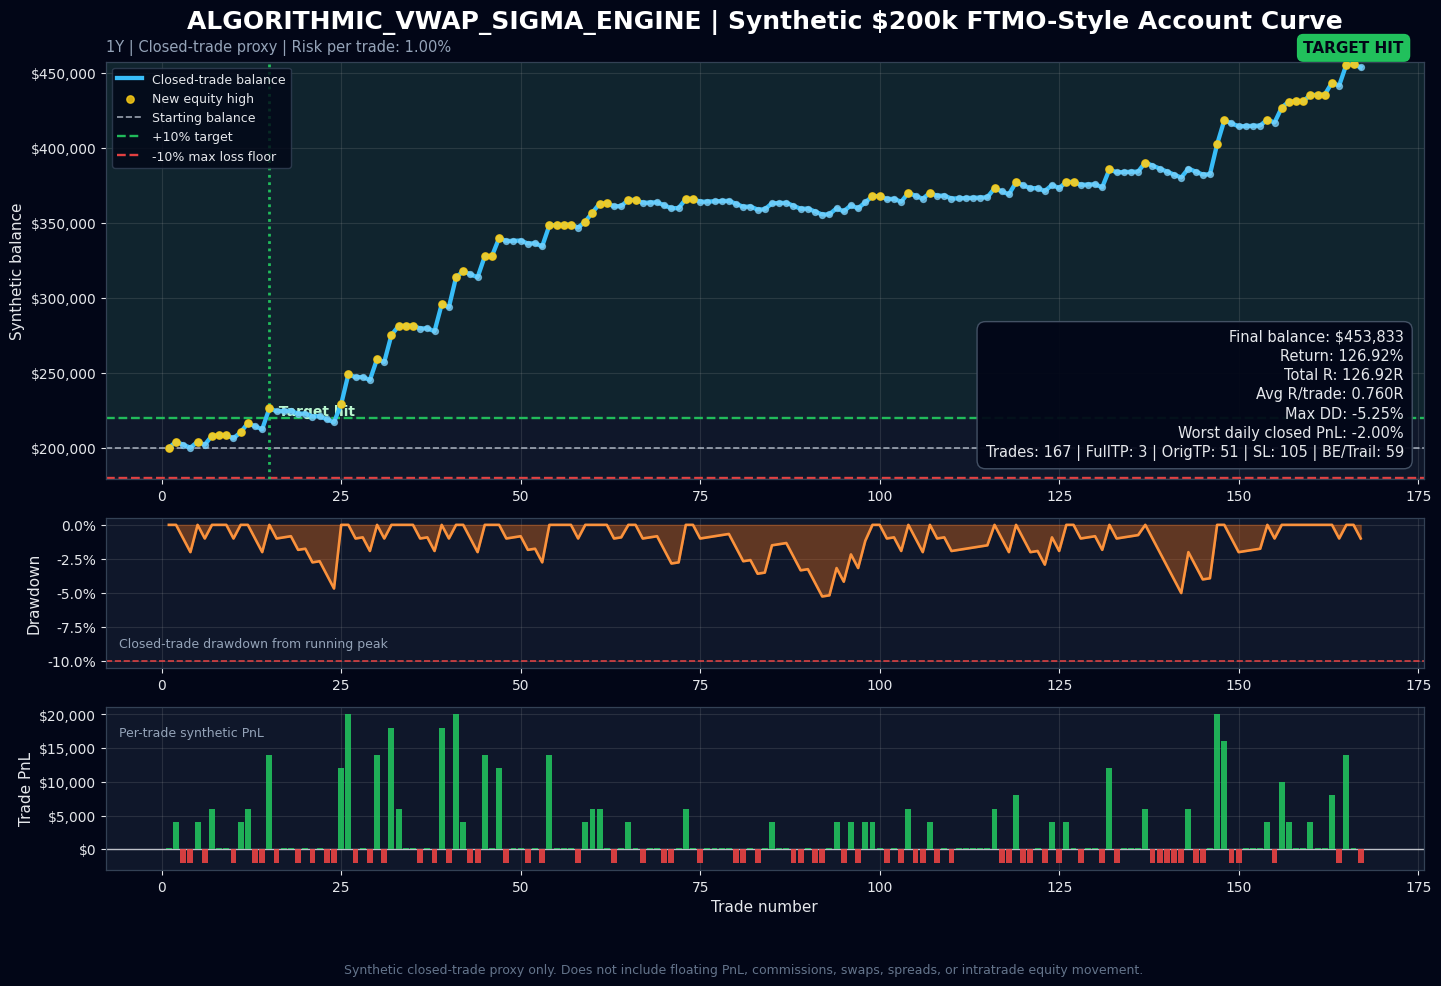

Dense-source-style return path chart created
Dataset: 1Y
Trades: 167
Total R: 126.92
Max DD %: -5.25


In [33]:
# ============================================================
# DENSE-SOURCE-STYLE RETURN PATH CHART
# ============================================================
# Purpose:
#   Restore the dense-source synthetic account/equity path chart style.
#
# Scope:
#   Presentation only. This cell reads all_trades and does not rerun or
#   change strategy logic.

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before this chart.")

if all_trades.empty:
    raise ValueError("No trades available for the dense-source-style chart.")

DENSE_SOURCE_STYLE_CHART_DATASET = "1Y"

if DENSE_SOURCE_STYLE_CHART_DATASET not in all_trades["dataset_label"].astype(str).unique():
    DENSE_SOURCE_STYLE_CHART_DATASET = str(all_trades["dataset_label"].iloc[0])

FTMO_SYNTHETIC_CONFIG = {
    "initial_balance": 200_000.0,
    "profit_target_pct": 10.0,
    "max_loss_pct": 10.0,
}


def build_dense_source_synthetic_account_curve(
    trades: pd.DataFrame,
    dataset_label: str,
    config: dict,
    synthetic_config: dict,
) -> pd.DataFrame:
    """
    Build the dense-source-style closed-trade synthetic account curve.
    """
    curve = trades.loc[
        trades["dataset_label"].astype(str).eq(str(dataset_label))
    ].copy()

    if curve.empty:
        raise ValueError(f"No trades found for dataset: {dataset_label}")

    if "entry_time" in curve.columns:
        curve = curve.sort_values("entry_time")

    curve = curve.reset_index(drop=True)

    initial_balance = float(synthetic_config["initial_balance"])

    curve["trade_number"] = np.arange(1, len(curve) + 1)

    if "account_pct" in curve.columns:
        curve["trade_account_pct"] = curve["account_pct"].astype(float)
    else:
        curve["trade_account_pct"] = (
            curve["r_multiple"].astype(float)
            * float(config.get("risk_per_trade_pct", 1.0))
        )

    curve["trade_pnl_usd"] = initial_balance * curve["trade_account_pct"] / 100.0

    curve["balance_before_trade"] = (
        initial_balance + curve["trade_pnl_usd"].cumsum().shift(fill_value=0.0)
    )

    curve["balance_after_trade"] = (
        initial_balance + curve["trade_pnl_usd"].cumsum()
    )

    curve["return_pct"] = 100.0 * (
        curve["balance_after_trade"] / initial_balance - 1.0
    )

    curve["running_peak_balance"] = curve["balance_after_trade"].cummax()

    curve["drawdown_usd"] = (
        curve["balance_after_trade"]
        - curve["running_peak_balance"]
    )

    curve["drawdown_pct_initial"] = (
        100.0 * curve["drawdown_usd"] / initial_balance
    )

    if "session_date" in curve.columns:
        curve["session_date"] = pd.to_datetime(curve["session_date"]).dt.date
    elif "exit_time" in curve.columns:
        curve["session_date"] = pd.to_datetime(curve["exit_time"]).dt.date
    else:
        curve["session_date"] = pd.RangeIndex(len(curve))

    curve["daily_closed_pnl_usd"] = curve.groupby("session_date")[
        "trade_pnl_usd"
    ].cumsum()

    curve["daily_closed_pnl_pct_initial"] = (
        100.0 * curve["daily_closed_pnl_usd"] / initial_balance
    )

    curve["is_new_equity_high"] = (
        curve["balance_after_trade"]
        >= curve["balance_after_trade"].cummax()
    )

    if "result" not in curve.columns:
        curve["result"] = ""

    if "outcome_group" not in curve.columns:
        curve["outcome_group"] = ""

    return curve


def plot_dense_source_synthetic_account_curve(
    account_curve: pd.DataFrame,
    config: dict,
    synthetic_config: dict,
    dataset_label: str,
) -> None:
    """
    Plot the dense-source-style synthetic account chart.
    """
    initial_balance = float(synthetic_config["initial_balance"])
    profit_target_pct = float(synthetic_config["profit_target_pct"])
    max_loss_pct = float(synthetic_config["max_loss_pct"])

    profit_target_balance = initial_balance * (1.0 + profit_target_pct / 100.0)
    max_loss_floor = initial_balance * (1.0 - max_loss_pct / 100.0)

    final_balance = float(account_curve["balance_after_trade"].iloc[-1])
    final_return_pct = 100.0 * (final_balance / initial_balance - 1.0)

    max_balance = float(account_curve["balance_after_trade"].max())
    min_balance = float(account_curve["balance_after_trade"].min())

    max_drawdown_pct = float(account_curve["drawdown_pct_initial"].min())

    worst_daily_closed_pnl_pct = float(
        account_curve["daily_closed_pnl_pct_initial"].min()
    )

    total_r = float(account_curve["r_multiple"].sum())
    average_r = float(account_curve["r_multiple"].mean())

    full_tp_count = int(
        account_curve["result"].astype(str).str.upper().eq("TP").sum()
    )

    original_tp_hit_count = int(
        account_curve.get(
            "hit_original_tp_before_exit",
            pd.Series(False, index=account_curve.index),
        )
        .fillna(False)
        .astype(bool)
        .sum()
    )

    full_sl_count = int(
        account_curve["outcome_group"]
        .fillna("")
        .astype(str)
        .str.upper()
        .eq("SL_FULL")
        .sum()
    )

    if full_sl_count == 0:
        full_sl_count = int(
            account_curve["result"]
            .astype(str)
            .str.upper()
            .eq("SL")
            .sum()
        )

    be_trail_count = int(
        account_curve["outcome_group"]
        .fillna("")
        .astype(str)
        .str.upper()
        .isin(["BE_FLAT", "BE_PLUS", "TRAILED_SL_PROFIT"])
        .sum()
    )

    if be_trail_count == 0:
        be_trail_count = int(
            account_curve["result"]
            .astype(str)
            .str.upper()
            .eq("BE")
            .sum()
        )

    hit_profit_target = bool(
        (account_curve["balance_after_trade"] >= profit_target_balance).any()
    )

    hit_max_loss = bool(
        (account_curve["balance_after_trade"] <= max_loss_floor).any()
    )

    if hit_max_loss:
        status = "MAX LOSS HIT"
        badge_colour = "#ef4444"
    elif hit_profit_target:
        status = "TARGET HIT"
        badge_colour = "#22c55e"
    else:
        status = "TARGET NOT HIT"
        badge_colour = "#f59e0b"

    x = account_curve["trade_number"].to_numpy()
    balance = account_curve["balance_after_trade"].astype(float).to_numpy()
    drawdown = account_curve["drawdown_pct_initial"].astype(float).to_numpy()
    pnl = account_curve["trade_pnl_usd"].astype(float).to_numpy()

    bar_colours = np.where(pnl >= 0, "#22c55e", "#ef4444")

    fig = plt.figure(figsize=(17, 10.5), facecolor="#020617")

    grid = fig.add_gridspec(
        3,
        1,
        height_ratios=[3.2, 1.15, 1.25],
        hspace=0.16,
    )

    ax_equity = fig.add_subplot(grid[0])
    ax_dd = fig.add_subplot(grid[1], sharex=ax_equity)
    ax_pnl = fig.add_subplot(grid[2], sharex=ax_equity)

    for ax in [ax_equity, ax_dd, ax_pnl]:
        ax.set_facecolor("#0f172a")
        ax.grid(True, alpha=0.16, linewidth=0.8)
        ax.tick_params(colors="#e5e7eb", labelsize=10)

        for spine in ax.spines.values():
            spine.set_color("#334155")
            spine.set_linewidth(0.9)

    # ------------------------------------------------------------------
    # Equity panel
    # ------------------------------------------------------------------
    y_top = max(max_balance, profit_target_balance) * 1.004
    y_bottom = min(min_balance, max_loss_floor) * 0.996

    ax_equity.axhspan(
        profit_target_balance,
        y_top,
        color="#22c55e",
        alpha=0.08,
    )

    ax_equity.axhspan(
        y_bottom,
        max_loss_floor,
        color="#ef4444",
        alpha=0.10,
    )

    ax_equity.plot(
        x,
        balance,
        linewidth=3.1,
        color="#38bdf8",
        label="Closed-trade balance",
        zorder=4,
    )

    ax_equity.scatter(
        x,
        balance,
        s=18,
        color="#7dd3fc",
        alpha=0.70,
        zorder=5,
    )

    new_highs = account_curve[account_curve["is_new_equity_high"]].copy()

    if len(new_highs) > 0:
        ax_equity.scatter(
            new_highs["trade_number"],
            new_highs["balance_after_trade"],
            s=28,
            color="#facc15",
            alpha=0.85,
            label="New equity high",
            zorder=6,
        )

    ax_equity.axhline(
        initial_balance,
        color="#cbd5e1",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Starting balance",
    )

    ax_equity.axhline(
        profit_target_balance,
        color="#22c55e",
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label=f"+{profit_target_pct:.0f}% target",
    )

    ax_equity.axhline(
        max_loss_floor,
        color="#ef4444",
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label=f"-{max_loss_pct:.0f}% max loss floor",
    )

    target_hits = account_curve[
        account_curve["balance_after_trade"] >= profit_target_balance
    ]

    if len(target_hits) > 0:
        first_target_trade = int(target_hits["trade_number"].iloc[0])

        ax_equity.axvline(
            first_target_trade,
            color="#22c55e",
            linestyle=":",
            linewidth=2.0,
            alpha=0.95,
            zorder=3,
        )

        ax_equity.text(
            first_target_trade,
            profit_target_balance,
            "  Target hit",
            color="#bbf7d0",
            fontsize=10,
            fontweight="bold",
            va="bottom",
            ha="left",
        )

    loss_hits = account_curve[
        account_curve["balance_after_trade"] <= max_loss_floor
    ]

    if len(loss_hits) > 0:
        first_loss_trade = int(loss_hits["trade_number"].iloc[0])

        ax_equity.axvline(
            first_loss_trade,
            color="#ef4444",
            linestyle=":",
            linewidth=2.0,
            alpha=0.95,
            zorder=3,
        )

        ax_equity.text(
            first_loss_trade,
            max_loss_floor,
            "  Max loss hit",
            color="#fecaca",
            fontsize=10,
            fontweight="bold",
            va="top",
            ha="left",
        )

    ax_equity.set_ylim(y_bottom, y_top)
    ax_equity.yaxis.set_major_formatter(FuncFormatter(usd_formatter))
    ax_equity.set_ylabel("Synthetic balance", color="#e5e7eb", fontsize=11)

    strategy_label = str(config.get("strategy_version", "vwap_sigma")).upper()

    title = (
        f"{strategy_label} | "
        f"Synthetic $200k FTMO-Style Account Curve"
    )

    subtitle = (
        f"{dataset_label} | "
        f"Closed-trade proxy | "
        f"Risk per trade: {float(config.get('risk_per_trade_pct', 1.0)):.2f}%"
    )

    ax_equity.set_title(
        title,
        color="white",
        fontsize=18,
        fontweight="bold",
        pad=24,
    )

    ax_equity.text(
        0.0,
        1.015,
        subtitle,
        transform=ax_equity.transAxes,
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="#94a3b8",
    )

    ax_equity.text(
        0.985,
        1.015,
        status,
        transform=ax_equity.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        color="#020617",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor=badge_colour,
            edgecolor=badge_colour,
            alpha=0.98,
        ),
    )

    stats_text = (
        f"Final balance: ${final_balance:,.0f}\n"
        f"Return: {final_return_pct:.2f}%\n"
        f"Total R: {total_r:.2f}R\n"
        f"Avg R/trade: {average_r:.3f}R\n"
        f"Max DD: {max_drawdown_pct:.2f}%\n"
        f"Worst daily closed PnL: {worst_daily_closed_pnl_pct:.2f}%\n"
        f"Trades: {len(account_curve)} | FullTP: {full_tp_count} | OrigTP: {original_tp_hit_count} | SL: {full_sl_count} | BE/Trail: {be_trail_count}"
    )

    ax_equity.text(
        0.985,
        0.045,
        stats_text,
        transform=ax_equity.transAxes,
        ha="right",
        va="bottom",
        fontsize=10.5,
        color="#e5e7eb",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.58",
            facecolor="#020617",
            edgecolor="#475569",
            alpha=0.94,
        ),
    )

    ax_equity.legend(
        loc="upper left",
        frameon=True,
        facecolor="#020617",
        edgecolor="#334155",
        labelcolor="#e5e7eb",
        fontsize=9,
    )

    # ------------------------------------------------------------------
    # Drawdown panel
    # ------------------------------------------------------------------
    ax_dd.fill_between(
        x,
        drawdown,
        0,
        color="#f97316",
        alpha=0.35,
        zorder=2,
    )

    ax_dd.plot(
        x,
        drawdown,
        color="#fb923c",
        linewidth=1.9,
        zorder=3,
    )

    ax_dd.axhline(
        -max_loss_pct,
        color="#ef4444",
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    ax_dd.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax_dd.set_ylabel("Drawdown", color="#e5e7eb", fontsize=11)

    ax_dd.text(
        0.01,
        0.12,
        "Closed-trade drawdown from running peak",
        transform=ax_dd.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        color="#94a3b8",
    )

    # ------------------------------------------------------------------
    # Trade PnL panel
    # ------------------------------------------------------------------
    ax_pnl.bar(
        x,
        pnl,
        color=bar_colours,
        alpha=0.88,
        width=0.82,
        zorder=3,
    )

    ax_pnl.axhline(
        0,
        color="#e5e7eb",
        linewidth=1.0,
        alpha=0.8,
    )

    ax_pnl.yaxis.set_major_formatter(FuncFormatter(usd_formatter))
    ax_pnl.set_ylabel("Trade PnL", color="#e5e7eb", fontsize=11)
    ax_pnl.set_xlabel("Trade number", color="#e5e7eb", fontsize=11)

    ax_pnl.text(
        0.01,
        0.88,
        "Per-trade synthetic PnL",
        transform=ax_pnl.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="#94a3b8",
    )

    fig.text(
        0.5,
        0.012,
        (
            "Synthetic closed-trade proxy only. "
            "Does not include floating PnL, commissions, swaps, spreads, "
            "or intratrade equity movement."
        ),
        ha="center",
        color="#64748b",
        fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


dense_source_synthetic_account_curve_df = build_dense_source_synthetic_account_curve(
    trades=all_trades,
    dataset_label=DENSE_SOURCE_STYLE_CHART_DATASET,
    config=CONFIG,
    synthetic_config=FTMO_SYNTHETIC_CONFIG,
)

plot_dense_source_synthetic_account_curve(
    account_curve=dense_source_synthetic_account_curve_df,
    config=CONFIG,
    synthetic_config=FTMO_SYNTHETIC_CONFIG,
    dataset_label=DENSE_SOURCE_STYLE_CHART_DATASET,
)

print("Dense-source-style return path chart created")
print("Dataset:", DENSE_SOURCE_STYLE_CHART_DATASET)
print("Trades:", len(dense_source_synthetic_account_curve_df))
print("Total R:", round(float(dense_source_synthetic_account_curve_df["r_multiple"].sum()), 2))
print("Max DD %:", round(float(dense_source_synthetic_account_curve_df["drawdown_pct_initial"].min()), 2))

### Core strategy visuals

This section shows the main visual summary for the current strategy configuration.

The charts use the outputs from the all-dataset runner and quick results table.

They do not rerun strategy logic, change configuration, add diagnostics, or export files.

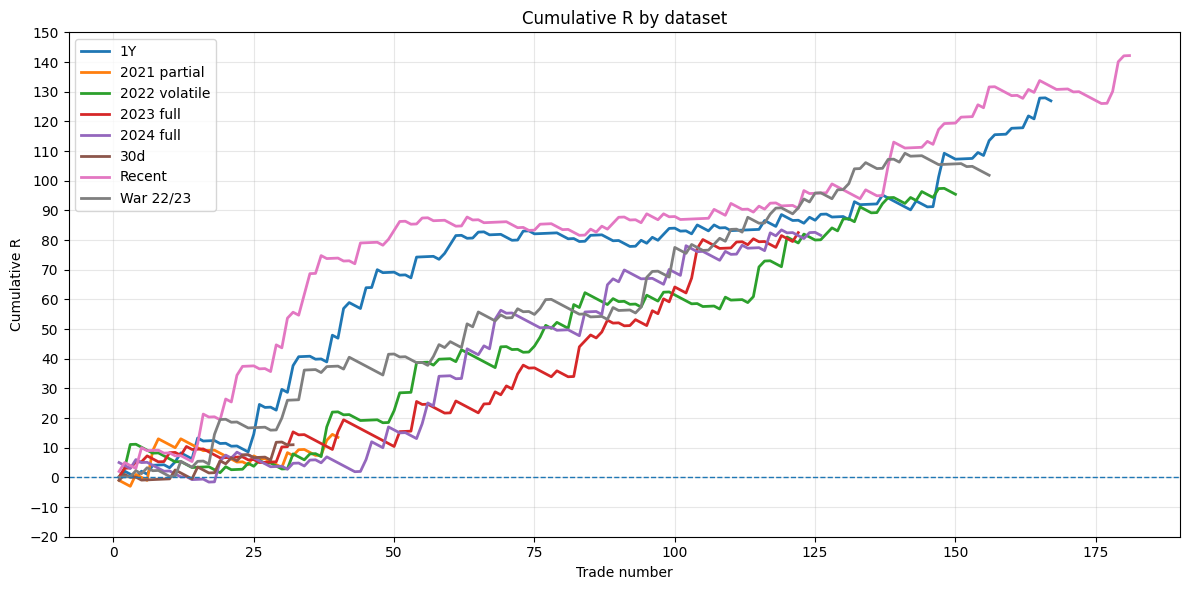

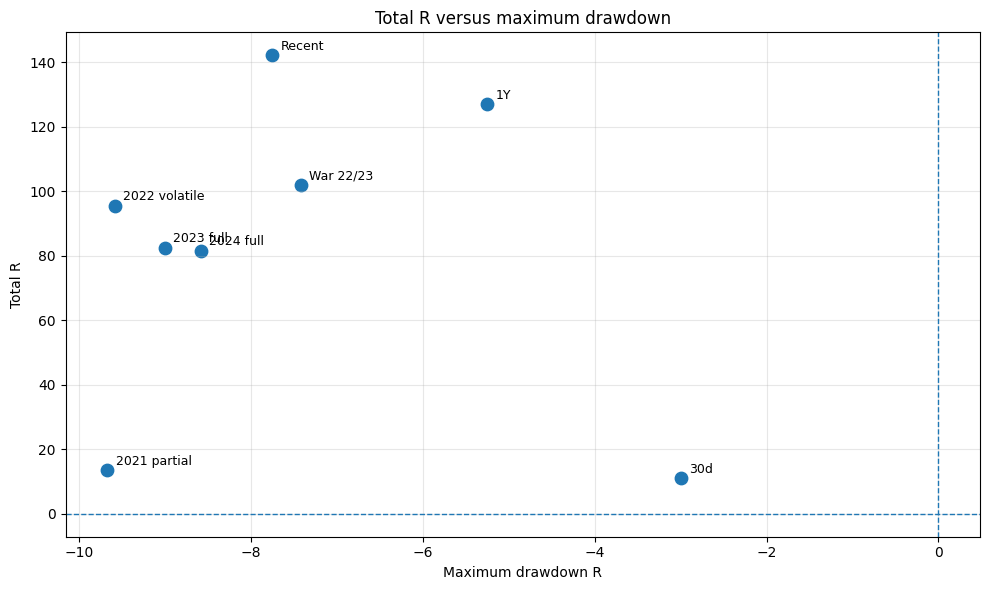

Core charts created
Datasets: 8
Trades plotted: 974


In [34]:
# ============================================================
# CORE CHARTS
# ============================================================
# Purpose:
#   Show compact visual summaries for the current strategy configuration.
#
# Scope:
#   This section reads all-dataset runner outputs only.
#   It does not rerun strategy logic, change configuration, export files,
#   or add detailed audits.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before core charts.")

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before core charts.")

if all_trades.empty:
    raise ValueError("No trades available for core charts.")

required_chart_columns = [
    "label",
    "trades",
    "total_r",
    "max_dd_r",
]

missing_chart_columns = [
    col for col in required_chart_columns
    if col not in comparison_table.columns
]

if missing_chart_columns:
    raise ValueError(f"Missing comparison table columns: {missing_chart_columns}")

if "dataset_label" not in all_trades.columns:
    raise ValueError("all_trades must include dataset_label.")

if "r_multiple" not in all_trades.columns:
    raise ValueError("all_trades must include r_multiple.")


# ------------------------------------------------------------
# Build compact chart inputs.
# ------------------------------------------------------------
equity_curve_chart_df = all_trades.copy()

equity_curve_chart_df["trade_number"] = (
    equity_curve_chart_df
    .groupby("dataset_label")
    .cumcount()
    + 1
)

equity_curve_chart_df["cumulative_r"] = (
    equity_curve_chart_df
    .groupby("dataset_label")["r_multiple"]
    .cumsum()
)

chart_summary_table = comparison_table[
    [
        "label",
        "trades",
        "total_r",
        "max_dd_r",
    ]
].copy()


# ------------------------------------------------------------
# Chart 1: cumulative R by dataset.
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

for dataset_label, dataset_trades in equity_curve_chart_df.groupby("dataset_label"):
    plt.plot(
        dataset_trades["trade_number"],
        dataset_trades["cumulative_r"],
        linewidth=2,
        label=dataset_label,
    )

plt.axhline(0, linewidth=1, linestyle="--")

# Leave visible negative-R space below zero and force a negative tick if needed.
min_cumulative_r = float(equity_curve_chart_df["cumulative_r"].min())
max_cumulative_r = float(equity_curve_chart_df["cumulative_r"].max())
y_padding = max(2.0, abs(max_cumulative_r - min_cumulative_r) * 0.05)

y_bottom = min(min_cumulative_r - y_padding, -10)
y_top = max_cumulative_r + y_padding

plt.ylim(bottom=y_bottom, top=y_top)

# Force 10-point tick spacing so negative levels like -10 appear clearly.
y_tick_start = 10 * np.floor(y_bottom / 10)
y_tick_end = 10 * np.ceil(y_top / 10)
plt.yticks(np.arange(y_tick_start, y_tick_end + 10, 10))

plt.title("Cumulative R by dataset")
plt.xlabel("Trade number")
plt.ylabel("Cumulative R")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: return versus drawdown.
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    chart_summary_table["max_dd_r"],
    chart_summary_table["total_r"],
    s=80,
)

for _, row in chart_summary_table.iterrows():
    plt.annotate(
        row["label"],
        (
            row["max_dd_r"],
            row["total_r"],
        ),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.axhline(0, linewidth=1, linestyle="--")
plt.axvline(0, linewidth=1, linestyle="--")
plt.title("Total R versus maximum drawdown")
plt.xlabel("Maximum drawdown R")
plt.ylabel("Total R")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("Core charts created")
print("Datasets:", len(chart_summary_table))
print("Trades plotted:", len(equity_curve_chart_df))

## Risk diagnostics

### Dense-source-style risk diagnostics table

This table restores the compact risk diagnostics style from the dense research notebook.

The account survival diagnostics table above remains unchanged.

In [35]:
# ============================================================
# DENSE-SOURCE-STYLE RISK DIAGNOSTICS TABLE
# ============================================================
# Purpose:
#   Display dense-source-style risk diagnostics while keeping the compact
#   account survival diagnostics table.
#
# Scope:
#   Presentation only. This cell does not rerun or change strategy logic.

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before this table.")

dense_source_style_risk_diagnostics_table = build_dense_source_style_risk_table(
    all_trades,
)

print("Dense-source-style risk diagnostics table")
display(dense_source_style_risk_diagnostics_table)

Dense-source-style risk diagnostics table


,Dataset,Trades,Max Consecutive Full SL,Max Consecutive Stop Exits,Worst No-TP Run R,Max Equity Drawdown R,Worst No-TP Run %,Max Drawdown %
0,30d,32,3,32,-1.000000,-3.000000,-1.00%,-3.00%
1,1Y,167,5,105,-1.916667,-5.250000,-1.92%,-5.25%
2,2021 partial,40,4,33,-5.666667,-9.666667,-5.67%,-9.67%
3,2022 volatile,150,6,60,-2.000000,-9.583333,-2.00%,-9.58%
4,War 22/23,156,6,60,-2.000000,-7.416667,-2.00%,-7.42%
5,Recent,181,5,106,-1.916667,-7.750000,-1.92%,-7.75%
6,2023 full,122,9,53,-3.916667,-9.000000,-3.92%,-9.00%
7,2024 full,126,5,57,-5.583333,-8.583333,-5.58%,-8.58%


### Compact risk diagnostics

This section summarises risk from the all-dataset trade outputs.

It focuses on drawdown, loss clustering, worst trade behaviour, and account-level sensitivity to different risk-per-trade assumptions.

No strategy logic is rerun or changed here.

In [36]:
# ============================================================
# RISK DIAGNOSTICS
# ============================================================
# Purpose:
#   Provide compact risk diagnostics from the all-dataset runner outputs.
#
# Scope:
#   This section does not rerun strategy logic, change configuration,
#   export files, add audits, or create charts.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before risk diagnostics.")

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before risk diagnostics.")

if all_trades.empty:
    raise ValueError("No trades available for risk diagnostics.")

required_risk_columns = [
    "dataset_label",
    "r_multiple",
]

missing_risk_columns = [
    col for col in required_risk_columns
    if col not in all_trades.columns
]

if missing_risk_columns:
    raise ValueError(f"Missing risk diagnostic columns: {missing_risk_columns}")


def max_consecutive_condition(values: pd.Series, condition_func) -> int:
    """
    Return the longest consecutive run where condition_func(value) is True.
    """
    max_run = 0
    current_run = 0

    for value in values:
        if condition_func(value):
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0

    return int(max_run)


def closed_trade_drawdown_series(trades: pd.DataFrame) -> pd.Series:
    """
    Return closed-trade drawdown in R for a sequence of trades.
    """
    if trades.empty:
        return pd.Series(dtype=float)

    equity = trades["r_multiple"].astype(float).cumsum()
    running_peak = equity.cummax()

    return equity - running_peak


risk_diagnostic_rows = []

for dataset_label, dataset_trades in all_trades.groupby("dataset_label", sort=False):
    dataset_trades = dataset_trades.copy()

    r_values = dataset_trades["r_multiple"].astype(float)
    drawdown = closed_trade_drawdown_series(dataset_trades)

    positive_trades = int((r_values > 0).sum())
    losing_trades = int((r_values < 0).sum())
    full_loss_trades = int((r_values <= -0.99).sum())

    risk_diagnostic_rows.append(
        {
            "Dataset": dataset_label,
            "Trades": int(len(dataset_trades)),
            "Total R": round(float(r_values.sum()), 2),
            "Max DD R": round(float(drawdown.min()), 2),
            "Worst trade R": round(float(r_values.min()), 2),
            "Best trade R": round(float(r_values.max()), 2),
            "Average R": round(float(r_values.mean()), 3),
            "Positive exits": positive_trades,
            "Losing exits": losing_trades,
            "Full losses": full_loss_trades,
            "Positive exit %": round(positive_trades / len(dataset_trades) * 100, 2),
            "Max consecutive losing exits": max_consecutive_condition(
                r_values,
                lambda value: value < 0,
            ),
            "Max consecutive full losses": max_consecutive_condition(
                r_values,
                lambda value: value <= -0.99,
            ),
        }
    )

risk_diagnostics_table = pd.DataFrame(risk_diagnostic_rows)


# ------------------------------------------------------------
# Account survival sensitivity.
# ------------------------------------------------------------
# These are risk-per-trade assumptions only.
# They do not change strategy logic or trade outcomes.
risk_per_trade_scenarios_pct = [0.25, 0.50, 0.75, 1.00]

account_survival_rows = []

for _, row in risk_diagnostics_table.iterrows():
    for risk_per_trade_pct in risk_per_trade_scenarios_pct:
        estimated_account_dd_pct = abs(float(row["Max DD R"])) * risk_per_trade_pct
        estimated_account_return_pct = float(row["Total R"]) * risk_per_trade_pct

        account_survival_rows.append(
            {
                "Dataset": row["Dataset"],
                "Risk per trade %": risk_per_trade_pct,
                "Estimated return %": round(estimated_account_return_pct, 2),
                "Estimated max DD %": round(estimated_account_dd_pct, 2),
                "Within 5% daily/loss-style limit": estimated_account_dd_pct <= 5.0,
                "Within 10% max-loss-style limit": estimated_account_dd_pct <= 10.0,
            }
        )

account_survival_diagnostics_table = pd.DataFrame(account_survival_rows)


# ------------------------------------------------------------
# Compact display.
# ------------------------------------------------------------
print("Risk diagnostics")
print("Datasets:", risk_diagnostics_table["Dataset"].nunique())
print("Total trades:", int(risk_diagnostics_table["Trades"].sum()))
print()

print("Risk diagnostics table:")
display(risk_diagnostics_table)

print("Account survival diagnostics:")
display(account_survival_diagnostics_table)

Risk diagnostics
Datasets: 8
Total trades: 974

Risk diagnostics table:


,Dataset,Trades,Total R,Max DD R,Worst trade R,Best trade R,Average R,Positive exits,Losing exits,Full losses,Positive exit %,Max consecutive losing exits,Max consecutive full losses
0,30d,32,11.00,-3.00,-1.0,6.0,0.344,19,13,13,59.38,3,3
1,1Y,167,126.92,-5.25,-1.0,10.0,0.760,103,64,64,61.68,5,5
2,2021 partial,40,13.50,-9.67,-1.0,10.0,0.338,15,25,25,37.50,4,4
3,2022 volatile,150,95.42,-9.58,-1.0,10.0,0.636,80,70,70,53.33,6,6
4,War 22/23,156,101.83,-7.42,-1.0,10.0,0.653,88,68,68,56.41,6,6
5,Recent,181,142.17,-7.75,-1.0,10.0,0.785,109,72,72,60.22,5,5
6,2023 full,122,82.50,-9.00,-1.0,10.0,0.676,64,58,58,52.46,9,9
7,2024 full,126,81.58,-8.58,-1.0,10.0,0.647,60,66,66,47.62,5,5


Account survival diagnostics:


,Dataset,Risk per trade %,Estimated return %,Estimated max DD %,Within 5% daily/loss-style limit,Within 10% max-loss-style limit
0,30d,0.25,2.75,0.75,True,True
1,30d,0.50,5.50,1.50,True,True
2,30d,0.75,8.25,2.25,True,True
3,30d,1.00,11.00,3.00,True,True
4,1Y,0.25,31.73,1.31,True,True
5,1Y,0.50,63.46,2.62,True,True
6,1Y,0.75,95.19,3.94,True,True
7,1Y,1.00,126.92,5.25,False,True
8,2021 partial,0.25,3.38,2.42,True,True
9,2021 partial,0.50,6.75,4.83,True,True


## Audits and detailed diagnostics

These sections explain why the model did or did not trade.

They are detailed diagnostics, not the first results the user should see.

### Raw signal audit

This audit summarises how raw continuation signals move through router selection and execution blocking.

It shows raw signals, selected signals, executed trades, generation blocks, and execution blocks.

In [37]:
# ============================================================
# RAW SIGNAL AUDIT
# ============================================================
# Purpose:
#   Summarise how signals move from raw continuation candidates to executed trades.
#
# Scope:
#   Diagnostic only. This cell does not rerun or change strategy logic.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before audits.")

if "audit_outputs" not in globals():
    raise ValueError("Run the all-dataset experiment runner before audits.")

signal_block_counts_df = audit_outputs.get(
    "signal_block_counts",
    pd.DataFrame(),
)

execution_skip_counts_df = audit_outputs.get(
    "execution_skip_counts",
    pd.DataFrame(),
)

raw_signal_audit_table = comparison_table[
    [
        "label",
        "raw_signals",
        "final_signals",
        "trades",
        "skipped_generation_signals",
        "skipped_execution_signals",
    ]
].copy()

raw_signal_audit_table = raw_signal_audit_table.rename(
    columns={
        "label": "Dataset",
        "raw_signals": "Raw continuation signals",
        "final_signals": "Final selected continuation",
        "trades": "Executed continuation trades",
        "skipped_generation_signals": "Skipped before execution",
        "skipped_execution_signals": "Skipped during execution",
    }
)


def count_signal_block_reason(block_counts: pd.DataFrame, reason_match: str) -> pd.DataFrame:
    """
    Count signal-generation block reasons by dataset using substring matching.
    """
    if block_counts.empty:
        return pd.DataFrame(columns=["Dataset", reason_match])

    temp = block_counts.copy()
    temp["block_reason"] = temp["block_reason"].fillna("UNKNOWN").astype(str)

    matched = temp.loc[
        temp["block_reason"].str.contains(reason_match, case=False, regex=False)
    ]

    if matched.empty:
        return pd.DataFrame(
            {
                "Dataset": raw_signal_audit_table["Dataset"],
                reason_match: 0,
            }
        )

    out = (
        matched
        .groupby("dataset_label", as_index=False)["signals"]
        .sum()
        .rename(
            columns={
                "dataset_label": "Dataset",
                "signals": reason_match,
            }
        )
    )

    return out


def count_execution_skip_reason(skip_counts: pd.DataFrame, exact_reason: str, output_name: str) -> pd.DataFrame:
    """
    Count execution skip reasons by dataset using an exact skip-reason label.
    """
    if skip_counts.empty:
        return pd.DataFrame(
            {
                "Dataset": raw_signal_audit_table["Dataset"],
                output_name: 0,
            }
        )

    temp = skip_counts.copy()
    temp["skip_reason"] = temp["skip_reason"].fillna("UNKNOWN").astype(str)

    matched = temp.loc[temp["skip_reason"].eq(exact_reason)]

    if matched.empty:
        return pd.DataFrame(
            {
                "Dataset": raw_signal_audit_table["Dataset"],
                output_name: 0,
            }
        )

    out = (
        matched
        .groupby("dataset_label", as_index=False)["signals"]
        .sum()
        .rename(
            columns={
                "dataset_label": "Dataset",
                "signals": output_name,
            }
        )
    )

    return out


strategy_filter_blocks = count_signal_block_reason(
    signal_block_counts_df,
    "STRATEGY_FILTER_BLOCKED",
).rename(columns={"STRATEGY_FILTER_BLOCKED": "Skipped by strategy filter"})

clean_state_blocks = count_signal_block_reason(
    signal_block_counts_df,
    "CLEAN",
).rename(columns={"CLEAN": "Skipped by clean-state filter"})

open_full_risk_blocks = count_execution_skip_reason(
    execution_skip_counts_df,
    "BLOCKED_OPEN_FULL_RISK_TRADE",
    "Skipped by open full-risk trade",
)

protected_addon_blocks = count_execution_skip_reason(
    execution_skip_counts_df,
    "ACTIVE_TRADE_ALREADY_OPEN",
    "Skipped by open protected trade with add-ons disabled",
)

raw_signal_audit_table = (
    raw_signal_audit_table
    .merge(strategy_filter_blocks, on="Dataset", how="left")
    .merge(clean_state_blocks, on="Dataset", how="left")
    .merge(open_full_risk_blocks, on="Dataset", how="left")
    .merge(protected_addon_blocks, on="Dataset", how="left")
)

audit_count_columns = [
    "Skipped by strategy filter",
    "Skipped by clean-state filter",
    "Skipped by open full-risk trade",
    "Skipped by open protected trade with add-ons disabled",
]

for col in audit_count_columns:
    raw_signal_audit_table[col] = raw_signal_audit_table[col].fillna(0).astype(int)

print("Raw signal audit")
display(raw_signal_audit_table)

Raw signal audit


,Dataset,Raw continuation signals,Final selected continuation,Executed continuation trades,Skipped before execution,Skipped during execution,Skipped by strategy filter,Skipped by clean-state filter,Skipped by open full-risk trade,Skipped by open protected trade with add-ons disabled
0,30d,99,34,32,65,2,36,29,2,0
1,1Y,621,220,167,401,53,272,129,44,9
2,2021 partial,169,61,40,108,21,77,31,11,9
3,2022 volatile,609,199,150,410,49,271,139,36,11
4,War 22/23,619,211,156,408,55,275,133,41,13
5,Recent,659,242,181,417,61,277,140,49,12
6,2023 full,609,187,122,422,65,353,69,38,26
7,2024 full,538,162,126,376,36,280,96,26,9


### Missed continuation candidate audit

This audit lists candles that looked directionally relevant but did not become final continuation trades.

It is diagnostic only. It does not change strategy logic, signal generation, routing, execution, stops, targets, or results.

In [38]:
# ============================================================
# MISSED CONTINUATION CANDIDATE AUDIT
# ============================================================
# Purpose:
#   Show candles that looked directionally relevant but failed before becoming
#   raw/final continuation signals.
#
# Scope:
#   Diagnostic only. This cell does not change strategy logic, routing,
#   execution, stops, targets, or runner behaviour.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the missed-candidate audit.")

MISSED_CONTINUATION_AUDIT_RECENT_ROWS = 2500
MISSED_CONTINUATION_AUDIT_DISPLAY_ROWS = 80


def audit_safe_series(df: pd.DataFrame, column: str, default_value=np.nan) -> pd.Series:
    """
    Return an existing column, or a default-filled Series if the column is missing.
    """
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def audit_bool_series(df: pd.DataFrame, column: str) -> pd.Series:
    """
    Return a boolean Series for an audit flag.
    Missing columns are treated as False.
    """
    return (
        audit_safe_series(df, column, False)
        .fillna(False)
        .astype(bool)
    )


def audit_numeric_series(df: pd.DataFrame, column: str) -> pd.Series:
    """
    Return a numeric Series for audit display.
    Missing columns are treated as NaN.
    """
    return pd.to_numeric(
        audit_safe_series(df, column, np.nan),
        errors="coerce",
    )


def audit_text_series(df: pd.DataFrame, column: str, default_value: str = "not_available") -> pd.Series:
    """
    Return a text Series for audit display.
    Missing columns are filled with a readable default.
    """
    return (
        audit_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


def audit_first_available_text(
    df: pd.DataFrame,
    columns: list[str],
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return the first available non-empty text value from a list of possible columns.
    """
    out = pd.Series(default_value, index=df.index, dtype="object")

    for column in columns:
        if column not in df.columns:
            continue

        candidate = df[column].fillna("").astype(str)
        usable = candidate.ne("") & candidate.ne("nan") & candidate.ne("None")
        out = np.where(
            (pd.Series(out, index=df.index).astype(str) == default_value) & usable,
            candidate,
            out,
        )
        out = pd.Series(out, index=df.index, dtype="object")

    return out.fillna(default_value).astype(str)


def audit_safe_bool_value(value) -> bool:
    """
    Convert one value to a strict audit bool.
    NaN/None are treated as False.
    """
    if pd.isna(value):
        return False

    return bool(value)


def build_missed_continuation_side_audit(
    df: pd.DataFrame,
    side: str,
) -> pd.DataFrame:
    """
    Build one directional audit table.

    One candle can appear twice if both long and short context are present.
    This is intentional because the failed reasons are direction-specific.
    """
    if side not in {"long", "short"}:
        raise ValueError("side must be 'long' or 'short'.")

    if side == "long":
        raw_col = "raw_long_green_reclaim"
        touch_col = "long_touched_upper_green"
        close_green_col = "long_closed_above_upper_green"
        vwap_accept_col = "v3_long_vwap_acceptance_pass"
        red_shift_col = "v3_long_directional_red_shift"
        red_shift_pass_col = "v3_long_directional_red_shift_pass"
        quality_col = "v3_long_v1_execution_quality_pass"
        body_col = "long_body_valid"
        orange_col = "long_not_orange_chase"
        extension_col = "long_extension_valid"
        a_tier_extension_col = "v3_long_a_tier_extension_valid"
        close_through_col = "long_close_through_green_points"
        close_through_valid_col = "long_close_through_green_valid"
        extension_points_col = "long_extension_from_green_points"
        trend_health_col = "v2_long_healthy_continuation_pass"
        second_close_col = "v3_long_second_close_timing_pass"
        fast_reclaim_col = "a_tier_fast_reclaim_long_passed"
        delayed_pullback_col = "a_tier_delayed_pullback_long_passed"

        directional_context = (
            audit_bool_series(df, "accepted_above_vwap")
            | (audit_numeric_series(df, "close") > audit_numeric_series(df, "vwap"))
            | audit_bool_series(df, touch_col)
            | audit_bool_series(df, close_green_col)
            | audit_bool_series(df, second_close_col)
            | audit_bool_series(df, fast_reclaim_col)
            | audit_bool_series(df, delayed_pullback_col)
            | audit_bool_series(df, raw_col)
        )

    else:
        raw_col = "raw_short_green_rejection"
        touch_col = "short_touched_lower_green"
        close_green_col = "short_closed_below_lower_green"
        vwap_accept_col = "v3_short_vwap_acceptance_pass"
        red_shift_col = "v3_short_directional_red_shift"
        red_shift_pass_col = "v3_short_directional_red_shift_pass"
        quality_col = "v3_short_v1_execution_quality_pass"
        body_col = "short_body_valid"
        orange_col = "short_not_orange_chase"
        extension_col = "short_extension_valid"
        a_tier_extension_col = "v3_short_a_tier_extension_valid"
        close_through_col = "short_close_through_green_points"
        close_through_valid_col = "short_close_through_green_valid"
        extension_points_col = "short_extension_from_green_points"
        trend_health_col = "v2_short_healthy_continuation_pass"
        second_close_col = "v3_short_second_close_timing_pass"
        fast_reclaim_col = "a_tier_fast_reclaim_short_passed"
        delayed_pullback_col = "a_tier_delayed_pullback_short_passed"

        directional_context = (
            audit_bool_series(df, "accepted_below_vwap")
            | (audit_numeric_series(df, "close") < audit_numeric_series(df, "vwap"))
            | audit_bool_series(df, touch_col)
            | audit_bool_series(df, close_green_col)
            | audit_bool_series(df, second_close_col)
            | audit_bool_series(df, fast_reclaim_col)
            | audit_bool_series(df, delayed_pullback_col)
            | audit_bool_series(df, raw_col)
        )

    raw_signal_name = audit_text_series(df, "raw_signal_name", "NO_SIGNAL")
    final_signal_name = audit_text_series(df, "v1_signal_name", "NO_SIGNAL")

    raw_side = audit_bool_series(df, raw_col)
    final_selected = final_signal_name.ne("NO_SIGNAL")

    stage = np.select(
        [
            final_selected,
            raw_side & ~final_selected,
            ~raw_side,
        ],
        [
            "FINAL_SIGNAL",
            "RAW_BUT_BLOCKED",
            "NO_RAW_CANDIDATE",
        ],
        default="UNKNOWN",
    )

    out = pd.DataFrame(
        {
            "time": audit_safe_series(df, "datetime", pd.NaT),
            "direction": side,
            "open": audit_numeric_series(df, "open"),
            "high": audit_numeric_series(df, "high"),
            "low": audit_numeric_series(df, "low"),
            "close": audit_numeric_series(df, "close"),

            "regime": audit_first_available_text(
                df,
                ["regime_20m", "v5_regime_20m", "v4_preliminary_regime_label"],
                "not_available",
            ),
            "possible_chop": audit_bool_series(df, "possible_chop"),
            "trend_health": audit_bool_series(df, trend_health_col),

            "long_raw": audit_bool_series(df, "raw_long_green_reclaim"),
            "short_raw": audit_bool_series(df, "raw_short_green_rejection"),
            "directional_raw": raw_side,
            "stage": stage,

            "raw_continuation_requires_red_shift": bool(
                CONFIG.get("raw_continuation_requires_red_shift", True)
            ),

            "red_shift": audit_numeric_series(df, red_shift_col),
            "red_shift_pass": audit_bool_series(df, red_shift_pass_col),

            # Diagnostic approximation:
            # True means the visible raw-continuation audit checks pass
            # except for directional red_shift_pass.
            "would_pass_visible_raw_checks_without_red_shift": (
                audit_bool_series(df, touch_col)
                & audit_bool_series(df, vwap_accept_col)
                & audit_bool_series(df, quality_col)
                & audit_bool_series(df, body_col)
                & audit_bool_series(df, orange_col)
                & audit_bool_series(df, extension_col)
                & audit_bool_series(df, close_through_valid_col)
            ),

            "failed_only_visible_raw_red_shift_pass": (
                ~audit_bool_series(df, red_shift_pass_col)
                & audit_bool_series(df, touch_col)
                & audit_bool_series(df, vwap_accept_col)
                & audit_bool_series(df, quality_col)
                & audit_bool_series(df, body_col)
                & audit_bool_series(df, orange_col)
                & audit_bool_series(df, extension_col)
                & audit_bool_series(df, close_through_valid_col)
            ),

            "touch_pass": audit_bool_series(df, touch_col),
            "vwap_acceptance": audit_bool_series(df, vwap_accept_col),
            "quality_pass": audit_bool_series(df, quality_col),
            "body_valid": audit_bool_series(df, body_col),
            "not_orange_chase": audit_bool_series(df, orange_col),
            "extension_valid": audit_bool_series(df, extension_col),
            "a_tier_extension_valid": audit_bool_series(df, a_tier_extension_col),
            "close_through_valid": audit_bool_series(df, close_through_valid_col),

            "close_through": audit_numeric_series(df, close_through_col),
            "extension": audit_numeric_series(df, extension_points_col),

            "setup_family": audit_text_series(df, "setup_family", "not_classified"),
            "setup_source": audit_text_series(df, "setup_source", "not_classified"),
            "router_decision": audit_first_available_text(
                df,
                ["router_decision", "v4_model_route"],
                "not_available",
            ),
            "selected_entry_module": audit_text_series(
                df,
                "v4_selected_entry_module",
                "not_available",
            ),
            "raw_signal_name": raw_signal_name,
            "final_selected_signal": final_signal_name,
            "signal_block_reason": audit_text_series(
                df,
                "v1_signal_block_reason",
                "not_available",
            ),

            "directional_context": directional_context,
        },
        index=df.index,
    )

    return out


def missed_continuation_failed_reasons(row: pd.Series) -> str:
    """
    Build a readable reason list for why a directional context row did not pass.
    """
    failed = []

    checks = [
        ("red_shift_pass", row.get("red_shift_pass", False)),
        ("touch_pass", row.get("touch_pass", False)),
        ("vwap_acceptance", row.get("vwap_acceptance", False)),
        ("quality_pass", row.get("quality_pass", False)),
        ("body_valid", row.get("body_valid", False)),
        ("not_orange_chase", row.get("not_orange_chase", False)),
        ("extension_valid", row.get("extension_valid", False)),
        ("close_through_valid", row.get("close_through_valid", False)),
    ]

    for label, passed in checks:
        if not audit_safe_bool_value(passed):
            failed.append(label)

    if audit_safe_bool_value(row.get("possible_chop", False)):
        failed.append("possible_chop")

    signal_block_reason = str(row.get("signal_block_reason", ""))
    if (
        signal_block_reason
        and signal_block_reason not in {"NO_RAW_SIGNAL", "VALID_SIGNAL", "not_available"}
    ):
        failed.append(signal_block_reason)

    if not failed:
        if row.get("stage") == "FINAL_SIGNAL":
            return "passed_to_final_signal"

        if row.get("stage") == "RAW_BUT_BLOCKED":
            return "raw_candidate_blocked_after_generation"

        return "no_failed_component_identified"

    return " | ".join(failed)


audit_source_df = signals_df.copy()

if MISSED_CONTINUATION_AUDIT_RECENT_ROWS is not None:
    audit_source_df = audit_source_df.tail(MISSED_CONTINUATION_AUDIT_RECENT_ROWS).copy()

missed_long_audit = build_missed_continuation_side_audit(audit_source_df, "long")
missed_short_audit = build_missed_continuation_side_audit(audit_source_df, "short")

missed_continuation_candidate_audit_table = pd.concat(
    [missed_long_audit, missed_short_audit],
    ignore_index=True,
)

missed_continuation_candidate_audit_table["failed_reasons"] = (
    missed_continuation_candidate_audit_table.apply(
        missed_continuation_failed_reasons,
        axis=1,
    )
)

# Keep the audit focused on candles that were at least directionally relevant,
# but did not become final selected continuation signals.
missed_continuation_candidate_audit_table = missed_continuation_candidate_audit_table.loc[
    missed_continuation_candidate_audit_table["directional_context"]
    & missed_continuation_candidate_audit_table["stage"].isin(
        ["NO_RAW_CANDIDATE", "RAW_BUT_BLOCKED"]
    )
].copy()

missed_continuation_candidate_audit_table = (
    missed_continuation_candidate_audit_table
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

missed_continuation_failed_reason_counts = (
    missed_continuation_candidate_audit_table["failed_reasons"]
    .str.split(" | ", regex=False)
    .explode()
    .value_counts()
    .rename_axis("failed_reason")
    .reset_index(name="rows")
)

print("Missed continuation candidate failed-reason counts")
display(missed_continuation_failed_reason_counts)

print(
    "Missed continuation candidate audit "
    f"(latest {MISSED_CONTINUATION_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    missed_continuation_candidate_audit_table.head(
        MISSED_CONTINUATION_AUDIT_DISPLAY_ROWS
    )
)

Missed continuation candidate failed-reason counts


,failed_reason,rows
0,red_shift_pass,4824
1,quality_pass,4769
2,close_through_valid,3559
3,possible_chop,2750
4,vwap_acceptance,2590
5,touch_pass,1254
6,extension_valid,1127
7,body_valid,1114
8,not_orange_chase,824
9,STRATEGY_FILTER_BLOCKED,18


Missed continuation candidate audit (latest 80 rows shown)


,time,direction,open,high,low,close,regime,possible_chop,trend_health,long_raw,short_raw,directional_raw,stage,raw_continuation_requires_red_shift,red_shift,red_shift_pass,would_pass_visible_raw_checks_without_red_shift,failed_only_visible_raw_red_shift_pass,touch_pass,vwap_acceptance,quality_pass,body_valid,not_orange_chase,extension_valid,a_tier_extension_valid,close_through_valid,close_through,extension,setup_family,setup_source,router_decision,selected_entry_module,raw_signal_name,final_selected_signal,signal_block_reason,directional_context,failed_reasons
0,2026-05-15 16:29:00+00:00,short,29163.45,29185.35,29162.35,29179.55,chop,False,False,False,False,False,NO_RAW_CANDIDATE,True,13.345535,True,False,False,True,False,False,True,True,True,True,False,-70.517713,-70.517713,NONE,NO_SIGNAL,chop_no_trade,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,vwap_acceptance | quality_pass | close_through...
1,2026-05-15 16:29:00+00:00,long,29163.45,29185.35,29162.35,29179.55,chop,False,False,False,False,False,NO_RAW_CANDIDATE,True,13.785955,True,False,False,True,True,False,True,True,True,True,False,-5.180812,-5.180812,NONE,NO_SIGNAL,chop_no_trade,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,quality_pass | close_through_valid
2,2026-05-15 16:28:00+00:00,long,29123.25,29163.45,29123.25,29163.05,extreme_news,False,False,False,False,False,NO_RAW_CANDIDATE,True,11.314602,True,False,False,True,False,False,True,True,True,True,False,-16.938687,-16.938687,NONE,NO_SIGNAL,no_trade,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,vwap_acceptance | quality_pass | close_through...
3,2026-05-15 16:28:00+00:00,short,29123.25,29163.45,29123.25,29163.05,extreme_news,False,False,False,False,False,NO_RAW_CANDIDATE,True,11.265438,True,False,False,True,False,False,True,True,True,True,False,-49.716008,-49.716008,NONE,NO_SIGNAL,no_trade,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,vwap_acceptance | quality_pass | close_through...
4,2026-05-15 16:27:00+00:00,long,29138.05,29141.25,29121.05,29123.05,chop,False,False,False,False,False,NO_RAW_CANDIDATE,True,1.733524,False,False,False,True,False,False,True,True,True,True,False,-53.150764,-53.150764,NONE,NO_SIGNAL,chop_no_trade,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,red_shift_pass | vwap_acceptance | quality_pas...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2026-05-15 15:52:00+00:00,long,29070.95,29083.85,29069.35,29082.95,calm_trend,False,False,False,False,False,NO_RAW_CANDIDATE,True,-2.444168,False,False,False,True,False,False,True,True,True,True,False,-107.140534,-107.140534,NONE,NO_SIGNAL,calm_trend_v1,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,red_shift_pass | vwap_acceptance | quality_pas...
76,2026-05-15 15:51:00+00:00,short,29062.25,29073.45,29059.55,29071.25,calm_trend,False,False,False,False,False,NO_RAW_CANDIDATE,True,-1.463225,False,False,False,False,True,False,True,False,False,False,True,58.415957,58.415957,NONE,NO_SIGNAL,calm_trend_v1,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,red_shift_pass | touch_pass | quality_pass | n...
77,2026-05-15 15:51:00+00:00,long,29062.25,29073.45,29059.55,29071.25,calm_trend,False,False,False,False,False,NO_RAW_CANDIDATE,True,-2.843191,False,False,False,True,False,False,True,True,True,True,False,-120.039518,-120.039518,NONE,NO_SIGNAL,calm_trend_v1,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,red_shift_pass | vwap_acceptance | quality_pas...
78,2026-05-15 15:50:00+00:00,short,29052.25,29063.85,29050.55,29062.85,calm_trend,False,False,False,False,False,NO_RAW_CANDIDATE,True,-1.251510,False,False,False,False,True,False,True,False,False,False,True,66.788204,66.788204,NONE,NO_SIGNAL,calm_trend_v1,none,NO_SIGNAL,NO_SIGNAL,NO_RAW_SIGNAL,True,red_shift_pass | touch_pass | quality_pass | n...


### Candle-close band snapshot audit

This audit records the exact OHLC, VWAP, sigma-band, and red-band shift values available at each candle close.

It is diagnostic only. It does not change strategy logic, signal generation, routing, execution, stops, targets, or results.

In [39]:
# ============================================================
# CANDLE-CLOSE BAND SNAPSHOT AUDIT
# ============================================================
# Purpose:
#   Capture the exact candle-close OHLC, VWAP, sigma-band, and band-shift
#   values used by the notebook at signal time.
#
# Scope:
#   Diagnostic only. This cell does not change strategy logic, routing,
#   execution, stops, targets, or runner behaviour.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the candle-close band snapshot audit.")

BAND_SNAPSHOT_AUDIT_RECENT_ROWS = 2500
BAND_SNAPSHOT_AUDIT_DISPLAY_ROWS = 80


def band_snapshot_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    """
    Return an existing column, or a default-filled Series if the column is missing.
    """
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def band_snapshot_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    """
    Return a numeric Series for audit display.
    Missing columns are treated as NaN.
    """
    return pd.to_numeric(
        band_snapshot_safe_series(df, column, np.nan),
        errors="coerce",
    )


def band_snapshot_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    """
    Return a boolean Series for audit display.
    Missing columns are filled with default_value.
    """
    return (
        band_snapshot_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def band_snapshot_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return a text Series for audit display.
    Missing columns are filled with a readable default.
    """
    return (
        band_snapshot_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


band_snapshot_source_df = signals_df.copy()

band_snapshot_shift_lookback = int(CONFIG.get("shift_lookback", 1))

required_band_snapshot_columns = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "lower_green",
    "upper_orange",
    "lower_orange",
    "upper_red",
    "lower_red",
]

missing_band_snapshot_columns = [
    column for column in required_band_snapshot_columns
    if column not in band_snapshot_source_df.columns
]

if missing_band_snapshot_columns:
    raise ValueError(
        "Missing band snapshot columns: "
        + ", ".join(missing_band_snapshot_columns)
    )

if BAND_SNAPSHOT_AUDIT_RECENT_ROWS is not None:
    band_snapshot_source_df = (
        band_snapshot_source_df
        .tail(BAND_SNAPSHOT_AUDIT_RECENT_ROWS)
        .copy()
    )

upper_red_now = band_snapshot_numeric_series(band_snapshot_source_df, "upper_red")
lower_red_now = band_snapshot_numeric_series(band_snapshot_source_df, "lower_red")

upper_red_previous_1bar = upper_red_now.shift(1)
lower_red_previous_1bar = lower_red_now.shift(1)

upper_red_shift_reference = upper_red_now.shift(band_snapshot_shift_lookback)
lower_red_shift_reference = lower_red_now.shift(band_snapshot_shift_lookback)

upper_red_shift_calculated = upper_red_now - upper_red_shift_reference
lower_red_shift_calculated = lower_red_now - lower_red_shift_reference

upper_red_shift_existing = band_snapshot_numeric_series(
    band_snapshot_source_df,
    "upper_red_shift",
)

lower_red_shift_existing = band_snapshot_numeric_series(
    band_snapshot_source_df,
    "lower_red_shift",
)

close_price = band_snapshot_numeric_series(band_snapshot_source_df, "close")
vwap_price = band_snapshot_numeric_series(band_snapshot_source_df, "vwap")
upper_green = band_snapshot_numeric_series(band_snapshot_source_df, "upper_green")
lower_green = band_snapshot_numeric_series(band_snapshot_source_df, "lower_green")
upper_orange = band_snapshot_numeric_series(band_snapshot_source_df, "upper_orange")
lower_orange = band_snapshot_numeric_series(band_snapshot_source_df, "lower_orange")

long_distance_to_upper_green = close_price - upper_green
short_distance_to_lower_green = lower_green - close_price

nearest_green_distance = pd.concat(
    [
        (close_price - upper_green).abs().rename("distance_to_upper_green_abs"),
        (close_price - lower_green).abs().rename("distance_to_lower_green_abs"),
    ],
    axis=1,
).min(axis=1)

distance_from_vwap = close_price - vwap_price
absolute_distance_from_vwap = distance_from_vwap.abs()

if "is_closed_candle" in band_snapshot_source_df.columns:
    is_closed_candle_row = band_snapshot_bool_series(
        band_snapshot_source_df,
        "is_closed_candle",
        True,
    )
    candle_row_type = np.where(
        is_closed_candle_row,
        "closed_candle",
        "forming_candle",
    )
elif "bar_status" in band_snapshot_source_df.columns:
    bar_status_text = band_snapshot_text_series(
        band_snapshot_source_df,
        "bar_status",
        "unknown",
    )
    is_closed_candle_row = bar_status_text.str.lower().str.contains(
        "closed",
        na=False,
    )
    candle_row_type = np.where(
        is_closed_candle_row,
        "closed_candle",
        "forming_or_unknown_candle",
    )
else:
    # Backtest notebook rows are historical completed candles.
    # This column is explicit so live-vs-backtest parity checks are easier later.
    is_closed_candle_row = pd.Series(True, index=band_snapshot_source_df.index)
    candle_row_type = pd.Series(
        "closed_backtest_row",
        index=band_snapshot_source_df.index,
    )

band_snapshot_audit_table = pd.DataFrame(
    {
        "time": band_snapshot_safe_series(
            band_snapshot_source_df,
            "datetime",
            pd.NaT,
        ),

        "is_closed_candle_row": is_closed_candle_row,
        "candle_row_type": candle_row_type,
        "red_shift_lookback_used": band_snapshot_shift_lookback,

        "open": band_snapshot_numeric_series(band_snapshot_source_df, "open"),
        "high": band_snapshot_numeric_series(band_snapshot_source_df, "high"),
        "low": band_snapshot_numeric_series(band_snapshot_source_df, "low"),
        "close": close_price,

        "vwap": vwap_price,
        "upper_green": upper_green,
        "lower_green": lower_green,
        "upper_orange": upper_orange,
        "lower_orange": lower_orange,
        "upper_red": upper_red_now,
        "lower_red": lower_red_now,

        "previous_upper_red_1bar": upper_red_previous_1bar,
        "previous_lower_red_1bar": lower_red_previous_1bar,

        "upper_red_shift_reference": upper_red_shift_reference,
        "lower_red_shift_reference": lower_red_shift_reference,

        "upper_red_shift_existing": upper_red_shift_existing,
        "lower_red_shift_existing": lower_red_shift_existing,

        "upper_red_shift_calculated": upper_red_shift_calculated,
        "lower_red_shift_calculated": lower_red_shift_calculated,

        "upper_red_shift_diff": (
            upper_red_shift_existing - upper_red_shift_calculated
        ),
        "lower_red_shift_diff": (
            lower_red_shift_existing - lower_red_shift_calculated
        ),

        "long_distance_to_upper_green": long_distance_to_upper_green,
        "short_distance_to_lower_green": short_distance_to_lower_green,
        "nearest_green_distance_abs": nearest_green_distance,

        "long_close_through_green": band_snapshot_numeric_series(
            band_snapshot_source_df,
            "long_close_through_green_points",
        ),
        "short_close_through_green": band_snapshot_numeric_series(
            band_snapshot_source_df,
            "short_close_through_green_points",
        ),

        "long_extension_from_green": band_snapshot_numeric_series(
            band_snapshot_source_df,
            "long_extension_from_green_points",
        ),
        "short_extension_from_green": band_snapshot_numeric_series(
            band_snapshot_source_df,
            "short_extension_from_green_points",
        ),

        "distance_from_vwap_signed": distance_from_vwap,
        "distance_from_vwap_abs": absolute_distance_from_vwap,

        "close_above_vwap": close_price > vwap_price,
        "close_below_vwap": close_price < vwap_price,
        "close_above_upper_green": close_price > upper_green,
        "close_below_lower_green": close_price < lower_green,
        "close_above_upper_orange": close_price > upper_orange,
        "close_below_lower_orange": close_price < lower_orange,
        "close_above_upper_red": close_price > upper_red_now,
        "close_below_lower_red": close_price < lower_red_now,

        "raw_signal_name": band_snapshot_text_series(
            band_snapshot_source_df,
            "raw_signal_name",
            "NO_SIGNAL",
        ),
        "v1_signal_name": band_snapshot_text_series(
            band_snapshot_source_df,
            "v1_signal_name",
            "NO_SIGNAL",
        ),
        "regime": band_snapshot_text_series(
            band_snapshot_source_df,
            "v4_preliminary_regime_label",
            "not_available",
        ),
        "possible_chop": band_snapshot_bool_series(
            band_snapshot_source_df,
            "possible_chop",
            False,
        ),
    },
    index=band_snapshot_source_df.index,
)

band_snapshot_shift_mismatch_rows = band_snapshot_audit_table.loc[
    (
        band_snapshot_audit_table["upper_red_shift_diff"].abs() > 1e-9
    )
    | (
        band_snapshot_audit_table["lower_red_shift_diff"].abs() > 1e-9
    )
].copy()

band_snapshot_summary_table = pd.DataFrame(
    [
        {
            "rows_checked": len(band_snapshot_audit_table),
            "red_shift_lookback_used": band_snapshot_shift_lookback,
            "upper_red_shift_mismatch_rows": int(
                (
                    band_snapshot_audit_table["upper_red_shift_diff"].abs() > 1e-9
                ).sum()
            ),
            "lower_red_shift_mismatch_rows": int(
                (
                    band_snapshot_audit_table["lower_red_shift_diff"].abs() > 1e-9
                ).sum()
            ),
            "closed_rows": int(
                band_snapshot_audit_table["is_closed_candle_row"]
                .fillna(False)
                .astype(bool)
                .sum()
            ),
            "forming_or_unknown_rows": int(
                (
                    ~band_snapshot_audit_table["is_closed_candle_row"]
                    .fillna(False)
                    .astype(bool)
                ).sum()
            ),
        }
    ]
)

band_snapshot_audit_table = (
    band_snapshot_audit_table
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

band_snapshot_shift_mismatch_rows = (
    band_snapshot_shift_mismatch_rows
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

print("Candle-close band snapshot summary")
display(band_snapshot_summary_table)

print(
    "Candle-close band snapshot audit "
    f"(latest {BAND_SNAPSHOT_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    band_snapshot_audit_table.head(
        BAND_SNAPSHOT_AUDIT_DISPLAY_ROWS
    )
)

print("Band-shift calculation mismatch rows")
display(
    band_snapshot_shift_mismatch_rows.head(
        BAND_SNAPSHOT_AUDIT_DISPLAY_ROWS
    )
)

Candle-close band snapshot summary


,rows_checked,red_shift_lookback_used,upper_red_shift_mismatch_rows,lower_red_shift_mismatch_rows,closed_rows,forming_or_unknown_rows
0,2500,3,0,0,2500,0


Candle-close band snapshot audit (latest 80 rows shown)


,time,is_closed_candle_row,candle_row_type,red_shift_lookback_used,open,high,low,close,vwap,upper_green,lower_green,upper_orange,lower_orange,upper_red,lower_red,previous_upper_red_1bar,previous_lower_red_1bar,upper_red_shift_reference,lower_red_shift_reference,upper_red_shift_existing,lower_red_shift_existing,upper_red_shift_calculated,lower_red_shift_calculated,upper_red_shift_diff,lower_red_shift_diff,long_distance_to_upper_green,short_distance_to_lower_green,nearest_green_distance_abs,long_close_through_green,short_close_through_green,long_extension_from_green,short_extension_from_green,distance_from_vwap_signed,distance_from_vwap_abs,close_above_vwap,close_below_vwap,close_above_upper_green,close_below_lower_green,close_above_upper_orange,close_below_lower_orange,close_above_upper_red,close_below_lower_red,raw_signal_name,v1_signal_name,regime,possible_chop
0,2026-05-15 16:29:00+00:00,True,closed_backtest_row,3,29163.45,29185.35,29162.35,29179.55,29146.881549,29184.730812,29109.032287,29222.580074,29071.183025,29260.429336,29033.333763,29246.643381,29046.679298,29233.595255,29059.930235,26.834082,-26.596473,26.834082,-26.596473,0.0,0.0,-5.180812,-70.517713,5.180812,-5.180812,-70.517713,-5.180812,-70.517713,32.668451,32.668451,True,False,False,False,False,False,False,False,NO_SIGNAL,NO_SIGNAL,chop,False
1,2026-05-15 16:28:00+00:00,True,closed_backtest_row,3,29123.25,29163.45,29123.25,29163.05,29146.661339,29179.988687,29113.333992,29213.316034,29080.006645,29246.643381,29046.679298,29235.328779,29057.944736,29227.215404,29066.428795,19.427977,-19.749497,19.427977,-19.749497,0.0,0.0,-16.938687,-49.716008,16.938687,-16.938687,-49.716008,-16.938687,-49.716008,16.388661,16.388661,True,False,False,False,False,False,False,False,NO_SIGNAL,NO_SIGNAL,extreme_news,False
2,2026-05-15 16:27:00+00:00,True,closed_backtest_row,3,29138.05,29141.25,29121.05,29123.05,29146.636757,29176.200764,29117.072750,29205.764772,29087.508743,29235.328779,29057.944736,29233.595255,29059.930235,29219.157284,29074.716863,16.171495,-16.772127,16.171495,-16.772127,0.0,0.0,-53.150764,-5.977250,5.977250,-53.150764,-5.977250,-53.150764,-5.977250,-23.586757,23.586757,False,True,False,False,False,False,False,False,NO_SIGNAL,NO_SIGNAL,chop,False
3,2026-05-15 16:26:00+00:00,True,closed_backtest_row,3,29138.25,29143.05,29130.75,29138.25,29146.762745,29175.706915,29117.818575,29204.651085,29088.874405,29233.595255,29059.930235,29227.215404,29066.428795,29217.940082,29076.374943,15.655173,-16.444708,15.655173,-16.444708,0.0,0.0,-37.456915,-20.431425,20.431425,-37.456915,-20.431425,-37.456915,-20.431425,-8.512745,8.512745,False,True,False,False,False,False,False,False,NO_SIGNAL,NO_SIGNAL,chop,False
4,2026-05-15 16:25:00+00:00,True,closed_backtest_row,3,29113.95,29142.55,29113.95,29137.95,29146.822099,29173.619868,29120.024331,29200.417636,29093.226563,29227.215404,29066.428795,29219.157284,29074.716863,29217.352160,29077.413300,9.863244,-10.984505,9.863244,-10.984505,0.0,0.0,-35.669868,-17.925669,17.925669,-35.669868,-17.925669,-35.669868,-17.925669,-8.872099,8.872099,False,True,False,False,False,False,False,False,NO_SIGNAL,NO_SIGNAL,extreme_news,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2026-05-15 15:14:00+00:00,True,closed_backtest_row,3,29101.45,29103.55,29073.45,29078.35,29187.222078,29222.561402,29151.882754,29257.900725,29116.543430,29293.240049,29081.204106,29286.604763,29089.899878,29283.435047,29095.640462,9.805002,-14.436356,9.805002,-14.436356,0.0,0.0,-144.211402,73.532754,73.532754,-144.211402,73.532754,-144.211402,73.532754,-108.872078,108.872078,False,True,False,True,False,True,False,True,NO_SIGNAL,NO_SIGNAL,volatile_trend,False
76,2026-05-15 15:13:00+00:00,True,closed_backtest_row,3,29114.25,29114.55,29099.35,29102.35,29188.252320,29221.036468,29155.468173,29253.820615,29122.684026,29286.604763,29089

Band-shift calculation mismatch rows


,time,is_closed_candle_row,candle_row_type,red_shift_lookback_used,open,high,low,close,vwap,upper_green,lower_green,upper_orange,lower_orange,upper_red,lower_red,previous_upper_red_1bar,previous_lower_red_1bar,upper_red_shift_reference,lower_red_shift_reference,upper_red_shift_existing,lower_red_shift_existing,upper_red_shift_calculated,lower_red_shift_calculated,upper_red_shift_diff,lower_red_shift_diff,long_distance_to_upper_green,short_distance_to_lower_green,nearest_green_distance_abs,long_close_through_green,short_close_through_green,long_extension_from_green,short_extension_from_green,distance_from_vwap_signed,distance_from_vwap_abs,close_above_vwap,close_below_vwap,close_above_upper_green,close_below_lower_green,close_above_upper_orange,close_below_lower_orange,close_above_upper_red,close_below_lower_red,raw_signal_name,v1_signal_name,regime,possible_chop


### Red-shift parity audit against overlay/source calculation

This audit compares the current notebook/live directional red-shift columns against the red-band shift calculation used by the band feature engine.

It is diagnostic only. It does not change strategy logic, thresholds, signal generation, routing, execution, stops, targets, or results.

In [40]:
# ============================================================
# RED-SHIFT PARITY AUDIT AGAINST OVERLAY / SOURCE CALCULATION
# ============================================================
# Purpose:
#   Compare the current notebook/live directional red-shift columns against
#   the red-band shift calculation used by the band feature engine.
#
# Scope:
#   Diagnostic only. This cell does not change strategy logic, thresholds,
#   routing, execution, stops, targets, or runner behaviour.
#
# Important source note:
#   In add_automation_features, the generic band-shift columns are calculated as:
#
#       out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)
#
#   Therefore:
#
#       upper_red_shift = upper_red - upper_red.shift(CONFIG["shift_lookback"])
#       lower_red_shift = lower_red - lower_red.shift(CONFIG["shift_lookback"])
#
#   Directional continuation strength from those generic columns is:
#
#       long  = upper_red_shift
#       short = -lower_red_shift
#
#   The V3 second-close/live raw gate uses a separate one-candle calculation:
#
#       v3_long_directional_red_shift  = upper_red - upper_red.shift(1)
#       v3_short_directional_red_shift = lower_red.shift(1) - lower_red
#
#   This audit checks whether those two calculations are actually matching
#   candle-by-candle.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the red-shift parity audit.")

RED_SHIFT_PARITY_AUDIT_RECENT_ROWS = 2500
RED_SHIFT_PARITY_AUDIT_DISPLAY_ROWS = 100
RED_SHIFT_PARITY_TOLERANCE = 1e-9


def red_shift_parity_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    """
    Return an existing column, or a default-filled Series if the column is missing.
    """
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def red_shift_parity_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    """
    Return a numeric Series for audit display.
    Missing columns are treated as NaN.
    """
    return pd.to_numeric(
        red_shift_parity_safe_series(df, column, np.nan),
        errors="coerce",
    )


def red_shift_parity_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    """
    Return a boolean Series for audit display.
    Missing columns are filled with default_value.
    """
    return (
        red_shift_parity_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def red_shift_parity_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return a text Series for audit display.
    Missing columns are filled with a readable default.
    """
    return (
        red_shift_parity_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


red_shift_parity_source_df = signals_df.copy()

if RED_SHIFT_PARITY_AUDIT_RECENT_ROWS is not None:
    red_shift_parity_source_df = (
        red_shift_parity_source_df
        .tail(RED_SHIFT_PARITY_AUDIT_RECENT_ROWS)
        .copy()
    )

red_shift_lookback_used = int(CONFIG.get("shift_lookback", 1))

upper_red_now = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "upper_red",
)
lower_red_now = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "lower_red",
)

upper_red_previous_1bar = upper_red_now.shift(1)
lower_red_previous_1bar = lower_red_now.shift(1)

upper_red_previous_source_lookback = upper_red_now.shift(red_shift_lookback_used)
lower_red_previous_source_lookback = lower_red_now.shift(red_shift_lookback_used)

# Current notebook/live raw-gate style directional red shift.
current_live_long_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "v3_long_directional_red_shift",
)
current_live_short_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "v3_short_directional_red_shift",
)

# Existing generic band-shift columns from add_automation_features.
existing_upper_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "upper_red_shift",
)
existing_lower_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "lower_red_shift",
)

existing_overlay_long_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "bullish_red_shift_strength",
)

existing_overlay_short_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "bearish_red_shift_strength",
)

# Source-of-truth calculation from the generic feature engine formula:
# out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)
source_calc_upper_red_shift = (
    upper_red_now - upper_red_previous_source_lookback
)
source_calc_lower_red_shift = (
    lower_red_now - lower_red_previous_source_lookback
)

source_calc_long_red_shift = source_calc_upper_red_shift
source_calc_short_red_shift = -source_calc_lower_red_shift

# One-candle calculation used by V3 second-close/live raw-gate columns.
one_bar_calc_long_red_shift = upper_red_now - upper_red_previous_1bar
one_bar_calc_short_red_shift = lower_red_previous_1bar - lower_red_now

one_candle_long_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "one_candle_long_red_shift",
)

one_candle_short_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "one_candle_short_red_shift",
)

three_candle_long_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "three_candle_long_red_shift",
)

three_candle_short_red_shift = red_shift_parity_numeric_series(
    red_shift_parity_source_df,
    "three_candle_short_red_shift",
)

active_long_red_shift = current_live_long_red_shift
active_short_red_shift = current_live_short_red_shift

active_red_shift_calculation_mode = red_shift_parity_text_series(
    red_shift_parity_source_df,
    "active_red_shift_calculation_mode",
    CONFIG.get("red_shift_calculation_mode", "one_candle"),
)

current_vs_source_long_diff = (
    current_live_long_red_shift - source_calc_long_red_shift
)
current_vs_source_short_diff = (
    current_live_short_red_shift - source_calc_short_red_shift
)

existing_vs_source_long_diff = (
    existing_overlay_long_red_shift - source_calc_long_red_shift
)
existing_vs_source_short_diff = (
    existing_overlay_short_red_shift - source_calc_short_red_shift
)

current_vs_one_bar_long_diff = (
    current_live_long_red_shift - one_bar_calc_long_red_shift
)
current_vs_one_bar_short_diff = (
    current_live_short_red_shift - one_bar_calc_short_red_shift
)

source_vs_one_bar_long_diff = (
    source_calc_long_red_shift - one_bar_calc_long_red_shift
)
source_vs_one_bar_short_diff = (
    source_calc_short_red_shift - one_bar_calc_short_red_shift
)

if "is_closed_candle" in red_shift_parity_source_df.columns:
    is_closed_candle_row = red_shift_parity_bool_series(
        red_shift_parity_source_df,
        "is_closed_candle",
        True,
    )
    candle_row_type = np.where(
        is_closed_candle_row,
        "closed_candle",
        "forming_candle",
    )
elif "bar_status" in red_shift_parity_source_df.columns:
    bar_status_text = red_shift_parity_text_series(
        red_shift_parity_source_df,
        "bar_status",
        "unknown",
    )
    is_closed_candle_row = bar_status_text.str.lower().str.contains(
        "closed",
        na=False,
    )
    candle_row_type = np.where(
        is_closed_candle_row,
        "closed_candle",
        "forming_or_unknown_candle",
    )
else:
    # Backtest notebook rows are historical completed candles.
    is_closed_candle_row = pd.Series(
        True,
        index=red_shift_parity_source_df.index,
    )
    candle_row_type = pd.Series(
        "closed_backtest_row",
        index=red_shift_parity_source_df.index,
    )

red_shift_parity_audit_table = pd.DataFrame(
    {
        "time": red_shift_parity_safe_series(
            red_shift_parity_source_df,
            "datetime",
            pd.NaT,
        ),

        "is_closed_candle_row": is_closed_candle_row,
        "candle_row_type": candle_row_type,

        "source_formula": (
            "upper/lower_red - shift(CONFIG['shift_lookback'])"
        ),
        "RED_SHIFT_CALCULATION_MODE": CONFIG.get(
            "red_shift_calculation_mode",
            "one_candle",
        ),
        "active_red_shift_calculation_mode": active_red_shift_calculation_mode,
        "source_shift_lookback_used": red_shift_lookback_used,
        "live_raw_gate_formula": (
            "mode-controlled: one_candle shift(1) or three_candle shift(3)"
        ),

        "open": red_shift_parity_numeric_series(red_shift_parity_source_df, "open"),
        "high": red_shift_parity_numeric_series(red_shift_parity_source_df, "high"),
        "low": red_shift_parity_numeric_series(red_shift_parity_source_df, "low"),
        "close": red_shift_parity_numeric_series(red_shift_parity_source_df, "close"),

        "upper_red_now": upper_red_now,
        "upper_red_previous_1bar": upper_red_previous_1bar,
        "upper_red_previous_source_lookback": upper_red_previous_source_lookback,

        "lower_red_now": lower_red_now,
        "lower_red_previous_1bar": lower_red_previous_1bar,
        "lower_red_previous_source_lookback": lower_red_previous_source_lookback,

        "existing_upper_red_shift_column": existing_upper_red_shift,
        "existing_lower_red_shift_column": existing_lower_red_shift,

        "one_candle_long_red_shift": one_candle_long_red_shift,
        "one_candle_short_red_shift": one_candle_short_red_shift,

        "three_candle_long_red_shift": three_candle_long_red_shift,
        "three_candle_short_red_shift": three_candle_short_red_shift,

        "active_long_red_shift": active_long_red_shift,
        "active_short_red_shift": active_short_red_shift,

        "current_live_long_red_shift": current_live_long_red_shift,
        "current_live_short_red_shift": current_live_short_red_shift,

        "existing_overlay_long_red_shift": existing_overlay_long_red_shift,
        "existing_overlay_short_red_shift": existing_overlay_short_red_shift,

        "source_calc_long_red_shift": source_calc_long_red_shift,
        "source_calc_short_red_shift": source_calc_short_red_shift,

        "one_bar_calc_long_red_shift": one_bar_calc_long_red_shift,
        "one_bar_calc_short_red_shift": one_bar_calc_short_red_shift,

        "current_vs_source_long_diff": current_vs_source_long_diff,
        "current_vs_source_short_diff": current_vs_source_short_diff,

        "existing_vs_source_long_diff": existing_vs_source_long_diff,
        "existing_vs_source_short_diff": existing_vs_source_short_diff,

        "current_vs_one_bar_long_diff": current_vs_one_bar_long_diff,
        "current_vs_one_bar_short_diff": current_vs_one_bar_short_diff,

        "source_vs_one_bar_long_diff": source_vs_one_bar_long_diff,
        "source_vs_one_bar_short_diff": source_vs_one_bar_short_diff,

        "current_long_matches_source": (
            current_vs_source_long_diff.abs() <= RED_SHIFT_PARITY_TOLERANCE
        ),
        "current_short_matches_source": (
            current_vs_source_short_diff.abs() <= RED_SHIFT_PARITY_TOLERANCE
        ),
        "current_long_matches_one_bar": (
            current_vs_one_bar_long_diff.abs() <= RED_SHIFT_PARITY_TOLERANCE
        ),
        "current_short_matches_one_bar": (
            current_vs_one_bar_short_diff.abs() <= RED_SHIFT_PARITY_TOLERANCE
        ),

        "raw_signal_name": red_shift_parity_text_series(
            red_shift_parity_source_df,
            "raw_signal_name",
            "NO_SIGNAL",
        ),
        "v1_signal_name": red_shift_parity_text_series(
            red_shift_parity_source_df,
            "v1_signal_name",
            "NO_SIGNAL",
        ),
        "regime": red_shift_parity_text_series(
            red_shift_parity_source_df,
            "v4_preliminary_regime_label",
            "not_available",
        ),
        "possible_chop": red_shift_parity_bool_series(
            red_shift_parity_source_df,
            "possible_chop",
            False,
        ),
        "v3_long_directional_red_shift_pass": red_shift_parity_bool_series(
            red_shift_parity_source_df,
            "v3_long_directional_red_shift_pass",
            False,
        ),
        "v3_short_directional_red_shift_pass": red_shift_parity_bool_series(
            red_shift_parity_source_df,
            "v3_short_directional_red_shift_pass",
            False,
        ),
    },
    index=red_shift_parity_source_df.index,
)

red_shift_parity_mismatch_table = red_shift_parity_audit_table.loc[
    (
        red_shift_parity_audit_table["current_vs_source_long_diff"].abs()
        > RED_SHIFT_PARITY_TOLERANCE
    )
    | (
        red_shift_parity_audit_table["current_vs_source_short_diff"].abs()
        > RED_SHIFT_PARITY_TOLERANCE
    )
].copy()

red_shift_parity_summary_table = pd.DataFrame(
    [
        {
            "rows_checked": len(red_shift_parity_audit_table),
            "RED_SHIFT_CALCULATION_MODE": CONFIG.get(
                "red_shift_calculation_mode",
                "one_candle",
            ),
            "source_shift_lookback_used": red_shift_lookback_used,

            "current_long_matches_source_rows": int(
                red_shift_parity_audit_table["current_long_matches_source"]
                .fillna(False)
                .sum()
            ),
            "current_short_matches_source_rows": int(
                red_shift_parity_audit_table["current_short_matches_source"]
                .fillna(False)
                .sum()
            ),
            "current_long_matches_one_bar_rows": int(
                red_shift_parity_audit_table["current_long_matches_one_bar"]
                .fillna(False)
                .sum()
            ),
            "current_short_matches_one_bar_rows": int(
                red_shift_parity_audit_table["current_short_matches_one_bar"]
                .fillna(False)
                .sum()
            ),

            "current_vs_source_long_mismatch_rows": int(
                (
                    red_shift_parity_audit_table["current_vs_source_long_diff"].abs()
                    > RED_SHIFT_PARITY_TOLERANCE
                ).sum()
            ),
            "current_vs_source_short_mismatch_rows": int(
                (
                    red_shift_parity_audit_table["current_vs_source_short_diff"].abs()
                    > RED_SHIFT_PARITY_TOLERANCE
                ).sum()
            ),

            "max_abs_current_vs_source_long_diff": float(
                red_shift_parity_audit_table[
                    "current_vs_source_long_diff"
                ].abs().max()
            ),
            "max_abs_current_vs_source_short_diff": float(
                red_shift_parity_audit_table[
                    "current_vs_source_short_diff"
                ].abs().max()
            ),

            "closed_rows": int(
                red_shift_parity_audit_table["is_closed_candle_row"]
                .fillna(False)
                .astype(bool)
                .sum()
            ),
            "forming_or_unknown_rows": int(
                (
                    ~red_shift_parity_audit_table["is_closed_candle_row"]
                    .fillna(False)
                    .astype(bool)
                ).sum()
            ),
        }
    ]
)

def explain_red_shift_parity_row(row: pd.Series) -> str:
    """
    Explain the most likely reason for a red-shift parity mismatch.
    """
    if (
        bool(row.get("current_long_matches_source", False))
        and bool(row.get("current_short_matches_source", False))
    ):
        return "matches_source_formula"

    if (
        bool(row.get("current_long_matches_one_bar", False))
        and bool(row.get("current_short_matches_one_bar", False))
    ):
        return (
            "current/live columns match one-bar V3 calculation, "
            "not CONFIG shift_lookback source calculation"
        )

    if not bool(row.get("is_closed_candle_row", True)):
        return "possible forming-candle vs closed-candle mismatch"

    return (
        "formula_or_row_offset_mismatch: compare 1bar previous vs "
        "CONFIG shift_lookback previous columns"
    )


red_shift_parity_audit_table["likely_mismatch_reason"] = (
    red_shift_parity_audit_table.apply(
        explain_red_shift_parity_row,
        axis=1,
    )
)

red_shift_parity_mismatch_table["likely_mismatch_reason"] = (
    red_shift_parity_mismatch_table.apply(
        explain_red_shift_parity_row,
        axis=1,
    )
)

red_shift_parity_audit_table = (
    red_shift_parity_audit_table
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

red_shift_parity_mismatch_table = (
    red_shift_parity_mismatch_table
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

print("Red-shift parity summary")
display(red_shift_parity_summary_table)

print(
    "Red-shift parity mismatch rows "
    f"(latest {RED_SHIFT_PARITY_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    red_shift_parity_mismatch_table.head(
        RED_SHIFT_PARITY_AUDIT_DISPLAY_ROWS
    )
)

print(
    "Red-shift parity audit "
    f"(latest {RED_SHIFT_PARITY_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    red_shift_parity_audit_table.head(
        RED_SHIFT_PARITY_AUDIT_DISPLAY_ROWS
    )
)

Red-shift parity summary


,rows_checked,RED_SHIFT_CALCULATION_MODE,source_shift_lookback_used,current_long_matches_source_rows,current_short_matches_source_rows,current_long_matches_one_bar_rows,current_short_matches_one_bar_rows,current_vs_source_long_mismatch_rows,current_vs_source_short_mismatch_rows,max_abs_current_vs_source_long_diff,max_abs_current_vs_source_short_diff,closed_rows,forming_or_unknown_rows
0,2500,one_candle,3,0,0,2499,2499,2497,2497,571.086555,553.425933,2500,0


Red-shift parity mismatch rows (latest 100 rows shown)


,time,is_closed_candle_row,candle_row_type,source_formula,RED_SHIFT_CALCULATION_MODE,active_red_shift_calculation_mode,source_shift_lookback_used,live_raw_gate_formula,open,high,low,close,upper_red_now,upper_red_previous_1bar,upper_red_previous_source_lookback,lower_red_now,lower_red_previous_1bar,lower_red_previous_source_lookback,existing_upper_red_shift_column,existing_lower_red_shift_column,one_candle_long_red_shift,one_candle_short_red_shift,three_candle_long_red_shift,three_candle_short_red_shift,active_long_red_shift,active_short_red_shift,current_live_long_red_shift,current_live_short_red_shift,existing_overlay_long_red_shift,existing_overlay_short_red_shift,source_calc_long_red_shift,source_calc_short_red_shift,one_bar_calc_long_red_shift,one_bar_calc_short_red_shift,current_vs_source_long_diff,current_vs_source_short_diff,existing_vs_source_long_diff,existing_vs_source_short_diff,current_vs_one_bar_long_diff,current_vs_one_bar_short_diff,source_vs_one_bar_long_diff,source_vs_one_bar_short_diff,current_long_matches_source,current_short_matches_source,current_long_matches_one_bar,current_short_matches_one_bar,raw_signal_name,v1_signal_name,regime,possible_chop,v3_long_directional_red_shift_pass,v3_short_directional_red_shift_pass,likely_mismatch_reason
0,2026-05-15 16:29:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29163.45,29185.35,29162.35,29179.55,29260.429336,29246.643381,29233.595255,29033.333763,29046.679298,29059.930235,26.834082,-26.596473,13.785955,13.345535,26.834082,26.596473,13.785955,13.345535,13.785955,13.345535,26.834082,26.596473,26.834082,26.596473,13.785955,13.345535,-13.048126,-13.250937,0.0,0.0,0.0,0.0,13.048126,13.250937,False,False,True,True,NO_SIGNAL,NO_SIGNAL,chop,False,True,True,current/live columns match one-bar V3 calculat...
1,2026-05-15 16:28:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29123.25,29163.45,29123.25,29163.05,29246.643381,29235.328779,29227.215404,29046.679298,29057.944736,29066.428795,19.427977,-19.749497,11.314602,11.265438,19.427977,19.749497,11.314602,11.265438,11.314602,11.265438,19.427977,19.749497,19.427977,19.749497,11.314602,11.265438,-8.113375,-8.484059,0.0,0.0,0.0,0.0,8.113375,8.484059,False,False,True,True,NO_SIGNAL,NO_SIGNAL,extreme_news,False,True,True,current/live columns match one-bar V3 calculat...
2,2026-05-15 16:27:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29138.05,29141.25,29121.05,29123.05,29235.328779,29233.595255,29219.157284,29057.944736,29059.930235,29074.716863,16.171495,-16.772127,1.733524,1.985499,16.171495,16.772127,1.733524,1.985499,1.733524,1.985499,16.171495,16.772127,16.171495,16.772127,1.733524,1.985499,-14.437970,-14.786628,0.0,0.0,0.0,0.0,14.437970,14.786628,False,False,True,True,NO_SIGNAL,NO_SIGNAL,chop,False,False,False,current/live columns match one-bar V3 calculat...
3,2026-05-15 16:26:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29138.25,29143.05,29130.75,29138.25,29233.595255,29227.215404,29217.940082,29059.930235,29066.428795,29076.374943,15.655173,-16.444708,6.379851,6.498560,15.655173,16.444708,6.379851,6.498560,6.379851,6.498560,15.655173,16.444708,15.655173,16.444708,6.379851,6.498560,-9.275322,-9.946148,0.0,0.0,0.0,0.0,9.275322,9.946148,False,False,True,True,NO_SIGNAL,NO_SIGNAL,chop,False,True,True,current/live columns match one-bar V3 calculat...
4,2026-05-15 16:25:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29113.95,29142.55,29113.95,29137.95,29227.215404,29219.157284,29

Red-shift parity audit (latest 100 rows shown)


,time,is_closed_candle_row,candle_row_type,source_formula,RED_SHIFT_CALCULATION_MODE,active_red_shift_calculation_mode,source_shift_lookback_used,live_raw_gate_formula,open,high,low,close,upper_red_now,upper_red_previous_1bar,upper_red_previous_source_lookback,lower_red_now,lower_red_previous_1bar,lower_red_previous_source_lookback,existing_upper_red_shift_column,existing_lower_red_shift_column,one_candle_long_red_shift,one_candle_short_red_shift,three_candle_long_red_shift,three_candle_short_red_shift,active_long_red_shift,active_short_red_shift,current_live_long_red_shift,current_live_short_red_shift,existing_overlay_long_red_shift,existing_overlay_short_red_shift,source_calc_long_red_shift,source_calc_short_red_shift,one_bar_calc_long_red_shift,one_bar_calc_short_red_shift,current_vs_source_long_diff,current_vs_source_short_diff,existing_vs_source_long_diff,existing_vs_source_short_diff,current_vs_one_bar_long_diff,current_vs_one_bar_short_diff,source_vs_one_bar_long_diff,source_vs_one_bar_short_diff,current_long_matches_source,current_short_matches_source,current_long_matches_one_bar,current_short_matches_one_bar,raw_signal_name,v1_signal_name,regime,possible_chop,v3_long_directional_red_shift_pass,v3_short_directional_red_shift_pass,likely_mismatch_reason
0,2026-05-15 16:29:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29163.45,29185.35,29162.35,29179.55,29260.429336,29246.643381,29233.595255,29033.333763,29046.679298,29059.930235,26.834082,-26.596473,13.785955,13.345535,26.834082,26.596473,13.785955,13.345535,13.785955,13.345535,26.834082,26.596473,26.834082,26.596473,13.785955,13.345535,-13.048126,-13.250937,0.0,0.0,0.0,0.0,13.048126,13.250937,False,False,True,True,NO_SIGNAL,NO_SIGNAL,chop,False,True,True,current/live columns match one-bar V3 calculat...
1,2026-05-15 16:28:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29123.25,29163.45,29123.25,29163.05,29246.643381,29235.328779,29227.215404,29046.679298,29057.944736,29066.428795,19.427977,-19.749497,11.314602,11.265438,19.427977,19.749497,11.314602,11.265438,11.314602,11.265438,19.427977,19.749497,19.427977,19.749497,11.314602,11.265438,-8.113375,-8.484059,0.0,0.0,0.0,0.0,8.113375,8.484059,False,False,True,True,NO_SIGNAL,NO_SIGNAL,extreme_news,False,True,True,current/live columns match one-bar V3 calculat...
2,2026-05-15 16:27:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29138.05,29141.25,29121.05,29123.05,29235.328779,29233.595255,29219.157284,29057.944736,29059.930235,29074.716863,16.171495,-16.772127,1.733524,1.985499,16.171495,16.772127,1.733524,1.985499,1.733524,1.985499,16.171495,16.772127,16.171495,16.772127,1.733524,1.985499,-14.437970,-14.786628,0.0,0.0,0.0,0.0,14.437970,14.786628,False,False,True,True,NO_SIGNAL,NO_SIGNAL,chop,False,False,False,current/live columns match one-bar V3 calculat...
3,2026-05-15 16:26:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29138.25,29143.05,29130.75,29138.25,29233.595255,29227.215404,29217.940082,29059.930235,29066.428795,29076.374943,15.655173,-16.444708,6.379851,6.498560,15.655173,16.444708,6.379851,6.498560,6.379851,6.498560,15.655173,16.444708,15.655173,16.444708,6.379851,6.498560,-9.275322,-9.946148,0.0,0.0,0.0,0.0,9.275322,9.946148,False,False,True,True,NO_SIGNAL,NO_SIGNAL,chop,False,True,True,current/live columns match one-bar V3 calculat...
4,2026-05-15 16:25:00+00:00,True,closed_backtest_row,upper/lower_red - shift(CONFIG['shift_lookback']),one_candle,one_candle,3,mode-controlled: one_candle shift(1) or three_...,29113.95,29142.55,29113.95,29137.95,29227.215404,29219.157284,29

### Chop regime sub-reason audit

This audit splits overloaded chop/no-trend labels into more specific diagnostic reasons.

It is diagnostic only. It does not change chop logic, regime logic, signal generation, routing, execution, stops, targets, or results.

In [41]:
# ============================================================
# CHOP REGIME SUB-REASON AUDIT
# ============================================================
# Purpose:
#   Split overloaded chop / no-trend / compression labels into clearer
#   diagnostic sub-reasons.
#
# Scope:
#   Diagnostic only. This cell does not change chop logic, regime logic,
#   routing, execution, stops, targets, or runner behaviour.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the chop sub-reason audit.")

CHOP_SUB_REASON_AUDIT_RECENT_ROWS = 2500
CHOP_SUB_REASON_AUDIT_DISPLAY_ROWS = 100


def chop_audit_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    """
    Return an existing column, or a default-filled Series if the column is missing.
    """
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def chop_audit_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    """
    Return a numeric Series for audit display.
    Missing columns are treated as NaN.
    """
    return pd.to_numeric(
        chop_audit_safe_series(df, column, np.nan),
        errors="coerce",
    )


def chop_audit_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    """
    Return a boolean Series for audit display.
    Missing columns are filled with default_value.
    """
    return (
        chop_audit_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def chop_audit_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return a text Series for audit display.
    Missing columns are filled with a readable default.
    """
    return (
        chop_audit_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


def chop_audit_first_available_text(
    df: pd.DataFrame,
    columns: list[str],
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return the first available non-empty text value from a list of columns.
    """
    out = pd.Series(default_value, index=df.index, dtype="object")

    for column in columns:
        if column not in df.columns:
            continue

        candidate = df[column].fillna("").astype(str)
        usable = candidate.ne("") & candidate.ne("nan") & candidate.ne("None")
        out = pd.Series(
            np.where(
                out.eq(default_value) & usable,
                candidate,
                out,
            ),
            index=df.index,
            dtype="object",
        )

    return out.fillna(default_value).astype(str)


chop_source_df = signals_df.copy()

if CHOP_SUB_REASON_AUDIT_RECENT_ROWS is not None:
    chop_source_df = (
        chop_source_df
        .tail(CHOP_SUB_REASON_AUDIT_RECENT_ROWS)
        .copy()
    )

regime_label = chop_audit_first_available_text(
    chop_source_df,
    [
        "v5_regime_20m",
        "regime_20m",
        "v4_preliminary_regime_label",
    ],
    "not_available",
)

possible_chop = chop_audit_bool_series(
    chop_source_df,
    "possible_chop",
    False,
)

v4_chop_or_unclear_value = chop_audit_bool_series(
    chop_source_df,
    "v4_chop_or_unclear_value",
    False,
)

v4_chop_from_vwap_crosses = chop_audit_bool_series(
    chop_source_df,
    "v4_chop_from_vwap_crosses",
    False,
)

v4_chop_from_flat_vwap_and_compression = chop_audit_bool_series(
    chop_source_df,
    "v4_chop_from_flat_vwap_and_compression",
    False,
)

v4_directional_trend_context = chop_audit_bool_series(
    chop_source_df,
    "v4_directional_trend_context",
    False,
)

v4_bullish_directional_context = chop_audit_bool_series(
    chop_source_df,
    "v4_bullish_directional_context",
    False,
)

v4_bearish_directional_context = chop_audit_bool_series(
    chop_source_df,
    "v4_bearish_directional_context",
    False,
)

v4_vwap_is_flat = chop_audit_bool_series(
    chop_source_df,
    "v4_vwap_is_flat",
    False,
)

vwap_is_flat = chop_audit_bool_series(
    chop_source_df,
    "vwap_is_flat",
    False,
)

bands_compressing = chop_audit_bool_series(
    chop_source_df,
    "bands_compressing",
    False,
)

v4_red_bands_compressing = chop_audit_bool_series(
    chop_source_df,
    "v4_red_bands_compressing",
    False,
)

v4_red_bands_expanding = chop_audit_bool_series(
    chop_source_df,
    "v4_red_bands_expanding",
    False,
)

v4_wide_bands = chop_audit_bool_series(
    chop_source_df,
    "v4_wide_bands",
    False,
)

v4_high_realised_volatility = chop_audit_bool_series(
    chop_source_df,
    "v4_high_realised_volatility",
    False,
)

v4_conditional_v2_wide_flat_context = chop_audit_bool_series(
    chop_source_df,
    "v4_conditional_v2_wide_flat_context",
    False,
)

v4_conditional_v2_borderline_chop_context = chop_audit_bool_series(
    chop_source_df,
    "v4_conditional_v2_borderline_chop_context",
    False,
)

v4_conditional_v2_range_without_expansion_context = chop_audit_bool_series(
    chop_source_df,
    "v4_conditional_v2_range_without_expansion_context",
    False,
)

v4_conditional_v2_weak_red_shift_context = chop_audit_bool_series(
    chop_source_df,
    "v4_conditional_v2_weak_red_shift_context",
    False,
)

v2_long_trend_health_pass = chop_audit_bool_series(
    chop_source_df,
    "v2_long_trend_health_pass",
    False,
)

v2_short_trend_health_pass = chop_audit_bool_series(
    chop_source_df,
    "v2_short_trend_health_pass",
    False,
)

v2_long_chop_compression_state = chop_audit_bool_series(
    chop_source_df,
    "v2_long_chop_compression_state",
    False,
)

v2_short_chop_compression_state = chop_audit_bool_series(
    chop_source_df,
    "v2_short_chop_compression_state",
    False,
)

vwap_cross_count = chop_audit_numeric_series(
    chop_source_df,
    "vwap_cross_count",
)

vwap_interaction_count = chop_audit_numeric_series(
    chop_source_df,
    "vwap_interaction_count",
)

vwap_interaction_span_bars = chop_audit_numeric_series(
    chop_source_df,
    "vwap_interaction_span_bars",
)

vwap_rotation_chop_baseline = chop_audit_bool_series(
    chop_source_df,
    "vwap_rotation_chop_baseline",
    False,
)

vwap_rotation_chop_distributed = chop_audit_bool_series(
    chop_source_df,
    "vwap_rotation_chop_distributed",
    False,
)

clustered_vwap_retest = chop_audit_bool_series(
    chop_source_df,
    "clustered_vwap_retest",
    False,
)

distributed_vwap_rotation = chop_audit_bool_series(
    chop_source_df,
    "distributed_vwap_rotation",
    False,
)

active_vwap_rotation_chop = chop_audit_bool_series(
    chop_source_df,
    "active_vwap_rotation_chop",
    False,
)

possible_chop_without_vwap_rotation = chop_audit_bool_series(
    chop_source_df,
    "possible_chop_without_vwap_rotation",
    False,
)

v4_recent_vwap_cross_count = chop_audit_numeric_series(
    chop_source_df,
    "v4_recent_vwap_cross_count",
)

v4_vwap_interaction_count = chop_audit_numeric_series(
    chop_source_df,
    "v4_vwap_interaction_count",
)

v4_vwap_interaction_span_bars = chop_audit_numeric_series(
    chop_source_df,
    "v4_vwap_interaction_span_bars",
)

v4_chop_from_vwap_crosses_baseline = chop_audit_bool_series(
    chop_source_df,
    "v4_chop_from_vwap_crosses_baseline",
    False,
)

v4_chop_from_vwap_crosses_distributed = chop_audit_bool_series(
    chop_source_df,
    "v4_chop_from_vwap_crosses_distributed",
    False,
)

v4_clustered_vwap_retest = chop_audit_bool_series(
    chop_source_df,
    "v4_clustered_vwap_retest",
    False,
)

v4_distributed_vwap_rotation = chop_audit_bool_series(
    chop_source_df,
    "v4_distributed_vwap_rotation",
    False,
)

v4_directional_red_shift_strength = chop_audit_numeric_series(
    chop_source_df,
    "v4_directional_red_shift_strength",
)

v4_realised_range_relative_to_average = chop_audit_numeric_series(
    chop_source_df,
    "v4_realised_range_relative_to_average",
)

v4_red_band_width_relative_to_average = chop_audit_numeric_series(
    chop_source_df,
    "v4_red_band_width_relative_to_average",
)

v4_red_band_width_change = chop_audit_numeric_series(
    chop_source_df,
    "v4_red_band_width_change",
)

v4_vwap_slope_points = chop_audit_numeric_series(
    chop_source_df,
    "v4_vwap_slope_points",
)

v4_distance_from_vwap_points = chop_audit_numeric_series(
    chop_source_df,
    "v4_distance_from_vwap_points",
)

v4_distance_from_vwap_relative_to_green_width = chop_audit_numeric_series(
    chop_source_df,
    "v4_distance_from_vwap_relative_to_green_width",
)

# Diagnostic sub-reasons.
# These do not replace existing regime/chop logic. They only explain it.
vwap_rotation_chop = (
    possible_chop
    | v4_chop_from_vwap_crosses
    | v4_conditional_v2_borderline_chop_context
)

no_trend_compression = (
    ~v4_directional_trend_context
    & (
        bands_compressing
        | v4_red_bands_compressing
        | v4_chop_from_flat_vwap_and_compression
    )
)

flat_vwap_chop = (
    (vwap_is_flat | v4_vwap_is_flat)
    & (
        possible_chop
        | bands_compressing
        | v4_red_bands_compressing
        | v4_conditional_v2_wide_flat_context
    )
)

weak_shift_no_trend = (
    v4_conditional_v2_weak_red_shift_context
    | (
        ~v4_directional_trend_context
        & v4_directional_red_shift_strength.notna()
        & (
            v4_directional_red_shift_strength
            < float(CONFIG.get("v4_conditional_v2_min_directional_red_shift_points", 0))
        )
    )
)

range_bound_no_expansion = (
    v4_conditional_v2_range_without_expansion_context
    | (
        v4_high_realised_volatility
        & ~v4_red_bands_expanding
    )
)

compression_state = np.select(
    [
        v4_red_bands_compressing | bands_compressing,
        v4_red_bands_expanding,
    ],
    [
        "compressing",
        "expanding",
    ],
    default="neutral_or_not_available",
)

spread_state = np.select(
    [
        v4_red_bands_expanding,
        v4_wide_bands,
        v4_red_bands_compressing | bands_compressing,
    ],
    [
        "expanding",
        "wide_not_necessarily_expanding",
        "not_expanding_or_compressing",
    ],
    default="neutral_or_not_available",
)

trend_health_state = np.select(
    [
        v2_long_trend_health_pass & v2_short_trend_health_pass,
        v2_long_trend_health_pass,
        v2_short_trend_health_pass,
    ],
    [
        "both_sides_health_pass",
        "long_health_pass",
        "short_health_pass",
    ],
    default="no_trend_health",
)

trend_context_state = np.select(
    [
        v4_bullish_directional_context,
        v4_bearish_directional_context,
        v4_directional_trend_context,
    ],
    [
        "bullish_directional_context",
        "bearish_directional_context",
        "directional_context",
    ],
    default="no_directional_context",
)

chop_audit_table = pd.DataFrame(
    {
        "time": chop_audit_safe_series(
            chop_source_df,
            "datetime",
            pd.NaT,
        ),

        "open": chop_audit_numeric_series(chop_source_df, "open"),
        "high": chop_audit_numeric_series(chop_source_df, "high"),
        "low": chop_audit_numeric_series(chop_source_df, "low"),
        "close": chop_audit_numeric_series(chop_source_df, "close"),
        "vwap": chop_audit_numeric_series(chop_source_df, "vwap"),

        "regime": regime_label,
        "possible_chop": possible_chop,
        "v4_chop_or_unclear_value": v4_chop_or_unclear_value,

        "VWAP_CHOP_LOGIC_MODE": CONFIG.get(
            "vwap_chop_logic_mode",
            "baseline",
        ),

        "vwap_rotation_chop": vwap_rotation_chop,
        "no_trend_compression": no_trend_compression,
        "flat_vwap_chop": flat_vwap_chop,
        "weak_shift_no_trend": weak_shift_no_trend,
        "range_bound_no_expansion": range_bound_no_expansion,

        "vwap_rotation_chop_baseline": vwap_rotation_chop_baseline,
        "vwap_rotation_chop_distributed": vwap_rotation_chop_distributed,
        "active_vwap_rotation_chop": active_vwap_rotation_chop,
        "clustered_vwap_retest": clustered_vwap_retest,
        "distributed_vwap_rotation": distributed_vwap_rotation,
        "possible_chop_without_vwap_rotation": possible_chop_without_vwap_rotation,

        "vwap_cross_count": vwap_cross_count,
        "vwap_interaction_count": vwap_interaction_count,
        "vwap_interaction_span_bars": vwap_interaction_span_bars,

        "v4_recent_vwap_cross_count": v4_recent_vwap_cross_count,
        "v4_vwap_interaction_count": v4_vwap_interaction_count,
        "v4_vwap_interaction_span_bars": v4_vwap_interaction_span_bars,
        "v4_chop_from_vwap_crosses_baseline": v4_chop_from_vwap_crosses_baseline,
        "v4_chop_from_vwap_crosses_distributed": v4_chop_from_vwap_crosses_distributed,
        "v4_clustered_vwap_retest": v4_clustered_vwap_retest,
        "v4_distributed_vwap_rotation": v4_distributed_vwap_rotation,

        "compression_state": compression_state,
        "spread_state": spread_state,
        "trend_health": trend_health_state,
        "trend_context": trend_context_state,

        "vwap_is_flat": vwap_is_flat,
        "v4_vwap_is_flat": v4_vwap_is_flat,
        "v4_vwap_slope_points": v4_vwap_slope_points,

        "bands_compressing": bands_compressing,
        "v4_red_bands_compressing": v4_red_bands_compressing,
        "v4_red_bands_expanding": v4_red_bands_expanding,
        "v4_wide_bands": v4_wide_bands,
        "v4_red_band_width_change": v4_red_band_width_change,
        "v4_red_band_width_relative_to_average": (
            v4_red_band_width_relative_to_average
        ),

        "v4_directional_trend_context": v4_directional_trend_context,
        "v4_directional_red_shift_strength": (
            v4_directional_red_shift_strength
        ),
        "v4_conditional_v2_reason": chop_audit_text_series(
            chop_source_df,
            "v4_conditional_v2_reason",
            "not_available",
        ),
        "v4_v2_trend_health_required": chop_audit_bool_series(
            chop_source_df,
            "v4_v2_trend_health_required",
            False,
        ),

        "v4_realised_range_relative_to_average": (
            v4_realised_range_relative_to_average
        ),
        "v4_distance_from_vwap_points": v4_distance_from_vwap_points,
        "v4_distance_from_vwap_relative_to_green_width": (
            v4_distance_from_vwap_relative_to_green_width
        ),

        "v2_long_chop_compression_state": v2_long_chop_compression_state,
        "v2_short_chop_compression_state": v2_short_chop_compression_state,
        "v2_long_trend_health_pass": v2_long_trend_health_pass,
        "v2_short_trend_health_pass": v2_short_trend_health_pass,

        "raw_signal_name": chop_audit_text_series(
            chop_source_df,
            "raw_signal_name",
            "NO_SIGNAL",
        ),
        "v1_signal_name": chop_audit_text_series(
            chop_source_df,
            "v1_signal_name",
            "NO_SIGNAL",
        ),
        "setup_family": chop_audit_text_series(
            chop_source_df,
            "setup_family",
            "not_classified",
        ),
    },
    index=chop_source_df.index,
)


def build_chop_sub_reason_text(row: pd.Series) -> str:
    """
    Build readable chop/no-trend reason labels for one row.
    """
    reasons = []

    if bool(row.get("vwap_rotation_chop", False)):
        reasons.append("vwap_rotation_chop")

    if bool(row.get("no_trend_compression", False)):
        reasons.append("no_trend_compression")

    if bool(row.get("flat_vwap_chop", False)):
        reasons.append("flat_vwap_chop")

    if bool(row.get("weak_shift_no_trend", False)):
        reasons.append("weak_shift_no_trend")

    if bool(row.get("range_bound_no_expansion", False)):
        reasons.append("range_bound_no_expansion")

    if not reasons:
        regime = str(row.get("regime", ""))
        if regime == "chop":
            return "chop_label_without_specific_sub_reason"

        return "not_chop_or_no_chop_reason"

    return " | ".join(reasons)


chop_audit_table["chop_sub_reasons"] = chop_audit_table.apply(
    build_chop_sub_reason_text,
    axis=1,
)

chop_focus_mask = (
    chop_audit_table["regime"].eq("chop")
    | chop_audit_table["possible_chop"]
    | chop_audit_table["v4_chop_or_unclear_value"]
    | chop_audit_table["vwap_rotation_chop"]
    | chop_audit_table["no_trend_compression"]
    | chop_audit_table["flat_vwap_chop"]
    | chop_audit_table["weak_shift_no_trend"]
    | chop_audit_table["range_bound_no_expansion"]
)

chop_focus_audit_table = (
    chop_audit_table
    .loc[chop_focus_mask]
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

chop_sub_reason_counts = (
    chop_focus_audit_table["chop_sub_reasons"]
    .str.split(" | ", regex=False)
    .explode()
    .value_counts()
    .rename_axis("chop_sub_reason")
    .reset_index(name="rows")
)

chop_regime_summary = pd.DataFrame(
    [
        {
            "rows_checked": len(chop_audit_table),
            "focus_rows": len(chop_focus_audit_table),
            "regime_chop_rows": int(chop_audit_table["regime"].eq("chop").sum()),
            "possible_chop_rows": int(chop_audit_table["possible_chop"].sum()),
            "v4_chop_or_unclear_rows": int(
                chop_audit_table["v4_chop_or_unclear_value"].sum()
            ),
            "vwap_rotation_chop_rows": int(chop_audit_table["vwap_rotation_chop"].sum()),
            "vwap_rotation_chop_baseline_rows": int(
                chop_audit_table["vwap_rotation_chop_baseline"].sum()
            ),
            "vwap_rotation_chop_distributed_rows": int(
                chop_audit_table["vwap_rotation_chop_distributed"].sum()
            ),
            "active_vwap_rotation_chop_rows": int(
                chop_audit_table["active_vwap_rotation_chop"].sum()
            ),
            "clustered_vwap_retest_rows": int(
                chop_audit_table["clustered_vwap_retest"].sum()
            ),
            "distributed_vwap_rotation_rows": int(
                chop_audit_table["distributed_vwap_rotation"].sum()
            ),
            "v4_chop_from_vwap_crosses_baseline_rows": int(
                chop_audit_table["v4_chop_from_vwap_crosses_baseline"].sum()
            ),
            "v4_chop_from_vwap_crosses_distributed_rows": int(
                chop_audit_table["v4_chop_from_vwap_crosses_distributed"].sum()
            ),
            "v4_clustered_vwap_retest_rows": int(
                chop_audit_table["v4_clustered_vwap_retest"].sum()
            ),
            "v4_distributed_vwap_rotation_rows": int(
                chop_audit_table["v4_distributed_vwap_rotation"].sum()
            ),
            "no_trend_compression_rows": int(chop_audit_table["no_trend_compression"].sum()),
            "flat_vwap_chop_rows": int(chop_audit_table["flat_vwap_chop"].sum()),
            "weak_shift_no_trend_rows": int(chop_audit_table["weak_shift_no_trend"].sum()),
            "range_bound_no_expansion_rows": int(
                chop_audit_table["range_bound_no_expansion"].sum()
            ),
        }
    ]
)

print("Chop regime sub-reason summary")
display(chop_regime_summary)

print("Chop sub-reason counts")
display(chop_sub_reason_counts)

print(
    "Chop regime sub-reason audit "
    f"(latest {CHOP_SUB_REASON_AUDIT_DISPLAY_ROWS} focus rows shown)"
)
display(
    chop_focus_audit_table.head(
        CHOP_SUB_REASON_AUDIT_DISPLAY_ROWS
    )
)

Chop regime sub-reason summary


,rows_checked,focus_rows,regime_chop_rows,possible_chop_rows,v4_chop_or_unclear_rows,vwap_rotation_chop_rows,vwap_rotation_chop_baseline_rows,vwap_rotation_chop_distributed_rows,active_vwap_rotation_chop_rows,clustered_vwap_retest_rows,distributed_vwap_rotation_rows,v4_chop_from_vwap_crosses_baseline_rows,v4_chop_from_vwap_crosses_distributed_rows,v4_clustered_vwap_retest_rows,v4_distributed_vwap_rotation_rows,no_trend_compression_rows,flat_vwap_chop_rows,weak_shift_no_trend_rows,range_bound_no_expansion_rows
0,2500,1942,1666,1375,1452,1606,272,45,45,380,60,244,239,191,239,699,1479,231,288


Chop sub-reason counts


,chop_sub_reason,rows
0,vwap_rotation_chop,1606
1,flat_vwap_chop,1479
2,no_trend_compression,699
3,range_bound_no_expansion,288
4,weak_shift_no_trend,231
5,chop_label_without_specific_sub_reason,148


Chop regime sub-reason audit (latest 100 focus rows shown)


,time,open,high,low,close,vwap,regime,possible_chop,v4_chop_or_unclear_value,VWAP_CHOP_LOGIC_MODE,vwap_rotation_chop,no_trend_compression,flat_vwap_chop,weak_shift_no_trend,range_bound_no_expansion,vwap_rotation_chop_baseline,vwap_rotation_chop_distributed,active_vwap_rotation_chop,clustered_vwap_retest,distributed_vwap_rotation,possible_chop_without_vwap_rotation,vwap_cross_count,vwap_interaction_count,vwap_interaction_span_bars,v4_recent_vwap_cross_count,v4_vwap_interaction_count,v4_vwap_interaction_span_bars,v4_chop_from_vwap_crosses_baseline,v4_chop_from_vwap_crosses_distributed,v4_clustered_vwap_retest,v4_distributed_vwap_rotation,compression_state,spread_state,trend_health,trend_context,vwap_is_flat,v4_vwap_is_flat,v4_vwap_slope_points,bands_compressing,v4_red_bands_compressing,v4_red_bands_expanding,v4_wide_bands,v4_red_band_width_change,v4_red_band_width_relative_to_average,v4_directional_trend_context,v4_directional_red_shift_strength,v4_conditional_v2_reason,v4_v2_trend_health_required,v4_realised_range_relative_to_average,v4_distance_from_vwap_points,v4_distance_from_vwap_relative_to_green_width,v2_long_chop_compression_state,v2_short_chop_compression_state,v2_long_trend_health_pass,v2_short_trend_health_pass,raw_signal_name,v1_signal_name,setup_family,chop_sub_reasons
0,2026-05-15 16:29:00+00:00,29163.45,29185.35,29162.35,29179.55,29146.881549,chop,False,False,distributed_rotation,False,False,True,False,False,False,False,False,False,False,False,1.0,1.0,1,1.0,1.0,1,False,False,False,False,expanding,expanding,no_trend_health,no_directional_context,True,True,-1.181094,False,False,True,True,82.655152,1.637964,False,NaN,not_required,False,1.518653,32.668451,0.431560,False,False,False,False,NO_SIGNAL,NO_SIGNAL,NONE,flat_vwap_chop
1,2026-05-15 16:28:00+00:00,29123.25,29163.45,29123.25,29163.05,29146.661339,extreme_news,False,False,distributed_rotation,False,False,True,False,False,False,False,False,False,False,False,1.0,1.0,1,1.0,1.0,1,False,False,False,False,expanding,expanding,no_trend_health,no_directional_context,True,True,-1.658822,False,False,True,True,58.398944,1.476841,False,NaN,not_required,False,2.895211,16.388661,0.245874,False,False,False,False,NO_SIGNAL,NO_SIGNAL,NONE,flat_vwap_chop
2,2026-05-15 16:27:00+00:00,29138.05,29141.25,29121.05,29123.05,29146.636757,chop,False,False,distributed_rotation,False,False,True,False,False,False,False,False,False,False,False,0.0,0.0,0,0.0,0.0,0,False,False,False,False,expanding,expanding,no_trend_health,no_directional_context,True,True,-1.970693,False,False,True,True,37.445183,1.329432,False,NaN,not_required,False,1.453237,23.586757,0.398910,False,False,False,False,NO_SIGNAL,NO_SIGNAL,NONE,flat_vwap_chop
3,2026-05-15 16:26:00+00:00,29138.25,29143.05,29130.75,29138.25,29146.762745,chop,False,False,distributed_rotation,False,False,True,False,False,False,False,False,False,False,False,0.0,0.0,0,0.0,0.0,0,False,False,False,False,expanding,expanding,short_health_pass,no_directional_context,True,True,-2.158241,False,False,True,True,34.877183,1.317609,False,NaN,not_required,False,0.884256,8.512745,0.147055,False,False,False,True,NO_SIGNAL,NO_SIGNAL,NONE,flat_vwap_chop
4,2026-05-15 16:25:00+00:00,29113.95,29142.55,29113.95,29137.95,29146.822099,extreme_news,False,False,distributed_rotation,False,False,True,False,False,False,False,False,False,False,False,0.0,0.0,0,0.0,0.0,0,False,False,False,False,expanding,expanding,short_health_pass,no_directional_context,True,True,-2.487279,False,False,True,True,25.124530,1.227975,False,NaN,not_required,False,2.223086,8.872099,0.165538,False,False,False,True,NO_SIGNAL,NO_SIGNAL,NONE,flat_vwap_chop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-05-15 14:03:00+00:00,29224.75,29229.75,29218.95,29222.75,29198.249814,chop,False,False,distributed_rotation,Fa

### Trade-diff audit for distributed chop candidate

This audit compares the clean baseline chop result against the distributed-rotation chop candidate with A-tier bypass red-shift floor set to 2.40.

It identifies added and removed trades, then groups added trades by setup family, dataset/year, chop sub-reason, trend health, and outcome.

It is diagnostic only. It does not change strategy logic, red-shift logic, raw red-shift gates, extension logic, orange-chase logic, runner logic, stop/TP logic, or live engine behaviour.

In [47]:
# ============================================================
# SNAPSHOT-BASED TRADE-DIFF AUDIT FOR DISTRIBUTED CHOP CANDIDATE
# ============================================================
# Purpose:
#   Compare a saved clean-baseline trade snapshot against the current active
#   distributed-chop candidate run.
#
# Workflow:
#   1. Set TRADE_DIFF_MODE = "save_baseline"
#      Run notebook with baseline chop config, then run this cell.
#
#   2. Set TRADE_DIFF_MODE = "compare_current_candidate"
#      Run notebook with distributed_rotation + A-tier bypass 2.40,
#      then run this cell again.
#
# Scope:
#   Diagnostic only. This cell does not rerun the full backtest internally
#   and does not change strategy logic.

from pathlib import Path

TRADE_DIFF_MODE = "save_baseline"
# options:
# "save_baseline"
# "compare_current_candidate"

TRADE_DIFF_SNAPSHOT_DIR = PROJECT_ROOT / "reports" / "audit_snapshots"
TRADE_DIFF_SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)

TRADE_DIFF_BASELINE_SNAPSHOT_FILE = (
    TRADE_DIFF_SNAPSHOT_DIR / "baseline_chop_trade_snapshot.csv"
)

TRADE_DIFF_DISPLAY_ROWS = 300


def trade_diff_safe_text_series(df: pd.DataFrame, column: str, default_value: str = "not_available") -> pd.Series:
    if column in df.columns:
        return df[column].fillna(default_value).astype(str)

    return pd.Series(default_value, index=df.index, dtype="object")


def trade_diff_safe_bool_series(df: pd.DataFrame, column: str, default_value: bool = False) -> pd.Series:
    if column in df.columns:
        return df[column].fillna(default_value).astype(bool)

    return pd.Series(default_value, index=df.index, dtype="bool")


def trade_diff_safe_numeric_series(df: pd.DataFrame, column: str) -> pd.Series:
    if column in df.columns:
        return pd.to_numeric(df[column], errors="coerce")

    return pd.Series(np.nan, index=df.index)


def trade_diff_directional_bool(
    df: pd.DataFrame,
    side: pd.Series,
    long_column: str,
    short_column: str,
    default_value: bool = False,
) -> pd.Series:
    long_values = trade_diff_safe_bool_series(df, long_column, default_value)
    short_values = trade_diff_safe_bool_series(df, short_column, default_value)

    return pd.Series(
        np.where(
            side.eq("long"),
            long_values,
            np.where(side.eq("short"), short_values, default_value),
        ),
        index=df.index,
    ).fillna(default_value).astype(bool)


def trade_diff_directional_numeric(
    df: pd.DataFrame,
    side: pd.Series,
    long_column: str,
    short_column: str,
) -> pd.Series:
    long_values = trade_diff_safe_numeric_series(df, long_column)
    short_values = trade_diff_safe_numeric_series(df, short_column)

    return pd.Series(
        np.where(
            side.eq("long"),
            long_values,
            np.where(side.eq("short"), short_values, np.nan),
        ),
        index=df.index,
    )


def build_trade_diff_key(df: pd.DataFrame) -> pd.Series:
    entry_time_text = pd.to_datetime(
        df["entry_time"],
        errors="coerce",
    ).astype(str)

    dataset_label = (
        df["dataset_label"].astype(str)
        if "dataset_label" in df.columns
        else pd.Series("active_dataset", index=df.index)
    )

    return (
        dataset_label
        + "|"
        + df["signal_index"].astype(str)
        + "|"
        + df["side"].astype(str)
        + "|"
        + entry_time_text
    )


def build_current_trade_snapshot(
    trades_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    profile_name: str,
) -> pd.DataFrame:
    if trades_df.empty:
        return pd.DataFrame()

    trades = trades_df.copy()
    signals = signals_df.copy()

    # Some notebook outputs keep signal_index as the dataframe index rather than
    # a real column. Make it explicit before merging trades back to signal
    # diagnostics.
    if "signal_index" not in trades.columns:
        if "entry_signal_index" in trades.columns:
            trades["signal_index"] = trades["entry_signal_index"]
        else:
            raise KeyError(
                "trades_df has no signal_index column. Cannot safely match "
                "executed trades back to signal diagnostics."
            )

    if "signal_index" not in signals.columns:
        signals["signal_index"] = signals.index

    trades["signal_index"] = pd.to_numeric(
        trades["signal_index"],
        errors="coerce",
    ).astype("Int64")

    signals["signal_index"] = pd.to_numeric(
        signals["signal_index"],
        errors="coerce",
    ).astype("Int64")

    if "dataset_label" not in trades.columns:
        trades["dataset_label"] = "active_dataset"

    if "dataset_name" not in trades.columns:
        trades["dataset_name"] = CONFIG.get("dataset_name", "active_dataset")

    if "dataset_label" not in signals.columns:
        signals["dataset_label"] = "active_dataset"

    if "dataset_name" not in signals.columns:
        signals["dataset_name"] = CONFIG.get("dataset_name", "active_dataset")

    trades["profile"] = profile_name
    trades["trade_key"] = build_trade_diff_key(trades)

    signal_columns = [
        "dataset_label",
        "dataset_name",
        "signal_index",
        "datetime",
        "raw_signal_name",
        "raw_signal_side",
        "v1_signal_name",
        "v1_signal_side",
        "setup_family",
        "setup_source",
        "v4_selected_entry_module",
        "v4_preliminary_regime_label",
        "v5_regime_20m",
        "regime_20m",

        "possible_chop",
        "vwap_rotation_chop_baseline",
        "vwap_rotation_chop_distributed",
        "active_vwap_rotation_chop",
        "clustered_vwap_retest",
        "distributed_vwap_rotation",
        "vwap_interaction_count",
        "vwap_interaction_span_bars",

        "v4_chop_from_vwap_crosses",
        "v4_chop_from_vwap_crosses_baseline",
        "v4_chop_from_vwap_crosses_distributed",
        "v4_clustered_vwap_retest",
        "v4_distributed_vwap_rotation",

        "v4_chop_from_flat_vwap_and_compression",
        "v4_chop_or_unclear_value",
        "v4_conditional_v2_borderline_chop_context",
        "v4_conditional_v2_wide_flat_context",
        "v4_conditional_v2_range_without_expansion_context",
        "v4_conditional_v2_weak_red_shift_context",
        "v4_directional_trend_context",
        "v4_directional_red_shift_strength",
        "v4_high_realised_volatility",
        "v4_red_bands_expanding",
        "v4_red_bands_compressing",
        "bands_compressing",
        "vwap_is_flat",
        "v4_vwap_is_flat",

        "v2_long_healthy_continuation_pass",
        "v2_short_healthy_continuation_pass",
        "v2_long_trend_health_pass",
        "v2_short_trend_health_pass",

        "v3_long_directional_red_shift",
        "v3_short_directional_red_shift",
        "long_close_through_green_points",
        "short_close_through_green_points",
        "long_extension_from_green_points",
        "short_extension_from_green_points",
        "body_ratio",
        "long_not_orange_chase",
        "short_not_orange_chase",
    ]

    signal_columns = [
        column for column in signal_columns
        if column in signals.columns
    ]

    signals_for_merge = signals[signal_columns].copy()

    enriched = trades.merge(
        signals_for_merge,
        on=["dataset_label", "dataset_name", "signal_index"],
        how="left",
        suffixes=("", "_signal"),
    )

    side = trade_diff_safe_text_series(enriched, "side", "none")

    enriched["entry_year"] = pd.to_datetime(
        enriched["entry_time"],
        errors="coerce",
    ).dt.year

    enriched["regime"] = trade_diff_safe_text_series(
        enriched,
        "regime_20m",
        "not_available",
    )

    enriched["regime"] = enriched["regime"].where(
        enriched["regime"].ne("not_available"),
        trade_diff_safe_text_series(enriched, "v5_regime_20m", "not_available"),
    )

    enriched["regime"] = enriched["regime"].where(
        enriched["regime"].ne("not_available"),
        trade_diff_safe_text_series(enriched, "v4_preliminary_regime_label", "not_available"),
    )

    enriched["trend_health"] = trade_diff_directional_bool(
        enriched,
        side,
        "v2_long_healthy_continuation_pass",
        "v2_short_healthy_continuation_pass",
        False,
    ) | trade_diff_directional_bool(
        enriched,
        side,
        "v2_long_trend_health_pass",
        "v2_short_trend_health_pass",
        False,
    )

    enriched["red_shift"] = trade_diff_directional_numeric(
        enriched,
        side,
        "v3_long_directional_red_shift",
        "v3_short_directional_red_shift",
    )

    enriched["close_through"] = trade_diff_directional_numeric(
        enriched,
        side,
        "long_close_through_green_points",
        "short_close_through_green_points",
    )

    enriched["extension"] = trade_diff_directional_numeric(
        enriched,
        side,
        "long_extension_from_green_points",
        "short_extension_from_green_points",
    )

    enriched["not_orange_chase"] = trade_diff_directional_bool(
        enriched,
        side,
        "long_not_orange_chase",
        "short_not_orange_chase",
        False,
    )

    vwap_rotation_chop = (
        trade_diff_safe_bool_series(enriched, "active_vwap_rotation_chop", False)
        | trade_diff_safe_bool_series(enriched, "v4_chop_from_vwap_crosses", False)
        | trade_diff_safe_bool_series(enriched, "v4_conditional_v2_borderline_chop_context", False)
    )

    no_trend_compression = (
        ~trade_diff_safe_bool_series(enriched, "v4_directional_trend_context", False)
        & (
            trade_diff_safe_bool_series(enriched, "bands_compressing", False)
            | trade_diff_safe_bool_series(enriched, "v4_red_bands_compressing", False)
            | trade_diff_safe_bool_series(enriched, "v4_chop_from_flat_vwap_and_compression", False)
        )
    )

    flat_vwap_chop = (
        (
            trade_diff_safe_bool_series(enriched, "vwap_is_flat", False)
            | trade_diff_safe_bool_series(enriched, "v4_vwap_is_flat", False)
        )
        & (
            trade_diff_safe_bool_series(enriched, "possible_chop", False)
            | trade_diff_safe_bool_series(enriched, "bands_compressing", False)
            | trade_diff_safe_bool_series(enriched, "v4_red_bands_compressing", False)
            | trade_diff_safe_bool_series(enriched, "v4_conditional_v2_wide_flat_context", False)
        )
    )

    weak_shift_no_trend = (
        trade_diff_safe_bool_series(enriched, "v4_conditional_v2_weak_red_shift_context", False)
        | (
            ~trade_diff_safe_bool_series(enriched, "v4_directional_trend_context", False)
            & (
                trade_diff_safe_numeric_series(enriched, "v4_directional_red_shift_strength")
                < float(CONFIG.get("v4_conditional_v2_min_directional_red_shift_points", 0.0))
            )
        )
    )

    range_bound_no_expansion = (
        trade_diff_safe_bool_series(enriched, "v4_conditional_v2_range_without_expansion_context", False)
        | (
            trade_diff_safe_bool_series(enriched, "v4_high_realised_volatility", False)
            & ~trade_diff_safe_bool_series(enriched, "v4_red_bands_expanding", False)
        )
    )

    enriched["vwap_rotation_chop"] = vwap_rotation_chop
    enriched["flat_vwap_chop"] = flat_vwap_chop
    enriched["no_trend_compression"] = no_trend_compression
    enriched["weak_shift_no_trend"] = weak_shift_no_trend
    enriched["range_bound_no_expansion"] = range_bound_no_expansion

    def build_chop_reason_text(row: pd.Series) -> str:
        reasons = []

        for column in [
            "vwap_rotation_chop",
            "flat_vwap_chop",
            "no_trend_compression",
            "weak_shift_no_trend",
            "range_bound_no_expansion",
        ]:
            if bool(row.get(column, False)):
                reasons.append(column)

        if not reasons:
            return "no_chop_sub_reason"

        return " | ".join(reasons)

    enriched["chop_sub_reasons"] = enriched.apply(
        build_chop_reason_text,
        axis=1,
    )

    keep_columns = [
        "profile",
        "trade_key",
        "dataset_label",
        "dataset_name",
        "entry_year",
        "entry_time",
        "side",
        "setup_family",
        "setup_source",
        "v4_selected_entry_module",
        "regime",
        "chop_sub_reasons",
        "clustered_vwap_retest",
        "distributed_vwap_rotation",
        "vwap_rotation_chop",
        "flat_vwap_chop",
        "no_trend_compression",
        "weak_shift_no_trend",
        "range_bound_no_expansion",
        "trend_health",
        "red_shift",
        "close_through",
        "extension",
        "body_ratio",
        "not_orange_chase",
        "r_multiple",
        "result",
        "exit_reason",
        "result_reason",
        "signal_index",
    ]

    keep_columns = [
        column for column in keep_columns
        if column in enriched.columns
    ]

    return enriched[keep_columns].copy()


def snapshot_max_dd_r(snapshot_df: pd.DataFrame) -> float:
    if snapshot_df.empty or "r_multiple" not in snapshot_df.columns:
        return np.nan

    ordered = snapshot_df.copy()
    ordered["entry_time"] = pd.to_datetime(ordered["entry_time"], errors="coerce")
    ordered = ordered.sort_values(["entry_time", "dataset_label", "signal_index"])

    equity = ordered["r_multiple"].astype(float).cumsum()
    drawdown = equity - equity.cummax()

    if drawdown.empty:
        return np.nan

    return round(float(drawdown.min()), 2)


if "trades_df" not in globals() or "signals_df" not in globals():
    raise ValueError("Run the notebook backtest first so trades_df and signals_df exist.")

current_trade_snapshot = build_current_trade_snapshot(
    trades_df=trades_df,
    signals_df=signals_df,
    profile_name=TRADE_DIFF_MODE,
)

if TRADE_DIFF_MODE == "save_baseline":
    current_trade_snapshot.to_csv(
        TRADE_DIFF_BASELINE_SNAPSHOT_FILE,
        index=False,
    )

    baseline_snapshot_summary = pd.DataFrame(
        [
            {
                "saved_file": str(TRADE_DIFF_BASELINE_SNAPSHOT_FILE.relative_to(PROJECT_ROOT)),
                "trades": len(current_trade_snapshot),
                "total_r": round(float(current_trade_snapshot["r_multiple"].sum()), 2),
                "max_dd_r": snapshot_max_dd_r(current_trade_snapshot),
            }
        ]
    )

    print("Saved baseline chop trade snapshot")
    display(baseline_snapshot_summary)

elif TRADE_DIFF_MODE == "compare_current_candidate":
    if not TRADE_DIFF_BASELINE_SNAPSHOT_FILE.exists():
        raise FileNotFoundError(
            "Baseline snapshot not found. First set TRADE_DIFF_MODE = 'save_baseline', "
            "run the clean baseline backtest, and run this cell."
        )

    baseline_trade_snapshot = pd.read_csv(TRADE_DIFF_BASELINE_SNAPSHOT_FILE)

    baseline_keys = set(baseline_trade_snapshot["trade_key"].astype(str))
    candidate_keys = set(current_trade_snapshot["trade_key"].astype(str))

    added_trades = current_trade_snapshot.loc[
        ~current_trade_snapshot["trade_key"].astype(str).isin(baseline_keys)
    ].copy()
    added_trades["trade_diff_type"] = "ADDED_BY_DISTRIBUTED_CHOP_240"

    removed_trades = baseline_trade_snapshot.loc[
        ~baseline_trade_snapshot["trade_key"].astype(str).isin(candidate_keys)
    ].copy()
    removed_trades["trade_diff_type"] = "REMOVED_BY_DISTRIBUTED_CHOP_240"

    trade_diff_table = pd.concat(
        [added_trades, removed_trades],
        ignore_index=True,
    )

    trade_diff_summary = pd.DataFrame(
        [
            {
                "baseline_trades": len(baseline_trade_snapshot),
                "candidate_trades": len(current_trade_snapshot),
                "added_trades": len(added_trades),
                "removed_trades": len(removed_trades),
                "baseline_total_r": round(float(baseline_trade_snapshot["r_multiple"].sum()), 2),
                "candidate_total_r": round(float(current_trade_snapshot["r_multiple"].sum()), 2),
                "added_total_r": round(float(added_trades["r_multiple"].sum()), 2) if not added_trades.empty else 0.0,
                "removed_total_r": round(float(removed_trades["r_multiple"].sum()), 2) if not removed_trades.empty else 0.0,
                "net_trade_diff_r": round(
                    float(added_trades["r_multiple"].sum()) - float(removed_trades["r_multiple"].sum()),
                    2,
                ),
                "baseline_max_dd_r": snapshot_max_dd_r(baseline_trade_snapshot),
                "candidate_max_dd_r": snapshot_max_dd_r(current_trade_snapshot),
                "added_only_max_dd_r": snapshot_max_dd_r(added_trades),
            }
        ]
    )

    added_by_setup = (
        added_trades
        .groupby(["setup_family", "setup_source"], dropna=False)
        .agg(
            added_trades=("trade_key", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
            wins=("r_multiple", lambda s: (s > 0).sum()),
            losses=("r_multiple", lambda s: (s < 0).sum()),
        )
        .reset_index()
        .sort_values(["total_r", "added_trades"], ascending=False)
        if not added_trades.empty
        else pd.DataFrame()
    )

    added_by_year_dataset = (
        added_trades
        .groupby(["dataset_label", "entry_year"], dropna=False)
        .agg(
            added_trades=("trade_key", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
        )
        .reset_index()
        .sort_values(["dataset_label", "entry_year"])
        if not added_trades.empty
        else pd.DataFrame()
    )

    added_by_chop_reason = (
        added_trades
        .assign(
            chop_sub_reason=lambda df: (
                df["chop_sub_reasons"]
                .fillna("no_chop_sub_reason")
                .astype(str)
                .str.split(" | ", regex=False)
            )
        )
        .explode("chop_sub_reason")
        .groupby("chop_sub_reason", dropna=False)
        .agg(
            added_trades=("trade_key", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
        )
        .reset_index()
        .sort_values(["total_r", "added_trades"], ascending=False)
        if not added_trades.empty
        else pd.DataFrame()
    )

    added_by_trend_health = (
        added_trades
        .groupby("trend_health", dropna=False)
        .agg(
            added_trades=("trade_key", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
        )
        .reset_index()
        .sort_values(["total_r", "added_trades"], ascending=False)
        if not added_trades.empty
        else pd.DataFrame()
    )

    added_by_outcome = (
        added_trades
        .groupby(["result", "exit_reason"], dropna=False)
        .agg(
            added_trades=("trade_key", "count"),
            total_r=("r_multiple", "sum"),
            avg_r=("r_multiple", "mean"),
        )
        .reset_index()
        .sort_values(["total_r", "added_trades"], ascending=False)
        if not added_trades.empty
        else pd.DataFrame()
    )

    print("Trade-diff summary")
    display(trade_diff_summary)

    print("Added trades by setup family")
    display(added_by_setup)

    print("Added trades by year / dataset")
    display(added_by_year_dataset)

    print("Added trades by chop sub-reason")
    display(added_by_chop_reason)

    print("Added trades by trend health")
    display(added_by_trend_health)

    print("Added trades by outcome")
    display(added_by_outcome)

    print(f"Added / removed trade details, first {TRADE_DIFF_DISPLAY_ROWS} rows")
    display(
        trade_diff_table
        .sort_values(["entry_time", "trade_diff_type"])
        .head(TRADE_DIFF_DISPLAY_ROWS)
    )

else:
    raise ValueError(
        "Invalid TRADE_DIFF_MODE. Use 'save_baseline' or 'compare_current_candidate'."
    )

Saved baseline chop trade snapshot


,saved_file,trades,total_r,max_dd_r
0,reports\audit_snapshots\baseline_chop_trade_sn...,167,126.92,-5.25


### Raw red-shift toggle audit

This audit shows rows affected by the tester-only raw red-shift requirement toggle.

When RAW_CONTINUATION_REQUIRES_RED_SHIFT is True, this should mainly confirm unchanged behaviour.

When RAW_CONTINUATION_REQUIRES_RED_SHIFT is False, this helps identify raw/final continuation rows that exist even though directional red_shift_pass failed.

In [48]:
# ============================================================
# RAW RED-SHIFT ROUTE / TOGGLE AUDIT
# ============================================================
# Purpose:
#   Explain why raw/final trades can appear with failed generic V3
#   red_shift_pass even when RAW_CONTINUATION_REQUIRES_RED_SHIFT=True.
#
# Important:
#   This is audit-only. It does not change raw candidate generation,
#   thresholds, setup-specific red-shift floors, router logic, runner logic,
#   chop logic, extension logic, or orange-chase logic.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the raw red-shift route audit.")

RAW_REDSHIFT_ROUTE_AUDIT_DISPLAY_ROWS = 120


def raw_redshift_route_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def raw_redshift_route_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    return (
        raw_redshift_route_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def raw_redshift_route_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    return pd.to_numeric(
        raw_redshift_route_safe_series(df, column, np.nan),
        errors="coerce",
    )


def raw_redshift_route_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    return (
        raw_redshift_route_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


def raw_redshift_route_directional_bool(
    df: pd.DataFrame,
    side: pd.Series,
    long_column: str,
    short_column: str,
    default_value: bool = False,
) -> pd.Series:
    long_values = raw_redshift_route_bool_series(df, long_column, default_value)
    short_values = raw_redshift_route_bool_series(df, short_column, default_value)

    return pd.Series(
        np.where(
            side.eq("long"),
            long_values,
            np.where(side.eq("short"), short_values, default_value),
        ),
        index=df.index,
    ).fillna(default_value).astype(bool)


def raw_redshift_route_directional_numeric(
    df: pd.DataFrame,
    side: pd.Series,
    long_column: str,
    short_column: str,
) -> pd.Series:
    long_values = raw_redshift_route_numeric_series(df, long_column)
    short_values = raw_redshift_route_numeric_series(df, short_column)

    return pd.Series(
        np.where(
            side.eq("long"),
            long_values,
            np.where(side.eq("short"), short_values, np.nan),
        ),
        index=df.index,
    )


raw_redshift_route_df = signals_df.copy()
raw_redshift_route_df["signal_index"] = raw_redshift_route_df.index

raw_redshift_toggle_enabled = bool(
    CONFIG.get("raw_continuation_requires_red_shift", True)
)

raw_signal_name = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "raw_signal_name",
    "NO_SIGNAL",
)

final_signal_name = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "v1_signal_name",
    "NO_SIGNAL",
)

raw_signal_side = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "raw_signal_side",
    "none",
)

final_signal_side = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "v1_signal_side",
    "none",
)

direction = pd.Series(
    np.where(
        final_signal_side.ne("none"),
        final_signal_side,
        raw_signal_side,
    ),
    index=raw_redshift_route_df.index,
).fillna("none").astype(str)

setup_source = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "setup_source",
    "not_classified",
)

setup_family = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "setup_family",
    "not_classified",
)

selected_entry_module = raw_redshift_route_text_series(
    raw_redshift_route_df,
    "v4_selected_entry_module",
    "not_available",
)

generic_v3_red_shift_pass = raw_redshift_route_directional_bool(
    raw_redshift_route_df,
    direction,
    "v3_long_directional_red_shift_pass",
    "v3_short_directional_red_shift_pass",
    False,
)

generic_v3_red_shift = raw_redshift_route_directional_numeric(
    raw_redshift_route_df,
    direction,
    "v3_long_directional_red_shift",
    "v3_short_directional_red_shift",
)

one_candle_red_shift = raw_redshift_route_directional_numeric(
    raw_redshift_route_df,
    direction,
    "one_candle_long_red_shift",
    "one_candle_short_red_shift",
)

three_candle_red_shift = raw_redshift_route_directional_numeric(
    raw_redshift_route_df,
    direction,
    "three_candle_long_red_shift",
    "three_candle_short_red_shift",
)

entry_red_shift_floor_pass = raw_redshift_route_bool_series(
    raw_redshift_route_df,
    "v5_entry_red_shift_floor_pass",
    True,
)

entry_red_shift_floor_applied = raw_redshift_route_bool_series(
    raw_redshift_route_df,
    "v5_entry_red_shift_floor_applied",
    False,
)

entry_red_shift_points = raw_redshift_route_numeric_series(
    raw_redshift_route_df,
    "v5_entry_directional_red_shift_points",
)

s_tier_volatile_rejected_red_shift = raw_redshift_route_bool_series(
    raw_redshift_route_df,
    "s_tier_volatile_exception_rejected_red_shift",
    False,
)

a_tier_calm_rejected_red_shift = raw_redshift_route_bool_series(
    raw_redshift_route_df,
    "a_tier_calm_exception_rejected_red_shift",
    False,
)

raw_name_upper = raw_signal_name.str.upper()
setup_source_upper = setup_source.str.upper()
selected_module_upper = selected_entry_module.str.upper()

is_v1_s_tier_path = (
    setup_source_upper.str.startswith("V1_S_TIER", na=False)
    | selected_module_upper.eq("V1_GREEN_RECLAIM_REJECTION")
)

is_v3_a_tier_path = (
    setup_source_upper.str.startswith("V3_A_TIER", na=False)
    | selected_module_upper.eq("V3_SECOND_CLOSE_GREEN_RECLAIM_REJECTION")
)

is_fast_reclaim_path = (
    setup_source_upper.str.contains("FAST_RECLAIM", na=False)
    | raw_name_upper.str.contains("FAST_RECLAIM", na=False)
)

is_delayed_pullback_path = (
    setup_source_upper.str.contains("DELAYED_PULLBACK", na=False)
    | raw_name_upper.str.contains("DELAYED_PULLBACK", na=False)
)

is_s_tier_volatile_exception_path = (
    raw_name_upper.str.contains("VOLATILE_TREND_S_TIER_EXCEPTION", na=False)
    | setup_source_upper.str.contains("S_TIER", na=False)
    & raw_name_upper.str.contains("VOLATILE", na=False)
)

is_a_tier_calm_exception_path = (
    raw_name_upper.str.contains("CALM_TREND_A_TIER_EXCEPTION", na=False)
    | setup_source_upper.str.contains("A_TIER", na=False)
    & raw_name_upper.str.contains("CALM", na=False)
)

is_mr_path = (
    setup_source_upper.str.contains("MR", na=False)
    | selected_module_upper.eq("V5_MR_ORANGE_FAILURE")
)

path_red_shift_rule = np.select(
    [
        is_s_tier_volatile_exception_path,
        is_a_tier_calm_exception_path,
        is_fast_reclaim_path,
        is_delayed_pullback_path,
        is_v3_a_tier_path,
        is_v1_s_tier_path & entry_red_shift_floor_applied,
        is_v1_s_tier_path & ~entry_red_shift_floor_applied,
        is_mr_path,
    ],
    [
        "s_tier_volatile_exception_floor",
        "a_tier_calm_exception_floor",
        "generic_v3_raw_red_shift_gate_if_toggle_true",
        "generic_v3_raw_red_shift_gate_if_toggle_true",
        "generic_v3_raw_red_shift_gate_if_toggle_true",
        "optional_setup_entry_red_shift_floor",
        "no_generic_v3_raw_red_shift_gate_for_v1_path",
        "mean_reversion_not_continuation_red_shift_gate",
    ],
    default="unknown_or_not_final_continuation_path",
)

v3_directional_red_shift_layer_active = bool(
    CONFIG.get("v3_use_directional_red_shift_layer", True)
)

selected_v3_second_close_route = (
    is_v3_a_tier_path
    | selected_module_upper.eq("V3_SECOND_CLOSE_GREEN_RECLAIM_REJECTION")
    | setup_source_upper.eq("V3_A_TIER_SECOND_CLOSE")
)

# Important distinction:
# generic_v3_red_shift_pass is always useful as a diagnostic column, but it is
# not always the active blocker for every selected route.
selected_path_uses_directional_red_shift_active_layer = (
    (
        selected_v3_second_close_route
        | is_fast_reclaim_path
        | is_delayed_pullback_path
    )
    & v3_directional_red_shift_layer_active
)

selected_path_uses_raw_toggle_red_shift_gate = (
    (
        is_fast_reclaim_path
        | is_delayed_pullback_path
    )
    & raw_redshift_toggle_enabled
)

path_red_shift_rule = np.select(
    [
        is_s_tier_volatile_exception_path,
        is_a_tier_calm_exception_path,

        selected_v3_second_close_route & v3_directional_red_shift_layer_active,
        selected_v3_second_close_route & ~v3_directional_red_shift_layer_active,

        is_fast_reclaim_path & raw_redshift_toggle_enabled,
        is_fast_reclaim_path & ~raw_redshift_toggle_enabled,

        is_delayed_pullback_path & raw_redshift_toggle_enabled,
        is_delayed_pullback_path & ~raw_redshift_toggle_enabled,

        is_v1_s_tier_path & entry_red_shift_floor_applied,
        is_v1_s_tier_path & ~entry_red_shift_floor_applied,

        is_mr_path,
    ],
    [
        "s_tier_volatile_exception_uses_setup_red_shift_floor",
        "a_tier_calm_exception_uses_setup_red_shift_floor",

        "v3_second_close_strategy_filter_uses_directional_red_shift_layer",
        "v3_second_close_timing_route_red_shift_not_active",

        "fast_reclaim_raw_toggle_uses_generic_v3_red_shift",
        "fast_reclaim_generic_v3_red_shift_diagnostic_only",

        "delayed_pullback_raw_toggle_uses_generic_v3_red_shift",
        "delayed_pullback_generic_v3_red_shift_diagnostic_only",

        "v1_s_tier_uses_optional_setup_entry_red_shift_floor",
        "v1_s_tier_generic_v3_red_shift_diagnostic_only",

        "mean_reversion_not_continuation_red_shift_gate",
    ],
    default="unknown_or_not_final_continuation_path",
)

path_red_shift_pass = pd.Series(
    np.select(
        [
            is_s_tier_volatile_exception_path,
            is_a_tier_calm_exception_path,

            selected_v3_second_close_route & v3_directional_red_shift_layer_active,
            selected_v3_second_close_route & ~v3_directional_red_shift_layer_active,

            is_fast_reclaim_path & raw_redshift_toggle_enabled,
            is_fast_reclaim_path & ~raw_redshift_toggle_enabled,

            is_delayed_pullback_path & raw_redshift_toggle_enabled,
            is_delayed_pullback_path & ~raw_redshift_toggle_enabled,

            is_v1_s_tier_path & entry_red_shift_floor_applied,
            is_v1_s_tier_path & ~entry_red_shift_floor_applied,

            is_mr_path,
        ],
        [
            ~s_tier_volatile_rejected_red_shift,
            ~a_tier_calm_rejected_red_shift,

            generic_v3_red_shift_pass,
            True,

            generic_v3_red_shift_pass,
            True,

            generic_v3_red_shift_pass,
            True,

            entry_red_shift_floor_pass,
            True,

            True,
        ],
        default=False,
    ),
    index=raw_redshift_route_df.index,
).fillna(False).astype(bool)

generic_v3_failure_actually_blocked_signal = (
    ~generic_v3_red_shift_pass
    & selected_path_uses_directional_red_shift_active_layer
    & final_signal_name.eq("NO_SIGNAL")
)

generic_v3_fail_but_path_pass = (
    final_signal_name.ne("NO_SIGNAL")
    & direction.isin(["long", "short"])
    & ~generic_v3_red_shift_pass
    & path_red_shift_pass
)

generic_v3_failure_diagnostic_only_for_selected_path = (
    final_signal_name.ne("NO_SIGNAL")
    & direction.isin(["long", "short"])
    & ~generic_v3_red_shift_pass
    & ~selected_path_uses_directional_red_shift_active_layer
)

raw_exists_with_failed_generic_v3 = (
    raw_signal_name.ne("NO_SIGNAL")
    & direction.isin(["long", "short"])
    & ~generic_v3_red_shift_pass
)

executed_signal_indexes = set()

if "trades_df" in globals() and not trades_df.empty and "signal_index" in trades_df.columns:
    executed_signal_indexes = set(
        pd.to_numeric(trades_df["signal_index"], errors="coerce")
        .dropna()
        .astype(int)
        .tolist()
    )

raw_redshift_route_audit_table = pd.DataFrame(
    {
        "raw_continuation_requires_red_shift": raw_redshift_toggle_enabled,
        "red_shift_calculation_mode": CONFIG.get(
            "red_shift_calculation_mode",
            "one_candle",
        ),

        "signal_index": raw_redshift_route_df["signal_index"],
        "time": raw_redshift_route_safe_series(
            raw_redshift_route_df,
            "datetime",
            pd.NaT,
        ),
        "direction": direction,

        "setup_family": setup_family,
        "setup_source": setup_source,
        "raw_signal_name": raw_signal_name,
        "final_selected_signal": final_signal_name,
        "selected_entry_module": selected_entry_module,

        "path_red_shift_rule": path_red_shift_rule,
        "path_red_shift_pass": path_red_shift_pass,

        "selected_path_uses_directional_red_shift_active_layer": (
            selected_path_uses_directional_red_shift_active_layer
        ),
        "selected_path_uses_raw_toggle_red_shift_gate": (
            selected_path_uses_raw_toggle_red_shift_gate
        ),

        "generic_v3_red_shift_pass": generic_v3_red_shift_pass,
        "generic_v3_failure_actually_blocked_signal": (
            generic_v3_failure_actually_blocked_signal
        ),
        "generic_v3_failure_diagnostic_only_for_selected_path": (
            generic_v3_failure_diagnostic_only_for_selected_path
        ),
        "generic_v3_fail_but_path_pass": generic_v3_fail_but_path_pass,

        "generic_v3_red_shift": generic_v3_red_shift,
        "one_candle_red_shift": one_candle_red_shift,
        "three_candle_red_shift": three_candle_red_shift,
        "entry_red_shift_points": entry_red_shift_points,

        "entry_red_shift_floor_applied": entry_red_shift_floor_applied,
        "entry_red_shift_floor_pass": entry_red_shift_floor_pass,
        "s_tier_volatile_rejected_red_shift": s_tier_volatile_rejected_red_shift,
        "a_tier_calm_rejected_red_shift": a_tier_calm_rejected_red_shift,

        "regime": raw_redshift_route_text_series(
            raw_redshift_route_df,
            "v4_preliminary_regime_label",
            "not_available",
        ),
        "possible_chop": raw_redshift_route_bool_series(
            raw_redshift_route_df,
            "possible_chop",
            False,
        ),

        "executed_trade": (
            raw_redshift_route_df["signal_index"]
            .astype(int)
            .isin(executed_signal_indexes)
        ),
    },
    index=raw_redshift_route_df.index,
)

raw_redshift_route_focus_table = (
    raw_redshift_route_audit_table
    .loc[
        raw_exists_with_failed_generic_v3
        | generic_v3_fail_but_path_pass
        | raw_redshift_route_audit_table["executed_trade"]
        & ~raw_redshift_route_audit_table["generic_v3_red_shift_pass"]
    ]
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

raw_redshift_route_group_summary = (
    raw_redshift_route_audit_table
    .loc[raw_redshift_route_audit_table["raw_signal_name"].ne("NO_SIGNAL")]
    .groupby(
        [
            "setup_family",
            "setup_source",
            "selected_entry_module",
            "path_red_shift_rule",
            "path_red_shift_pass",
            "generic_v3_red_shift_pass",
        ],
        dropna=False,
    )
    .agg(
        rows=("signal_index", "count"),
        final_signals=("final_selected_signal", lambda s: s.ne("NO_SIGNAL").sum()),
        executed_trades=("executed_trade", "sum"),
        avg_generic_v3_red_shift=("generic_v3_red_shift", "mean"),
        avg_entry_red_shift_points=("entry_red_shift_points", "mean"),
    )
    .reset_index()
    .sort_values(["executed_trades", "final_signals", "rows"], ascending=False)
)

raw_redshift_route_summary = pd.DataFrame(
    [
        {
            "raw_continuation_requires_red_shift": raw_redshift_toggle_enabled,
            "red_shift_calculation_mode": CONFIG.get(
                "red_shift_calculation_mode",
                "one_candle",
            ),
            "raw_rows_with_failed_generic_v3_red_shift": int(
                raw_exists_with_failed_generic_v3.sum()
            ),
            "final_signals_with_failed_generic_v3_but_path_pass": int(
                generic_v3_fail_but_path_pass.sum()
            ),
            "executed_trades_with_failed_generic_v3_red_shift": int(
                (
                    raw_redshift_route_audit_table["executed_trade"]
                    & ~raw_redshift_route_audit_table["generic_v3_red_shift_pass"]
                ).sum()
            ),
        }
    ]
)

print("Raw red-shift route explanation")
print(
    "generic_v3_red_shift_pass is now treated as a diagnostic column unless "
    "selected_path_uses_directional_red_shift_active_layer=True. A final or "
    "executed signal with generic_v3_red_shift_pass=False is only suspicious "
    "if that selected route actually uses the generic V3 directional red-shift "
    "layer as an active blocker. Otherwise the failure is diagnostic-only for "
    "that path."
)

print("Raw red-shift route summary")
display(raw_redshift_route_summary)

print("Raw red-shift route group summary")
display(raw_redshift_route_group_summary)

print(
    "Raw red-shift route audit "
    f"(latest {RAW_REDSHIFT_ROUTE_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    raw_redshift_route_focus_table.head(
        RAW_REDSHIFT_ROUTE_AUDIT_DISPLAY_ROWS
    )
)

Raw red-shift route explanation
generic_v3_red_shift_pass is now treated as a diagnostic column unless selected_path_uses_directional_red_shift_active_layer=True. A final or executed signal with generic_v3_red_shift_pass=False is only suspicious if that selected route actually uses the generic V3 directional red-shift layer as an active blocker. Otherwise the failure is diagnostic-only for that path.
Raw red-shift route summary


,raw_continuation_requires_red_shift,red_shift_calculation_mode,raw_rows_with_failed_generic_v3_red_shift,final_signals_with_failed_generic_v3_but_path_pass,executed_trades_with_failed_generic_v3_red_shift
0,True,one_candle,588,203,152


Raw red-shift route group summary


,setup_family,setup_source,selected_entry_module,path_red_shift_rule,path_red_shift_pass,generic_v3_red_shift_pass,rows,final_signals,executed_trades,avg_generic_v3_red_shift,avg_entry_red_shift_points
8,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,160,160,119,1.997371,1.997371
6,V1,V1_S_TIER,v1_green_reclaim_rejection,v1_s_tier_generic_v3_red_shift_diagnostic_only,True,False,40,40,30,-0.261977,-0.464650
9,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,True,9,9,9,6.675782,6.675782
10,V5_A_TIER,V5_A_TIER_DELAYED_PULLBACK,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,True,8,8,6,7.230668,7.230668
7,V1_WITH_V2_FILTER,V1_S_TIER_WITH_V2_FILTER,v1_green_reclaim_rejection,v1_s_tier_generic_v3_red_shift_diagnostic_only,True,False,3,3,3,1.818569,18.507936
0,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,190,0,0,1.272014,1.272014
4,BLOCKED,BLOCKED_CANDIDATE,v1_green_reclaim_rejection,v1_s_tier_generic_v3_red_shift_diagnostic_only,True,False,123,0,0,-0.004880,-0.044721
2,BLOCKED,BLOCKED_BY_TREND_HEALTH,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,69,0,0,0.348480,0.348480
1,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,True,13,0,0,6.876578,6.876578
3,BLOCKED,BLOCKED_CANDIDATE,v1_green_reclaim_rejection,s_tier_volatile_exception_uses_setup_red_shift...,True,False,3,0,0,3.660319,16.874931


Raw red-shift route audit (latest 120 rows shown)


,raw_continuation_requires_red_shift,red_shift_calculation_mode,signal_index,time,direction,setup_family,setup_source,raw_signal_name,final_selected_signal,selected_entry_module,path_red_shift_rule,path_red_shift_pass,selected_path_uses_directional_red_shift_active_layer,selected_path_uses_raw_toggle_red_shift_gate,generic_v3_red_shift_pass,generic_v3_failure_actually_blocked_signal,generic_v3_failure_diagnostic_only_for_selected_path,generic_v3_fail_but_path_pass,generic_v3_red_shift,one_candle_red_shift,three_candle_red_shift,entry_red_shift_points,entry_red_shift_floor_applied,entry_red_shift_floor_pass,s_tier_volatile_rejected_red_shift,a_tier_calm_rejected_red_shift,regime,possible_chop,executed_trade
0,True,one_candle,51560,2026-05-15 14:44:00+00:00,short,V3,V3_A_TIER_SECOND_CLOSE,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,True,True,1.648353,1.648353,2.292906,1.648353,False,True,False,False,volatile_trend,False,False
1,True,one_candle,51556,2026-05-15 14:40:00+00:00,short,V3,V3_A_TIER_SECOND_CLOSE,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,True,True,2.264240,2.264240,4.360293,2.264240,False,True,False,False,volatile_trend,False,True
2,True,one_candle,51504,2026-05-15 13:48:00+00:00,long,V3,V3_A_TIER_SECOND_CLOSE,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,True,True,4.964100,4.964100,14.455745,4.964100,False,True,False,False,volatile_trend,False,True
3,True,one_candle,51418,2026-05-14 15:42:00+00:00,short,V3,V3_A_TIER_SECOND_CLOSE,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,True,True,1.868584,1.868584,2.449945,1.868584,False,True,False,False,volatile_trend,False,False
4,True,one_candle,51413,2026-05-14 15:37:00+00:00,short,V3,V3_A_TIER_SECOND_CLOSE,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,True,True,2.864850,2.864850,6.221476,2.864850,False,True,False,False,volatile_trend,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,True,one_candle,41101,2026-03-04 14:30:00+00:00,short,BLOCKED,BLOCKED_BY_TREND_HEALTH,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,NO_SIGNAL,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,False,False,-0.504741,-0.504741,-2.846694,-0.504741,False,True,True,False,volatile_trend,False,False
116,True,one_candle,40727,2026-03-02 14:56:00+00:00,short,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,NO_SIGNAL,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,False,False,1.778812,1.778812,4.641114,1.778812,False,True,False,False,volatile_trend,False,False
117,True,one_candle,40414,2026-02-26 16:23:00+00:00,short,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,NO_SIGNAL,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,True,False,False,False,False,False,False,1.447820,1.447820,2.172667,1.447820,False,True,False,False,volatile_trend,False,False
118,True,one_candle,40019,2026-02-24 16:28:00+00:00,short,BLOCKED,BLOCKE

### V3 red-shift route mismatch debug

This audit focuses only on suspicious V3_A_TIER_SECOND_CLOSE rows where the generic V3 red_shift_pass is false but the row still becomes a final signal or executed trade.

It is diagnostic only. It does not change raw candidate generation, red-shift gates, strategy filters, router logic, extension logic, chop logic, orange-chase logic, runner logic, or trade results.

In [49]:
# ============================================================
# V3 RED-SHIFT ROUTE MISMATCH DEBUG
# ============================================================
# Purpose:
#   Focus only on suspicious V3_A_TIER_SECOND_CLOSE rows where the generic
#   V3 directional red_shift_pass is False but the row still becomes a final
#   signal or executed trade.
#
# Scope:
#   Diagnostic only. This cell does not change strategy logic, raw candidate
#   generation, red-shift gates, router logic, extension logic, chop logic,
#   orange-chase logic, runner logic, or trade results.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the V3 red-shift mismatch debug audit.")

V3_REDSHIFT_MISMATCH_DEBUG_DISPLAY_ROWS = 150


def v3_mismatch_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def v3_mismatch_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    return (
        v3_mismatch_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def v3_mismatch_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    return pd.to_numeric(
        v3_mismatch_safe_series(df, column, np.nan),
        errors="coerce",
    )


def v3_mismatch_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    return (
        v3_mismatch_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


def v3_mismatch_directional_bool(
    df: pd.DataFrame,
    side: pd.Series,
    long_column: str,
    short_column: str,
    default_value: bool = False,
) -> pd.Series:
    long_values = v3_mismatch_bool_series(df, long_column, default_value)
    short_values = v3_mismatch_bool_series(df, short_column, default_value)

    return pd.Series(
        np.where(
            side.eq("long"),
            long_values,
            np.where(side.eq("short"), short_values, default_value),
        ),
        index=df.index,
    ).fillna(default_value).astype(bool)


def v3_mismatch_directional_numeric(
    df: pd.DataFrame,
    side: pd.Series,
    long_column: str,
    short_column: str,
) -> pd.Series:
    long_values = v3_mismatch_numeric_series(df, long_column)
    short_values = v3_mismatch_numeric_series(df, short_column)

    return pd.Series(
        np.where(
            side.eq("long"),
            long_values,
            np.where(side.eq("short"), short_values, np.nan),
        ),
        index=df.index,
    )


v3_debug_df = signals_df.copy()
v3_debug_df["signal_index"] = v3_debug_df.index

raw_signal_name = v3_mismatch_text_series(
    v3_debug_df,
    "raw_signal_name",
    "NO_SIGNAL",
)

final_signal_name = v3_mismatch_text_series(
    v3_debug_df,
    "v1_signal_name",
    "NO_SIGNAL",
)

raw_signal_side = v3_mismatch_text_series(
    v3_debug_df,
    "raw_signal_side",
    "none",
)

final_signal_side = v3_mismatch_text_series(
    v3_debug_df,
    "v1_signal_side",
    "none",
)

side = pd.Series(
    np.where(
        final_signal_side.ne("none"),
        final_signal_side,
        raw_signal_side,
    ),
    index=v3_debug_df.index,
).fillna("none").astype(str)

setup_family = v3_mismatch_text_series(
    v3_debug_df,
    "setup_family",
    "not_classified",
)

setup_source = v3_mismatch_text_series(
    v3_debug_df,
    "setup_source",
    "not_classified",
)

selected_entry_module = v3_mismatch_text_series(
    v3_debug_df,
    "v4_selected_entry_module",
    "not_available",
)

generic_v3_red_shift = v3_mismatch_directional_numeric(
    v3_debug_df,
    side,
    "v3_long_directional_red_shift",
    "v3_short_directional_red_shift",
)

generic_v3_red_shift_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_directional_red_shift_pass",
    "v3_short_directional_red_shift_pass",
    False,
)

one_candle_red_shift = v3_mismatch_directional_numeric(
    v3_debug_df,
    side,
    "one_candle_long_red_shift",
    "one_candle_short_red_shift",
)

three_candle_red_shift = v3_mismatch_directional_numeric(
    v3_debug_df,
    side,
    "three_candle_long_red_shift",
    "three_candle_short_red_shift",
)

v3_second_close_timing_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_second_close_timing_pass",
    "v3_short_second_close_timing_pass",
    False,
)

v3_second_close_confirmation = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_second_close_confirmation",
    "v3_short_second_close_confirmation",
    False,
)

v3_vwap_acceptance_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_vwap_acceptance_pass",
    "v3_short_vwap_acceptance_pass",
    False,
)

v3_v1_execution_quality_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_v1_execution_quality_pass",
    "v3_short_v1_execution_quality_pass",
    False,
)

v3_trend_dead = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_trend_dead",
    "v3_short_trend_dead",
    False,
)

v3_trend_not_dead_pass = ~v3_trend_dead

v3_second_close_helper_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v3_long_second_close_helper_pass",
    "v3_short_second_close_helper_pass",
    False,
)

a_tier_fast_reclaim_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "a_tier_fast_reclaim_long_passed",
    "a_tier_fast_reclaim_short_passed",
    False,
)

a_tier_delayed_pullback_pass = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "a_tier_delayed_pullback_long_passed",
    "a_tier_delayed_pullback_short_passed",
    False,
)

v4_v3_volatile_candidate = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v4_long_v3_volatile_candidate",
    "v4_short_v3_volatile_candidate",
    False,
)

v4_v3_fast_reclaim_candidate = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v4_long_v3_fast_reclaim_candidate",
    "v4_short_v3_fast_reclaim_candidate",
    False,
)

v4_v3_delayed_pullback_candidate = v3_mismatch_directional_bool(
    v3_debug_df,
    side,
    "v4_long_v3_delayed_pullback_candidate",
    "v4_short_v3_delayed_pullback_candidate",
    False,
)

raw_v3_second_close_candidate_uses_timing_only = (
    v3_second_close_timing_pass
    & ~v3_second_close_helper_pass
)

has_raw_candidate = raw_signal_name.ne("NO_SIGNAL")

v3_use_directional_red_shift_layer = bool(
    CONFIG.get("v3_use_directional_red_shift_layer", True)
)

v3_use_vwap_acceptance_layer = bool(
    CONFIG.get("v3_use_vwap_acceptance_layer", True)
)

v3_use_v1_execution_quality_layer = bool(
    CONFIG.get("v3_use_v1_execution_quality_layer", True)
)

v3_use_trend_not_dead_layer = bool(
    CONFIG.get("v3_use_trend_not_dead_layer", True)
)

# Recompute the main V3 strategy-filter components from the visible columns.
# This is audit-only and helps isolate whether the final signal came through
# the normal V3 strategy pass or through a bypass/other route.
recomputed_v3_strategy_pass = (
    has_raw_candidate
    & side.isin(["long", "short"])
    & (
        v3_second_close_timing_pass
        | a_tier_fast_reclaim_pass
        | a_tier_delayed_pullback_pass
    )
)

if v3_use_vwap_acceptance_layer:
    recomputed_v3_strategy_pass = (
        recomputed_v3_strategy_pass
        & v3_vwap_acceptance_pass
    )

if v3_use_v1_execution_quality_layer:
    recomputed_v3_strategy_pass = (
        recomputed_v3_strategy_pass
        & v3_v1_execution_quality_pass
    )

if v3_use_directional_red_shift_layer:
    recomputed_v3_strategy_pass = (
        recomputed_v3_strategy_pass
        & generic_v3_red_shift_pass
    )

if v3_use_trend_not_dead_layer:
    recomputed_v3_strategy_pass = (
        recomputed_v3_strategy_pass
        & v3_trend_not_dead_pass
    )

strategy_filter_bypassed = v3_mismatch_bool_series(
    v3_debug_df,
    "strategy_filter_bypassed",
    False,
)

a_tier_bypass_candidate = v3_mismatch_bool_series(
    v3_debug_df,
    "a_tier_bypass_candidate",
    False,
)

a_tier_blocked_but_v3_strategy_pass = v3_mismatch_bool_series(
    v3_debug_df,
    "a_tier_blocked_but_v3_strategy_pass",
    False,
)

a_tier_blocked_but_v3_strategy_fail = v3_mismatch_bool_series(
    v3_debug_df,
    "a_tier_blocked_but_v3_strategy_fail",
    False,
)

bypass_red_shift_passed = v3_mismatch_bool_series(
    v3_debug_df,
    "bypass_red_shift_passed",
    False,
)

bypass_extension_passed = v3_mismatch_bool_series(
    v3_debug_df,
    "bypass_extension_passed",
    False,
)

bypass_trend_health_passed = v3_mismatch_bool_series(
    v3_debug_df,
    "bypass_trend_health_passed",
    False,
)

executed_signal_indexes = set()

if "trades_df" in globals() and not trades_df.empty and "signal_index" in trades_df.columns:
    executed_signal_indexes = set(
        pd.to_numeric(trades_df["signal_index"], errors="coerce")
        .dropna()
        .astype(int)
        .tolist()
    )

executed_trade = (
    v3_debug_df["signal_index"]
    .astype(int)
    .isin(executed_signal_indexes)
)

final_signal_selected = final_signal_name.ne("NO_SIGNAL")

is_v3_a_tier_second_close_row = (
    setup_family.astype(str).str.upper().eq("V3")
    & setup_source.astype(str).str.upper().eq("V3_A_TIER_SECOND_CLOSE")
)

selected_v3_second_close_module = selected_entry_module.eq(
    "v3_second_close_green_reclaim_rejection"
)

suspicious_v3_red_shift_mismatch = (
    (
        is_v3_a_tier_second_close_row
        | selected_v3_second_close_module
        | v4_v3_volatile_candidate
    )
    & ~generic_v3_red_shift_pass
    & (
        final_signal_selected
        | executed_trade
        | strategy_filter_bypassed
    )
)

v3_mismatch_debug_table = pd.DataFrame(
    {
        "signal_index": v3_debug_df["signal_index"],
        "time": v3_mismatch_safe_series(v3_debug_df, "datetime", pd.NaT),
        "side": side,

        "raw_signal_name": raw_signal_name,
        "v1_signal_name": final_signal_name,
        "setup_family": setup_family,
        "setup_source": setup_source,
        "selected_entry_module": selected_entry_module,

        "RAW_CONTINUATION_REQUIRES_RED_SHIFT": bool(
            CONFIG.get("raw_continuation_requires_red_shift", True)
        ),
        "RED_SHIFT_CALCULATION_MODE": CONFIG.get(
            "red_shift_calculation_mode",
            "one_candle",
        ),

        "generic_v3_red_shift": generic_v3_red_shift,
        "generic_v3_red_shift_pass": generic_v3_red_shift_pass,
        "one_candle_red_shift": one_candle_red_shift,
        "three_candle_red_shift": three_candle_red_shift,

        "selected_path_uses_directional_red_shift_active_layer": (
            (
                selected_v3_second_close_module
                | is_v3_a_tier_second_close_row
            )
            & v3_use_directional_red_shift_layer
        ),
        "path_red_shift_rule": np.where(
            (
                selected_v3_second_close_module
                | is_v3_a_tier_second_close_row
            )
            & v3_use_directional_red_shift_layer,
            "v3_second_close_strategy_filter_uses_directional_red_shift_layer",
            np.where(
                selected_v3_second_close_module | is_v3_a_tier_second_close_row,
                "v3_second_close_timing_route_red_shift_not_active",
                "not_v3_second_close_focus",
            ),
        ),
        "path_red_shift_pass": np.where(
            (
                selected_v3_second_close_module
                | is_v3_a_tier_second_close_row
            )
            & v3_use_directional_red_shift_layer,
            generic_v3_red_shift_pass,
            True,
        ),
        "generic_v3_failure_actually_blocked_signal": (
            ~generic_v3_red_shift_pass
            & (
                selected_v3_second_close_module
                | is_v3_a_tier_second_close_row
            )
            & v3_use_directional_red_shift_layer
            & ~final_signal_selected
        ),
        "generic_v3_failure_diagnostic_only_for_selected_path": (
            ~generic_v3_red_shift_pass
            & (
                selected_v3_second_close_module
                | is_v3_a_tier_second_close_row
            )
            & ~v3_use_directional_red_shift_layer
        ),
        "allowed_because_v3_strategy_filter_recomputed_pass": (
            ~generic_v3_red_shift_pass
            & recomputed_v3_strategy_pass
            & final_signal_selected
        ),
        "allowed_through_a_tier_bypass": (
            ~generic_v3_red_shift_pass
            & final_signal_selected
            & (
                strategy_filter_bypassed
                | a_tier_bypass_candidate
                | a_tier_blocked_but_v3_strategy_pass
                | a_tier_blocked_but_v3_strategy_fail
            )
        ),

        "final_signal_selected": final_signal_selected,
        "executed_trade": executed_trade,

        # V3 raw candidate columns.
        "v3_second_close_timing_pass": v3_second_close_timing_pass,
        "v3_second_close_confirmation": v3_second_close_confirmation,
        "v3_second_close_helper_pass": v3_second_close_helper_pass,
        "raw_v3_second_close_candidate_uses_timing_only": (
            raw_v3_second_close_candidate_uses_timing_only
        ),
        "v3_vwap_acceptance_pass": v3_vwap_acceptance_pass,
        "v3_v1_execution_quality_pass": v3_v1_execution_quality_pass,
        "v3_trend_dead": v3_trend_dead,
        "v3_trend_not_dead_pass": v3_trend_not_dead_pass,
        "a_tier_fast_reclaim_pass": a_tier_fast_reclaim_pass,
        "a_tier_delayed_pullback_pass": a_tier_delayed_pullback_pass,

        # V4 / router raw candidate columns.
        "v4_volatile_trend_v3_route_active": v3_mismatch_bool_series(
            v3_debug_df,
            "v4_volatile_trend_v3_route_active",
            False,
        ),
        "v4_v3_volatile_candidate": v4_v3_volatile_candidate,
        "v4_v3_fast_reclaim_candidate": v4_v3_fast_reclaim_candidate,
        "v4_v3_delayed_pullback_candidate": v4_v3_delayed_pullback_candidate,
        "v4_model_route": v3_mismatch_text_series(
            v3_debug_df,
            "v4_model_route",
            "not_available",
        ),

        # Strategy/router pass diagnostics.
        "v3_use_directional_red_shift_layer": v3_use_directional_red_shift_layer,
        "v3_use_vwap_acceptance_layer": v3_use_vwap_acceptance_layer,
        "v3_use_v1_execution_quality_layer": v3_use_v1_execution_quality_layer,
        "v3_use_trend_not_dead_layer": v3_use_trend_not_dead_layer,
        "recomputed_v3_strategy_pass": recomputed_v3_strategy_pass,
        "strategy_filter_bypassed": strategy_filter_bypassed,
        "a_tier_bypass_candidate": a_tier_bypass_candidate,
        "a_tier_blocked_but_v3_strategy_pass": a_tier_blocked_but_v3_strategy_pass,
        "a_tier_blocked_but_v3_strategy_fail": a_tier_blocked_but_v3_strategy_fail,
        "bypass_type": v3_mismatch_text_series(
            v3_debug_df,
            "bypass_type",
            "NONE",
        ),
        "bypass_reason": v3_mismatch_text_series(
            v3_debug_df,
            "bypass_reason",
            "not_available",
        ),
        "bypass_red_shift_passed": bypass_red_shift_passed,
        "bypass_extension_passed": bypass_extension_passed,
        "bypass_trend_health_passed": bypass_trend_health_passed,
        "bypass_min_red_shift_required": v3_mismatch_numeric_series(
            v3_debug_df,
            "bypass_min_red_shift_required",
        ),

        "regime": v3_mismatch_text_series(
            v3_debug_df,
            "v4_preliminary_regime_label",
            "not_available",
        ),
        "possible_chop": v3_mismatch_bool_series(
            v3_debug_df,
            "possible_chop",
            False,
        ),
    },
    index=v3_debug_df.index,
)

v3_mismatch_focus_table = (
    v3_mismatch_debug_table
    .loc[suspicious_v3_red_shift_mismatch]
    .sort_values("time", ascending=False)
    .reset_index(drop=True)
)

v3_mismatch_group_summary = (
    v3_mismatch_debug_table
    .loc[
        (
            is_v3_a_tier_second_close_row
            | selected_v3_second_close_module
            | v4_v3_volatile_candidate
        )
        & ~generic_v3_red_shift_pass
    ]
    .groupby(
        [
            "setup_family",
            "setup_source",
            "selected_entry_module",
            "path_red_shift_rule",
            "selected_path_uses_directional_red_shift_active_layer",
            "generic_v3_red_shift_pass",
            "path_red_shift_pass",
            "v3_second_close_timing_pass",
            "v3_second_close_helper_pass",
            "raw_v3_second_close_candidate_uses_timing_only",
            "recomputed_v3_strategy_pass",
            "strategy_filter_bypassed",
            "bypass_reason",
        ],
        dropna=False,
    )
    .agg(
        rows=("signal_index", "count"),
        final_signals=("final_signal_selected", "sum"),
        executed_trades=("executed_trade", "sum"),
        avg_generic_v3_red_shift=("generic_v3_red_shift", "mean"),
    )
    .reset_index()
    .sort_values(["executed_trades", "final_signals", "rows"], ascending=False)
)

v3_mismatch_summary = pd.DataFrame(
    [
        {
            "RAW_CONTINUATION_REQUIRES_RED_SHIFT": bool(
                CONFIG.get("raw_continuation_requires_red_shift", True)
            ),
            "RED_SHIFT_CALCULATION_MODE": CONFIG.get(
                "red_shift_calculation_mode",
                "one_candle",
            ),
            "suspicious_v3_rows": len(v3_mismatch_focus_table),
            "suspicious_v3_final_signals": int(
                v3_mismatch_focus_table["final_signal_selected"].sum()
            ) if not v3_mismatch_focus_table.empty else 0,
            "suspicious_v3_executed_trades": int(
                v3_mismatch_focus_table["executed_trade"].sum()
            ) if not v3_mismatch_focus_table.empty else 0,
            "suspicious_v3_strategy_filter_bypassed": int(
                v3_mismatch_focus_table["strategy_filter_bypassed"].sum()
            ) if not v3_mismatch_focus_table.empty else 0,
            "suspicious_v3_recomputed_strategy_pass": int(
                v3_mismatch_focus_table["recomputed_v3_strategy_pass"].sum()
            ) if not v3_mismatch_focus_table.empty else 0,
            "suspicious_v3_timing_only_raw_candidates": int(
                v3_mismatch_focus_table[
                    "raw_v3_second_close_candidate_uses_timing_only"
                ].sum()
            ) if not v3_mismatch_focus_table.empty else 0,
        }
    ]
)

print("V3 red-shift route mismatch explanation")
print(
    "This audit separates three different things: timing pass, helper pass, "
    "and active red-shift blocking. v3_second_close_timing_pass can be True "
    "while v3_second_close_helper_pass is False. That means the timing route "
    "exists even though the helper red-shift check failed. generic_v3_red_shift_pass "
    "only represents an active blocker when selected_path_uses_directional_red_shift_active_layer=True. "
    "Otherwise it is diagnostic-only for that selected path."
)

print("V3 red-shift route mismatch summary")
display(v3_mismatch_summary)

print("V3 red-shift route mismatch group summary")
display(v3_mismatch_group_summary)

print(
    "V3 red-shift route mismatch focus table "
    f"(latest {V3_REDSHIFT_MISMATCH_DEBUG_DISPLAY_ROWS} rows shown)"
)
display(
    v3_mismatch_focus_table.head(
        V3_REDSHIFT_MISMATCH_DEBUG_DISPLAY_ROWS
    )
)

V3 red-shift route mismatch explanation
This audit separates three different things: timing pass, helper pass, and active red-shift blocking. v3_second_close_timing_pass can be True while v3_second_close_helper_pass is False. That means the timing route exists even though the helper red-shift check failed. generic_v3_red_shift_pass only represents an active blocker when selected_path_uses_directional_red_shift_active_layer=True. Otherwise it is diagnostic-only for that selected path.
V3 red-shift route mismatch summary


,RAW_CONTINUATION_REQUIRES_RED_SHIFT,RED_SHIFT_CALCULATION_MODE,suspicious_v3_rows,suspicious_v3_final_signals,suspicious_v3_executed_trades,suspicious_v3_strategy_filter_bypassed,suspicious_v3_recomputed_strategy_pass,suspicious_v3_timing_only_raw_candidates
0,True,one_candle,160,160,119,75,81,160


V3 red-shift route mismatch group summary


,setup_family,setup_source,selected_entry_module,path_red_shift_rule,selected_path_uses_directional_red_shift_active_layer,generic_v3_red_shift_pass,path_red_shift_pass,v3_second_close_timing_pass,v3_second_close_helper_pass,raw_v3_second_close_candidate_uses_timing_only,recomputed_v3_strategy_pass,strategy_filter_bypassed,bypass_reason,rows,final_signals,executed_trades,avg_generic_v3_red_shift
9,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,True,A_TIER_ROUTER_BYPASS_ALLOWED,75,75,63,3.255896
10,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,True,False,NOT_BYPASSED,81,81,54,0.825326
8,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,NOT_BYPASSED,4,4,2,2.133940
1,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,REJECTED_RED_SHIFT,152,0,0,1.101257
4,BLOCKED,BLOCKED_BY_TREND_HEALTH,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,REJECTED_RED_SHIFT,61,0,0,0.275630
2,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,REJECTED_TREND_HEALTH,34,0,0,1.710052
5,BLOCKED,BLOCKED_BY_TREND_HEALTH,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,REJECTED_TREND_HEALTH,6,0,0,0.083057
0,BLOCKED,BLOCKED_BY_STRATEGY_FILTER,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,REJECTED_EXTENSION,4,0,0,4.037455
3,BLOCKED,BLOCKED_BY_TREND_HEALTH,v3_second_close_green_reclaim_rejection,v3_second_close_timing_route_red_shift_not_active,False,False,True,True,False,True,False,False,REJECTED_EXTENSION,2,0,0,3.366658
6,BLOCKED,BLOCKED_CANDIDATE,v1_green_reclaim_rejection,not_v3_second_close_focus,False,False,True,True,False,True,False,False,NOT_BYPASSED,1,0,0,3.305213


V3 red-shift route mismatch focus table (latest 150 rows shown)


,signal_index,time,side,raw_signal_name,v1_signal_name,setup_family,setup_source,selected_entry_module,RAW_CONTINUATION_REQUIRES_RED_SHIFT,RED_SHIFT_CALCULATION_MODE,generic_v3_red_shift,generic_v3_red_shift_pass,one_candle_red_shift,three_candle_red_shift,selected_path_uses_directional_red_shift_active_layer,path_red_shift_rule,path_red_shift_pass,generic_v3_failure_actually_blocked_signal,generic_v3_failure_diagnostic_only_for_selected_path,allowed_because_v3_strategy_filter_recomputed_pass,allowed_through_a_tier_bypass,final_signal_selected,executed_trade,v3_second_close_timing_pass,v3_second_close_confirmation,v3_second_close_helper_pass,raw_v3_second_close_candidate_uses_timing_only,v3_vwap_acceptance_pass,v3_v1_execution_quality_pass,v3_trend_dead,v3_trend_not_dead_pass,a_tier_fast_reclaim_pass,a_tier_delayed_pullback_pass,v4_volatile_trend_v3_route_active,v4_v3_volatile_candidate,v4_v3_fast_reclaim_candidate,v4_v3_delayed_pullback_candidate,v4_model_route,v3_use_directional_red_shift_layer,v3_use_vwap_acceptance_layer,v3_use_v1_execution_quality_layer,v3_use_trend_not_dead_layer,recomputed_v3_strategy_pass,strategy_filter_bypassed,a_tier_bypass_candidate,a_tier_blocked_but_v3_strategy_pass,a_tier_blocked_but_v3_strategy_fail,bypass_type,bypass_reason,bypass_red_shift_passed,bypass_extension_passed,bypass_trend_health_passed,bypass_min_red_shift_required,regime,possible_chop
0,51560,2026-05-15 14:44:00+00:00,short,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,True,one_candle,1.648353,False,1.648353,2.292906,False,v3_second_close_timing_route_red_shift_not_active,True,False,True,True,False,True,False,True,True,False,True,True,True,False,True,False,False,True,True,False,False,volatile_trend_v3,False,True,True,True,True,False,False,False,False,NONE,NOT_BYPASSED,False,False,True,NaN,volatile_trend,False
1,51556,2026-05-15 14:40:00+00:00,short,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,True,one_candle,2.264240,False,2.264240,4.360293,False,v3_second_close_timing_route_red_shift_not_active,True,False,True,True,False,True,True,True,True,False,True,True,True,False,True,False,False,True,True,False,False,volatile_trend_v3,False,True,True,True,True,False,False,False,False,NONE,NOT_BYPASSED,False,False,True,NaN,volatile_trend,False
2,51504,2026-05-15 13:48:00+00:00,long,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,True,one_candle,4.964100,False,4.964100,14.455745,False,v3_second_close_timing_route_red_shift_not_active,True,False,True,False,True,True,True,True,True,False,True,True,False,True,False,False,False,True,True,False,False,volatile_trend_v3,False,True,True,True,False,True,True,False,True,A_TIER_ROUTER_BYPASS,A_TIER_ROUTER_BYPASS_ALLOWED,True,True,True,2.3,volatile_trend,False
3,51418,2026-05-14 15:42:00+00:00,short,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,True,one_candle,1.868584,False,1.868584,2.449945,False,v3_second_close_timing_route_red_shift_not_active,True,False,True,True,False,True,False,True,True,False,True,True,True,False,True,False,False,True,True,False,False,volatile_trend_v3,False,True,True,True,True,False,False,False,False,NONE,NOT_BYPASSED,False,False,True,NaN,volatile_trend,False
4,51413,2026-05-14 15:37:00+00:00,short,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,V3,V3_A_TIER_SECOND_CLOSE,v3_second_close_green_reclaim_rejection,True,one_candle,2.864850,False,2.864850,6.221476,False,v3_second_close_timing_route_red_shift_not_active,True,False,True,False,True,True,True,True,True

### Extension-blocked continuation candidate audit

This audit identifies continuation candidates or near-candidates blocked by the green-extension filter.

It is diagnostic only. It does not change extension logic, signal generation, routing, execution, stops, targets, runner logic, or results.

In [50]:
# ============================================================
# EXTENSION-BLOCKED CONTINUATION CANDIDATE AUDIT
# ============================================================
# Purpose:
#   Identify continuation candidates / near-candidates blocked by extension_valid.
#
# Scope:
#   Diagnostic only. This cell does not change extension logic, signal logic,
#   routing, execution, stops, targets, runner behaviour, or trade results.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the extension-blocked audit.")

EXTENSION_BLOCK_AUDIT_RECENT_ROWS = 2500
EXTENSION_BLOCK_AUDIT_DISPLAY_ROWS = 100
EXTENSION_BLOCK_HYPOTHETICAL_LIMIT = 250


def extension_audit_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    """
    Return an existing column, or a default-filled Series if the column is missing.
    """
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def extension_audit_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    """
    Return a boolean Series for audit display.
    Missing columns are filled with default_value.
    """
    return (
        extension_audit_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def extension_audit_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    """
    Return a numeric Series for audit display.
    Missing columns are treated as NaN.
    """
    return pd.to_numeric(
        extension_audit_safe_series(df, column, np.nan),
        errors="coerce",
    )


def extension_audit_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return a text Series for audit display.
    Missing columns are filled with a readable default.
    """
    return (
        extension_audit_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


def extension_audit_first_available_text(
    df: pd.DataFrame,
    columns: list[str],
    default_value: str = "not_available",
) -> pd.Series:
    """
    Return the first available non-empty text value from a list of possible columns.
    """
    out = pd.Series(default_value, index=df.index, dtype="object")

    for column in columns:
        if column not in df.columns:
            continue

        candidate = df[column].fillna("").astype(str)
        usable = candidate.ne("") & candidate.ne("nan") & candidate.ne("None")

        out = pd.Series(
            np.where(out.eq(default_value) & usable, candidate, out),
            index=df.index,
            dtype="object",
        )

    return out.fillna(default_value).astype(str)


def extension_audit_first_touch_outcome(
    df: pd.DataFrame,
    signal_index: int,
    side: str,
    config: dict,
) -> dict:
    """
    Simple diagnostic first-touch outcome using current entry, SL and TP levels.

    This is intentionally audit-only:
    - entry is next-bar open, matching the main simulator style
    - entry slippage is applied if the helper exists
    - initial SL/TP are built with v5_build_exit_plan when available
    - BE/trailing/runner management is not simulated here

    The goal is not to replace the main backtester. It is only to see whether
    extension-blocked candles would have quickly hit TP or SL using existing
    initial level logic.
    """
    try:
        signal_index = int(signal_index)
        entry_index = signal_index + 1

        if entry_index >= len(df):
            return {
                "hypothetical_status": "NO_NEXT_BAR_FOR_ENTRY",
                "hypothetical_result": "NO_TRADE",
                "hypothetical_r": np.nan,
                "hypothetical_entry_index": np.nan,
                "hypothetical_exit_index": np.nan,
                "hypothetical_entry_price": np.nan,
                "hypothetical_stop_price": np.nan,
                "hypothetical_target_price": np.nan,
            }

        signal_row = df.loc[signal_index].copy()
        entry_row = df.loc[entry_index]

        raw_entry_price = float(entry_row["open"])

        if "apply_entry_slippage" in globals():
            entry_price = apply_entry_slippage(raw_entry_price, side, config)
        else:
            entry_price = raw_entry_price

        signal_row["v1_signal_side"] = side
        signal_row["v1_signal_name"] = f"HYPOTHETICAL_EXTENSION_BLOCKED_{side.upper()}"

        if "v5_build_exit_plan" in globals():
            exit_plan = v5_build_exit_plan(
                entry_price=entry_price,
                side=side,
                signal_row=signal_row,
                config=config,
            )

            if not bool(exit_plan.get("trade_is_valid", True)):
                return {
                    "hypothetical_status": exit_plan.get("skip_reason", "INVALID_EXIT_PLAN"),
                    "hypothetical_result": "NO_TRADE",
                    "hypothetical_r": np.nan,
                    "hypothetical_entry_index": entry_index,
                    "hypothetical_exit_index": np.nan,
                    "hypothetical_entry_price": entry_price,
                    "hypothetical_stop_price": np.nan,
                    "hypothetical_target_price": np.nan,
                }

            levels = exit_plan["levels"]
            stop_price = float(levels["stop_price"])
            target_price = float(levels["target_price"])
            sl_points = float(exit_plan["sl_points"])

        else:
            levels = build_trade_levels(entry_price, side, config)
            stop_price = float(levels["stop_price"])
            target_price = float(levels["target_price"])
            sl_points = abs(entry_price - stop_price)

        same_bar_priority = config.get("same_bar_exit_priority", "sl_first")

        for exit_index in range(entry_index, len(df)):
            bar = df.loc[exit_index]
            high = float(bar["high"])
            low = float(bar["low"])

            if side == "long":
                hit_stop = low <= stop_price
                hit_target = high >= target_price
            else:
                hit_stop = high >= stop_price
                hit_target = low <= target_price

            if hit_stop and hit_target:
                if same_bar_priority == "tp_first":
                    result = "TP"
                    exit_price = target_price
                else:
                    result = "SL"
                    exit_price = stop_price

            elif hit_target:
                result = "TP"
                exit_price = target_price

            elif hit_stop:
                result = "SL"
                exit_price = stop_price

            else:
                continue

            if "calculate_trade_points" in globals():
                points = calculate_trade_points(entry_price, exit_price, side)
            else:
                points = (
                    exit_price - entry_price
                    if side == "long"
                    else entry_price - exit_price
                )

            hypothetical_r = points / sl_points if sl_points else np.nan

            return {
                "hypothetical_status": "FIRST_TOUCH_COMPLETE",
                "hypothetical_result": result,
                "hypothetical_r": hypothetical_r,
                "hypothetical_entry_index": entry_index,
                "hypothetical_exit_index": exit_index,
                "hypothetical_entry_price": entry_price,
                "hypothetical_stop_price": stop_price,
                "hypothetical_target_price": target_price,
            }

        final_close = float(df.iloc[-1]["close"])

        if "calculate_trade_points" in globals():
            points = calculate_trade_points(entry_price, final_close, side)
        else:
            points = (
                final_close - entry_price
                if side == "long"
                else entry_price - final_close
            )

        hypothetical_r = points / sl_points if sl_points else np.nan

        return {
            "hypothetical_status": "FORCE_CLOSED_AT_DATASET_END",
            "hypothetical_result": "FORCE_CLOSE",
            "hypothetical_r": hypothetical_r,
            "hypothetical_entry_index": entry_index,
            "hypothetical_exit_index": len(df) - 1,
            "hypothetical_entry_price": entry_price,
            "hypothetical_stop_price": stop_price,
            "hypothetical_target_price": target_price,
        }

    except Exception as error:
        return {
            "hypothetical_status": f"ERROR: {type(error).__name__}",
            "hypothetical_result": "ERROR",
            "hypothetical_r": np.nan,
            "hypothetical_entry_index": np.nan,
            "hypothetical_exit_index": np.nan,
            "hypothetical_entry_price": np.nan,
            "hypothetical_stop_price": np.nan,
            "hypothetical_target_price": np.nan,
        }


extension_source_df = signals_df.copy()
extension_source_df["signal_index"] = extension_source_df.index

if EXTENSION_BLOCK_AUDIT_RECENT_ROWS is not None:
    extension_source_df = (
        extension_source_df
        .tail(EXTENSION_BLOCK_AUDIT_RECENT_ROWS)
        .copy()
    )

regime_label = extension_audit_first_available_text(
    extension_source_df,
    ["v5_regime_20m", "regime_20m", "v4_preliminary_regime_label"],
    "not_available",
)

long_trend_health = (
    extension_audit_bool_series(extension_source_df, "v2_long_healthy_continuation_pass")
    | extension_audit_bool_series(extension_source_df, "v2_long_trend_health_pass")
)

short_trend_health = (
    extension_audit_bool_series(extension_source_df, "v2_short_healthy_continuation_pass")
    | extension_audit_bool_series(extension_source_df, "v2_short_trend_health_pass")
)

long_visible_raw_checks_without_extension = (
    extension_audit_bool_series(extension_source_df, "long_touched_upper_green")
    & extension_audit_bool_series(extension_source_df, "v3_long_vwap_acceptance_pass")
    & extension_audit_bool_series(extension_source_df, "v3_long_directional_red_shift_pass")
    & extension_audit_bool_series(extension_source_df, "v3_long_v1_execution_quality_pass")
    & extension_audit_bool_series(extension_source_df, "long_body_valid")
    & extension_audit_bool_series(extension_source_df, "long_not_orange_chase")
    & extension_audit_bool_series(extension_source_df, "long_close_through_green_valid")
)

short_visible_raw_checks_without_extension = (
    extension_audit_bool_series(extension_source_df, "short_touched_lower_green")
    & extension_audit_bool_series(extension_source_df, "v3_short_vwap_acceptance_pass")
    & extension_audit_bool_series(extension_source_df, "v3_short_directional_red_shift_pass")
    & extension_audit_bool_series(extension_source_df, "v3_short_v1_execution_quality_pass")
    & extension_audit_bool_series(extension_source_df, "short_body_valid")
    & extension_audit_bool_series(extension_source_df, "short_not_orange_chase")
    & extension_audit_bool_series(extension_source_df, "short_close_through_green_valid")
)

long_extension_blocked = (
    long_visible_raw_checks_without_extension
    & ~extension_audit_bool_series(extension_source_df, "long_extension_valid")
)

short_extension_blocked = (
    short_visible_raw_checks_without_extension
    & ~extension_audit_bool_series(extension_source_df, "short_extension_valid")
)

long_loose_extension_context = (
    ~extension_audit_bool_series(extension_source_df, "long_extension_valid")
    & (
        extension_audit_bool_series(extension_source_df, "long_touched_upper_green")
        | extension_audit_bool_series(extension_source_df, "long_closed_above_upper_green")
        | extension_audit_bool_series(extension_source_df, "raw_long_green_reclaim")
    )
)

short_loose_extension_context = (
    ~extension_audit_bool_series(extension_source_df, "short_extension_valid")
    & (
        extension_audit_bool_series(extension_source_df, "short_touched_lower_green")
        | extension_audit_bool_series(extension_source_df, "short_closed_below_lower_green")
        | extension_audit_bool_series(extension_source_df, "raw_short_green_rejection")
    )
)

long_audit = pd.DataFrame(
    {
        "signal_index": extension_source_df["signal_index"],
        "time": extension_audit_safe_series(extension_source_df, "datetime", pd.NaT),
        "direction": "long",
        "extension_block_type": np.where(
            long_extension_blocked,
            "blocked_after_visible_raw_checks",
            "loose_extension_context",
        ),
        "open": extension_audit_numeric_series(extension_source_df, "open"),
        "high": extension_audit_numeric_series(extension_source_df, "high"),
        "low": extension_audit_numeric_series(extension_source_df, "low"),
        "close": extension_audit_numeric_series(extension_source_df, "close"),
        "vwap": extension_audit_numeric_series(extension_source_df, "vwap"),
        "regime": regime_label,
        "possible_chop": extension_audit_bool_series(extension_source_df, "possible_chop"),
        "setup_family": extension_audit_text_series(extension_source_df, "setup_family", "not_classified"),
        "setup_source": extension_audit_text_series(extension_source_df, "setup_source", "not_classified"),
        "selected_entry_module": extension_audit_text_series(extension_source_df, "v4_selected_entry_module", "not_available"),
        "trend_health": long_trend_health,
        "red_shift": extension_audit_numeric_series(extension_source_df, "v3_long_directional_red_shift"),
        "red_shift_pass": extension_audit_bool_series(extension_source_df, "v3_long_directional_red_shift_pass"),
        "touch_pass": extension_audit_bool_series(extension_source_df, "long_touched_upper_green"),
        "vwap_acceptance": extension_audit_bool_series(extension_source_df, "v3_long_vwap_acceptance_pass"),
        "quality_pass": extension_audit_bool_series(extension_source_df, "v3_long_v1_execution_quality_pass"),
        "body_valid": extension_audit_bool_series(extension_source_df, "long_body_valid"),
        "not_orange_chase": extension_audit_bool_series(extension_source_df, "long_not_orange_chase"),
        "close_through_valid": extension_audit_bool_series(extension_source_df, "long_close_through_green_valid"),
        "extension_valid": extension_audit_bool_series(extension_source_df, "long_extension_valid"),
        "a_tier_extension_valid": extension_audit_bool_series(extension_source_df, "v3_long_a_tier_extension_valid"),
        "extension_amount": extension_audit_numeric_series(extension_source_df, "long_extension_from_green_points"),
        "close_through_amount": extension_audit_numeric_series(extension_source_df, "long_close_through_green_points"),
        "raw_signal_name": extension_audit_text_series(extension_source_df, "raw_signal_name", "NO_SIGNAL"),
        "final_selected_signal": extension_audit_text_series(extension_source_df, "v1_signal_name", "NO_SIGNAL"),
    },
    index=extension_source_df.index,
).loc[long_extension_blocked | long_loose_extension_context]

short_audit = pd.DataFrame(
    {
        "signal_index": extension_source_df["signal_index"],
        "time": extension_audit_safe_series(extension_source_df, "datetime", pd.NaT),
        "direction": "short",
        "extension_block_type": np.where(
            short_extension_blocked,
            "blocked_after_visible_raw_checks",
            "loose_extension_context",
        ),
        "open": extension_audit_numeric_series(extension_source_df, "open"),
        "high": extension_audit_numeric_series(extension_source_df, "high"),
        "low": extension_audit_numeric_series(extension_source_df, "low"),
        "close": extension_audit_numeric_series(extension_source_df, "close"),
        "vwap": extension_audit_numeric_series(extension_source_df, "vwap"),
        "regime": regime_label,
        "possible_chop": extension_audit_bool_series(extension_source_df, "possible_chop"),
        "setup_family": extension_audit_text_series(extension_source_df, "setup_family", "not_classified"),
        "setup_source": extension_audit_text_series(extension_source_df, "setup_source", "not_classified"),
        "selected_entry_module": extension_audit_text_series(extension_source_df, "v4_selected_entry_module", "not_available"),
        "trend_health": short_trend_health,
        "red_shift": extension_audit_numeric_series(extension_source_df, "v3_short_directional_red_shift"),
        "red_shift_pass": extension_audit_bool_series(extension_source_df, "v3_short_directional_red_shift_pass"),
        "touch_pass": extension_audit_bool_series(extension_source_df, "short_touched_lower_green"),
        "vwap_acceptance": extension_audit_bool_series(extension_source_df, "v3_short_vwap_acceptance_pass"),
        "quality_pass": extension_audit_bool_series(extension_source_df, "v3_short_v1_execution_quality_pass"),
        "body_valid": extension_audit_bool_series(extension_source_df, "short_body_valid"),
        "not_orange_chase": extension_audit_bool_series(extension_source_df, "short_not_orange_chase"),
        "close_through_valid": extension_audit_bool_series(extension_source_df, "short_close_through_green_valid"),
        "extension_valid": extension_audit_bool_series(extension_source_df, "short_extension_valid"),
        "a_tier_extension_valid": extension_audit_bool_series(extension_source_df, "v3_short_a_tier_extension_valid"),
        "extension_amount": extension_audit_numeric_series(extension_source_df, "short_extension_from_green_points"),
        "close_through_amount": extension_audit_numeric_series(extension_source_df, "short_close_through_green_points"),
        "raw_signal_name": extension_audit_text_series(extension_source_df, "raw_signal_name", "NO_SIGNAL"),
        "final_selected_signal": extension_audit_text_series(extension_source_df, "v1_signal_name", "NO_SIGNAL"),
    },
    index=extension_source_df.index,
).loc[short_extension_blocked | short_loose_extension_context]

extension_blocked_candidate_audit_table = pd.concat(
    [long_audit, short_audit],
    ignore_index=False,
).sort_values("time", ascending=False)

# Add simple hypothetical first-touch outcomes to the most recent blocked rows only,
# so the audit stays fast.
hypothetical_rows = []

for row_index, row in extension_blocked_candidate_audit_table.head(
    EXTENSION_BLOCK_HYPOTHETICAL_LIMIT
).iterrows():
    hypothetical_rows.append(
        extension_audit_first_touch_outcome(
            df=signals_df,
            signal_index=int(row["signal_index"]),
            side=str(row["direction"]),
            config=CONFIG,
        )
    )

if hypothetical_rows:
    hypothetical_df = pd.DataFrame(
        hypothetical_rows,
        index=extension_blocked_candidate_audit_table.head(
            EXTENSION_BLOCK_HYPOTHETICAL_LIMIT
        ).index,
    )

    extension_blocked_candidate_audit_table = (
        extension_blocked_candidate_audit_table
        .join(hypothetical_df, how="left")
    )
else:
    for column in [
        "hypothetical_status",
        "hypothetical_result",
        "hypothetical_r",
        "hypothetical_entry_index",
        "hypothetical_exit_index",
        "hypothetical_entry_price",
        "hypothetical_stop_price",
        "hypothetical_target_price",
    ]:
        extension_blocked_candidate_audit_table[column] = np.nan

extension_block_summary = pd.DataFrame(
    [
        {
            "rows_checked": len(extension_source_df),
            "strict_long_extension_blocked_rows": int(long_extension_blocked.sum()),
            "strict_short_extension_blocked_rows": int(short_extension_blocked.sum()),
            "loose_long_extension_context_rows": int(long_loose_extension_context.sum()),
            "loose_short_extension_context_rows": int(short_loose_extension_context.sum()),
            "audit_rows": len(extension_blocked_candidate_audit_table),
            "hypothetical_rows_scored": min(
                len(extension_blocked_candidate_audit_table),
                EXTENSION_BLOCK_HYPOTHETICAL_LIMIT,
            ),
        }
    ]
)

extension_block_group_summary = (
    extension_blocked_candidate_audit_table
    .groupby(
        [
            "extension_block_type",
            "direction",
            "setup_family",
            "regime",
            "trend_health",
        ],
        dropna=False,
    )
    .agg(
        rows=("signal_index", "count"),
        avg_extension_amount=("extension_amount", "mean"),
        max_extension_amount=("extension_amount", "max"),
        avg_close_through_amount=("close_through_amount", "mean"),
        avg_red_shift=("red_shift", "mean"),
        hypothetical_avg_r=("hypothetical_r", "mean"),
    )
    .reset_index()
    .sort_values(["rows", "hypothetical_avg_r"], ascending=[False, False])
)

if "hypothetical_result" in extension_blocked_candidate_audit_table.columns:
    extension_block_hypothetical_result_summary = (
        extension_blocked_candidate_audit_table
        .groupby(["hypothetical_result"], dropna=False)
        .agg(
            rows=("signal_index", "count"),
            avg_hypothetical_r=("hypothetical_r", "mean"),
        )
        .reset_index()
        .sort_values("rows", ascending=False)
    )
else:
    extension_block_hypothetical_result_summary = pd.DataFrame(
        columns=["hypothetical_result", "rows", "avg_hypothetical_r"]
    )

extension_blocked_candidate_audit_table = (
    extension_blocked_candidate_audit_table
    .reset_index(drop=True)
)

print("Extension-blocked continuation candidate summary")
display(extension_block_summary)

print("Extension-blocked group summary")
display(extension_block_group_summary)

print("Extension-blocked hypothetical result summary")
display(extension_block_hypothetical_result_summary)

print(
    "Extension-blocked continuation candidate audit "
    f"(latest {EXTENSION_BLOCK_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    extension_blocked_candidate_audit_table.head(
        EXTENSION_BLOCK_AUDIT_DISPLAY_ROWS
    )
)

Extension-blocked continuation candidate summary


,rows_checked,strict_long_extension_blocked_rows,strict_short_extension_blocked_rows,loose_long_extension_context_rows,loose_short_extension_context_rows,audit_rows,hypothetical_rows_scored
0,2500,2,3,637,498,1135,250


Extension-blocked group summary


,extension_block_type,direction,setup_family,regime,trend_health,rows,avg_extension_amount,max_extension_amount,avg_close_through_amount,avg_red_shift,hypothetical_avg_r
7,loose_extension_context,long,NONE,chop,False,281,25.567801,67.105848,25.567801,-0.371531,3.000000
20,loose_extension_context,short,NONE,chop,False,200,28.537477,103.312889,28.537477,-0.546538,0.482237
12,loose_extension_context,long,NONE,volatile_trend,False,130,25.979656,63.992051,25.979656,0.701129,0.142857
13,loose_extension_context,long,NONE,volatile_trend,True,115,30.280085,76.132529,30.280085,2.557836,0.333333
27,loose_extension_context,short,NONE,volatile_trend,True,97,35.326329,112.664617,35.326329,3.051654,1.788379
26,loose_extension_context,short,NONE,volatile_trend,False,96,37.066181,109.948023,37.066181,0.558968,1.146341
6,loose_extension_context,long,NONE,calm_trend,False,60,27.368031,44.505574,27.368031,-0.360999,-1.000000
19,loose_extension_context,short,NONE,calm_trend,False,44,52.715058,92.451414,52.715058,-0.723092,-1.000000
24,loose_extension_context,short,NONE,extreme_news,False,23,35.656217,82.377743,35.656217,0.947376,-0.914931
10,loose_extension_context,long,NONE,extreme_news,False,21,24.332219,57.661870,24.332219,0.639061,7.000000


Extension-blocked hypothetical result summary


,hypothetical_result,rows,avg_hypothetical_r
3,NaN,885,NaN
1,SL,193,-1.000000
2,TP,53,7.113208
0,FORCE_CLOSE,4,-0.509722


Extension-blocked continuation candidate audit (latest 100 rows shown)


,signal_index,time,direction,extension_block_type,open,high,low,close,vwap,regime,possible_chop,setup_family,setup_source,selected_entry_module,trend_health,red_shift,red_shift_pass,touch_pass,vwap_acceptance,quality_pass,body_valid,not_orange_chase,close_through_valid,extension_valid,a_tier_extension_valid,extension_amount,close_through_amount,raw_signal_name,final_selected_signal,hypothetical_status,hypothetical_result,hypothetical_r,hypothetical_entry_index,hypothetical_exit_index,hypothetical_entry_price,hypothetical_stop_price,hypothetical_target_price
0,51660,2026-05-15 16:24:00+00:00,short,loose_extension_context,29103.25,29108.75,29097.35,29108.45,29146.937074,volatile_trend,False,NONE,NO_SIGNAL,none,True,1.658080,False,False,True,True,True,True,True,False,True,14.413670,14.413670,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51661.0,51664.0,29113.95,29149.95,28861.95
1,51659,2026-05-15 16:23:00+00:00,short,loose_extension_context,29100.55,29110.45,29099.25,29103.45,29147.157512,volatile_trend,False,NONE,NO_SIGNAL,none,False,1.038357,False,False,True,True,True,True,True,False,True,20.113323,20.113323,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51660.0,51661.0,29103.25,29139.25,28851.25
2,51658,2026-05-15 16:22:00+00:00,short,loose_extension_context,29103.45,29106.85,29094.85,29100.75,29147.382730,volatile_trend,False,NONE,NO_SIGNAL,none,False,0.819094,False,False,True,False,False,True,True,False,True,23.309587,23.309587,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51659.0,51661.0,29100.55,29136.55,28848.55
3,51657,2026-05-15 16:21:00+00:00,short,loose_extension_context,29110.35,29112.75,29101.35,29104.75,29147.626312,volatile_trend,False,NONE,NO_SIGNAL,none,True,1.786097,False,False,True,True,True,True,True,False,True,19.745006,19.745006,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51658.0,51661.0,29103.45,29139.45,28851.45
4,51656,2026-05-15 16:20:00+00:00,short,loose_extension_context,29099.55,29111.05,29098.75,29110.25,29147.849531,volatile_trend,False,NONE,NO_SIGNAL,none,True,3.515774,False,False,True,True,True,True,True,False,True,14.989184,14.989184,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51657.0,51664.0,29110.35,29146.35,28858.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,51512,2026-05-15 13:56:00+00:00,long,loose_extension_context,29240.55,29245.35,29231.25,29243.75,29192.035030,volatile_trend,False,NONE,NO_SIGNAL,none,False,1.252976,False,False,True,False,False,True,True,False,True,15.023072,15.023072,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51513.0,51520.0,29244.35,29208.35,29496.35
96,51511,2026-05-15 13:55:00+00:00,long,loose_extension_context,29238.75,29250.35,29238.75,29241.05,29191.059163,volatile_trend,False,NONE,NO_SIGNAL,none,False,1.398577,False,False,True,False,False,True,True,False,True,13.391308,13.391308,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51512.0,51520.0,29240.55,29204.55,29492.55
97,51510,2026-05-15 13:54:00+00:00,long,loose_extension_context,29238.95,29246.55,29223.45,29239.45,29189.957566,volatile_trend,False,NONE,NO_SIGNAL,none,False,1.849044,False,True,True,False,False,True,True,False,True,12.991899,12.991899,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51511.0,51521.0,29238.75,29202.75,29490.75
98,51509,2026-05-15 13:53:00+00:00,long,loose_extension_context,29242.45,29251.25,29238.05,29240.25,29188.621399,volatile_trend,False,NONE,NO_SIGNAL,none,False,2.619829,False,False,True,False,False,True,True,False,True,15.299025,15.299025,NO_SIGNAL,NO_SIGNAL,FIRST_TOUCH_COMPLETE,SL,-1.0,51510.0,51521.0,29238.95,29202.95,29490.95


### Strict extension-blocked continuation candidate audit

This audit identifies stricter near-continuation candidates blocked by extension_valid.

It avoids loose context rows where setup_family is NONE and the candle was not genuinely close to becoming a continuation signal.

It is diagnostic only. It does not change extension logic, signal generation, routing, execution, stops, targets, runner logic, or results.

In [51]:
# ============================================================
# STRICT EXTENSION-BLOCKED CONTINUATION CANDIDATE AUDIT
# ============================================================
# Purpose:
#   Identify candles genuinely close to becoming continuation signals but
#   blocked by extension_valid.
#
# Scope:
#   Audit only. This does not soften extension, change signals, change router
#   logic, change runner logic, or change trade results.

if "signals_df" not in globals():
    raise ValueError("Run the signal engine before the strict extension audit.")

STRICT_EXTENSION_AUDIT_RECENT_ROWS = 2500
STRICT_EXTENSION_AUDIT_DISPLAY_ROWS = 120
STRICT_EXTENSION_HYPOTHETICAL_LIMIT = 150


def strict_extension_safe_series(
    df: pd.DataFrame,
    column: str,
    default_value=np.nan,
) -> pd.Series:
    if column in df.columns:
        return df[column]

    return pd.Series(default_value, index=df.index)


def strict_extension_bool_series(
    df: pd.DataFrame,
    column: str,
    default_value: bool = False,
) -> pd.Series:
    return (
        strict_extension_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(bool)
    )


def strict_extension_numeric_series(
    df: pd.DataFrame,
    column: str,
) -> pd.Series:
    return pd.to_numeric(
        strict_extension_safe_series(df, column, np.nan),
        errors="coerce",
    )


def strict_extension_text_series(
    df: pd.DataFrame,
    column: str,
    default_value: str = "not_available",
) -> pd.Series:
    return (
        strict_extension_safe_series(df, column, default_value)
        .fillna(default_value)
        .astype(str)
    )


def strict_extension_first_available_text(
    df: pd.DataFrame,
    columns: list[str],
    default_value: str = "not_available",
) -> pd.Series:
    out = pd.Series(default_value, index=df.index, dtype="object")

    for column in columns:
        if column not in df.columns:
            continue

        candidate = df[column].fillna("").astype(str)
        usable = candidate.ne("") & candidate.ne("nan") & candidate.ne("None")

        out = pd.Series(
            np.where(out.eq(default_value) & usable, candidate, out),
            index=df.index,
            dtype="object",
        )

    return out.fillna(default_value).astype(str)


def strict_extension_hypothetical_first_touch(
    df: pd.DataFrame,
    signal_index: int,
    side: str,
    config: dict,
) -> dict:
    """
    Simple audit-only first-touch check using existing entry/SL/TP helpers.

    This is not a full strategy backtest. It only helps diagnose whether
    extension-blocked candidates were obviously TP-looking or SL-looking.
    """
    try:
        signal_index = int(signal_index)
        entry_index = signal_index + 1

        if entry_index >= len(df):
            return {
                "hypothetical_status": "NO_NEXT_BAR",
                "hypothetical_result": "NO_TRADE",
                "hypothetical_r": np.nan,
            }

        signal_row = df.loc[signal_index].copy()
        entry_row = df.loc[entry_index]

        raw_entry_price = float(entry_row["open"])

        if "apply_entry_slippage" in globals():
            entry_price = apply_entry_slippage(raw_entry_price, side, config)
        else:
            entry_price = raw_entry_price

        signal_row["v1_signal_side"] = side
        signal_row["v1_signal_name"] = f"HYPOTHETICAL_EXTENSION_BLOCKED_{side.upper()}"

        if "v5_build_exit_plan" in globals():
            exit_plan = v5_build_exit_plan(
                entry_price=entry_price,
                side=side,
                signal_row=signal_row,
                config=config,
            )

            if not bool(exit_plan.get("trade_is_valid", True)):
                return {
                    "hypothetical_status": exit_plan.get("skip_reason", "INVALID_EXIT_PLAN"),
                    "hypothetical_result": "NO_TRADE",
                    "hypothetical_r": np.nan,
                }

            levels = exit_plan["levels"]
            stop_price = float(levels["stop_price"])
            target_price = float(levels["target_price"])
            sl_points = float(exit_plan["sl_points"])

        else:
            levels = build_trade_levels(entry_price, side, config)
            stop_price = float(levels["stop_price"])
            target_price = float(levels["target_price"])
            sl_points = abs(entry_price - stop_price)

        same_bar_priority = config.get("same_bar_exit_priority", "sl_first")

        for exit_index in range(entry_index, len(df)):
            bar = df.loc[exit_index]
            high = float(bar["high"])
            low = float(bar["low"])

            if side == "long":
                hit_stop = low <= stop_price
                hit_target = high >= target_price
            else:
                hit_stop = high >= stop_price
                hit_target = low <= target_price

            if hit_stop and hit_target:
                if same_bar_priority == "tp_first":
                    result = "TP"
                    exit_price = target_price
                else:
                    result = "SL"
                    exit_price = stop_price
            elif hit_target:
                result = "TP"
                exit_price = target_price
            elif hit_stop:
                result = "SL"
                exit_price = stop_price
            else:
                continue

            if "calculate_trade_points" in globals():
                points = calculate_trade_points(entry_price, exit_price, side)
            else:
                points = exit_price - entry_price if side == "long" else entry_price - exit_price

            return {
                "hypothetical_status": "FIRST_TOUCH_COMPLETE",
                "hypothetical_result": result,
                "hypothetical_r": points / sl_points if sl_points else np.nan,
            }

        return {
            "hypothetical_status": "NO_FIRST_TOUCH",
            "hypothetical_result": "NO_TOUCH",
            "hypothetical_r": np.nan,
        }

    except Exception as error:
        return {
            "hypothetical_status": f"ERROR_{type(error).__name__}",
            "hypothetical_result": "ERROR",
            "hypothetical_r": np.nan,
        }


strict_extension_df = signals_df.copy()
strict_extension_df["signal_index"] = strict_extension_df.index

if STRICT_EXTENSION_AUDIT_RECENT_ROWS is not None:
    strict_extension_df = strict_extension_df.tail(STRICT_EXTENSION_AUDIT_RECENT_ROWS).copy()

regime = strict_extension_first_available_text(
    strict_extension_df,
    ["v5_regime_20m", "regime_20m", "v4_preliminary_regime_label"],
    "not_available",
)

strong_or_valid_regime = regime.isin(["calm_trend", "volatile_trend"])

not_chop_or_strong_regime = (
    ~strict_extension_bool_series(strict_extension_df, "possible_chop", False)
    | strong_or_valid_regime
)

long_trend_health = (
    strict_extension_bool_series(strict_extension_df, "v2_long_healthy_continuation_pass")
    | strict_extension_bool_series(strict_extension_df, "v2_long_trend_health_pass")
)

short_trend_health = (
    strict_extension_bool_series(strict_extension_df, "v2_short_healthy_continuation_pass")
    | strict_extension_bool_series(strict_extension_df, "v2_short_trend_health_pass")
)

long_touch_or_reclaim = (
    strict_extension_bool_series(strict_extension_df, "long_touched_upper_green")
    | strict_extension_bool_series(strict_extension_df, "long_closed_above_upper_green")
)

short_touch_or_reclaim = (
    strict_extension_bool_series(strict_extension_df, "short_touched_lower_green")
    | strict_extension_bool_series(strict_extension_df, "short_closed_below_lower_green")
)

long_quality_near_valid = (
    strict_extension_bool_series(strict_extension_df, "v3_long_v1_execution_quality_pass")
    | strict_extension_bool_series(strict_extension_df, "long_body_valid")
)

short_quality_near_valid = (
    strict_extension_bool_series(strict_extension_df, "v3_short_v1_execution_quality_pass")
    | strict_extension_bool_series(strict_extension_df, "short_body_valid")
)

long_strict_near_candidate = (
    long_touch_or_reclaim
    & strict_extension_bool_series(strict_extension_df, "v3_long_vwap_acceptance_pass")
    & long_quality_near_valid
    & strict_extension_bool_series(strict_extension_df, "long_not_orange_chase")
    & strict_extension_bool_series(strict_extension_df, "long_close_through_green_valid")
    & not_chop_or_strong_regime
    & ~strict_extension_bool_series(strict_extension_df, "long_extension_valid")
)

short_strict_near_candidate = (
    short_touch_or_reclaim
    & strict_extension_bool_series(strict_extension_df, "v3_short_vwap_acceptance_pass")
    & short_quality_near_valid
    & strict_extension_bool_series(strict_extension_df, "short_not_orange_chase")
    & strict_extension_bool_series(strict_extension_df, "short_close_through_green_valid")
    & not_chop_or_strong_regime
    & ~strict_extension_bool_series(strict_extension_df, "short_extension_valid")
)

long_table = pd.DataFrame(
    {
        "signal_index": strict_extension_df["signal_index"],
        "time": strict_extension_safe_series(strict_extension_df, "datetime", pd.NaT),
        "direction": "long",
        "regime": regime,
        "possible_chop": strict_extension_bool_series(strict_extension_df, "possible_chop"),
        "setup_family": strict_extension_text_series(strict_extension_df, "setup_family", "not_classified"),
        "setup_source": strict_extension_text_series(strict_extension_df, "setup_source", "not_classified"),
        "selected_entry_module": strict_extension_text_series(strict_extension_df, "v4_selected_entry_module", "not_available"),
        "trend_health": long_trend_health,
        "red_shift": strict_extension_numeric_series(strict_extension_df, "v3_long_directional_red_shift"),
        "red_shift_pass": strict_extension_bool_series(strict_extension_df, "v3_long_directional_red_shift_pass"),
        "touch_or_reclaim": long_touch_or_reclaim,
        "vwap_acceptance": strict_extension_bool_series(strict_extension_df, "v3_long_vwap_acceptance_pass"),
        "quality_or_body_valid": long_quality_near_valid,
        "not_orange_chase": strict_extension_bool_series(strict_extension_df, "long_not_orange_chase"),
        "close_through_valid": strict_extension_bool_series(strict_extension_df, "long_close_through_green_valid"),
        "extension_valid": strict_extension_bool_series(strict_extension_df, "long_extension_valid"),
        "close_through": strict_extension_numeric_series(strict_extension_df, "long_close_through_green_points"),
        "extension": strict_extension_numeric_series(strict_extension_df, "long_extension_from_green_points"),
        "raw_signal_name": strict_extension_text_series(strict_extension_df, "raw_signal_name", "NO_SIGNAL"),
        "final_selected_signal": strict_extension_text_series(strict_extension_df, "v1_signal_name", "NO_SIGNAL"),
        "failed_reasons": "extension_valid",
    },
    index=strict_extension_df.index,
).loc[long_strict_near_candidate]

short_table = pd.DataFrame(
    {
        "signal_index": strict_extension_df["signal_index"],
        "time": strict_extension_safe_series(strict_extension_df, "datetime", pd.NaT),
        "direction": "short",
        "regime": regime,
        "possible_chop": strict_extension_bool_series(strict_extension_df, "possible_chop"),
        "setup_family": strict_extension_text_series(strict_extension_df, "setup_family", "not_classified"),
        "setup_source": strict_extension_text_series(strict_extension_df, "setup_source", "not_classified"),
        "selected_entry_module": strict_extension_text_series(strict_extension_df, "v4_selected_entry_module", "not_available"),
        "trend_health": short_trend_health,
        "red_shift": strict_extension_numeric_series(strict_extension_df, "v3_short_directional_red_shift"),
        "red_shift_pass": strict_extension_bool_series(strict_extension_df, "v3_short_directional_red_shift_pass"),
        "touch_or_reclaim": short_touch_or_reclaim,
        "vwap_acceptance": strict_extension_bool_series(strict_extension_df, "v3_short_vwap_acceptance_pass"),
        "quality_or_body_valid": short_quality_near_valid,
        "not_orange_chase": strict_extension_bool_series(strict_extension_df, "short_not_orange_chase"),
        "close_through_valid": strict_extension_bool_series(strict_extension_df, "short_close_through_green_valid"),
        "extension_valid": strict_extension_bool_series(strict_extension_df, "short_extension_valid"),
        "close_through": strict_extension_numeric_series(strict_extension_df, "short_close_through_green_points"),
        "extension": strict_extension_numeric_series(strict_extension_df, "short_extension_from_green_points"),
        "raw_signal_name": strict_extension_text_series(strict_extension_df, "raw_signal_name", "NO_SIGNAL"),
        "final_selected_signal": strict_extension_text_series(strict_extension_df, "v1_signal_name", "NO_SIGNAL"),
        "failed_reasons": "extension_valid",
    },
    index=strict_extension_df.index,
).loc[short_strict_near_candidate]

strict_extension_blocked_audit_table = pd.concat(
    [long_table, short_table],
    ignore_index=False,
).sort_values("time", ascending=False)

hypothetical_rows = []

for _, row in strict_extension_blocked_audit_table.head(
    STRICT_EXTENSION_HYPOTHETICAL_LIMIT
).iterrows():
    hypothetical_rows.append(
        strict_extension_hypothetical_first_touch(
            df=signals_df,
            signal_index=int(row["signal_index"]),
            side=str(row["direction"]),
            config=CONFIG,
        )
    )

if hypothetical_rows:
    hypothetical_df = pd.DataFrame(
        hypothetical_rows,
        index=strict_extension_blocked_audit_table.head(
            STRICT_EXTENSION_HYPOTHETICAL_LIMIT
        ).index,
    )
    strict_extension_blocked_audit_table = strict_extension_blocked_audit_table.join(
        hypothetical_df,
        how="left",
    )
else:
    strict_extension_blocked_audit_table["hypothetical_status"] = np.nan
    strict_extension_blocked_audit_table["hypothetical_result"] = np.nan
    strict_extension_blocked_audit_table["hypothetical_r"] = np.nan

strict_extension_summary = pd.DataFrame(
    [
        {
            "rows_checked": len(strict_extension_df),
            "strict_long_extension_blocked_candidates": int(long_strict_near_candidate.sum()),
            "strict_short_extension_blocked_candidates": int(short_strict_near_candidate.sum()),
            "strict_extension_blocked_candidates": len(strict_extension_blocked_audit_table),
            "hypothetical_rows_scored": min(
                len(strict_extension_blocked_audit_table),
                STRICT_EXTENSION_HYPOTHETICAL_LIMIT,
            ),
        }
    ]
)

strict_extension_group_summary = (
    strict_extension_blocked_audit_table
    .groupby(
        [
            "setup_family",
            "setup_source",
            "regime",
            "direction",
            "trend_health",
            "failed_reasons",
        ],
        dropna=False,
    )
    .agg(
        rows=("signal_index", "count"),
        avg_red_shift=("red_shift", "mean"),
        avg_close_through=("close_through", "mean"),
        avg_extension=("extension", "mean"),
        hypothetical_avg_r=("hypothetical_r", "mean"),
    )
    .reset_index()
    .sort_values(["rows", "hypothetical_avg_r"], ascending=[False, False])
)

strict_extension_hypothetical_summary = (
    strict_extension_blocked_audit_table
    .groupby("hypothetical_result", dropna=False)
    .agg(
        rows=("signal_index", "count"),
        avg_hypothetical_r=("hypothetical_r", "mean"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)

strict_extension_blocked_audit_table = (
    strict_extension_blocked_audit_table
    .reset_index(drop=True)
)

print("Strict extension-blocked continuation candidate summary")
display(strict_extension_summary)

print("Strict extension-blocked group summary")
display(strict_extension_group_summary)

print("Strict extension-blocked hypothetical result summary")
display(strict_extension_hypothetical_summary)

print(
    "Strict extension-blocked continuation candidate audit "
    f"(latest {STRICT_EXTENSION_AUDIT_DISPLAY_ROWS} rows shown)"
)
display(
    strict_extension_blocked_audit_table.head(
        STRICT_EXTENSION_AUDIT_DISPLAY_ROWS
    )
)

Strict extension-blocked continuation candidate summary


,rows_checked,strict_long_extension_blocked_candidates,strict_short_extension_blocked_candidates,strict_extension_blocked_candidates,hypothetical_rows_scored
0,2500,71,61,132,132


Strict extension-blocked group summary


,setup_family,setup_source,regime,direction,trend_health,failed_reasons,rows,avg_red_shift,avg_close_through,avg_extension,hypothetical_avg_r
10,NONE,NO_SIGNAL,volatile_trend,long,False,extension_valid,24,0.213885,16.348437,16.348437,3.000000
12,NONE,NO_SIGNAL,volatile_trend,short,False,extension_valid,23,0.195197,22.434451,22.434451,0.391304
13,NONE,NO_SIGNAL,volatile_trend,short,True,extension_valid,21,2.617632,15.037582,15.037582,0.200000
0,NONE,NO_SIGNAL,calm_trend,long,False,extension_valid,18,-0.824538,23.225693,23.225693,3.000000
11,NONE,NO_SIGNAL,volatile_trend,long,True,extension_valid,18,3.810222,15.251599,15.251599,3.000000
1,NONE,NO_SIGNAL,calm_trend,short,False,extension_valid,7,-1.504502,24.602236,24.602236,-1.000000
16,V3,V3_A_TIER_SECOND_CLOSE,volatile_trend,short,True,extension_valid,5,2.442974,12.848197,12.848197,1.200000
6,NONE,NO_SIGNAL,extreme_news,long,False,extension_valid,4,0.452396,16.351319,16.351319,5.000000
9,NONE,NO_SIGNAL,extreme_news,short,True,extension_valid,2,3.373214,10.655072,10.655072,3.000000
3,NONE,NO_SIGNAL,chop,long,True,extension_valid,2,3.156008,10.352593,10.352593,-1.000000


Strict extension-blocked hypothetical result summary


,hypothetical_result,rows,avg_hypothetical_r
1,SL,85,-1.000000
2,TP,46,7.130435
0,NO_TOUCH,1,NaN


Strict extension-blocked continuation candidate audit (latest 120 rows shown)


,signal_index,time,direction,regime,possible_chop,setup_family,setup_source,selected_entry_module,trend_health,red_shift,red_shift_pass,touch_or_reclaim,vwap_acceptance,quality_or_body_valid,not_orange_chase,close_through_valid,extension_valid,close_through,extension,raw_signal_name,final_selected_signal,failed_reasons,hypothetical_status,hypothetical_result,hypothetical_r
0,51660,2026-05-15 16:24:00+00:00,short,volatile_trend,False,NONE,NO_SIGNAL,none,True,1.658080,False,True,True,True,True,True,False,14.413670,14.413670,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0
1,51659,2026-05-15 16:23:00+00:00,short,volatile_trend,False,NONE,NO_SIGNAL,none,False,1.038357,False,True,True,True,True,True,False,20.113323,20.113323,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0
2,51657,2026-05-15 16:21:00+00:00,short,volatile_trend,False,NONE,NO_SIGNAL,none,True,1.786097,False,True,True,True,True,True,False,19.745006,19.745006,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0
3,51656,2026-05-15 16:20:00+00:00,short,volatile_trend,False,NONE,NO_SIGNAL,none,True,3.515774,False,True,True,True,True,True,False,14.989184,14.989184,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0
4,51596,2026-05-15 15:20:00+00:00,short,calm_trend,False,NONE,NO_SIGNAL,none,False,-1.670052,False,True,True,True,True,True,False,25.237965,25.237965,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,49356,2026-04-30 14:40:00+00:00,long,volatile_trend,False,NONE,NO_SIGNAL,none,False,-1.715981,False,True,True,True,True,True,False,10.345413,10.345413,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,TP,7.0
116,49355,2026-04-30 14:39:00+00:00,long,calm_trend,False,NONE,NO_SIGNAL,none,False,-1.036300,False,True,True,True,True,True,False,23.928819,23.928819,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,TP,7.0
117,49354,2026-04-30 14:38:00+00:00,long,calm_trend,False,NONE,NO_SIGNAL,none,False,-0.229969,False,True,True,True,True,True,False,31.655263,31.655263,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0
118,49351,2026-04-30 14:35:00+00:00,long,volatile_trend,False,NONE,NO_SIGNAL,none,False,0.127865,False,True,True,True,True,True,False,30.022170,30.022170,NO_SIGNAL,NO_SIGNAL,extension_valid,FIRST_TOUCH_COMPLETE,SL,-1.0


### Strategy-filter block audit

This audit focuses on strategy-filter blocks and the setup families most affected by the router/filter layer.

It is diagnostic only and does not change which signals are allowed.

In [52]:
# ============================================================
# STRATEGY-FILTER BLOCK AUDIT
# ============================================================
# Purpose:
#   Show strategy-filter block reasons and setup-family impact.
#
# Scope:
#   Diagnostic only. This cell does not loosen filters or add bypass logic.

if "signals_df" not in globals():
    raise ValueError("Run the primary dataset signal engine before this audit.")

strategy_filter_mask = (
    signals_df["raw_signal_name"].fillna("NO_SIGNAL").ne("NO_SIGNAL")
    & signals_df["v1_signal_block_reason"].fillna("").eq("STRATEGY_FILTER_BLOCKED")
)

raw_signal_name_for_audit = signals_df["raw_signal_name"].fillna("").astype(str)

s_tier_touch_type_for_audit = (
    signals_df.get(
        "s_tier_touch_type",
        pd.Series("unknown", index=signals_df.index),
    )
    .fillna("unknown")
    .astype(str)
)

selected_module_for_audit = (
    signals_df["v4_selected_entry_module"]
    .fillna("unknown")
    .astype(str)
)

dynamic_s_tier_audit_mask = (
    selected_module_for_audit.eq("v1_green_reclaim_rejection")
    & s_tier_touch_type_for_audit.eq("S_TIER_BAND_SHIFT_TOUCH")
)

s_tier_audit_mask = (
    selected_module_for_audit.eq("v1_green_reclaim_rejection")
    & ~dynamic_s_tier_audit_mask
)

delayed_pullback_audit_mask = raw_signal_name_for_audit.str.contains(
    "DELAYED_PULLBACK",
    case=False,
    regex=False,
)

a_tier_audit_mask = (
    raw_signal_name_for_audit.str.contains(
        "SECOND_CLOSE",
        case=False,
        regex=False,
    )
    | raw_signal_name_for_audit.str.contains(
        "A_TIER",
        case=False,
        regex=False,
    )
    | selected_module_for_audit.eq("v3_second_close_green_reclaim_rejection")
)

strategy_filter_setup_family = pd.Series(
    "other_continuation",
    index=signals_df.index,
)

strategy_filter_setup_family.loc[s_tier_audit_mask] = "S-tier"
strategy_filter_setup_family.loc[dynamic_s_tier_audit_mask] = "dynamic S-tier"
strategy_filter_setup_family.loc[a_tier_audit_mask] = "A-tier"
strategy_filter_setup_family.loc[delayed_pullback_audit_mask] = "delayed pullback"

strategy_filter_blocked_by_family = (
    strategy_filter_setup_family.loc[strategy_filter_mask]
    .value_counts(dropna=False)
    .rename_axis("Setup family")
    .reset_index(name="Strategy-filter blocked")
)

expected_strategy_filter_families = pd.DataFrame(
    {
        "Setup family": [
            "S-tier",
            "dynamic S-tier",
            "A-tier",
            "delayed pullback",
            "other_continuation",
        ]
    }
)

strategy_filter_blocked_by_family = expected_strategy_filter_families.merge(
    strategy_filter_blocked_by_family,
    on="Setup family",
    how="left",
)

strategy_filter_blocked_by_family["Strategy-filter blocked"] = (
    strategy_filter_blocked_by_family["Strategy-filter blocked"]
    .fillna(0)
    .astype(int)
)

all_dataset_strategy_filter_blocks = (
    signal_block_counts_df.loc[
        signal_block_counts_df["block_reason"]
        .fillna("")
        .astype(str)
        .eq("STRATEGY_FILTER_BLOCKED")
    ]
    .copy()
    if not signal_block_counts_df.empty
    else pd.DataFrame()
)

if not all_dataset_strategy_filter_blocks.empty:
    all_dataset_strategy_filter_blocks = all_dataset_strategy_filter_blocks[
        [
            "dataset_label",
            "block_reason",
            "signals",
        ]
    ].rename(
        columns={
            "dataset_label": "Dataset",
            "signals": "Strategy-filter blocked",
        }
    )

print("Strategy-filter block audit")
print("Primary dataset blocked by setup family:")
display(strategy_filter_blocked_by_family)

print("All-dataset strategy-filter block counts:")
display(all_dataset_strategy_filter_blocks)

Strategy-filter block audit
Primary dataset blocked by setup family:


,Setup family,Strategy-filter blocked
0,S-tier,0
1,dynamic S-tier,0
2,A-tier,272
3,delayed pullback,0
4,other_continuation,0


All-dataset strategy-filter block counts:


,Dataset,block_reason,Strategy-filter blocked
0,30d,STRATEGY_FILTER_BLOCKED,36
2,1Y,STRATEGY_FILTER_BLOCKED,272
4,2021 partial,STRATEGY_FILTER_BLOCKED,77
6,2022 volatile,STRATEGY_FILTER_BLOCKED,271
8,War 22/23,STRATEGY_FILTER_BLOCKED,275
10,Recent,STRATEGY_FILTER_BLOCKED,277
12,2023 full,STRATEGY_FILTER_BLOCKED,353
14,2024 full,STRATEGY_FILTER_BLOCKED,280


### A-tier router bypass diagnostics

This table summarises the optional A-tier router-blocked signal experiment.

The bypass remains disabled by default. When disabled, the table still shows how many router-blocked A-tier candidates would be evaluated by the bypass-quality checks.

In [53]:
# ============================================================
# A-TIER ROUTER BYPASS DIAGNOSTICS
# ============================================================
# Purpose:
#   Summarise the optional A-tier router bypass experiment.
#
# Scope:
#   Diagnostic only. This cell does not change strategy logic or toggle bypass rules.

if "audit_outputs" not in globals():
    raise ValueError("Run the all-dataset experiment runner before bypass diagnostics.")

a_tier_router_bypass_diagnostics_table = audit_outputs.get(
    "a_tier_router_bypass_diagnostics",
    pd.DataFrame(),
)

a_tier_router_bypass_diagnostic_columns = [
    "dataset",
    "raw_a_tier_signals",
    "a_tier_blocked_by_strategy_filter",
    "a_tier_bypass_candidates",
    "a_tier_bypass_trend_health_mode",
    "a_tier_bypass_trend_health_required",
    "a_tier_bypass_trend_health_not_required",
    "a_tier_bypass_rejected_trend_health",
    "a_tier_bypass_rejected_trend_health_missing_data",
    "a_tier_bypass_rejected_red_shift",
    "a_tier_bypass_rejected_extension",
    "a_tier_bypass_after_time_rows",
    "a_tier_bypass_before_time_rows",
    "a_tier_bypass_follow_v2_active_rows",
    "a_tier_bypass_follow_v2_inactive_rows",
    "a_tier_bypass_allowed",
    "executed_bypass_trades",
    "a_tier_blocked_but_v3_strategy_pass",
    "a_tier_blocked_but_v3_strategy_fail",
]

if not a_tier_router_bypass_diagnostics_table.empty:
    a_tier_router_bypass_diagnostics_table = (
        a_tier_router_bypass_diagnostics_table[
            [
                column
                for column in a_tier_router_bypass_diagnostic_columns
                if column in a_tier_router_bypass_diagnostics_table.columns
            ]
        ]
    )

print("A-tier router bypass diagnostics")
display(a_tier_router_bypass_diagnostics_table)

A-tier router bypass diagnostics


,dataset,raw_a_tier_signals,a_tier_blocked_by_strategy_filter,a_tier_bypass_candidates,a_tier_bypass_trend_health_mode,a_tier_bypass_trend_health_required,a_tier_bypass_trend_health_not_required,a_tier_bypass_rejected_trend_health,a_tier_bypass_rejected_trend_health_missing_data,a_tier_bypass_rejected_red_shift,a_tier_bypass_rejected_extension,a_tier_bypass_after_time_rows,a_tier_bypass_before_time_rows,a_tier_bypass_follow_v2_active_rows,a_tier_bypass_follow_v2_inactive_rows,a_tier_bypass_allowed,executed_bypass_trades,a_tier_blocked_but_v3_strategy_pass,a_tier_blocked_but_v3_strategy_fail
0,30d,63,36,47,after_time,5,42,2,0,28,6,5,42,0,0,11,11,0,47
1,1Y,441,272,354,after_time,50,304,44,0,213,15,50,304,0,0,82,70,0,354
2,2021 partial,125,77,97,after_time,16,81,16,0,58,3,16,81,0,0,20,17,0,97
3,2022 volatile,421,271,330,after_time,48,282,44,0,213,14,48,282,0,0,59,52,0,330
4,War 22/23,438,275,340,after_time,47,293,41,0,225,9,47,293,0,0,65,56,0,340
5,Recent,462,277,366,after_time,43,323,37,0,223,17,43,323,0,0,89,77,0,366
6,2023 full,508,353,402,after_time,49,353,40,0,305,8,49,353,0,0,49,39,0,402
7,2024 full,412,280,336,after_time,46,290,41,0,233,6,46,290,0,0,56,45,0,336


### Cross-regime intelligent routing diagnostics

In [54]:
# ============================================================
# CROSS-REGIME INTELLIGENT ROUTING DIAGNOSTICS
# ============================================================
# Purpose:
#   Show whether optional S-tier-in-volatile and A-tier-in-calm intelligent
#   routing exceptions produced candidates, were rejected by red-shift floors,
#   were allowed through the router layer, or became executed trades.
#
# Scope:
#   Diagnostics only. This cell does not rerun strategy logic or change results.

if "audit_outputs" not in globals():
    raise ValueError("Run the all-dataset experiment runner before cross-regime diagnostics.")

cross_regime_routing_diagnostics_table = audit_outputs.get(
    "cross_regime_routing_diagnostics",
    pd.DataFrame(),
).copy()

cross_regime_routing_diagnostic_columns = [
    "dataset",
    "s_tier_volatile_exception_candidates",
    "s_tier_volatile_exception_rejected_red_shift",
    "s_tier_volatile_exception_allowed",
    "s_tier_volatile_exception_executed_trades",
    "a_tier_calm_exception_candidates",
    "a_tier_calm_exception_rejected_red_shift",
    "a_tier_calm_exception_allowed",
    "a_tier_calm_exception_executed_trades",
    "s_tier_allow_in_volatile_trend",
    "s_tier_volatile_require_red_shift_floor",
    "s_tier_volatile_min_directional_red_shift_points",
    "a_tier_allow_in_calm_trend",
    "a_tier_calm_require_red_shift_floor",
    "a_tier_calm_min_directional_red_shift_points",
]

if not cross_regime_routing_diagnostics_table.empty:
    cross_regime_routing_diagnostics_table = cross_regime_routing_diagnostics_table[
        [
            column
            for column in cross_regime_routing_diagnostic_columns
            if column in cross_regime_routing_diagnostics_table.columns
        ]
    ]

print("Cross-regime intelligent routing diagnostics")
display(cross_regime_routing_diagnostics_table)

Cross-regime intelligent routing diagnostics


,dataset,s_tier_volatile_exception_candidates,s_tier_volatile_exception_rejected_red_shift,s_tier_volatile_exception_allowed,s_tier_volatile_exception_executed_trades,a_tier_calm_exception_candidates,a_tier_calm_exception_rejected_red_shift,a_tier_calm_exception_allowed,a_tier_calm_exception_executed_trades,s_tier_allow_in_volatile_trend,s_tier_volatile_require_red_shift_floor,s_tier_volatile_min_directional_red_shift_points,a_tier_allow_in_calm_trend,a_tier_calm_require_red_shift_floor,a_tier_calm_min_directional_red_shift_points
0,30d,71,67,4,1,0,0,0,0,True,True,13.5,False,True,4.0
1,1Y,618,606,12,4,0,0,0,0,True,True,13.5,False,True,4.0
2,2021 partial,163,158,5,0,0,0,0,0,True,True,13.5,False,True,4.0
3,2022 volatile,575,567,8,1,0,0,0,0,True,True,13.5,False,True,4.0
4,War 22/23,599,593,6,1,0,0,0,0,True,True,13.5,False,True,4.0
5,Recent,633,620,13,4,0,0,0,0,True,True,13.5,False,True,4.0
6,2023 full,667,663,4,0,0,0,0,0,True,True,13.5,False,True,4.0
7,2024 full,587,583,4,1,0,0,0,0,True,True,13.5,False,True,4.0


### Optional A-tier router bypass comparison

This optional comparison reuses the already-computed current results as the baseline, then reruns only the selected datasets with the A-tier router bypass enabled.

The comparison is skipped by default. Set `RUN_A_TIER_BYPASS_COMPARISON = True` to run it.

By default, only the `1Y` dataset is rerun for fast testing.

In [55]:
# ============================================================
# OPTIONAL A-TIER ROUTER BYPASS COMPARISON
# ============================================================
# Purpose:
#   Compare the already-computed current profile against the optional
#   A-tier router-blocked signal experiment.
#
# Scope:
#   This cell is skipped by default.
#   It does not rerun the baseline.
#   It only reruns the selected datasets with A-tier bypass enabled.
#
# Default:
#   Skipped.
#   Dataset subset is limited to 1Y for fast testing.

RUN_A_TIER_BYPASS_COMPARISON = False
BYPASS_COMPARISON_DATASET_LABELS = ["1Y", "War 22/23"]


def select_datasets_by_label(datasets, labels):
    """
    Select datasets by label for fast bypass comparison runs.

    labels can be:
        - a list such as ["1Y"]
        - a list such as ["30d", "1Y"]
        - the string "ALL"
    """
    if labels == "ALL":
        return datasets

    selected = [
        dataset for dataset in datasets
        if dataset["label"] in labels
    ]

    missing = sorted(set(labels) - {dataset["label"] for dataset in selected})

    if missing:
        raise ValueError(f"Unknown dataset labels for bypass comparison: {missing}")

    return selected


def config_with_current_router_bypass_rules(base_config: dict) -> dict:
    """
    Return a CONFIG copy whose router-bypass rules reflect ROUTER_BYPASS_RULES.
    """
    config_copy = base_config.copy()

    config_copy["router_bypass_rules"] = {
        setup_family: setup_profile_router_bypass_rule(setup_family)
        for setup_family in ROUTER_BYPASS_RULES
    }

    return config_copy


def compare_a_tier_router_bypass_experiment_fast(
    datasets: list[dict],
    base_config: dict,
    baseline_comparison: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compare current already-computed baseline results against A-tier bypass ON.

    This function does not rerun the baseline.
    It only reruns the selected datasets with bypass enabled.
    """
    original_a_tier_enabled = bool(
        ROUTER_BYPASS_RULES["A_TIER"].get("enabled", False)
    )

    original_config_had_router_rules = "router_bypass_rules" in base_config

    original_config_router_rules = {
        setup_family: dict(rule)
        for setup_family, rule in base_config.get("router_bypass_rules", {}).items()
    }

    try:
        ROUTER_BYPASS_RULES["A_TIER"]["enabled"] = True
        bypass_config = config_with_current_router_bypass_rules(base_config)

        bypass_outputs = run_all_dataset_validated_profile(
            datasets=datasets,
            base_config=bypass_config,
        )

        bypass_comparison = bypass_outputs["comparison_table"].copy()

    finally:
        ROUTER_BYPASS_RULES["A_TIER"]["enabled"] = original_a_tier_enabled

        if original_config_had_router_rules:
            base_config["router_bypass_rules"] = original_config_router_rules
        else:
            base_config.pop("router_bypass_rules", None)

    baseline_labels = [dataset["label"] for dataset in datasets]

    baseline_subset = baseline_comparison[
        baseline_comparison["label"].isin(baseline_labels)
    ].copy()

    missing_baseline_labels = sorted(
        set(baseline_labels) - set(baseline_subset["label"])
    )

    if missing_baseline_labels:
        raise ValueError(
            "Baseline comparison_table is missing selected dataset labels: "
            f"{missing_baseline_labels}"
        )

    comparison = baseline_subset[
        [
            "label",
            "total_r",
            "trades",
            "max_dd_r",
        ]
    ].rename(
        columns={
            "label": "dataset",
            "total_r": "baseline_total_R",
            "trades": "baseline_trades",
            "max_dd_r": "baseline_max_dd_R",
        }
    )

    comparison = comparison.merge(
        bypass_comparison[
            [
                "label",
                "total_r",
                "trades",
                "max_dd_r",
            ]
        ].rename(
            columns={
                "label": "dataset",
                "total_r": "bypass_total_R",
                "trades": "bypass_trades",
                "max_dd_r": "bypass_max_dd_R",
            }
        ),
        on="dataset",
        how="left",
    )

    comparison["delta_R"] = (
        comparison["bypass_total_R"] - comparison["baseline_total_R"]
    ).round(2)

    comparison["delta_trades"] = (
        comparison["bypass_trades"] - comparison["baseline_trades"]
    ).astype(int)

    comparison["delta_max_dd_R"] = (
        comparison["bypass_max_dd_R"] - comparison["baseline_max_dd_R"]
    ).round(2)

    return comparison[
        [
            "dataset",
            "baseline_total_R",
            "bypass_total_R",
            "delta_R",
            "baseline_trades",
            "bypass_trades",
            "delta_trades",
            "baseline_max_dd_R",
            "bypass_max_dd_R",
            "delta_max_dd_R",
        ]
    ]


if RUN_A_TIER_BYPASS_COMPARISON:
    if "comparison_table" not in globals():
        raise ValueError(
            "Run the normal all-dataset runner first so comparison_table exists."
        )

    if bool(ROUTER_BYPASS_RULES["A_TIER"].get("enabled", False)):
        raise ValueError(
            "Turn A-tier bypass OFF before running the comparison. "
            "The existing comparison_table must represent the baseline/current run."
        )

    if bool(
        CONFIG.get("router_bypass_rules", {})
        .get("A_TIER", {})
        .get("enabled", False)
    ):
        raise ValueError(
            "CONFIG has A-tier bypass enabled. Turn it OFF before running "
            "the comparison so comparison_table represents the baseline/current run."
        )

    selected_bypass_datasets = select_datasets_by_label(
        DATASETS,
        BYPASS_COMPARISON_DATASET_LABELS,
    )

    a_tier_router_bypass_comparison_table = (
        compare_a_tier_router_bypass_experiment_fast(
            datasets=selected_bypass_datasets,
            base_config=CONFIG,
            baseline_comparison=comparison_table,
        )
    )

    print("A-tier router bypass comparison")
    print("Baseline reused from existing comparison_table.")
    print("Only bypass-ON selected datasets were rerun.")
    print("Notebook state restored after comparison.")
    display(a_tier_router_bypass_comparison_table)

else:
    print(
        "A-tier bypass comparison skipped. "
        "Set RUN_A_TIER_BYPASS_COMPARISON = True to run it."
    )

A-tier bypass comparison skipped. Set RUN_A_TIER_BYPASS_COMPARISON = True to run it.


### Trade attribution report

This report summarises trade outcomes by managed exit category and dataset.

It is a compact attribution view of the executed trades.

In [56]:
# ============================================================
# TRADE ATTRIBUTION REPORT
# ============================================================
# Purpose:
#   Summarise executed trade outcomes by managed exit category and dataset.
#
# Scope:
#   Diagnostic only. This cell does not rerun trades or change exits.

if "all_trades" not in globals():
    raise ValueError("Run the all-dataset experiment runner before trade attribution.")

if all_trades.empty:
    raise ValueError("No trades available for trade attribution.")

trade_attribution_df = all_trades.copy()

trade_attribution_df["managed_exit_category"] = trade_attribution_df.apply(
    infer_v5_managed_exit_category,
    axis=1,
)

trade_attribution_by_dataset = (
    trade_attribution_df
    .groupby("dataset_label", as_index=False)
    .agg(
        trades=("r_multiple", "size"),
        total_r=("r_multiple", "sum"),
        average_r=("r_multiple", "mean"),
        positive_exits=("r_multiple", lambda s: int((s > 0).sum())),
        losing_exits=("r_multiple", lambda s: int((s < 0).sum())),
    )
)

trade_attribution_by_dataset["total_r"] = trade_attribution_by_dataset["total_r"].round(2)
trade_attribution_by_dataset["average_r"] = trade_attribution_by_dataset["average_r"].round(3)
trade_attribution_by_dataset["positive_exit_pct"] = (
    trade_attribution_by_dataset["positive_exits"]
    / trade_attribution_by_dataset["trades"]
    * 100
).round(2)

trade_attribution_by_dataset = trade_attribution_by_dataset.rename(
    columns={
        "dataset_label": "Dataset",
        "trades": "Trades",
        "total_r": "Total R",
        "average_r": "Average R",
        "positive_exits": "Positive exits",
        "losing_exits": "Losing exits",
        "positive_exit_pct": "Positive exit %",
    }
)

exit_category_distribution = (
    trade_attribution_df
    .groupby(["dataset_label", "managed_exit_category"], as_index=False)
    .agg(
        trades=("r_multiple", "size"),
        total_r=("r_multiple", "sum"),
    )
)

exit_category_distribution["total_r"] = exit_category_distribution["total_r"].round(2)

exit_category_distribution = exit_category_distribution.rename(
    columns={
        "dataset_label": "Dataset",
        "managed_exit_category": "Managed exit category",
        "trades": "Trades",
        "total_r": "Total R",
    }
)

overall_exit_category_distribution = (
    trade_attribution_df
    .groupby("managed_exit_category", as_index=False)
    .agg(
        trades=("r_multiple", "size"),
        total_r=("r_multiple", "sum"),
        average_r=("r_multiple", "mean"),
    )
)

overall_exit_category_distribution["total_r"] = overall_exit_category_distribution["total_r"].round(2)
overall_exit_category_distribution["average_r"] = overall_exit_category_distribution["average_r"].round(3)

overall_exit_category_distribution = overall_exit_category_distribution.rename(
    columns={
        "managed_exit_category": "Managed exit category",
        "trades": "Trades",
        "total_r": "Total R",
        "average_r": "Average R",
    }
)

print("Trade attribution report")
print("By dataset:")
display(trade_attribution_by_dataset)

print("Overall exit category distribution:")
display(overall_exit_category_distribution)

print("Exit category distribution by dataset:")
display(exit_category_distribution)

Trade attribution report
By dataset:


,Dataset,Trades,Total R,Average R,Positive exits,Losing exits,Positive exit %
0,1Y,167,126.92,0.760,103,64,61.68
1,2021 partial,40,13.50,0.338,15,25,37.50
2,2022 volatile,150,95.42,0.636,80,70,53.33
3,2023 full,122,82.50,0.676,64,58,52.46
4,2024 full,126,81.58,0.647,60,66,47.62
5,30d,32,11.00,0.344,19,13,59.38
6,Recent,181,142.17,0.785,109,72,60.22
7,War 22/23,156,101.83,0.653,88,68,56.41


Overall exit category distribution:


,Managed exit category,Trades,Total R,Average R
0,BE_PLUS,287,23.92,0.083
1,SL_FULL,436,-436.00,-1.000
2,TP,24,240.00,10.000
3,TRAILED_SL_PROFIT,227,827.00,3.643


Exit category distribution by dataset:


,Dataset,Managed exit category,Trades,Total R
0,1Y,BE_PLUS,59,4.92
1,1Y,SL_FULL,64,-64.00
2,1Y,TP,3,30.00
3,1Y,TRAILED_SL_PROFIT,41,156.00
4,2021 partial,BE_PLUS,6,0.50
5,2021 partial,SL_FULL,25,-25.00
6,2021 partial,TP,1,10.00
7,2021 partial,TRAILED_SL_PROFIT,8,28.00
8,2022 volatile,BE_PLUS,41,3.42
9,2022 volatile,SL_FULL,70,-70.00


### Mean-reversion diagnostics

The mean-reversion module remains disabled for the current primary continuation profile.

This diagnostic confirms that the module is not contributing trades in the current run.

In [57]:
# ============================================================
# MEAN-REVERSION DIAGNOSTICS
# ============================================================
# Purpose:
#   Confirm mean-reversion module state and any detected mean-reversion labels.
#
# Scope:
#   Diagnostic only. Mean reversion remains disabled.

mr_enabled = bool(CONFIG.get("enable_v5_mr_orange_failure_entry", False))

mr_raw_count = int(
    signals_df["raw_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("MR_ORANGE_FAILURE", case=False, regex=False)
    .sum()
) if "signals_df" in globals() else 0

mr_selected_count = int(
    signals_df["v1_signal_name"]
    .fillna("")
    .astype(str)
    .str.contains("MR_ORANGE_FAILURE", case=False, regex=False)
    .sum()
) if "signals_df" in globals() else 0

mr_trade_count = 0

if "all_trades" in globals() and not all_trades.empty:
    mr_search_columns = [
        col for col in [
            "raw_signal_name",
            "v1_signal_name",
            "setup_source",
            "entry_module",
            "v4_selected_entry_module",
        ]
        if col in all_trades.columns
    ]

    if mr_search_columns:
        mr_trade_mask = pd.Series(False, index=all_trades.index)

        for col in mr_search_columns:
            mr_trade_mask = (
                mr_trade_mask
                | all_trades[col]
                .fillna("")
                .astype(str)
                .str.contains("MR_ORANGE_FAILURE|mean", case=False, regex=True)
            )

        mr_trade_count = int(mr_trade_mask.sum())

mean_reversion_diagnostics_table = pd.DataFrame(
    [
        {
            "Metric": "Mean-reversion module enabled",
            "Value": mr_enabled,
        },
        {
            "Metric": "Primary dataset raw mean-reversion labels",
            "Value": mr_raw_count,
        },
        {
            "Metric": "Primary dataset selected mean-reversion labels",
            "Value": mr_selected_count,
        },
        {
            "Metric": "All-dataset mean-reversion trades",
            "Value": mr_trade_count,
        },
    ]
)

print("Mean-reversion diagnostics")
display(mean_reversion_diagnostics_table)

mr_be_summary_table = pd.DataFrame()

if mr_enabled and "all_trades" in globals() and not all_trades.empty and mr_trade_count > 0:
    mr_trades = all_trades.loc[mr_trade_mask].copy()

    mr_be_triggered_count = int(
        mr_trades.get("mr_be_triggered", pd.Series(False, index=mr_trades.index))
        .fillna(False)
        .astype(bool)
        .sum()
    )

    mr_breakeven_exits = int(
        mr_trades["result_reason"]
        .fillna("")
        .astype(str)
        .eq("MR_BREAKEVEN")
        .sum()
    )

    mr_target_exits = int(
        mr_trades["result_reason"]
        .fillna("")
        .astype(str)
        .str.contains("MR_VWAP_TARGET_HIT", case=False, regex=False)
        .sum()
    )

    mr_full_stops = int(
        (
            mr_trades["result"].fillna("").astype(str).eq("SL")
            & mr_trades["result_reason"]
            .fillna("")
            .astype(str)
            .str.contains("STOP_LOSS|SL_FIRST", case=False, regex=True)
        ).sum()
    )

    mr_total_r = round(float(mr_trades["r_multiple"].sum()), 2)
    mr_max_drawdown = round(compact_closed_trade_max_drawdown_r(mr_trades), 2)

    mr_be_summary_table = pd.DataFrame(
        [
            {"Metric": "MR trades", "Value": int(len(mr_trades))},
            {"Metric": "MR BE triggered count", "Value": mr_be_triggered_count},
            {"Metric": "MR breakeven exits", "Value": mr_breakeven_exits},
            {"Metric": "MR target exits", "Value": mr_target_exits},
            {"Metric": "MR full stops", "Value": mr_full_stops},
            {"Metric": "MR total R", "Value": mr_total_r},
            {"Metric": "MR max drawdown", "Value": mr_max_drawdown},
        ]
    )

    display(mr_be_summary_table)

Mean-reversion diagnostics


,Metric,Value
0,Mean-reversion module enabled,False
1,Primary dataset raw mean-reversion labels,0
2,Primary dataset selected mean-reversion labels,0
3,All-dataset mean-reversion trades,0


### Protected add-on diagnostics

The protected add-on module remains disabled for the current primary continuation profile.

This diagnostic shows how often additional continuation signals were blocked while another trade was already active.

In [58]:
# ============================================================
# PROTECTED ADD-ON DIAGNOSTICS
# ============================================================
# Purpose:
#   Confirm protected add-on module state and blocked add-on opportunities.
#
# Scope:
#   Diagnostic only. Protected add-ons follow the active experiment CONFIG.

protected_addons_enabled = bool(CONFIG.get("enable_protected_continuation_addons", False))

if not execution_skip_counts_df.empty:
    protected_addon_block_table = execution_skip_counts_df.loc[
        execution_skip_counts_df["skip_reason"]
        .fillna("")
        .astype(str)
        .isin(
            [
                "ACTIVE_TRADE_ALREADY_OPEN",
                "BLOCKED_OPEN_FULL_RISK_TRADE",
            ]
        )
    ].copy()

    protected_addon_block_table = protected_addon_block_table.rename(
        columns={
            "dataset_label": "Dataset",
            "skip_reason": "Skip reason",
            "signals": "Signals",
        }
    )

    protected_addon_block_table = protected_addon_block_table[
        [
            "Dataset",
            "Skip reason",
            "Signals",
        ]
    ]
else:
    protected_addon_block_table = pd.DataFrame(
        columns=[
            "Dataset",
            "Skip reason",
            "Signals",
        ]
    )

protected_addon_summary_table = pd.DataFrame(
    [
        {
            "Metric": "Protected add-on module enabled",
            "Value": protected_addons_enabled,
        },
        {
            "Metric": "Blocked protected-trade add-ons with module disabled",
            "Value": int(
                protected_addon_block_table.loc[
                    protected_addon_block_table["Skip reason"].eq("ACTIVE_TRADE_ALREADY_OPEN"),
                    "Signals",
                ].sum()
            )
            if not protected_addon_block_table.empty
            else 0,
        },
        {
            "Metric": "Blocked full-risk overlap attempts",
            "Value": int(
                protected_addon_block_table.loc[
                    protected_addon_block_table["Skip reason"].eq("BLOCKED_OPEN_FULL_RISK_TRADE"),
                    "Signals",
                ].sum()
            )
            if not protected_addon_block_table.empty
            else 0,
        },
    ]
)

print("Protected add-on diagnostics")
display(protected_addon_summary_table)

print("Blocked overlap signals by dataset:")
display(protected_addon_block_table)

Protected add-on diagnostics


,Metric,Value
0,Protected add-on module enabled,False
1,Blocked protected-trade add-ons with module di...,89
2,Blocked full-risk overlap attempts,247


Blocked overlap signals by dataset:


,Dataset,Skip reason,Signals
0,30d,BLOCKED_OPEN_FULL_RISK_TRADE,2
1,1Y,BLOCKED_OPEN_FULL_RISK_TRADE,44
2,1Y,ACTIVE_TRADE_ALREADY_OPEN,9
3,2021 partial,BLOCKED_OPEN_FULL_RISK_TRADE,11
4,2021 partial,ACTIVE_TRADE_ALREADY_OPEN,9
6,2022 volatile,BLOCKED_OPEN_FULL_RISK_TRADE,36
7,2022 volatile,ACTIVE_TRADE_ALREADY_OPEN,11
9,War 22/23,BLOCKED_OPEN_FULL_RISK_TRADE,41
10,War 22/23,ACTIVE_TRADE_ALREADY_OPEN,13
12,Recent,BLOCKED_OPEN_FULL_RISK_TRADE,49


## Experiment logging

This section records the current strategy configuration and headline all-dataset results.

The log is designed for research tracking only. It does not change strategy logic, rerun trades, or modify results.

In [59]:
# ============================================================
# EXPERIMENT LOGGING
# ============================================================
# Purpose:
#   Save a compact record of the current strategy configuration and headline
#   all-dataset results.
#
# Scope:
#   Logging only. This cell does not rerun strategy logic, change configuration,
#   alter trades, or modify results.

if "comparison_table" not in globals():
    raise ValueError("Run the all-dataset experiment runner before experiment logging.")

if "quick_results_table" not in globals():
    raise ValueError("Run quick results before experiment logging.")

tables_dir = ARTIFACTS_DIR / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

run_timestamp = pd.Timestamp.now(tz="UTC").strftime("%Y%m%d_%H%M%S")
experiment_name = f"vwap_sigma_profile_{run_timestamp}"

# Optional free-text note for manual research tracking.
EXPERIMENT_NOTE = ""

logged_config_keys = [
    # Data/profile controls
    "dataset_name",
    "csv_file",

    # Core strategy controls
    "sl_points",
    "tp_points",
    "be_trigger_points",

    # Router/filter controls
    "engine_mode",
    "enable_regime_router",
    "strategy_filter",

    # Runner/exit controls
    "runner_mode",
    "runner_target_r",
    "runner_target_points",
    "runner_tp_points",
    "trail_5r_tp_points",
    "enable_runner_trailing",
    "enable_be_plus_buffer",
    "be_plus_buffer_points",
    "enable_legacy_early_runner_lock",

    # Module controls
    "enable_v5_mr_orange_failure_entry",
    "enable_protected_continuation_addons",

    # Execution controls
    "one_trade_at_a_time",
    "same_bar_exit_priority",
    "force_close_at_dataset_end",
    "entry_timing",
]

logged_config = {
    key: CONFIG.get(key)
    for key in logged_config_keys
    if key in CONFIG
}

headline_log_row = {
    "run_timestamp_utc": run_timestamp,
    "experiment_name": experiment_name,
    "experiment_note": EXPERIMENT_NOTE,
    "datasets": int(len(comparison_table)),
    "total_trades": int(comparison_table["trades"].sum()),
    "combined_total_r": round(float(comparison_table["total_r"].sum()), 2),
    "worst_max_dd_r": round(float(comparison_table["max_dd_r"].min()), 2),
    "average_positive_exit_pct": round(
        float(comparison_table["positive_exit_rate_pct"].mean()),
        2,
    )
    if "positive_exit_rate_pct" in comparison_table.columns
    else np.nan,
    "runner_mode": CONFIG.get("runner_mode"),
    "runner_target_r": CONFIG.get("runner_target_r"),
    "sl_points": CONFIG.get("sl_points"),
    "tp_points": CONFIG.get("tp_points"),
    "be_trigger_points": CONFIG.get("be_trigger_points"),
    "strategy_filter": CONFIG.get("strategy_filter"),
    "mean_reversion_enabled": CONFIG.get("enable_v5_mr_orange_failure_entry"),
    "protected_addons_enabled": CONFIG.get("enable_protected_continuation_addons"),
}

if "reference_validation_table" in globals():
    headline_log_row["reference_validation_available"] = True
    headline_log_row["reference_validation_passed"] = bool(
        reference_validation_table["matches_reference"].all()
    ) if "matches_reference" in reference_validation_table.columns else np.nan
else:
    headline_log_row["reference_validation_available"] = False
    headline_log_row["reference_validation_passed"] = np.nan

experiment_log_path = tables_dir / "vwap_sigma_experiment_log.csv"
headline_results_path = tables_dir / f"{experiment_name}_headline_results.csv"
config_snapshot_path = tables_dir / f"{experiment_name}_config_snapshot.json"

headline_log_df = pd.DataFrame([headline_log_row])

if experiment_log_path.exists():
    existing_log_df = pd.read_csv(experiment_log_path)
    updated_log_df = pd.concat(
        [existing_log_df, headline_log_df],
        ignore_index=True,
    )
else:
    updated_log_df = headline_log_df.copy()

updated_log_df.to_csv(experiment_log_path, index=False)

comparison_table.to_csv(headline_results_path, index=False)

with open(config_snapshot_path, "w", encoding="utf-8") as file:
    json.dump(
        {
            "experiment_name": experiment_name,
            "run_timestamp_utc": run_timestamp,
            "experiment_note": EXPERIMENT_NOTE,
            "config": logged_config,
        },
        file,
        indent=2,
        default=str,
    )

print("Experiment logging complete")
print("Experiment name:", experiment_name)
print("Experiment log:", experiment_log_path.relative_to(PROJECT_ROOT))
print("Headline results:", headline_results_path.relative_to(PROJECT_ROOT))
print("Config snapshot:", config_snapshot_path.relative_to(PROJECT_ROOT))

display(headline_log_df)

Experiment logging complete
Experiment name: vwap_sigma_profile_20260709_173204
Experiment log: artifacts\tables\vwap_sigma_experiment_log.csv
Headline results: artifacts\tables\vwap_sigma_profile_20260709_173204_headline_results.csv
Config snapshot: artifacts\tables\vwap_sigma_profile_20260709_173204_config_snapshot.json


,run_timestamp_utc,experiment_name,experiment_note,datasets,total_trades,combined_total_r,worst_max_dd_r,average_positive_exit_pct,runner_mode,runner_target_r,sl_points,tp_points,be_trigger_points,strategy_filter,mean_reversion_enabled,protected_addons_enabled,reference_validation_available,reference_validation_passed
0,20260709_173204,vwap_sigma_profile_20260709_173204,,8,974,654.92,-9.67,53.57,always,7.0,36.0,72.0,36.0,v4_dynamic_regime_selector,False,False,True,False


## Final notebook validation

This section performs a compact final check that the notebook is still using the validated strategy path and that the main reporting outputs are available.

It does not rerun strategy logic or change configuration.

In [60]:
# ============================================================
# FINAL NOTEBOOK VALIDATION
# ============================================================
# Purpose:
#   Confirm that the compact notebook is using the validated strategy path
#   and that the main result objects exist.
#
# Scope:
#   Final polish check only. This cell does not change strategy logic,
#   rerun trades, export files, or add new diagnostics.

required_final_objects = [
    "CONFIG",
    "DATASETS",
    "comparison_table",
    "quick_results_table",
    "risk_diagnostics_table",
    "account_survival_diagnostics_table",
    "all_trades",
    "audit_outputs",
]

missing_final_objects = [
    name for name in required_final_objects
    if name not in globals()
]

if missing_final_objects:
    raise ValueError(f"Missing final notebook objects: {missing_final_objects}")


disabled_or_removed_scaffold_names = [
    "add_raw_vwap_signals",
    "apply_strategy_filter",
    "run_trade_execution_model",
    "raw_signals_df",
    "filtered_signals_df",
]

scaffold_names_still_defined = [
    name for name in disabled_or_removed_scaffold_names
    if name in globals()
]

if scaffold_names_still_defined:
    raise ValueError(
        "Old simplified scaffold names are still defined in the kernel: "
        f"{scaffold_names_still_defined}. Restart the kernel and run the notebook "
        "from the top. If they still appear, remove the old scaffold cells."
    )


final_module_state_table = pd.DataFrame(
    [
        {
            "Check": "Mean-reversion module disabled",
            "Value": not bool(CONFIG.get("enable_v5_mr_orange_failure_entry", False)),
        },
        {
            "Check": "Protected add-on module follows top-level toggle",
            "Value": bool(CONFIG.get("enable_protected_continuation_addons", False))
            == bool(ENABLE_PROTECTED_ADDONS),
        },
        {
            "Check": "Strategy filter enabled",
            "Value": bool(CONFIG.get("enable_regime_router", False)),
        },
        {
            "Check": "Strategy-filter mode",
            "Value": CONFIG.get("strategy_filter"),
        },
        {
            "Check": "A-tier router bypass state",
            "Value": bool(
                CONFIG.get("router_bypass_rules", {})
                .get("A_TIER", {})
                .get("enabled", False)
            ),
        },
        {
            "Check": "Baseline-safe router bypass state",
            "Value": (
                True
                if not STRICT_BASELINE_PROFILE_VALIDATION
                else not bool(
                    CONFIG.get("router_bypass_rules", {})
                    .get("A_TIER", {})
                    .get("enabled", False)
                )
            ),
        },
        {
            "Check": "Runner mode",
            "Value": CONFIG.get("runner_mode"),
        },
        {
            "Check": "Runner target R",
            "Value": CONFIG.get("runner_target_r"),
        },
        {
            "Check": "Datasets completed",
            "Value": int(len(comparison_table)),
        },
        {
            "Check": "All-dataset trades available",
            "Value": int(len(all_trades)),
        },
    ]
)

final_required_boolean_checks = [
    bool(final_module_state_table.loc[
        final_module_state_table["Check"].eq("Mean-reversion module disabled"),
        "Value",
    ].iloc[0]),
    bool(final_module_state_table.loc[
        final_module_state_table["Check"].eq("Protected add-on module follows top-level toggle"),
        "Value",
    ].iloc[0]),
    bool(final_module_state_table.loc[
        final_module_state_table["Check"].eq("Strategy filter enabled"),
        "Value",
    ].iloc[0]),
    bool(final_module_state_table.loc[
        final_module_state_table["Check"].eq("Baseline-safe router bypass state"),
        "Value",
    ].iloc[0]),
]

if not all(final_required_boolean_checks):
    raise ValueError("Final module-state validation failed.")

print("Final notebook validation passed")
print("Dates:", len(comparison_table))
print("Trades:", len(all_trades))
print("Mean reversion enabled:", CONFIG.get("enable_v5_mr_orange_failure_entry"))
print("Protected add-ons enabled:", CONFIG.get("enable_protected_continuation_addons"))
print("Max open continuation trades:", CONFIG.get("max_open_continuation_trades"))

print("Market open blackout enabled:", CONFIG.get("block_market_open_window"))
print("Market open time:", CONFIG.get("market_open_time"))
print("Market open timezone:", CONFIG.get("market_open_timezone"))
print("Market open block minutes:", CONFIG.get("market_open_block_minutes"))

print("Strategy filter:", CONFIG.get("strategy_filter"))
print("Runner mode:", CONFIG.get("runner_mode"))
print("Global runner target R:", CONFIG.get("runner_target_r"))
print("S_TIER runner target R:", CONFIG.get("s_tier_runner_target_r"))
print("DYNAMIC_S_TIER runner target R:", CONFIG.get("dynamic_s_tier_runner_target_r"))
print("A_TIER runner target R:", CONFIG.get("a_tier_runner_target_r"))
print("DELAYED_PULLBACK runner target R:", CONFIG.get("delayed_pullback_runner_target_r"))

print(
    "A-tier router bypass enabled:",
    CONFIG.get("router_bypass_rules", {})
    .get("A_TIER", {})
    .get("enabled", False),
)

display(final_module_state_table)
if "runner_target_usage_table" in globals():
    print("Runner target usage by setup family:")
    display(runner_target_usage_table)

Final notebook validation passed
Dates: 8
Trades: 974
Mean reversion enabled: False
Protected add-ons enabled: False
Max open continuation trades: 2
Market open blackout enabled: False
Market open time: 14:30
Market open timezone: Europe/London
Market open block minutes: 15
Strategy filter: v4_dynamic_regime_selector
Runner mode: always
Global runner target R: 7.0
S_TIER runner target R: 10.0
DYNAMIC_S_TIER runner target R: 10.0
A_TIER runner target R: 10.0
DELAYED_PULLBACK runner target R: 10.0
A-tier router bypass enabled: True


,Check,Value
0,Mean-reversion module disabled,True
1,Protected add-on module follows top-level toggle,True
2,Strategy filter enabled,True
3,Strategy-filter mode,v4_dynamic_regime_selector
4,A-tier router bypass state,True
5,Baseline-safe router bypass state,True
6,Runner mode,always
7,Runner target R,7.0
8,Datasets completed,8
9,All-dataset trades available,974


Runner target usage by setup family:


,entry_runner_setup_family,entry_runner_target_r,setup_runner_target_source,trades
0,a_tier,10.0,profile,788
1,delayed_pullback,10.0,profile,27
2,dynamic_s_tier,10.0,profile,9
3,s_tier,10.0,profile,150


## Future live runner notes

The future live file should use this notebook's final clean config structure.

Live runner goals:
- one file
- signal-only by default
- optional order placement later
- same MT5 account, feed, and symbol as the overlay
- same lookback, session, VWAP, and sigma settings as the overlay
- clear logging of raw setup, selected setup, blocked reason, and trade status

The live runner should not introduce new strategy logic.

It should first reproduce the same signal-selection and blocking decisions used in this research notebook, then add optional execution functionality only after signal parity is confirmed.